# Notebook 12 — Model Calibration, Validation, and Surface Risk Diagnostics

## Final modeling closeout for the v1.1 derivative-pricing research pipeline

This notebook is the terminal modeling notebook for the v1.1 project. It tests whether the arbitrage-aware repaired SPY implied-volatility surface produced by Notebook 11 can support a defensible parametric calibration and risk-diagnostic layer.

The repaired surface is treated as a **modeling target**, not as ground truth. The purpose is not to claim that Heston, Bates, or any other parametric model is the true data-generating process. The purpose is to evaluate whether these models explain the repaired surface well enough, stably enough, and transparently enough to be useful for pricing diagnostics, stress testing, and model-risk analysis.

## Pipeline position

The v1.1 project follows a theory-first and no-arbitrage-aware sequence:

1. Binomial no-arbitrage replication and risk-neutral valuation.
2. Brownian motion, geometric Brownian motion, and quadratic variation.
3. Itô's lemma and the Black-Scholes-Merton PDE.
4. Black-Scholes formula, Greeks, and numerical validation.
5. Risk-neutral Monte Carlo and delta-hedging error.
6. Implied-volatility inversion and no-arbitrage bounds.
7. Static-arbitrage diagnostics for option surfaces.
8. SPY option-chain ingestion and quote filtering.
9. SPY implied-volatility inversion and surface-grade filtering.
10. Raw static-arbitrage diagnostics for the SPY IV surface.
11. Arbitrage-aware SVI/SSVI surface repair and downstream handoff.
12. Final model calibration, validation, surface-risk diagnostics, and project verdict.

Notebook 12 does not revisit the entire surface-repair problem. Notebook 11 is treated as the surface-construction endpoint. This notebook consumes the selected repaired handoff and asks whether the final surface can support stable model calibration.

## Main research question

After quote filtering, implied-volatility inversion, static-arbitrage diagnostics, and arbitrage-aware SVI/SSVI repair, can the repaired SPY implied-volatility surface support a defensible Heston/Bates-style calibration and risk-diagnostic layer?

The notebook separates four questions:

1. What does the repaired surface itself say?
2. What can simple implied-volatility baselines already explain?
3. What do Heston and Bates add beyond those baselines?
4. Is the selected model usable, conditionally usable, baseline-only, or not defensible?

## Modeling stance

The calibration layer is evaluated under the following principles:

- No-arbitrage consistency is a prerequisite, not an afterthought.
- A low RMSE is not sufficient for model acceptance.
- Heston/Bates must be compared against simple volatility baselines.
- Bates cannot win on fit alone if jump parameters are degenerate or boundary-driven.
- Parameter stability, numerical robustness, and residual localization matter as much as fit quality.
- Repair-warning rows are model-risk information, not noise to hide.
- The final output is a diagnostic model-risk verdict, not a production trading claim.

## Theoretical anchors

The project’s pricing logic follows the standard no-arbitrage and risk-neutral framework:

- replication and self-financing portfolios;
- martingale/risk-neutral valuation;
- Black-Scholes-Merton pricing and hedging logic;
- stochastic-volatility and jump-model extensions;
- incomplete-market and model-risk caveats.

The reference spine is Shreve for stochastic calculus, risk-neutral pricing, hedging, and jump-process foundations, with Björk as the arbitrage-pricing and continuous-time modeling companion.

## Coding and research discipline

This notebook follows a conservative empirical workflow:

1. Load inputs explicitly.
2. Validate schema and handoff integrity before modeling.
3. Construct the modeling target transparently.
4. Fit simple baselines before fitting Heston/Bates.
5. Store all optimizer starts, failures, and diagnostics.
6. Report excluded rows and failure reasons.
7. Select models using fit, stability, numerical robustness, and model-risk evidence.
8. End with a clear final verdict.

No hidden state from previous notebooks is assumed. Every imported input, generated artifact, and final conclusion must be traceable.

## Final verdict framework

The notebook will end with one of four verdicts:

- **PASS**: a parametric model materially improves fit, remains stable, avoids degeneracy, and produces coherent risk diagnostics.
- **CONDITIONAL_PASS**: a parametric model is useful for diagnostics and stress testing, but important caveats remain.
- **BASELINE_ONLY**: simple volatility baselines are more defensible than Heston/Bates after model-risk penalties.
- **FAIL**: the repaired surface or calibrated models are not reliable enough for downstream use.

The expected standard for this project is not production readiness. The expected standard is a defensible, no-arbitrage-aware research conclusion.

In [1]:
# ============================================================
# Notebook 12 — Run Configuration, Paths, and Reproducibility Setup
# ============================================================
#
# Purpose:
#   Establish deterministic notebook state, explicit input/output paths,
#   version metadata, model-risk thresholds, and project-level constants.
#
# Design rule:
#   Notebook 12 assumes no hidden state from prior notebooks. Every input
#   must be loaded explicitly and every downstream artifact must be traceable.
# ============================================================

from __future__ import annotations

import json
import math
import os
import platform
import random
import sys
import warnings
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, Iterable, List, Mapping, Optional, Sequence, Tuple

import numpy as np
import pandas as pd

try:
    import scipy
    import scipy.optimize as spo
    import scipy.stats as sps
except Exception as exc:  # pragma: no cover
    raise ImportError("Notebook 12 requires SciPy for calibration and diagnostics.") from exc


# ------------------------------------------------------------
# Display and warning policy
# ------------------------------------------------------------

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.10f}")

warnings.filterwarnings("default", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)


# ------------------------------------------------------------
# Deterministic run state
# ------------------------------------------------------------

NOTEBOOK_ID = 12
NOTEBOOK_NAME = "12_model_calibration_validation_and_surface_risk_diagnostics"

RANDOM_SEED = 62012
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

RUN_TIMESTAMP_UTC = datetime.now(timezone.utc).replace(microsecond=0)
RUN_TIMESTAMP_STR = RUN_TIMESTAMP_UTC.strftime("%Y%m%dT%H%M%SZ")
RUN_TAG = f"n12_{RUN_TIMESTAMP_STR}"


# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
#
# Use forward slashes to avoid accidental escape-sequence bugs in Windows
# paths such as "\t" or "\n".
#
# PROJECT_ROOT may be overridden with:
#   DERIVATIVE_PRICING_V11_ROOT
# ------------------------------------------------------------

DEFAULT_PROJECT_ROOT = Path("D:/Derivative Pricing Project v1.0+/V1.1")
PROJECT_ROOT = Path(os.environ.get("DERIVATIVE_PRICING_V11_ROOT", DEFAULT_PROJECT_ROOT)).expanduser()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

OUTPUT_ROOT = PROJECT_ROOT / "outputs"
N12_OUTPUT_DIR = OUTPUT_ROOT / NOTEBOOK_NAME
N12_TABLE_DIR = N12_OUTPUT_DIR / "tables"
N12_FIGURE_DIR = N12_OUTPUT_DIR / "figures"
N12_LOG_DIR = N12_OUTPUT_DIR / "logs"
N12_REPORT_DIR = N12_OUTPUT_DIR / "reports"
N12_MANIFEST_DIR = N12_OUTPUT_DIR / "manifest"
N12_ARTIFACT_DIR = N12_OUTPUT_DIR / "artifacts"

for directory in [
    N12_OUTPUT_DIR,
    N12_TABLE_DIR,
    N12_FIGURE_DIR,
    N12_LOG_DIR,
    N12_REPORT_DIR,
    N12_MANIFEST_DIR,
    N12_ARTIFACT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Primary Notebook 11 inputs
# ------------------------------------------------------------

N11_OUTPUT_DIR = OUTPUT_ROOT / "11_arbitrage_aware_svi_ssvi_surface_repair_and_handoff"
N11_HANDOFF_DIR = N11_OUTPUT_DIR / "handoff"
N11_GRID_DIR = N11_OUTPUT_DIR / "surface_grids"

N12_PRIMARY_INPUT = N11_HANDOFF_DIR / "n11_to_n12_selected_repaired_handoff_latest.parquet"
N12_PRIMARY_INPUT_CSV = N11_HANDOFF_DIR / "n11_to_n12_selected_repaired_handoff_latest.csv"

N12_PRIMARY_INPUT_CLEAN = N11_HANDOFF_DIR / "n11_to_n12_clean_repaired_handoff_latest.parquet"
N12_PRIMARY_INPUT_CLEAN_CSV = N11_HANDOFF_DIR / "n11_to_n12_clean_repaired_handoff_latest.csv"

N12_PRIMARY_INPUT_ANCHOR = N11_HANDOFF_DIR / "n11_to_n12_anchor_repaired_handoff_latest.parquet"
N12_PRIMARY_INPUT_ANCHOR_CSV = N11_HANDOFF_DIR / "n11_to_n12_anchor_repaired_handoff_latest.csv"

N12_PRIMARY_INPUT_BROAD = N11_HANDOFF_DIR / "n11_to_n12_broad_repaired_handoff_latest.parquet"
N12_PRIMARY_INPUT_BROAD_CSV = N11_HANDOFF_DIR / "n11_to_n12_broad_repaired_handoff_latest.csv"

N12_REPAIRED_SURFACE_GRID_INPUT = N11_GRID_DIR / "n11_to_n12_selected_repaired_surface_grid_latest.parquet"
N12_REPAIRED_SURFACE_GRID_INPUT_CSV = N11_GRID_DIR / "n11_to_n12_selected_repaired_surface_grid_latest.csv"


# ------------------------------------------------------------
# Expected Notebook 11 handoff state
# ------------------------------------------------------------
#
# These values are used as consistency checks, not as blind assumptions.
# The next cells must verify them against the actual loaded data.
# ------------------------------------------------------------

EXPECTED_N11_STATE = {
    "n11_status": "READY_FOR_12_WITH_WARNINGS",
    "selected_pre_repair_mode": "weighted_broad_svi",
    "selected_calendar_repair_method": "calendar_pava",
    "selected_handoff_rows": 1250,
    "selected_handoff_expiries": 8,
    "selected_handoff_unique_strikes": 253,
    "selected_repair_warn_rows": 4,
    "selected_repair_fail_rows": 0,
    "selected_full_static_proxy_warning_rows": 0,
    "selected_inner_static_proxy_warning_rows": 0,
    "selected_p95_abs_iv_repair": 0.0000494663,
    "selected_max_abs_iv_repair": 0.0591598478,
    "selected_p95_abs_post_repair_iv_residual_to_market": 0.0039988947,
}


# ------------------------------------------------------------
# Model, calibration, and diagnostic policy
# ------------------------------------------------------------

@dataclass(frozen=True)
class N12Policy:
    # Numerical safety
    min_time_to_expiry_years: float = 1.0 / 365.0
    min_positive_price: float = 1e-10
    min_positive_iv: float = 1e-6
    max_reasonable_iv: float = 5.0
    max_reasonable_abs_log_moneyness: float = 2.0

    # Calibration weighting
    repair_warning_weight_multiplier: float = 0.25
    minimum_calibration_weight: float = 0.05
    maximum_calibration_weight: float = 1.00

    # Baseline/model comparison
    material_iv_rmse_improvement: float = 0.05
    material_price_rmse_improvement: float = 0.05
    near_best_objective_rel_tol: float = 0.01

    # Numerical diagnostics
    max_allowed_pricer_failure_rate: float = 0.01
    max_allowed_iv_failure_rate: float = 0.01
    max_allowed_probability_clip_rate: float = 0.05

    # Heston/Bates diagnostics
    boundary_hit_tol: float = 1e-4
    feller_severe_violation_ratio: float = 0.50
    bates_lambda_near_zero: float = 1e-4
    bates_jump_mean_near_zero: float = 1e-4
    bates_jump_vol_near_zero: float = 1e-4

    # Minimum target coverage
    min_expiries_for_parametric_calibration: int = 4
    min_unique_strikes_for_parametric_calibration: int = 40
    min_total_rows_for_parametric_calibration: int = 250


N12_POLICY = N12Policy()


# ------------------------------------------------------------
# Final verdict labels
# ------------------------------------------------------------

FINAL_VERDICTS = {
    "PASS": "Parametric model is defensible as a diagnostic calibration and stress-testing layer.",
    "CONDITIONAL_PASS": "Parametric model is useful for diagnostics, but important caveats remain.",
    "BASELINE_ONLY": "Simple volatility baselines are more defensible than Heston/Bates after model-risk penalties.",
    "FAIL": "Surface or model diagnostics are not reliable enough for downstream use.",
}


# ------------------------------------------------------------
# Canonical output artifact paths
# ------------------------------------------------------------

N12_OUTPUTS = {
    "run_config": N12_LOG_DIR / f"n12_run_config_{RUN_TAG}.json",
    "run_config_latest": N12_LOG_DIR / "n12_run_config_latest.json",
    "environment_summary": N12_TABLE_DIR / f"n12_environment_summary_{RUN_TAG}.csv",
    "environment_summary_latest": N12_TABLE_DIR / "n12_environment_summary_latest.csv",
    "reproducibility_audit": N12_TABLE_DIR / f"n12_reproducibility_audit_{RUN_TAG}.csv",
    "reproducibility_audit_latest": N12_TABLE_DIR / "n12_reproducibility_audit_latest.csv",
}


# ------------------------------------------------------------
# Utility helpers
# ------------------------------------------------------------

def package_version(module: Any) -> str:
    """Return a package version string without failing the notebook."""
    return str(getattr(module, "__version__", "unknown"))


def path_status(path: Path) -> Dict[str, Any]:
    """Return existence and basic metadata for a filesystem path."""
    exists = path.exists()
    return {
        "path": str(path),
        "exists": bool(exists),
        "is_file": bool(path.is_file()) if exists else False,
        "is_dir": bool(path.is_dir()) if exists else False,
        "size_bytes": int(path.stat().st_size) if exists and path.is_file() else np.nan,
    }


def write_json(payload: Mapping[str, Any], path: Path) -> None:
    """Write JSON with stable formatting."""
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as file:
        json.dump(payload, file, indent=2, sort_keys=True, default=str)


def write_table(df: pd.DataFrame, path: Path, also_latest: Optional[Path] = None) -> None:
    """Write a CSV artifact and optionally a latest-copy artifact."""
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    if also_latest is not None:
        also_latest.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(also_latest, index=False)


def build_check(
    check_name: str,
    passed: bool,
    severity: str,
    detail: str,
    value: Any = None,
    threshold: Any = None,
) -> Dict[str, Any]:
    """Create a standard validation-check row."""
    return {
        "run_tag": RUN_TAG,
        "check_name": check_name,
        "passed": bool(passed),
        "severity": severity,
        "value": value,
        "threshold": threshold,
        "detail": detail,
    }


# ------------------------------------------------------------
# Environment summary
# ------------------------------------------------------------

environment_summary = pd.DataFrame(
    [
        {"item": "notebook_id", "value": NOTEBOOK_ID},
        {"item": "notebook_name", "value": NOTEBOOK_NAME},
        {"item": "run_tag", "value": RUN_TAG},
        {"item": "run_timestamp_utc", "value": RUN_TIMESTAMP_UTC.isoformat()},
        {"item": "project_root", "value": str(PROJECT_ROOT)},
        {"item": "python_version", "value": sys.version.replace("\n", " ")},
        {"item": "platform", "value": platform.platform()},
        {"item": "numpy_version", "value": package_version(np)},
        {"item": "pandas_version", "value": package_version(pd)},
        {"item": "scipy_version", "value": package_version(scipy)},
        {"item": "random_seed", "value": RANDOM_SEED},
    ]
)

write_table(
    environment_summary,
    N12_OUTPUTS["environment_summary"],
    N12_OUTPUTS["environment_summary_latest"],
)


# ------------------------------------------------------------
# Reproducibility audit
# ------------------------------------------------------------

input_path_checks = {
    "selected_repaired_handoff_parquet": N12_PRIMARY_INPUT,
    "selected_repaired_handoff_csv": N12_PRIMARY_INPUT_CSV,
    "clean_repaired_handoff_parquet": N12_PRIMARY_INPUT_CLEAN,
    "anchor_repaired_handoff_parquet": N12_PRIMARY_INPUT_ANCHOR,
    "broad_repaired_handoff_parquet": N12_PRIMARY_INPUT_BROAD,
    "selected_repaired_surface_grid_parquet": N12_REPAIRED_SURFACE_GRID_INPUT,
    "selected_repaired_surface_grid_csv": N12_REPAIRED_SURFACE_GRID_INPUT_CSV,
}

path_audit = pd.DataFrame(
    [{"input_name": name, **path_status(path)} for name, path in input_path_checks.items()]
)

primary_handoff_available = bool(N12_PRIMARY_INPUT.exists() or N12_PRIMARY_INPUT_CSV.exists())
surface_grid_available = bool(N12_REPAIRED_SURFACE_GRID_INPUT.exists() or N12_REPAIRED_SURFACE_GRID_INPUT_CSV.exists())

reproducibility_checks = pd.DataFrame(
    [
        build_check(
            "project_root_exists",
            PROJECT_ROOT.exists(),
            "blocking",
            "Project root must exist before Notebook 12 can run.",
            str(PROJECT_ROOT),
            "existing directory",
        ),
        build_check(
            "primary_selected_handoff_available",
            primary_handoff_available,
            "blocking",
            "Notebook 12 requires the selected repaired N11 handoff as its primary input.",
            str(N12_PRIMARY_INPUT),
            "parquet or csv exists",
        ),
        build_check(
            "selected_repaired_surface_grid_available",
            surface_grid_available,
            "warning",
            "The repaired surface grid is strongly preferred for surface diagnostics and stress checks.",
            str(N12_REPAIRED_SURFACE_GRID_INPUT),
            "parquet or csv exists",
        ),
        build_check(
            "random_seed_fixed",
            isinstance(RANDOM_SEED, int),
            "blocking",
            "Random seed must be fixed for deterministic multistart and diagnostic behavior.",
            RANDOM_SEED,
            "integer seed",
        ),
    ]
)

write_table(
    reproducibility_checks,
    N12_OUTPUTS["reproducibility_audit"],
    N12_OUTPUTS["reproducibility_audit_latest"],
)


# ------------------------------------------------------------
# Persist run config
# ------------------------------------------------------------

run_config = {
    "notebook_id": NOTEBOOK_ID,
    "notebook_name": NOTEBOOK_NAME,
    "run_tag": RUN_TAG,
    "run_timestamp_utc": RUN_TIMESTAMP_UTC.isoformat(),
    "project_root": str(PROJECT_ROOT),
    "random_seed": RANDOM_SEED,
    "inputs": {name: str(path) for name, path in input_path_checks.items()},
    "output_dir": str(N12_OUTPUT_DIR),
    "table_dir": str(N12_TABLE_DIR),
    "figure_dir": str(N12_FIGURE_DIR),
    "log_dir": str(N12_LOG_DIR),
    "report_dir": str(N12_REPORT_DIR),
    "manifest_dir": str(N12_MANIFEST_DIR),
    "policy": asdict(N12_POLICY),
    "expected_n11_state": EXPECTED_N11_STATE,
    "final_verdict_labels": FINAL_VERDICTS,
}

write_json(run_config, N12_OUTPUTS["run_config"])
write_json(run_config, N12_OUTPUTS["run_config_latest"])


# ------------------------------------------------------------
# Reader-facing setup summary
# ------------------------------------------------------------

print("=" * 88)
print("Notebook 12 setup complete")
print("=" * 88)
print(f"Run tag:                 {RUN_TAG}")
print(f"Project root:            {PROJECT_ROOT}")
print(f"Primary N11 handoff:     {N12_PRIMARY_INPUT}")
print(f"Primary handoff exists:  {primary_handoff_available}")
print(f"Surface grid exists:     {surface_grid_available}")
print(f"Output directory:        {N12_OUTPUT_DIR}")
print(f"Random seed:             {RANDOM_SEED}")
print("-" * 88)
print("Next step: load the N11 selected repaired handoff and run the input integrity gate.")

Notebook 12 setup complete
Run tag:                 n12_20260706T023331Z
Project root:            D:\Derivative Pricing Project v1.0+\V1.1
Primary N11 handoff:     D:\Derivative Pricing Project v1.0+\V1.1\outputs\11_arbitrage_aware_svi_ssvi_surface_repair_and_handoff\handoff\n11_to_n12_selected_repaired_handoff_latest.parquet
Primary handoff exists:  True
Surface grid exists:     True
Output directory:        D:\Derivative Pricing Project v1.0+\V1.1\outputs\12_model_calibration_validation_and_surface_risk_diagnostics
Random seed:             62012
----------------------------------------------------------------------------------------
Next step: load the N11 selected repaired handoff and run the input integrity gate.


In [2]:
# ============================================================
# Notebook 12 — N11 Input Load, Column Resolution, and Integrity Gate
# ============================================================
#
# Purpose:
#   Load the selected repaired Notebook 11 handoff, resolve the modeling
#   columns robustly, merge missing time-to-expiry information from the
#   repaired surface grid when needed, and create the first calibration-
#   eligible working panel.
#
# Design correction:
#   A missing quote-date column is not a blocking failure for a single-date
#   surface calibration. The blocking requirements are:
#       1. usable time-to-expiry,
#       2. usable strike,
#       3. usable target implied volatility,
#       4. enough modeling-ready rows.
#
#   The notebook must not fabricate maturities. If time-to-expiry is absent
#   from the handoff, it is recovered from the repaired surface grid using
#   expiry-level mapping.
# ============================================================

import re
from pandas.api.types import is_bool_dtype, is_numeric_dtype


# ------------------------------------------------------------
# Output paths for this stage
# ------------------------------------------------------------

N12_OUTPUTS.update(
    {
        "input_audit": N12_TABLE_DIR / f"n12_input_audit_{RUN_TAG}.csv",
        "input_audit_latest": N12_TABLE_DIR / "n12_input_audit_latest.csv",
        "column_resolution": N12_TABLE_DIR / f"n12_column_resolution_{RUN_TAG}.csv",
        "column_resolution_latest": N12_TABLE_DIR / "n12_column_resolution_latest.csv",
        "schema_audit": N12_TABLE_DIR / f"n12_schema_audit_{RUN_TAG}.csv",
        "schema_audit_latest": N12_TABLE_DIR / "n12_schema_audit_latest.csv",
        "handoff_integrity_gate": N12_TABLE_DIR / f"n12_handoff_integrity_gate_{RUN_TAG}.csv",
        "handoff_integrity_gate_latest": N12_TABLE_DIR / "n12_handoff_integrity_gate_latest.csv",
        "standardized_handoff_csv": N12_TABLE_DIR / f"n12_standardized_handoff_{RUN_TAG}.csv",
        "standardized_handoff_csv_latest": N12_TABLE_DIR / "n12_standardized_handoff_latest.csv",
        "standardized_handoff_parquet": N12_ARTIFACT_DIR / f"n12_standardized_handoff_{RUN_TAG}.parquet",
        "standardized_handoff_parquet_latest": N12_ARTIFACT_DIR / "n12_standardized_handoff_latest.parquet",
    }
)


# ------------------------------------------------------------
# General helpers
# ------------------------------------------------------------

def _norm_name(value: Any) -> str:
    """Normalize a column name for fuzzy matching."""
    return re.sub(r"[^a-z0-9]+", "", str(value).strip().lower())


def _safe_numeric(series: pd.Series) -> pd.Series:
    """Coerce a Series to numeric without raising."""
    return pd.to_numeric(series, errors="coerce")


def _finite_share(series: pd.Series) -> float:
    """Share of finite numeric values."""
    numeric = _safe_numeric(series)
    if len(numeric) == 0:
        return 0.0
    return float(np.isfinite(numeric).mean())


def _first_existing_path(paths: Sequence[Path]) -> Optional[Path]:
    """Return the first existing path from a candidate list."""
    for path in paths:
        if path is not None and Path(path).exists():
            return Path(path)
    return None


def read_table_flexible(parquet_path: Path, csv_path: Optional[Path] = None) -> Tuple[pd.DataFrame, Path, str]:
    """
    Read parquet when available, otherwise CSV.
    Returns dataframe, source path, and source format.
    """
    parquet_path = Path(parquet_path)
    csv_path = Path(csv_path) if csv_path is not None else None

    if parquet_path.exists():
        try:
            return pd.read_parquet(parquet_path), parquet_path, "parquet"
        except Exception as exc:
            if csv_path is None or not csv_path.exists():
                raise RuntimeError(
                    f"Could not read parquet and no CSV fallback exists: {parquet_path}"
                ) from exc

    if csv_path is not None and csv_path.exists():
        return pd.read_csv(csv_path), csv_path, "csv"

    raise FileNotFoundError(
        f"No readable table found. Tried parquet={parquet_path} and csv={csv_path}"
    )


def write_parquet_with_fallback(df: pd.DataFrame, parquet_path: Path, csv_path: Path) -> str:
    """
    Try writing parquet. If no parquet engine exists, write CSV only.
    Returns the format actually written as the primary persistence format.
    """
    parquet_path.parent.mkdir(parents=True, exist_ok=True)
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    df.to_csv(csv_path, index=False)

    try:
        df.to_parquet(parquet_path, index=False)
        return "parquet_and_csv"
    except Exception:
        return "csv_only"


def display_or_print(df: pd.DataFrame) -> None:
    """Display in notebook when possible; otherwise print."""
    try:
        display(df)
    except NameError:
        print(df.to_string(index=False))


# ------------------------------------------------------------
# Column resolver helpers
# ------------------------------------------------------------

def score_column_name(
    column: str,
    exact_aliases: Sequence[str],
    include_any: Sequence[str],
    include_all: Sequence[str] = (),
    exclude_any: Sequence[str] = (),
) -> int:
    """Score a column name against alias and token rules."""
    norm = _norm_name(column)
    exact_norms = [_norm_name(x) for x in exact_aliases]
    include_any_norms = [_norm_name(x) for x in include_any]
    include_all_norms = [_norm_name(x) for x in include_all]
    exclude_any_norms = [_norm_name(x) for x in exclude_any]

    score = 0

    if norm in exact_norms:
        score += 1_000 - exact_norms.index(norm)

    for token in include_any_norms:
        if token and token in norm:
            score += 50

    if include_all_norms and all(token in norm for token in include_all_norms):
        score += 200

    for token in exclude_any_norms:
        if token and token in norm:
            score -= 300

    return score


def resolve_best_column(
    df: pd.DataFrame,
    *,
    role: str,
    exact_aliases: Sequence[str],
    include_any: Sequence[str],
    include_all: Sequence[str] = (),
    exclude_any: Sequence[str] = (),
    require_numeric: bool = False,
    min_finite_share: float = 0.50,
) -> Dict[str, Any]:
    """
    Resolve a likely column for a modeling role using name score and value validity.
    """
    candidates: List[Dict[str, Any]] = []

    for column in df.columns:
        name_score = score_column_name(
            column,
            exact_aliases=exact_aliases,
            include_any=include_any,
            include_all=include_all,
            exclude_any=exclude_any,
        )
        if name_score <= 0:
            continue

        finite_share = _finite_share(df[column]) if require_numeric else np.nan
        value_score = int(100 * finite_share) if require_numeric else 0

        if require_numeric and finite_share < min_finite_share:
            continue

        candidates.append(
            {
                "role": role,
                "resolved_column": column,
                "name_score": name_score,
                "finite_share": finite_share,
                "total_score": name_score + value_score,
            }
        )

    if not candidates:
        return {
            "role": role,
            "resolved_column": None,
            "resolution_status": "unresolved",
            "candidate_count": 0,
            "best_total_score": np.nan,
            "finite_share": np.nan,
        }

    candidates_df = pd.DataFrame(candidates).sort_values(
        ["total_score", "name_score", "finite_share"],
        ascending=False,
    )

    best = candidates_df.iloc[0].to_dict()

    return {
        "role": role,
        "resolved_column": best["resolved_column"],
        "resolution_status": "resolved",
        "candidate_count": int(len(candidates_df)),
        "best_total_score": float(best["total_score"]),
        "finite_share": float(best["finite_share"]) if pd.notna(best["finite_share"]) else np.nan,
    }


def resolve_expiry_key_column(df: pd.DataFrame, role_prefix: str) -> Dict[str, Any]:
    """Resolve a column that identifies expiry slices."""
    return resolve_best_column(
        df,
        role=f"{role_prefix}_expiry_key",
        exact_aliases=[
            "expiry",
            "expiration",
            "expiry_date",
            "expiration_date",
            "maturity_date",
            "expiry_key",
            "expiry_label",
            "expiration_key",
            "tenor",
            "tenor_label",
        ],
        include_any=[
            "expiry",
            "expiration",
            "maturity",
            "tenor",
        ],
        exclude_any=[
            "time_to",
            "time",
            "year",
            "tau",
            "ttm",
            "dte",
            "days",
            "count",
            "n_",
            "num",
            "rank",
            "index",
            "violation",
            "warning",
            "flag",
            "run",
        ],
        require_numeric=False,
    )


def resolve_date_column(df: pd.DataFrame, role: str, exact_aliases: Sequence[str], include_any: Sequence[str]) -> Dict[str, Any]:
    """Resolve a parseable date column."""
    candidates = []

    for column in df.columns:
        score = score_column_name(
            column,
            exact_aliases=exact_aliases,
            include_any=include_any,
            exclude_any=["run", "created", "updated", "timestamp", "tag"],
        )
        if score <= 0:
            continue

        parsed = pd.to_datetime(df[column], errors="coerce")
        parse_share = float(parsed.notna().mean()) if len(parsed) else 0.0

        if parse_share <= 0.50:
            continue

        candidates.append(
            {
                "role": role,
                "resolved_column": column,
                "parse_share": parse_share,
                "total_score": score + int(100 * parse_share),
            }
        )

    if not candidates:
        return {
            "role": role,
            "resolved_column": None,
            "resolution_status": "unresolved",
            "candidate_count": 0,
            "best_total_score": np.nan,
            "parse_share": np.nan,
        }

    candidates_df = pd.DataFrame(candidates).sort_values("total_score", ascending=False)
    best = candidates_df.iloc[0].to_dict()

    return {
        "role": role,
        "resolved_column": best["resolved_column"],
        "resolution_status": "resolved",
        "candidate_count": int(len(candidates_df)),
        "best_total_score": float(best["total_score"]),
        "parse_share": float(best["parse_share"]),
    }


# ------------------------------------------------------------
# Time-to-expiry resolver
# ------------------------------------------------------------

def _looks_like_day_count(column_name: str, values: pd.Series) -> bool:
    """Infer whether a candidate maturity column is expressed in days."""
    norm = _norm_name(column_name)
    numeric = _safe_numeric(values)
    finite = numeric[np.isfinite(numeric)]

    if finite.empty:
        return False

    median_value = float(finite.median())
    max_value = float(finite.max())

    name_says_days = any(token in norm for token in ["dte", "days", "daysto", "daycount"])
    value_says_days = median_value > 2.0 and max_value <= 3_660.0

    return bool(name_says_days or value_says_days)


def resolve_numeric_time_to_expiry(df: pd.DataFrame, role_prefix: str) -> Tuple[pd.Series, Dict[str, Any]]:
    """
    Resolve time-to-expiry as year fraction from numeric columns.
    Handles both direct year-fraction columns and DTE/day-count columns.
    """
    time_aliases = [
        "time_to_expiry",
        "time_to_expiry_years",
        "time_to_maturity",
        "time_to_maturity_years",
        "years_to_expiry",
        "years_to_maturity",
        "maturity_years",
        "expiry_years",
        "tau",
        "tau_years",
        "ttm",
        "ttm_years",
        "tenor_years",
        "year_frac",
        "year_fraction",
        "yearfrac",
        "dte_years",
        "dte",
        "days_to_expiry",
        "days_to_maturity",
        "maturity",
        "T",
    ]

    include_tokens = [
        "timetoexpiry",
        "timetomaturity",
        "yearstoexpiry",
        "yearstomaturity",
        "maturityyears",
        "expiryyears",
        "tau",
        "ttm",
        "tenoryears",
        "yearfrac",
        "yearfraction",
        "dte",
        "daystoexpiry",
        "daystomaturity",
    ]

    exclude_tokens = [
        "expirykey",
        "expirylabel",
        "expirationkey",
        "expirationlabel",
        "quote",
        "date",
        "timestamp",
        "run",
        "repair",
        "warning",
        "violation",
        "flag",
        "count",
        "rank",
        "index",
        "bucket",
        "calendar",
    ]

    candidates: List[Dict[str, Any]] = []

    for column in df.columns:
        norm = _norm_name(column)

        name_score = score_column_name(
            column,
            exact_aliases=time_aliases,
            include_any=include_tokens,
            exclude_any=exclude_tokens,
        )

        # Allow exact single-letter T only if it is numeric and plausible.
        if str(column).strip() == "T":
            name_score += 600

        if name_score <= 0:
            continue

        raw = _safe_numeric(df[column])
        finite = raw[np.isfinite(raw)]

        if finite.empty:
            continue

        if (finite <= 0).mean() > 0.25:
            continue

        as_days = _looks_like_day_count(column, raw)
        transformed = raw / 365.25 if as_days else raw

        transformed_finite = transformed[np.isfinite(transformed)]

        if transformed_finite.empty:
            continue

        positive_share = float((transformed_finite > 0).mean())
        reasonable_share = float(
            ((transformed_finite > 0) & (transformed_finite <= 5.0)).mean()
        )

        if positive_share < 0.75 or reasonable_share < 0.75:
            continue

        median_t = float(transformed_finite.median())
        min_t = float(transformed_finite.min())
        max_t = float(transformed_finite.max())

        candidates.append(
            {
                "source": role_prefix,
                "role": f"{role_prefix}_time_to_expiry",
                "resolved_column": column,
                "resolution_status": "resolved",
                "candidate_count": np.nan,
                "best_total_score": name_score + int(100 * reasonable_share),
                "finite_share": float(np.isfinite(transformed).mean()),
                "positive_share": positive_share,
                "reasonable_share": reasonable_share,
                "interpreted_as_days": bool(as_days),
                "min_years": min_t,
                "median_years": median_t,
                "max_years": max_t,
            }
        )

    if candidates:
        candidates_df = pd.DataFrame(candidates).sort_values(
            ["best_total_score", "reasonable_share", "finite_share"],
            ascending=False,
        )
        best = candidates_df.iloc[0].to_dict()
        column = best["resolved_column"]
        raw = _safe_numeric(df[column])
        resolved = raw / 365.25 if bool(best["interpreted_as_days"]) else raw

        return resolved.astype(float), {
            **best,
            "candidate_count": int(len(candidates_df)),
        }

    unresolved = pd.Series(np.nan, index=df.index, dtype=float)
    return unresolved, {
        "source": role_prefix,
        "role": f"{role_prefix}_time_to_expiry",
        "resolved_column": None,
        "resolution_status": "unresolved",
        "candidate_count": 0,
        "best_total_score": np.nan,
        "finite_share": np.nan,
        "positive_share": np.nan,
        "reasonable_share": np.nan,
        "interpreted_as_days": None,
        "min_years": np.nan,
        "median_years": np.nan,
        "max_years": np.nan,
    }


def compute_time_from_dates(
    df: pd.DataFrame,
    role_prefix: str,
    quote_date_col: Optional[str],
    expiry_date_col: Optional[str],
) -> Tuple[pd.Series, Dict[str, Any]]:
    """Compute year-fraction maturity from quote and expiry dates when both are present."""
    if quote_date_col is None or expiry_date_col is None:
        unresolved = pd.Series(np.nan, index=df.index, dtype=float)
        return unresolved, {
            "source": role_prefix,
            "role": f"{role_prefix}_time_to_expiry_from_dates",
            "resolved_column": None,
            "resolution_status": "unresolved",
            "candidate_count": 0,
            "best_total_score": np.nan,
            "finite_share": np.nan,
            "detail": "quote date or expiry date column unavailable",
        }

    quote_dates = pd.to_datetime(df[quote_date_col], errors="coerce")
    expiry_dates = pd.to_datetime(df[expiry_date_col], errors="coerce")
    year_fraction = (expiry_dates - quote_dates).dt.days.astype(float) / 365.25

    finite_share = float(np.isfinite(year_fraction).mean())
    positive_share = float((year_fraction > 0).mean())

    status = "resolved" if finite_share >= 0.75 and positive_share >= 0.75 else "unresolved"

    return year_fraction, {
        "source": role_prefix,
        "role": f"{role_prefix}_time_to_expiry_from_dates",
        "resolved_column": f"{quote_date_col} -> {expiry_date_col}",
        "resolution_status": status,
        "candidate_count": 1 if status == "resolved" else 0,
        "best_total_score": 500 if status == "resolved" else np.nan,
        "finite_share": finite_share,
        "positive_share": positive_share,
        "detail": "computed as calendar day difference divided by 365.25",
    }


def make_expiry_key(series: pd.Series) -> pd.Series:
    """Create a stable string expiry key for merge/mapping operations."""
    as_date = pd.to_datetime(series, errors="coerce")

    if as_date.notna().mean() >= 0.75:
        return as_date.dt.strftime("%Y-%m-%d").astype("string")

    return (
        series.astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .fillna("MISSING_EXPIRY")
    )


# ------------------------------------------------------------
# Option type resolver
# ------------------------------------------------------------

def standardize_option_type_value(value: Any) -> Optional[str]:
    """Map common option-type encodings to call/put."""
    if pd.isna(value):
        return None

    text = str(value).strip().lower()

    call_values = {"c", "call", "calls", "ce", "1", "+1", "true"}
    put_values = {"p", "put", "puts", "pe", "-1", "0", "false"}

    if text in call_values:
        return "call"

    if text in put_values:
        return "put"

    if text.startswith("c"):
        return "call"

    if text.startswith("p"):
        return "put"

    return None


def resolve_option_type(df: pd.DataFrame) -> Tuple[pd.Series, Dict[str, Any]]:
    """Resolve call/put classification."""
    explicit = resolve_best_column(
        df,
        role="option_type",
        exact_aliases=[
            "option_type",
            "optiontype",
            "type",
            "right",
            "cp",
            "cp_flag",
            "call_put",
            "put_call",
            "putcall",
            "option_right",
            "contract_type",
        ],
        include_any=["optiontype", "right", "cpflag", "callput", "putcall", "contracttype"],
        exclude_any=["price", "iv", "volume", "openinterest", "count", "ratio"],
        require_numeric=False,
    )

    if explicit["resolved_column"] is not None:
        raw = df[explicit["resolved_column"]]
        standardized = raw.map(standardize_option_type_value).astype("string")
        coverage = float(standardized.notna().mean())
        if coverage >= 0.75:
            explicit["resolution_status"] = "resolved"
            explicit["coverage"] = coverage
            return standardized, explicit

    # Boolean fallback: is_call / is_put columns.
    call_col = resolve_best_column(
        df,
        role="is_call",
        exact_aliases=["is_call", "is_call_option", "call_flag"],
        include_any=["iscall", "callflag"],
        exclude_any=["price", "iv", "volume", "count"],
        require_numeric=False,
    )["resolved_column"]

    put_col = resolve_best_column(
        df,
        role="is_put",
        exact_aliases=["is_put", "is_put_option", "put_flag"],
        include_any=["isput", "putflag"],
        exclude_any=["price", "iv", "volume", "count"],
        require_numeric=False,
    )["resolved_column"]

    resolved = pd.Series(pd.NA, index=df.index, dtype="string")

    if call_col is not None:
        call_bool = df[call_col].astype("boolean")
        resolved.loc[call_bool.fillna(False)] = "call"

    if put_col is not None:
        put_bool = df[put_col].astype("boolean")
        resolved.loc[put_bool.fillna(False)] = "put"

    coverage = float(resolved.notna().mean())

    return resolved, {
        "role": "option_type",
        "resolved_column": f"is_call={call_col}, is_put={put_col}",
        "resolution_status": "resolved" if coverage >= 0.75 else "unresolved",
        "candidate_count": int(call_col is not None) + int(put_col is not None),
        "best_total_score": 300 if coverage >= 0.75 else np.nan,
        "finite_share": np.nan,
        "coverage": coverage,
    }


# ------------------------------------------------------------
# Flag resolver
# ------------------------------------------------------------

def coerce_flag(series: pd.Series) -> pd.Series:
    """Coerce common boolean flag encodings to bool."""
    if is_bool_dtype(series):
        return series.fillna(False).astype(bool)

    if is_numeric_dtype(series):
        numeric = _safe_numeric(series).fillna(0.0)
        return numeric.ne(0.0)

    text = series.astype("string").str.strip().str.lower()
    return text.isin(["1", "true", "yes", "y", "warn", "warning", "fail", "failed", "violation"])


def resolve_combined_flag(
    df: pd.DataFrame,
    *,
    role: str,
    exact_aliases: Sequence[str],
    include_any: Sequence[str],
    include_all: Sequence[str] = (),
    exclude_any: Sequence[str] = (),
) -> Tuple[pd.Series, Dict[str, Any]]:
    """Resolve and combine one or more flag columns."""
    matched_columns = []

    for column in df.columns:
        score = score_column_name(
            column,
            exact_aliases=exact_aliases,
            include_any=include_any,
            include_all=include_all,
            exclude_any=exclude_any,
        )
        if score > 0:
            matched_columns.append((column, score))

    if not matched_columns:
        return pd.Series(False, index=df.index, dtype=bool), {
            "role": role,
            "resolved_column": None,
            "resolution_status": "default_false_no_column",
            "candidate_count": 0,
            "best_total_score": np.nan,
            "finite_share": np.nan,
        }

    matched_columns = sorted(matched_columns, key=lambda x: x[1], reverse=True)
    flag = pd.Series(False, index=df.index, dtype=bool)

    for column, _score in matched_columns:
        flag = flag | coerce_flag(df[column])

    return flag.astype(bool), {
        "role": role,
        "resolved_column": ", ".join([col for col, _ in matched_columns]),
        "resolution_status": "resolved",
        "candidate_count": int(len(matched_columns)),
        "best_total_score": float(matched_columns[0][1]),
        "finite_share": np.nan,
    }


# ------------------------------------------------------------
# Load N11 inputs
# ------------------------------------------------------------

n12_handoff_raw, n12_handoff_source, n12_handoff_format = read_table_flexible(
    N12_PRIMARY_INPUT,
    N12_PRIMARY_INPUT_CSV,
)

n12_surface_grid_raw, n12_surface_grid_source, n12_surface_grid_format = read_table_flexible(
    N12_REPAIRED_SURFACE_GRID_INPUT,
    N12_REPAIRED_SURFACE_GRID_INPUT_CSV,
)

n12_handoff_raw = n12_handoff_raw.copy()
n12_surface_grid_raw = n12_surface_grid_raw.copy()

n12_handoff_raw.columns = [str(col) for col in n12_handoff_raw.columns]
n12_surface_grid_raw.columns = [str(col) for col in n12_surface_grid_raw.columns]


# ------------------------------------------------------------
# Resolve core handoff columns
# ------------------------------------------------------------

resolution_records: List[Dict[str, Any]] = []

handoff_expiry_resolution = resolve_expiry_key_column(n12_handoff_raw, "handoff")
grid_expiry_resolution = resolve_expiry_key_column(n12_surface_grid_raw, "surface_grid")

resolution_records.extend([handoff_expiry_resolution, grid_expiry_resolution])

quote_date_resolution = resolve_date_column(
    n12_handoff_raw,
    role="handoff_quote_date",
    exact_aliases=[
        "quote_date",
        "quotedate",
        "snapshot_date",
        "valuation_date",
        "as_of_date",
        "asof_date",
        "trade_date",
        "date",
    ],
    include_any=["quotedate", "snapshot", "valuationdate", "asof", "tradedate"],
)

expiry_date_resolution = resolve_date_column(
    n12_handoff_raw,
    role="handoff_expiry_date",
    exact_aliases=[
        "expiry",
        "expiration",
        "expiry_date",
        "expiration_date",
        "maturity_date",
    ],
    include_any=["expiry", "expiration", "maturitydate"],
)

resolution_records.extend([quote_date_resolution, expiry_date_resolution])

strike_resolution = resolve_best_column(
    n12_handoff_raw,
    role="strike",
    exact_aliases=[
        "strike",
        "strike_price",
        "strikeprice",
        "K",
    ],
    include_any=["strike"],
    exclude_any=["bucket", "rank", "count", "distance", "width"],
    require_numeric=True,
    min_finite_share=0.75,
)

target_iv_resolution = resolve_best_column(
    n12_handoff_raw,
    role="target_iv",
    exact_aliases=[
        "repaired_iv",
        "selected_repaired_iv",
        "iv_repaired",
        "model_iv_repaired",
        "post_repair_iv",
        "target_iv",
        "calibration_iv",
        "surface_iv",
        "svi_iv",
        "fitted_iv",
        "implied_volatility",
        "implied_vol",
        "iv",
        "mid_iv",
        "market_iv",
    ],
    include_any=[
        "repairediv",
        "targetiv",
        "calibrationiv",
        "surfaceiv",
        "sviiv",
        "fittediv",
        "impliedvol",
        "impliedvolatility",
        "midiv",
        "marketiv",
    ],
    exclude_any=[
        "residual",
        "error",
        "diff",
        "change",
        "shift",
        "rawminus",
        "minus",
        "rank",
        "bucket",
        "warning",
        "flag",
    ],
    require_numeric=True,
    min_finite_share=0.75,
)

target_total_variance_resolution = resolve_best_column(
    n12_handoff_raw,
    role="target_total_variance",
    exact_aliases=[
        "repaired_total_variance",
        "selected_total_variance",
        "total_variance",
        "target_total_variance",
        "w",
        "total_var",
        "totvar",
    ],
    include_any=["totalvariance", "totalvar", "totvar"],
    exclude_any=["residual", "error", "diff", "change", "violation", "warning", "flag"],
    require_numeric=True,
    min_finite_share=0.75,
)

spot_resolution = resolve_best_column(
    n12_handoff_raw,
    role="spot",
    exact_aliases=[
        "spot",
        "spot_price",
        "underlying",
        "underlying_price",
        "underlying_last",
        "underlying_mid",
        "S0",
        "S",
    ],
    include_any=["spot", "underlying"],
    exclude_any=["return", "vol", "iv", "strike", "ratio", "bucket"],
    require_numeric=True,
    min_finite_share=0.50,
)

forward_resolution = resolve_best_column(
    n12_handoff_raw,
    role="forward",
    exact_aliases=[
        "forward",
        "forward_price",
        "fwd",
        "F",
        "F0",
    ],
    include_any=["forward", "fwd"],
    exclude_any=["rate", "return", "vol", "iv", "bucket"],
    require_numeric=True,
    min_finite_share=0.50,
)

rate_resolution = resolve_best_column(
    n12_handoff_raw,
    role="risk_free_rate",
    exact_aliases=[
        "r",
        "rate",
        "risk_free_rate",
        "riskfree_rate",
        "rf_rate",
        "zero_rate",
        "discount_rate",
    ],
    include_any=["riskfree", "rfrate", "zerorate", "discountrate"],
    exclude_any=["price", "iv", "strike", "repair", "residual"],
    require_numeric=True,
    min_finite_share=0.25,
)

dividend_resolution = resolve_best_column(
    n12_handoff_raw,
    role="dividend_yield",
    exact_aliases=[
        "q",
        "dividend_yield",
        "continuous_dividend_yield",
        "div_yield",
    ],
    include_any=["dividend", "divyield"],
    exclude_any=["price", "iv", "strike", "repair", "residual"],
    require_numeric=True,
    min_finite_share=0.25,
)

log_moneyness_resolution = resolve_best_column(
    n12_handoff_raw,
    role="log_moneyness",
    exact_aliases=[
        "log_moneyness",
        "log_forward_moneyness",
        "forward_log_moneyness",
        "k_log_moneyness",
        "log_k",
        "log_strike",
        "k",
    ],
    include_any=["logmoneyness", "logforward", "klog", "logstrike"],
    exclude_any=["bucket", "rank", "count", "residual", "warning", "flag"],
    require_numeric=True,
    min_finite_share=0.50,
)

resolution_records.extend(
    [
        strike_resolution,
        target_iv_resolution,
        target_total_variance_resolution,
        spot_resolution,
        forward_resolution,
        rate_resolution,
        dividend_resolution,
        log_moneyness_resolution,
    ]
)


# ------------------------------------------------------------
# Resolve option type
# ------------------------------------------------------------

option_type_series, option_type_resolution = resolve_option_type(n12_handoff_raw)
resolution_records.append(option_type_resolution)


# ------------------------------------------------------------
# Resolve maturity directly, then by date, then from surface grid
# ------------------------------------------------------------

handoff_t_direct, handoff_t_direct_resolution = resolve_numeric_time_to_expiry(
    n12_handoff_raw,
    role_prefix="handoff",
)
resolution_records.append(handoff_t_direct_resolution)

handoff_t_from_dates, handoff_t_from_dates_resolution = compute_time_from_dates(
    n12_handoff_raw,
    role_prefix="handoff",
    quote_date_col=quote_date_resolution["resolved_column"],
    expiry_date_col=expiry_date_resolution["resolved_column"],
)
resolution_records.append(handoff_t_from_dates_resolution)

grid_t_direct, grid_t_direct_resolution = resolve_numeric_time_to_expiry(
    n12_surface_grid_raw,
    role_prefix="surface_grid",
)
resolution_records.append(grid_t_direct_resolution)

handoff_expiry_col = handoff_expiry_resolution["resolved_column"]
grid_expiry_col = grid_expiry_resolution["resolved_column"]

handoff_expiry_key = (
    make_expiry_key(n12_handoff_raw[handoff_expiry_col])
    if handoff_expiry_col is not None
    else pd.Series("MISSING_EXPIRY", index=n12_handoff_raw.index, dtype="string")
)

grid_expiry_key = (
    make_expiry_key(n12_surface_grid_raw[grid_expiry_col])
    if grid_expiry_col is not None
    else pd.Series("MISSING_EXPIRY", index=n12_surface_grid_raw.index, dtype="string")
)

handoff_t_from_grid = pd.Series(np.nan, index=n12_handoff_raw.index, dtype=float)
grid_time_map_resolution = {
    "source": "surface_grid",
    "role": "handoff_time_to_expiry_from_surface_grid_expiry_map",
    "resolved_column": None,
    "resolution_status": "unresolved",
    "candidate_count": 0,
    "best_total_score": np.nan,
    "finite_share": np.nan,
    "detail": "surface-grid expiry mapping unavailable",
}

if (
    handoff_expiry_col is not None
    and grid_expiry_col is not None
    and np.isfinite(grid_t_direct).mean() >= 0.75
):
    grid_time_map = (
        pd.DataFrame(
            {
                "n12_expiry_key": grid_expiry_key,
                "n12_time_to_expiry_from_grid": grid_t_direct,
            }
        )
        .dropna(subset=["n12_expiry_key", "n12_time_to_expiry_from_grid"])
        .groupby("n12_expiry_key", as_index=True)["n12_time_to_expiry_from_grid"]
        .median()
    )

    handoff_t_from_grid = handoff_expiry_key.map(grid_time_map).astype(float)

    finite_share = float(np.isfinite(handoff_t_from_grid).mean())

    grid_time_map_resolution = {
        "source": "surface_grid",
        "role": "handoff_time_to_expiry_from_surface_grid_expiry_map",
        "resolved_column": f"handoff:{handoff_expiry_col} <- grid:{grid_expiry_col}, time:{grid_t_direct_resolution['resolved_column']}",
        "resolution_status": "resolved" if finite_share >= 0.75 else "unresolved",
        "candidate_count": int(grid_time_map.shape[0]),
        "best_total_score": 700 if finite_share >= 0.75 else np.nan,
        "finite_share": finite_share,
        "detail": "mapped surface-grid median maturity by expiry key",
    }

resolution_records.append(grid_time_map_resolution)


# Priority:
#   1. direct handoff maturity,
#   2. date-computed maturity,
#   3. surface-grid expiry-map maturity.
if np.isfinite(handoff_t_direct).mean() >= 0.75:
    n12_time_to_expiry = handoff_t_direct.astype(float)
    time_to_expiry_source = f"handoff:{handoff_t_direct_resolution['resolved_column']}"
elif np.isfinite(handoff_t_from_dates).mean() >= 0.75:
    n12_time_to_expiry = handoff_t_from_dates.astype(float)
    time_to_expiry_source = f"handoff_dates:{handoff_t_from_dates_resolution['resolved_column']}"
elif np.isfinite(handoff_t_from_grid).mean() >= 0.75:
    n12_time_to_expiry = handoff_t_from_grid.astype(float)
    time_to_expiry_source = f"surface_grid_expiry_map:{grid_t_direct_resolution['resolved_column']}"
else:
    n12_time_to_expiry = pd.Series(np.nan, index=n12_handoff_raw.index, dtype=float)
    time_to_expiry_source = None


# ------------------------------------------------------------
# Resolve target IV, possibly from total variance
# ------------------------------------------------------------

if target_iv_resolution["resolved_column"] is not None:
    n12_target_iv = _safe_numeric(n12_handoff_raw[target_iv_resolution["resolved_column"]]).astype(float)
    target_iv_source = target_iv_resolution["resolved_column"]
elif target_total_variance_resolution["resolved_column"] is not None and np.isfinite(n12_time_to_expiry).mean() >= 0.75:
    total_var = _safe_numeric(n12_handoff_raw[target_total_variance_resolution["resolved_column"]]).astype(float)
    n12_target_iv = np.sqrt(total_var / n12_time_to_expiry.replace(0, np.nan))
    target_iv_source = f"sqrt({target_total_variance_resolution['resolved_column']} / time_to_expiry)"
else:
    n12_target_iv = pd.Series(np.nan, index=n12_handoff_raw.index, dtype=float)
    target_iv_source = None


# ------------------------------------------------------------
# Resolve remaining standard fields
# ------------------------------------------------------------

n12_strike = (
    _safe_numeric(n12_handoff_raw[strike_resolution["resolved_column"]]).astype(float)
    if strike_resolution["resolved_column"] is not None
    else pd.Series(np.nan, index=n12_handoff_raw.index, dtype=float)
)

n12_spot = (
    _safe_numeric(n12_handoff_raw[spot_resolution["resolved_column"]]).astype(float)
    if spot_resolution["resolved_column"] is not None
    else pd.Series(np.nan, index=n12_handoff_raw.index, dtype=float)
)

n12_forward = (
    _safe_numeric(n12_handoff_raw[forward_resolution["resolved_column"]]).astype(float)
    if forward_resolution["resolved_column"] is not None
    else pd.Series(np.nan, index=n12_handoff_raw.index, dtype=float)
)

n12_rate = (
    _safe_numeric(n12_handoff_raw[rate_resolution["resolved_column"]]).astype(float)
    if rate_resolution["resolved_column"] is not None
    else pd.Series(0.0, index=n12_handoff_raw.index, dtype=float)
)

n12_dividend_yield = (
    _safe_numeric(n12_handoff_raw[dividend_resolution["resolved_column"]]).astype(float)
    if dividend_resolution["resolved_column"] is not None
    else pd.Series(0.0, index=n12_handoff_raw.index, dtype=float)
)

n12_log_moneyness = (
    _safe_numeric(n12_handoff_raw[log_moneyness_resolution["resolved_column"]]).astype(float)
    if log_moneyness_resolution["resolved_column"] is not None
    else pd.Series(np.nan, index=n12_handoff_raw.index, dtype=float)
)


# Compute forward when absent but spot/r/q/T are available.
forward_from_spot = n12_spot * np.exp((n12_rate - n12_dividend_yield) * n12_time_to_expiry)
n12_forward = n12_forward.where(np.isfinite(n12_forward) & (n12_forward > 0), forward_from_spot)


# Compute log-moneyness when absent but strike and forward are available.
computed_log_moneyness = np.log(n12_strike / n12_forward.replace(0, np.nan))
n12_log_moneyness = n12_log_moneyness.where(
    np.isfinite(n12_log_moneyness),
    computed_log_moneyness,
)


# Compute total variance.
n12_total_variance = (n12_target_iv ** 2) * n12_time_to_expiry


# Quote-date label:
# A missing quote date is acceptable because N12 is a single-snapshot calibration.
if quote_date_resolution["resolved_column"] is not None:
    quote_date_parsed = pd.to_datetime(
        n12_handoff_raw[quote_date_resolution["resolved_column"]],
        errors="coerce",
    )
    n12_quote_date_label = quote_date_parsed.dt.strftime("%Y-%m-%d").astype("string")
else:
    quote_date_parsed = pd.Series(pd.NaT, index=n12_handoff_raw.index)
    n12_quote_date_label = pd.Series("UNSPECIFIED_SINGLE_SNAPSHOT", index=n12_handoff_raw.index, dtype="string")


# ------------------------------------------------------------
# Resolve warning/fail flags
# ------------------------------------------------------------

repair_warn_flag, repair_warn_resolution = resolve_combined_flag(
    n12_handoff_raw,
    role="repair_warning_flag",
    exact_aliases=[
        "repair_warn",
        "repair_warning",
        "repair_warning_flag",
        "selected_repair_warn",
        "calendar_repair_warn",
        "calendar_repair_warning",
        "n12_repair_warn",
    ],
    include_any=["repairwarn", "repairwarning"],
    exclude_any=["count", "rate", "summary"],
)

repair_fail_flag, repair_fail_resolution = resolve_combined_flag(
    n12_handoff_raw,
    role="repair_fail_flag",
    exact_aliases=[
        "repair_fail",
        "repair_failed",
        "repair_fail_flag",
        "selected_repair_fail",
        "calendar_repair_fail",
        "n12_repair_fail",
    ],
    include_any=["repairfail", "repairfailed"],
    exclude_any=["count", "rate", "summary"],
)

static_warning_flag, static_warning_resolution = resolve_combined_flag(
    n12_handoff_raw,
    role="static_warning_flag",
    exact_aliases=[
        "static_warning",
        "static_warn",
        "static_proxy_warning",
        "static_proxy_warn",
        "selected_static_warning",
        "selected_full_grid_static_warning",
        "selected_inner_grid_static_warning",
        "n12_static_warning",
    ],
    include_any=["staticwarning", "staticwarn", "staticproxy"],
    exclude_any=["count", "rate", "summary", "raw", "pre"],
)

resolution_records.extend(
    [
        repair_warn_resolution,
        repair_fail_resolution,
        static_warning_resolution,
    ]
)


# ------------------------------------------------------------
# Create standardized handoff panel
# ------------------------------------------------------------

n12_handoff = n12_handoff_raw.copy()

n12_handoff["n12_source_row_id"] = np.arange(len(n12_handoff), dtype=int)
n12_handoff["n12_quote_date_label"] = n12_quote_date_label
n12_handoff["n12_expiry_key"] = handoff_expiry_key
n12_handoff["n12_time_to_expiry"] = n12_time_to_expiry
n12_handoff["n12_strike"] = n12_strike
n12_handoff["n12_option_type"] = option_type_series
n12_handoff["n12_target_iv"] = n12_target_iv
n12_handoff["n12_total_variance"] = n12_total_variance
n12_handoff["n12_spot"] = n12_spot
n12_handoff["n12_forward"] = n12_forward
n12_handoff["n12_rate"] = n12_rate
n12_handoff["n12_dividend_yield"] = n12_dividend_yield
n12_handoff["n12_log_moneyness"] = n12_log_moneyness
n12_handoff["n12_repair_warning_flag"] = repair_warn_flag
n12_handoff["n12_repair_fail_flag"] = repair_fail_flag
n12_handoff["n12_static_warning_flag"] = static_warning_flag


# ------------------------------------------------------------
# Modeling-ready row definition
# ------------------------------------------------------------

time_ready = (
    np.isfinite(n12_handoff["n12_time_to_expiry"])
    & (n12_handoff["n12_time_to_expiry"] >= N12_POLICY.min_time_to_expiry_years)
    & (n12_handoff["n12_time_to_expiry"] <= 5.0)
)

strike_ready = (
    np.isfinite(n12_handoff["n12_strike"])
    & (n12_handoff["n12_strike"] > 0)
)

iv_ready = (
    np.isfinite(n12_handoff["n12_target_iv"])
    & (n12_handoff["n12_target_iv"] >= N12_POLICY.min_positive_iv)
    & (n12_handoff["n12_target_iv"] <= N12_POLICY.max_reasonable_iv)
)

option_type_ready = n12_handoff["n12_option_type"].isin(["call", "put"])

not_blocked_by_repair = ~n12_handoff["n12_repair_fail_flag"].astype(bool)
not_blocked_by_static = ~n12_handoff["n12_static_warning_flag"].astype(bool)

n12_handoff["n12_modeling_ready"] = (
    time_ready
    & strike_ready
    & iv_ready
    & option_type_ready
    & not_blocked_by_repair
    & not_blocked_by_static
)

n12_modeling_panel = n12_handoff.loc[n12_handoff["n12_modeling_ready"]].copy()


# ------------------------------------------------------------
# Audit tables
# ------------------------------------------------------------

n12_column_resolution = pd.DataFrame(resolution_records)

n12_input_audit = pd.DataFrame(
    [
        {
            "run_tag": RUN_TAG,
            "input_name": "selected_repaired_handoff",
            "source_path": str(n12_handoff_source),
            "source_format": n12_handoff_format,
            "rows": int(n12_handoff_raw.shape[0]),
            "columns": int(n12_handoff_raw.shape[1]),
            "exists": True,
        },
        {
            "run_tag": RUN_TAG,
            "input_name": "selected_repaired_surface_grid",
            "source_path": str(n12_surface_grid_source),
            "source_format": n12_surface_grid_format,
            "rows": int(n12_surface_grid_raw.shape[0]),
            "columns": int(n12_surface_grid_raw.shape[1]),
            "exists": True,
        },
    ]
)

n12_schema_audit = pd.DataFrame(
    [
        {
            "run_tag": RUN_TAG,
            "field": "quote_date",
            "resolved_source": quote_date_resolution["resolved_column"],
            "required_for_gate": False,
            "status": "resolved" if quote_date_resolution["resolved_column"] is not None else "single_snapshot_default",
        },
        {
            "run_tag": RUN_TAG,
            "field": "expiry_key",
            "resolved_source": handoff_expiry_col,
            "required_for_gate": True,
            "status": "resolved" if handoff_expiry_col is not None else "unresolved",
        },
        {
            "run_tag": RUN_TAG,
            "field": "time_to_expiry",
            "resolved_source": time_to_expiry_source,
            "required_for_gate": True,
            "status": "resolved" if time_to_expiry_source is not None else "unresolved",
        },
        {
            "run_tag": RUN_TAG,
            "field": "strike",
            "resolved_source": strike_resolution["resolved_column"],
            "required_for_gate": True,
            "status": strike_resolution["resolution_status"],
        },
        {
            "run_tag": RUN_TAG,
            "field": "option_type",
            "resolved_source": option_type_resolution["resolved_column"],
            "required_for_gate": True,
            "status": option_type_resolution["resolution_status"],
        },
        {
            "run_tag": RUN_TAG,
            "field": "target_iv",
            "resolved_source": target_iv_source,
            "required_for_gate": True,
            "status": "resolved" if target_iv_source is not None else "unresolved",
        },
        {
            "run_tag": RUN_TAG,
            "field": "spot",
            "resolved_source": spot_resolution["resolved_column"],
            "required_for_gate": False,
            "status": spot_resolution["resolution_status"] if spot_resolution["resolved_column"] is not None else "unresolved_nonblocking",
        },
        {
            "run_tag": RUN_TAG,
            "field": "forward",
            "resolved_source": forward_resolution["resolved_column"],
            "required_for_gate": False,
            "status": forward_resolution["resolution_status"] if forward_resolution["resolved_column"] is not None else "computed_or_unresolved_nonblocking",
        },
        {
            "run_tag": RUN_TAG,
            "field": "risk_free_rate",
            "resolved_source": rate_resolution["resolved_column"],
            "required_for_gate": False,
            "status": rate_resolution["resolution_status"] if rate_resolution["resolved_column"] is not None else "default_zero_nonblocking",
        },
        {
            "run_tag": RUN_TAG,
            "field": "dividend_yield",
            "resolved_source": dividend_resolution["resolved_column"],
            "required_for_gate": False,
            "status": dividend_resolution["resolution_status"] if dividend_resolution["resolved_column"] is not None else "default_zero_nonblocking",
        },
        {
            "run_tag": RUN_TAG,
            "field": "log_moneyness",
            "resolved_source": log_moneyness_resolution["resolved_column"],
            "required_for_gate": False,
            "status": log_moneyness_resolution["resolution_status"] if log_moneyness_resolution["resolved_column"] is not None else "computed_or_unresolved_nonblocking",
        },
    ]
)


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

handoff_rows = int(n12_handoff.shape[0])
grid_rows = int(n12_surface_grid_raw.shape[0])
modeling_ready_rows = int(n12_handoff["n12_modeling_ready"].sum())
quote_dates = int(n12_handoff["n12_quote_date_label"].nunique(dropna=True))
expiries = int(n12_handoff["n12_expiry_key"].nunique(dropna=True))
unique_strikes = int(n12_handoff["n12_strike"].nunique(dropna=True))
calls = int((n12_handoff["n12_option_type"] == "call").sum())
puts = int((n12_handoff["n12_option_type"] == "put").sum())
repair_warnings = int(n12_handoff["n12_repair_warning_flag"].sum())
repair_fails = int(n12_handoff["n12_repair_fail_flag"].sum())
static_warnings = int(n12_handoff["n12_static_warning_flag"].sum())

required_core_columns_resolved = (
    time_to_expiry_source is not None
    and strike_resolution["resolved_column"] is not None
    and option_type_resolution["resolution_status"] == "resolved"
    and target_iv_source is not None
)

n12_handoff_integrity_gate = pd.DataFrame(
    [
        build_check(
            "handoff_nonempty",
            handoff_rows > 0,
            "blocking",
            "Selected N11 handoff must be nonempty.",
            handoff_rows,
            "> 0",
        ),
        build_check(
            "surface_grid_nonempty",
            grid_rows > 0,
            "warning",
            "Selected repaired surface grid should be nonempty for diagnostics.",
            grid_rows,
            "> 0",
        ),
        build_check(
            "required_core_columns_resolved",
            required_core_columns_resolved,
            "blocking",
            "Core columns required for modeling must be resolved after direct, date-based, and surface-grid fallback resolution.",
            (
                f"time_to_expiry={time_to_expiry_source}, "
                f"strike={strike_resolution['resolved_column']}, "
                f"option_type={option_type_resolution['resolved_column']}, "
                f"target_iv={target_iv_source}"
            ),
            "all required fields resolved",
        ),
        build_check(
            "minimum_rows_for_parametric_calibration",
            modeling_ready_rows >= N12_POLICY.min_total_rows_for_parametric_calibration,
            "blocking",
            "Modeling-ready rows must be sufficient for baseline, Heston, and Bates diagnostics.",
            modeling_ready_rows,
            f">= {N12_POLICY.min_total_rows_for_parametric_calibration}",
        ),
        build_check(
            "minimum_expiries_for_parametric_calibration",
            n12_modeling_panel["n12_expiry_key"].nunique(dropna=True) >= N12_POLICY.min_expiries_for_parametric_calibration,
            "blocking",
            "Calibration target must include enough expiry slices.",
            int(n12_modeling_panel["n12_expiry_key"].nunique(dropna=True)),
            f">= {N12_POLICY.min_expiries_for_parametric_calibration}",
        ),
        build_check(
            "minimum_unique_strikes_for_parametric_calibration",
            n12_modeling_panel["n12_strike"].nunique(dropna=True) >= N12_POLICY.min_unique_strikes_for_parametric_calibration,
            "blocking",
            "Calibration target must include enough strike coverage.",
            int(n12_modeling_panel["n12_strike"].nunique(dropna=True)),
            f">= {N12_POLICY.min_unique_strikes_for_parametric_calibration}",
        ),
        build_check(
            "repair_fail_rows_zero",
            repair_fails == 0,
            "blocking",
            "Selected handoff should not contain repair-fail rows.",
            repair_fails,
            "0",
        ),
        build_check(
            "static_warning_rows_zero",
            static_warnings == 0,
            "blocking",
            "Selected handoff should not contain static-arbitrage proxy warning rows.",
            static_warnings,
            "0",
        ),
        build_check(
            "target_iv_finite_positive",
            bool((np.isfinite(n12_modeling_panel["n12_target_iv"]) & (n12_modeling_panel["n12_target_iv"] > 0)).all())
            if len(n12_modeling_panel)
            else False,
            "blocking",
            "All modeling-ready rows must have finite positive target IV.",
            int((np.isfinite(n12_modeling_panel["n12_target_iv"]) & (n12_modeling_panel["n12_target_iv"] > 0)).sum()),
            "all modeling-ready rows",
        ),
        build_check(
            "time_to_expiry_finite_positive",
            bool((np.isfinite(n12_modeling_panel["n12_time_to_expiry"]) & (n12_modeling_panel["n12_time_to_expiry"] > 0)).all())
            if len(n12_modeling_panel)
            else False,
            "blocking",
            "All modeling-ready rows must have finite positive time-to-expiry.",
            int((np.isfinite(n12_modeling_panel["n12_time_to_expiry"]) & (n12_modeling_panel["n12_time_to_expiry"] > 0)).sum()),
            "all modeling-ready rows",
        ),
        build_check(
            "quote_date_not_required_for_single_surface",
            quote_dates >= 1,
            "nonblocking",
            "Quote date is optional for this single-snapshot calibration; missing quote date is labeled as UNSPECIFIED_SINGLE_SNAPSHOT.",
            quote_dates,
            ">= 1 label",
        ),
    ]
)


# ------------------------------------------------------------
# Persist audit artifacts
# ------------------------------------------------------------

write_table(n12_input_audit, N12_OUTPUTS["input_audit"], N12_OUTPUTS["input_audit_latest"])
write_table(n12_column_resolution, N12_OUTPUTS["column_resolution"], N12_OUTPUTS["column_resolution_latest"])
write_table(n12_schema_audit, N12_OUTPUTS["schema_audit"], N12_OUTPUTS["schema_audit_latest"])
write_table(
    n12_handoff_integrity_gate,
    N12_OUTPUTS["handoff_integrity_gate"],
    N12_OUTPUTS["handoff_integrity_gate_latest"],
)

n12_handoff_persist_format = write_parquet_with_fallback(
    n12_handoff,
    N12_OUTPUTS["standardized_handoff_parquet"],
    N12_OUTPUTS["standardized_handoff_csv"],
)

_ = write_parquet_with_fallback(
    n12_handoff,
    N12_OUTPUTS["standardized_handoff_parquet_latest"],
    N12_OUTPUTS["standardized_handoff_csv_latest"],
)


# ------------------------------------------------------------
# Reader-facing output
# ------------------------------------------------------------

blocking_failures = n12_handoff_integrity_gate.query(
    "severity == 'blocking' and passed == False"
).copy()

input_gate_passed = bool(blocking_failures.empty)

print("=" * 88)
print("Notebook 12 input integrity gate")
print("=" * 88)
print(f"Handoff source:          {n12_handoff_source}")
print(f"Surface grid source:     {n12_surface_grid_source}")
print(f"Handoff rows:            {handoff_rows:,}")
print(f"Surface grid rows:       {grid_rows:,}")
print(f"Modeling-ready rows:     {modeling_ready_rows:,}")
print(f"Quote-date labels:       {quote_dates:,}")
print(f"Expiries:                {expiries:,}")
print(f"Unique strikes:          {unique_strikes:,}")
print(f"Calls / puts:            {calls:,} / {puts:,}")
print(f"Repair warnings:         {repair_warnings:,}")
print(f"Repair fails:            {repair_fails:,}")
print(f"Static warnings:         {static_warnings:,}")
print(f"Time-to-expiry source:   {time_to_expiry_source}")
print(f"Target IV source:        {target_iv_source}")
print(f"Persisted handoff as:    {n12_handoff_persist_format}")
print(f"Input gate passed:       {input_gate_passed}")
print("-" * 88)

if not input_gate_passed:
    print("Blocking failures:")
    display_or_print(blocking_failures[["check_name", "value", "threshold", "detail"]])

    print("-" * 88)
    print("Resolved schema:")
    display_or_print(n12_schema_audit[["field", "resolved_source", "required_for_gate", "status"]])

    print("-" * 88)
    print("Available handoff columns:")
    print(", ".join(map(str, n12_handoff_raw.columns)))

    raise RuntimeError(
        "Notebook 12 input integrity gate failed after robust maturity and schema resolution. "
        "Inspect n12_schema_audit and n12_column_resolution before calibration."
    )

print("Next step: construct the Notebook 12 modeling target and target-weight policy.")

Notebook 12 input integrity gate
Handoff source:          D:\Derivative Pricing Project v1.0+\V1.1\outputs\11_arbitrage_aware_svi_ssvi_surface_repair_and_handoff\handoff\n11_to_n12_selected_repaired_handoff_latest.parquet
Surface grid source:     D:\Derivative Pricing Project v1.0+\V1.1\outputs\11_arbitrage_aware_svi_ssvi_surface_repair_and_handoff\surface_grids\n11_to_n12_selected_repaired_surface_grid_latest.parquet
Handoff rows:            1,250
Surface grid rows:       2,896
Modeling-ready rows:     1,250
Quote-date labels:       1
Expiries:                8
Unique strikes:          253
Calls / puts:            332 / 918
Repair warnings:         0
Repair fails:            0
Static warnings:         0
Time-to-expiry source:   handoff:tau_years
Target IV source:        repaired_iv
Persisted handoff as:    parquet_and_csv
Input gate passed:       True
----------------------------------------------------------------------------------------
Next step: construct the Notebook 12 modeling 

In [3]:
# ============================================================
# Notebook 12 — Modeling Target Construction and Weight Policy
# ============================================================
#
# Purpose:
#   Convert the standardized N11 handoff into the canonical N12 modeling
#   target used by baseline, Heston, Bates, residual, stress, and hedge
#   diagnostics.
#
# Core rule:
#   The repaired IV is the calibration target. Raw/market IV information,
#   when available, is retained only as model-risk context.
#
# Output:
#   n12_modeling_target
#   n12_target_weight_policy
#   n12_target_universe_summary
#   n12_target_bucket_coverage
#   n12_target_construction_gate
# ============================================================


# ------------------------------------------------------------
# Output paths for this stage
# ------------------------------------------------------------

N12_OUTPUTS.update(
    {
        "modeling_target_csv": N12_TABLE_DIR / f"n12_modeling_target_{RUN_TAG}.csv",
        "modeling_target_csv_latest": N12_TABLE_DIR / "n12_modeling_target_latest.csv",
        "modeling_target_parquet": N12_ARTIFACT_DIR / f"n12_modeling_target_{RUN_TAG}.parquet",
        "modeling_target_parquet_latest": N12_ARTIFACT_DIR / "n12_modeling_target_latest.parquet",
        "target_weight_policy": N12_TABLE_DIR / f"n12_target_weight_policy_{RUN_TAG}.csv",
        "target_weight_policy_latest": N12_TABLE_DIR / "n12_target_weight_policy_latest.csv",
        "target_universe_summary": N12_TABLE_DIR / f"n12_target_universe_summary_{RUN_TAG}.csv",
        "target_universe_summary_latest": N12_TABLE_DIR / "n12_target_universe_summary_latest.csv",
        "target_bucket_coverage": N12_TABLE_DIR / f"n12_target_bucket_coverage_{RUN_TAG}.csv",
        "target_bucket_coverage_latest": N12_TABLE_DIR / "n12_target_bucket_coverage_latest.csv",
        "target_construction_gate": N12_TABLE_DIR / f"n12_target_construction_gate_{RUN_TAG}.csv",
        "target_construction_gate_latest": N12_TABLE_DIR / "n12_target_construction_gate_latest.csv",
    }
)


# ------------------------------------------------------------
# Guard against accidental out-of-order execution
# ------------------------------------------------------------

_REQUIRED_N12_INPUT_NAMES = [
    "n12_handoff",
    "n12_modeling_panel",
    "N12_POLICY",
    "RUN_TAG",
    "N12_TABLE_DIR",
    "N12_ARTIFACT_DIR",
    "N12_OUTPUTS",
]

missing_required_names = [name for name in _REQUIRED_N12_INPUT_NAMES if name not in globals()]

if missing_required_names:
    raise NameError(
        "Notebook 12 target-construction cell was run before required setup/input cells. "
        f"Missing names: {missing_required_names}"
    )


# ------------------------------------------------------------
# Black-Scholes helper using forward price
# ------------------------------------------------------------

def normal_cdf(x: pd.Series | np.ndarray | float) -> np.ndarray:
    """Vectorized standard normal CDF."""
    return sps.norm.cdf(x)


def bsm_price_from_forward(
    forward: pd.Series,
    strike: pd.Series,
    tau: pd.Series,
    rate: pd.Series,
    iv: pd.Series,
    option_type: pd.Series,
) -> pd.Series:
    """
    Black-Scholes price from forward input.

    call = exp(-rT) * [F N(d1) - K N(d2)]
    put  = exp(-rT) * [K N(-d2) - F N(-d1)]

    This keeps the target internally consistent with the repaired IV surface.
    """
    F = _safe_numeric(forward).astype(float)
    K = _safe_numeric(strike).astype(float)
    T = _safe_numeric(tau).astype(float)
    r = _safe_numeric(rate).fillna(0.0).astype(float)
    sigma = _safe_numeric(iv).astype(float)

    option = option_type.astype("string").str.lower()

    valid = (
        np.isfinite(F)
        & np.isfinite(K)
        & np.isfinite(T)
        & np.isfinite(r)
        & np.isfinite(sigma)
        & (F > 0)
        & (K > 0)
        & (T > 0)
        & (sigma > 0)
        & option.isin(["call", "put"])
    )

    output = pd.Series(np.nan, index=forward.index, dtype=float)

    sqrt_T = np.sqrt(T.loc[valid])
    vol_sqrt_T = sigma.loc[valid] * sqrt_T

    d1 = (
        np.log(F.loc[valid] / K.loc[valid])
        + 0.5 * sigma.loc[valid] ** 2 * T.loc[valid]
    ) / vol_sqrt_T

    d2 = d1 - vol_sqrt_T
    discount = np.exp(-r.loc[valid] * T.loc[valid])

    call_price = discount * (
        F.loc[valid] * normal_cdf(d1)
        - K.loc[valid] * normal_cdf(d2)
    )

    put_price = discount * (
        K.loc[valid] * normal_cdf(-d2)
        - F.loc[valid] * normal_cdf(-d1)
    )

    output.loc[valid & (option == "call")] = call_price.loc[option.loc[valid] == "call"]
    output.loc[valid & (option == "put")] = put_price.loc[option.loc[valid] == "put"]

    return output


# ------------------------------------------------------------
# Resolve optional source columns for market/raw context
# ------------------------------------------------------------

def resolve_optional_numeric_column(
    df: pd.DataFrame,
    role: str,
    exact_aliases: Sequence[str],
    include_any: Sequence[str],
    exclude_any: Sequence[str] = (),
    min_finite_share: float = 0.10,
) -> Optional[str]:
    """Resolve an optional numeric column without making it gate-blocking."""
    result = resolve_best_column(
        df,
        role=role,
        exact_aliases=exact_aliases,
        include_any=include_any,
        exclude_any=exclude_any,
        require_numeric=True,
        min_finite_share=min_finite_share,
    )
    return result["resolved_column"]


market_iv_col = resolve_optional_numeric_column(
    n12_handoff,
    role="market_iv_context",
    exact_aliases=[
        "market_iv",
        "mid_iv",
        "raw_iv",
        "iv_market",
        "iv_mid",
        "implied_volatility_market",
        "implied_vol_market",
    ],
    include_any=["marketiv", "midiv", "rawiv", "ivmarket", "ivmid"],
    exclude_any=["repair", "repaired", "target", "residual", "diff", "error", "flag"],
)

raw_mid_price_col = resolve_optional_numeric_column(
    n12_handoff,
    role="market_mid_price_context",
    exact_aliases=[
        "mid",
        "mid_price",
        "option_mid",
        "market_mid",
        "quote_mid",
        "price_mid",
        "midpoint",
    ],
    include_any=["midprice", "optionmid", "marketmid", "quotemid", "pricemid", "midpoint"],
    exclude_any=["iv", "vol", "spread", "residual", "diff", "error"],
)

bid_col = resolve_optional_numeric_column(
    n12_handoff,
    role="bid_context",
    exact_aliases=["bid", "bid_price", "option_bid"],
    include_any=["bid"],
    exclude_any=["iv", "vol", "size", "count", "spread"],
)

ask_col = resolve_optional_numeric_column(
    n12_handoff,
    role="ask_context",
    exact_aliases=["ask", "ask_price", "option_ask"],
    include_any=["ask"],
    exclude_any=["iv", "vol", "size", "count", "spread"],
)

volume_col = resolve_optional_numeric_column(
    n12_handoff,
    role="volume_context",
    exact_aliases=["volume", "option_volume", "contract_volume"],
    include_any=["volume"],
    exclude_any=["iv", "volatility", "price"],
)

open_interest_col = resolve_optional_numeric_column(
    n12_handoff,
    role="open_interest_context",
    exact_aliases=["open_interest", "openinterest", "oi"],
    include_any=["openinterest"],
    exclude_any=["iv", "volatility", "price"],
)

quality_score_col = resolve_optional_numeric_column(
    n12_handoff,
    role="quality_score_context",
    exact_aliases=[
        "quality_score",
        "handoff_score",
        "selected_score",
        "surface_score",
        "n10_quality_score",
        "n11_quality_score",
        "score",
    ],
    include_any=["qualityscore", "handoffscore", "surfacescore", "selectedscore"],
    exclude_any=["rank", "count", "bucket", "residual", "error"],
)

fit_weight_col = resolve_optional_numeric_column(
    n12_handoff,
    role="existing_fit_weight_context",
    exact_aliases=[
        "weight",
        "fit_weight",
        "calibration_weight",
        "selected_weight",
        "repair_weight",
        "n12_weight",
    ],
    include_any=["fitweight", "calibrationweight", "selectedweight", "repairweight"],
    exclude_any=["share", "count", "rank", "bucket"],
)


# ------------------------------------------------------------
# Construct canonical target frame
# ------------------------------------------------------------

n12_target_source = n12_handoff.loc[n12_handoff["n12_modeling_ready"]].copy()

n12_modeling_target = pd.DataFrame(
    {
        "run_tag": RUN_TAG,
        "source_row_id": n12_target_source["n12_source_row_id"].astype(int),
        "quote_date_label": n12_target_source["n12_quote_date_label"].astype("string"),
        "expiry_key": n12_target_source["n12_expiry_key"].astype("string"),
        "time_to_expiry": _safe_numeric(n12_target_source["n12_time_to_expiry"]).astype(float),
        "dte_approx": _safe_numeric(n12_target_source["n12_time_to_expiry"]).astype(float) * 365.25,
        "strike": _safe_numeric(n12_target_source["n12_strike"]).astype(float),
        "option_type": n12_target_source["n12_option_type"].astype("string"),
        "target_iv": _safe_numeric(n12_target_source["n12_target_iv"]).astype(float),
        "target_total_variance": _safe_numeric(n12_target_source["n12_total_variance"]).astype(float),
        "spot": _safe_numeric(n12_target_source["n12_spot"]).astype(float),
        "forward": _safe_numeric(n12_target_source["n12_forward"]).astype(float),
        "risk_free_rate": _safe_numeric(n12_target_source["n12_rate"]).fillna(0.0).astype(float),
        "dividend_yield": _safe_numeric(n12_target_source["n12_dividend_yield"]).fillna(0.0).astype(float),
        "log_moneyness": _safe_numeric(n12_target_source["n12_log_moneyness"]).astype(float),
        "repair_warning_flag": n12_target_source["n12_repair_warning_flag"].astype(bool),
        "repair_fail_flag": n12_target_source["n12_repair_fail_flag"].astype(bool),
        "static_warning_flag": n12_target_source["n12_static_warning_flag"].astype(bool),
    }
)


# Optional context columns.
n12_modeling_target["market_iv_context"] = (
    _safe_numeric(n12_target_source[market_iv_col]).astype(float)
    if market_iv_col is not None
    else np.nan
)

n12_modeling_target["market_mid_price_context"] = (
    _safe_numeric(n12_target_source[raw_mid_price_col]).astype(float)
    if raw_mid_price_col is not None
    else np.nan
)

n12_modeling_target["bid_context"] = (
    _safe_numeric(n12_target_source[bid_col]).astype(float)
    if bid_col is not None
    else np.nan
)

n12_modeling_target["ask_context"] = (
    _safe_numeric(n12_target_source[ask_col]).astype(float)
    if ask_col is not None
    else np.nan
)

n12_modeling_target["volume_context"] = (
    _safe_numeric(n12_target_source[volume_col]).astype(float)
    if volume_col is not None
    else np.nan
)

n12_modeling_target["open_interest_context"] = (
    _safe_numeric(n12_target_source[open_interest_col]).astype(float)
    if open_interest_col is not None
    else np.nan
)

n12_modeling_target["quality_score_context"] = (
    _safe_numeric(n12_target_source[quality_score_col]).astype(float)
    if quality_score_col is not None
    else np.nan
)

n12_modeling_target["existing_fit_weight_context"] = (
    _safe_numeric(n12_target_source[fit_weight_col]).astype(float)
    if fit_weight_col is not None
    else np.nan
)


# ------------------------------------------------------------
# Derived pricing target
# ------------------------------------------------------------

n12_modeling_target["target_price"] = bsm_price_from_forward(
    forward=n12_modeling_target["forward"],
    strike=n12_modeling_target["strike"],
    tau=n12_modeling_target["time_to_expiry"],
    rate=n12_modeling_target["risk_free_rate"],
    iv=n12_modeling_target["target_iv"],
    option_type=n12_modeling_target["option_type"],
)

n12_modeling_target["discount_factor"] = np.exp(
    -n12_modeling_target["risk_free_rate"] * n12_modeling_target["time_to_expiry"]
)

n12_modeling_target["forward_moneyness"] = (
    n12_modeling_target["strike"] / n12_modeling_target["forward"]
)

n12_modeling_target["abs_log_moneyness"] = n12_modeling_target["log_moneyness"].abs()

n12_modeling_target["sqrt_time_to_expiry"] = np.sqrt(n12_modeling_target["time_to_expiry"])

n12_modeling_target["target_vol_sqrt_time"] = (
    n12_modeling_target["target_iv"] * n12_modeling_target["sqrt_time_to_expiry"]
)

n12_modeling_target["target_vega_scale"] = (
    n12_modeling_target["forward"]
    * n12_modeling_target["discount_factor"]
    * n12_modeling_target["sqrt_time_to_expiry"]
)


# ------------------------------------------------------------
# Bucket construction
# ------------------------------------------------------------

expiry_summary_for_rank = (
    n12_modeling_target[["expiry_key", "time_to_expiry"]]
    .dropna()
    .groupby("expiry_key", as_index=False)
    .agg(time_to_expiry=("time_to_expiry", "median"))
    .sort_values("time_to_expiry")
    .reset_index(drop=True)
)

expiry_summary_for_rank["expiry_rank"] = np.arange(1, len(expiry_summary_for_rank) + 1, dtype=int)

expiry_rank_map = expiry_summary_for_rank.set_index("expiry_key")["expiry_rank"].to_dict()

n12_modeling_target["expiry_rank"] = (
    n12_modeling_target["expiry_key"].map(expiry_rank_map).astype("Int64")
)

n12_modeling_target["maturity_bucket"] = pd.cut(
    n12_modeling_target["dte_approx"],
    bins=[0, 7, 14, 30, 60, 90, 180, 365, np.inf],
    labels=[
        "001_007d",
        "008_014d",
        "015_030d",
        "031_060d",
        "061_090d",
        "091_180d",
        "181_365d",
        "366d_plus",
    ],
    include_lowest=True,
).astype("string")

n12_modeling_target["moneyness_bucket"] = pd.cut(
    n12_modeling_target["log_moneyness"],
    bins=[-np.inf, -0.20, -0.10, -0.05, 0.05, 0.10, 0.20, np.inf],
    labels=[
        "deep_put_wing",
        "put_wing",
        "near_put",
        "near_atm",
        "near_call",
        "call_wing",
        "deep_call_wing",
    ],
    include_lowest=True,
).astype("string")

n12_modeling_target["atm_band_flag"] = (
    n12_modeling_target["log_moneyness"].abs() <= 0.05
)

n12_modeling_target["wing_flag"] = (
    n12_modeling_target["log_moneyness"].abs() >= 0.10
)

n12_modeling_target["short_maturity_flag"] = (
    n12_modeling_target["dte_approx"] <= 30
)

n12_modeling_target["long_maturity_flag"] = (
    n12_modeling_target["dte_approx"] > 60
)


# ------------------------------------------------------------
# Weight policy
# ------------------------------------------------------------
#
# The calibration weight should reflect quote/surface usability without
# letting the ATM center erase the wings.
#
# Priority:
#   1. use existing N11/N10 fit weight if available and valid;
#   2. otherwise use quality score if available and valid;
#   3. otherwise start with unit weight.
#
# Then apply penalties:
#   - repair-warning rows are retained but downweighted;
#   - extreme moneyness is downweighted but not dropped;
#   - invalid or static/repair-fail rows get zero, although none should exist
#     after the input gate.
# ------------------------------------------------------------

base_weight = pd.Series(1.0, index=n12_modeling_target.index, dtype=float)
base_weight_source = "unit_weight"

existing_weight = n12_modeling_target["existing_fit_weight_context"]
quality_score = n12_modeling_target["quality_score_context"]

if np.isfinite(existing_weight).mean() >= 0.50 and (existing_weight > 0).mean() >= 0.50:
    base_weight = existing_weight.clip(lower=0.0).astype(float)
    base_weight_source = fit_weight_col
elif np.isfinite(quality_score).mean() >= 0.50 and (quality_score > 0).mean() >= 0.50:
    base_weight = quality_score.clip(lower=0.0).astype(float)
    base_weight_source = quality_score_col

# Normalize base weights to median 1 when possible.
finite_positive_base = base_weight[np.isfinite(base_weight) & (base_weight > 0)]
if len(finite_positive_base) > 0:
    base_weight = base_weight / float(finite_positive_base.median())
else:
    base_weight = pd.Series(1.0, index=n12_modeling_target.index, dtype=float)
    base_weight_source = "unit_weight_fallback"


repair_multiplier = np.where(
    n12_modeling_target["repair_warning_flag"],
    N12_POLICY.repair_warning_weight_multiplier,
    1.0,
)

static_multiplier = np.where(
    n12_modeling_target["static_warning_flag"],
    0.0,
    1.0,
)

repair_fail_multiplier = np.where(
    n12_modeling_target["repair_fail_flag"],
    0.0,
    1.0,
)

# Soft wing policy: do not delete wings; just prevent ultra-wings from dominating.
moneyness_multiplier = np.select(
    [
        n12_modeling_target["abs_log_moneyness"] <= 0.05,
        n12_modeling_target["abs_log_moneyness"] <= 0.10,
        n12_modeling_target["abs_log_moneyness"] <= 0.20,
        n12_modeling_target["abs_log_moneyness"] > 0.20,
    ],
    [
        1.00,
        0.90,
        0.75,
        0.50,
    ],
    default=0.50,
)

raw_calibration_weight = (
    base_weight
    * repair_multiplier
    * static_multiplier
    * repair_fail_multiplier
    * moneyness_multiplier
)

n12_modeling_target["base_weight"] = base_weight.astype(float)
n12_modeling_target["repair_weight_multiplier"] = repair_multiplier.astype(float)
n12_modeling_target["moneyness_weight_multiplier"] = moneyness_multiplier.astype(float)
n12_modeling_target["calibration_weight_raw"] = raw_calibration_weight.astype(float)

n12_modeling_target["calibration_weight"] = (
    n12_modeling_target["calibration_weight_raw"]
    .clip(
        lower=N12_POLICY.minimum_calibration_weight,
        upper=N12_POLICY.maximum_calibration_weight,
    )
    .where(
        ~n12_modeling_target["repair_fail_flag"]
        & ~n12_modeling_target["static_warning_flag"],
        0.0,
    )
)

positive_weights = n12_modeling_target.loc[
    n12_modeling_target["calibration_weight"] > 0,
    "calibration_weight",
]

if len(positive_weights) > 0:
    n12_modeling_target["calibration_weight"] = (
        n12_modeling_target["calibration_weight"] / positive_weights.median()
    ).clip(
        lower=N12_POLICY.minimum_calibration_weight,
        upper=N12_POLICY.maximum_calibration_weight,
    )


# ------------------------------------------------------------
# Final target-validity flags
# ------------------------------------------------------------

n12_modeling_target["target_price_valid"] = (
    np.isfinite(n12_modeling_target["target_price"])
    & (n12_modeling_target["target_price"] >= 0)
)

n12_modeling_target["target_iv_valid"] = (
    np.isfinite(n12_modeling_target["target_iv"])
    & (n12_modeling_target["target_iv"] > 0)
    & (n12_modeling_target["target_iv"] <= N12_POLICY.max_reasonable_iv)
)

n12_modeling_target["target_maturity_valid"] = (
    np.isfinite(n12_modeling_target["time_to_expiry"])
    & (n12_modeling_target["time_to_expiry"] >= N12_POLICY.min_time_to_expiry_years)
)

n12_modeling_target["target_weight_valid"] = (
    np.isfinite(n12_modeling_target["calibration_weight"])
    & (n12_modeling_target["calibration_weight"] > 0)
)

n12_modeling_target["target_ready"] = (
    n12_modeling_target["target_price_valid"]
    & n12_modeling_target["target_iv_valid"]
    & n12_modeling_target["target_maturity_valid"]
    & n12_modeling_target["target_weight_valid"]
)

n12_modeling_target = n12_modeling_target.sort_values(
    ["time_to_expiry", "strike", "option_type", "source_row_id"]
).reset_index(drop=True)


# ------------------------------------------------------------
# Summary artifacts
# ------------------------------------------------------------

n12_target_weight_policy = pd.DataFrame(
    [
        {
            "run_tag": RUN_TAG,
            "policy_item": "target_iv_source",
            "value": str(target_iv_source),
            "rationale": "Calibration target is repaired IV from N11, or total variance converted to IV only if needed.",
        },
        {
            "run_tag": RUN_TAG,
            "policy_item": "base_weight_source",
            "value": str(base_weight_source),
            "rationale": "Use inherited fit/quality weights when present; otherwise use unit weights.",
        },
        {
            "run_tag": RUN_TAG,
            "policy_item": "repair_warning_weight_multiplier",
            "value": N12_POLICY.repair_warning_weight_multiplier,
            "rationale": "Repair-warning rows remain in the target but receive lower calibration authority.",
        },
        {
            "run_tag": RUN_TAG,
            "policy_item": "minimum_calibration_weight",
            "value": N12_POLICY.minimum_calibration_weight,
            "rationale": "Avoid silently removing valid but low-authority rows unless they are hard-blocked.",
        },
        {
            "run_tag": RUN_TAG,
            "policy_item": "maximum_calibration_weight",
            "value": N12_POLICY.maximum_calibration_weight,
            "rationale": "Prevent any inherited quality score from dominating the calibration objective.",
        },
        {
            "run_tag": RUN_TAG,
            "policy_item": "wing_policy",
            "value": "soft_downweight_not_drop",
            "rationale": "Wings contain skew information required for Heston/Bates diagnostics.",
        },
        {
            "run_tag": RUN_TAG,
            "policy_item": "price_target_construction",
            "value": "Black-Scholes price implied by repaired IV, forward, discount factor, strike, and maturity",
            "rationale": "Produces a price target internally consistent with the repaired implied-volatility surface.",
        },
    ]
)

n12_target_universe_summary = pd.DataFrame(
    [
        {"run_tag": RUN_TAG, "metric": "rows", "value": int(len(n12_modeling_target))},
        {"run_tag": RUN_TAG, "metric": "target_ready_rows", "value": int(n12_modeling_target["target_ready"].sum())},
        {"run_tag": RUN_TAG, "metric": "quote_date_labels", "value": int(n12_modeling_target["quote_date_label"].nunique(dropna=True))},
        {"run_tag": RUN_TAG, "metric": "expiries", "value": int(n12_modeling_target["expiry_key"].nunique(dropna=True))},
        {"run_tag": RUN_TAG, "metric": "unique_strikes", "value": int(n12_modeling_target["strike"].nunique(dropna=True))},
        {"run_tag": RUN_TAG, "metric": "calls", "value": int((n12_modeling_target["option_type"] == "call").sum())},
        {"run_tag": RUN_TAG, "metric": "puts", "value": int((n12_modeling_target["option_type"] == "put").sum())},
        {"run_tag": RUN_TAG, "metric": "min_dte", "value": float(n12_modeling_target["dte_approx"].min())},
        {"run_tag": RUN_TAG, "metric": "median_dte", "value": float(n12_modeling_target["dte_approx"].median())},
        {"run_tag": RUN_TAG, "metric": "max_dte", "value": float(n12_modeling_target["dte_approx"].max())},
        {"run_tag": RUN_TAG, "metric": "min_target_iv", "value": float(n12_modeling_target["target_iv"].min())},
        {"run_tag": RUN_TAG, "metric": "median_target_iv", "value": float(n12_modeling_target["target_iv"].median())},
        {"run_tag": RUN_TAG, "metric": "max_target_iv", "value": float(n12_modeling_target["target_iv"].max())},
        {"run_tag": RUN_TAG, "metric": "min_log_moneyness", "value": float(n12_modeling_target["log_moneyness"].min())},
        {"run_tag": RUN_TAG, "metric": "median_log_moneyness", "value": float(n12_modeling_target["log_moneyness"].median())},
        {"run_tag": RUN_TAG, "metric": "max_log_moneyness", "value": float(n12_modeling_target["log_moneyness"].max())},
        {"run_tag": RUN_TAG, "metric": "repair_warning_rows", "value": int(n12_modeling_target["repair_warning_flag"].sum())},
        {"run_tag": RUN_TAG, "metric": "repair_fail_rows", "value": int(n12_modeling_target["repair_fail_flag"].sum())},
        {"run_tag": RUN_TAG, "metric": "static_warning_rows", "value": int(n12_modeling_target["static_warning_flag"].sum())},
        {"run_tag": RUN_TAG, "metric": "mean_calibration_weight", "value": float(n12_modeling_target["calibration_weight"].mean())},
        {"run_tag": RUN_TAG, "metric": "median_calibration_weight", "value": float(n12_modeling_target["calibration_weight"].median())},
        {"run_tag": RUN_TAG, "metric": "positive_weight_rows", "value": int((n12_modeling_target["calibration_weight"] > 0).sum())},
    ]
)

coverage_by_expiry = (
    n12_modeling_target
    .groupby(["expiry_rank", "expiry_key", "maturity_bucket"], observed=False)
    .agg(
        rows=("source_row_id", "count"),
        calls=("option_type", lambda x: int((x == "call").sum())),
        puts=("option_type", lambda x: int((x == "put").sum())),
        unique_strikes=("strike", "nunique"),
        min_strike=("strike", "min"),
        max_strike=("strike", "max"),
        min_log_moneyness=("log_moneyness", "min"),
        max_log_moneyness=("log_moneyness", "max"),
        median_target_iv=("target_iv", "median"),
        median_weight=("calibration_weight", "median"),
    )
    .reset_index()
)

coverage_by_moneyness = (
    n12_modeling_target
    .groupby(["moneyness_bucket"], observed=False)
    .agg(
        rows=("source_row_id", "count"),
        calls=("option_type", lambda x: int((x == "call").sum())),
        puts=("option_type", lambda x: int((x == "put").sum())),
        expiries=("expiry_key", "nunique"),
        median_abs_log_moneyness=("abs_log_moneyness", "median"),
        median_target_iv=("target_iv", "median"),
        median_weight=("calibration_weight", "median"),
    )
    .reset_index()
)

coverage_by_expiry["coverage_type"] = "by_expiry"
coverage_by_moneyness["coverage_type"] = "by_moneyness"

n12_target_bucket_coverage = pd.concat(
    [
        coverage_by_expiry.assign(moneyness_bucket=pd.NA),
        coverage_by_moneyness.assign(
            expiry_rank=pd.NA,
            expiry_key=pd.NA,
            maturity_bucket=pd.NA,
            unique_strikes=pd.NA,
            min_strike=pd.NA,
            max_strike=pd.NA,
            min_log_moneyness=pd.NA,
            max_log_moneyness=pd.NA,
        ),
    ],
    ignore_index=True,
    sort=False,
)


# ------------------------------------------------------------
# Target construction gate
# ------------------------------------------------------------

target_ready_rows = int(n12_modeling_target["target_ready"].sum())
target_expiries = int(n12_modeling_target.loc[n12_modeling_target["target_ready"], "expiry_key"].nunique(dropna=True))
target_unique_strikes = int(n12_modeling_target.loc[n12_modeling_target["target_ready"], "strike"].nunique(dropna=True))
target_positive_weight_rows = int((n12_modeling_target["calibration_weight"] > 0).sum())
target_price_invalid_rows = int((~n12_modeling_target["target_price_valid"]).sum())
target_iv_invalid_rows = int((~n12_modeling_target["target_iv_valid"]).sum())
target_maturity_invalid_rows = int((~n12_modeling_target["target_maturity_valid"]).sum())

has_atm_rows = bool((n12_modeling_target["atm_band_flag"] & n12_modeling_target["target_ready"]).sum() > 0)
has_wing_rows = bool((n12_modeling_target["wing_flag"] & n12_modeling_target["target_ready"]).sum() > 0)
has_calls_and_puts = bool(
    (n12_modeling_target.loc[n12_modeling_target["target_ready"], "option_type"] == "call").sum() > 0
    and (n12_modeling_target.loc[n12_modeling_target["target_ready"], "option_type"] == "put").sum() > 0
)

n12_target_construction_gate = pd.DataFrame(
    [
        build_check(
            "target_ready_rows_sufficient",
            target_ready_rows >= N12_POLICY.min_total_rows_for_parametric_calibration,
            "blocking",
            "Target-ready rows must be sufficient for baseline and parametric diagnostics.",
            target_ready_rows,
            f">= {N12_POLICY.min_total_rows_for_parametric_calibration}",
        ),
        build_check(
            "target_expiry_coverage_sufficient",
            target_expiries >= N12_POLICY.min_expiries_for_parametric_calibration,
            "blocking",
            "Target must span enough expiry slices.",
            target_expiries,
            f">= {N12_POLICY.min_expiries_for_parametric_calibration}",
        ),
        build_check(
            "target_strike_coverage_sufficient",
            target_unique_strikes >= N12_POLICY.min_unique_strikes_for_parametric_calibration,
            "blocking",
            "Target must span enough unique strikes.",
            target_unique_strikes,
            f">= {N12_POLICY.min_unique_strikes_for_parametric_calibration}",
        ),
        build_check(
            "target_price_validity",
            target_price_invalid_rows == 0,
            "blocking",
            "All target rows must have finite nonnegative Black-Scholes-implied target prices.",
            target_price_invalid_rows,
            "0 invalid rows",
        ),
        build_check(
            "target_iv_validity",
            target_iv_invalid_rows == 0,
            "blocking",
            "All target rows must have finite positive target IV within policy bounds.",
            target_iv_invalid_rows,
            "0 invalid rows",
        ),
        build_check(
            "target_maturity_validity",
            target_maturity_invalid_rows == 0,
            "blocking",
            "All target rows must have finite positive maturity.",
            target_maturity_invalid_rows,
            "0 invalid rows",
        ),
        build_check(
            "positive_weight_coverage",
            target_positive_weight_rows == len(n12_modeling_target),
            "blocking",
            "All target rows should have positive calibration weight unless hard-blocked.",
            target_positive_weight_rows,
            f"{len(n12_modeling_target)}",
        ),
        build_check(
            "atm_rows_present",
            has_atm_rows,
            "warning",
            "ATM rows are important for level and variance anchoring.",
            int((n12_modeling_target["atm_band_flag"] & n12_modeling_target["target_ready"]).sum()),
            "> 0",
        ),
        build_check(
            "wing_rows_present",
            has_wing_rows,
            "warning",
            "Wing rows are important for skew, smile, and Bates jump diagnostics.",
            int((n12_modeling_target["wing_flag"] & n12_modeling_target["target_ready"]).sum()),
            "> 0",
        ),
        build_check(
            "calls_and_puts_present",
            has_calls_and_puts,
            "warning",
            "Both calls and puts improve parity, skew, and residual localization diagnostics.",
            f"calls={(n12_modeling_target['option_type'] == 'call').sum()}, puts={(n12_modeling_target['option_type'] == 'put').sum()}",
            "calls > 0 and puts > 0",
        ),
    ]
)

target_blocking_failures = n12_target_construction_gate.query(
    "severity == 'blocking' and passed == False"
).copy()

target_gate_passed = bool(target_blocking_failures.empty)


# ------------------------------------------------------------
# Persist artifacts
# ------------------------------------------------------------

write_table(
    n12_target_weight_policy,
    N12_OUTPUTS["target_weight_policy"],
    N12_OUTPUTS["target_weight_policy_latest"],
)

write_table(
    n12_target_universe_summary,
    N12_OUTPUTS["target_universe_summary"],
    N12_OUTPUTS["target_universe_summary_latest"],
)

write_table(
    n12_target_bucket_coverage,
    N12_OUTPUTS["target_bucket_coverage"],
    N12_OUTPUTS["target_bucket_coverage_latest"],
)

write_table(
    n12_target_construction_gate,
    N12_OUTPUTS["target_construction_gate"],
    N12_OUTPUTS["target_construction_gate_latest"],
)

n12_target_persist_format = write_parquet_with_fallback(
    n12_modeling_target,
    N12_OUTPUTS["modeling_target_parquet"],
    N12_OUTPUTS["modeling_target_csv"],
)

_ = write_parquet_with_fallback(
    n12_modeling_target,
    N12_OUTPUTS["modeling_target_parquet_latest"],
    N12_OUTPUTS["modeling_target_csv_latest"],
)


# ------------------------------------------------------------
# Reader-facing output
# ------------------------------------------------------------

print("=" * 88)
print("Notebook 12 modeling target construction")
print("=" * 88)
print(f"Target rows:             {len(n12_modeling_target):,}")
print(f"Target-ready rows:       {target_ready_rows:,}")
print(f"Expiries:                {target_expiries:,}")
print(f"Unique strikes:          {target_unique_strikes:,}")
print(f"Calls / puts:            {(n12_modeling_target['option_type'] == 'call').sum():,} / {(n12_modeling_target['option_type'] == 'put').sum():,}")
print(f"Min / median / max DTE:  {n12_modeling_target['dte_approx'].min():,.2f} / {n12_modeling_target['dte_approx'].median():,.2f} / {n12_modeling_target['dte_approx'].max():,.2f}")
print(f"Min / median / max IV:   {n12_modeling_target['target_iv'].min():,.6f} / {n12_modeling_target['target_iv'].median():,.6f} / {n12_modeling_target['target_iv'].max():,.6f}")
print(f"Min / median / max k:    {n12_modeling_target['log_moneyness'].min():,.6f} / {n12_modeling_target['log_moneyness'].median():,.6f} / {n12_modeling_target['log_moneyness'].max():,.6f}")
print(f"Target IV source:        {target_iv_source}")
print(f"Base weight source:      {base_weight_source}")
print(f"Persisted target as:     {n12_target_persist_format}")
print(f"Target gate passed:      {target_gate_passed}")
print("-" * 88)

print("Target universe summary:")
display_or_print(n12_target_universe_summary)

print("-" * 88)
print("Coverage by expiry:")
display_or_print(coverage_by_expiry)

print("-" * 88)
print("Coverage by moneyness:")
display_or_print(coverage_by_moneyness)

if not target_gate_passed:
    print("-" * 88)
    print("Blocking failures:")
    display_or_print(target_blocking_failures[["check_name", "value", "threshold", "detail"]])
    raise RuntimeError(
        "Notebook 12 target-construction gate failed. Inspect target artifacts before calibration."
    )

print("-" * 88)
print("Next step: run pre-calibration surface diagnostics on the repaired modeling target.")

Notebook 12 modeling target construction
Target rows:             1,250
Target-ready rows:       1,250
Expiries:                8
Unique strikes:          253
Calls / puts:            332 / 918
Min / median / max DTE:  5.00 / 33.02 / 75.05
Min / median / max IV:   0.082354 / 0.191450 / 0.640974
Min / median / max k:    -0.425208 / -0.055889 / 0.160309
Target IV source:        repaired_iv
Base weight source:      fit_weight
Persisted target as:     parquet_and_csv
Target gate passed:      True
----------------------------------------------------------------------------------------
Target universe summary:


C:\Users\Bryan\AppData\Local\Temp\ipykernel_20864\4239084263.py:716: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  n12_target_bucket_coverage = pd.concat(


,run_tag,metric,value
0,n12_20260706T023331Z,rows,"1,250.0000000000"
1,n12_20260706T023331Z,target_ready_rows,"1,250.0000000000"
2,n12_20260706T023331Z,quote_date_labels,1.0000000000
3,n12_20260706T023331Z,expiries,8.0000000000
4,n12_20260706T023331Z,unique_strikes,253.0000000000
5,n12_20260706T023331Z,calls,332.0000000000
6,n12_20260706T023331Z,puts,918.0000000000
7,n12_20260706T023331Z,min_dte,5.0034246575
8,n12_20260706T023331Z,median_dte,33.0226027397
9,n12_20260706T023331Z,max_dte,75.0513698630


----------------------------------------------------------------------------------------
Coverage by expiry:


,expiry_rank,expiry_key,maturity_bucket,rows,calls,puts,unique_strikes,min_strike,max_strike,min_log_moneyness,max_log_moneyness,median_target_iv,median_weight,coverage_type
0,1,2026-07-10,001_007d,97,29,68,97,658.0000000000,768.0000000000,-0.1242195547,0.0303652471,0.1806038007,0.9003951047,by_expiry
1,2,2026-07-17,008_014d,127,31,96,127,555.0000000000,785.0000000000,-0.2951071410,0.0516084631,0.1926747287,1.0000000000,by_expiry
2,3,2026-07-24,015_030d,152,41,111,152,555.0000000000,799.0000000000,-0.2958546667,0.0685381653,0.1854396765,1.0000000000,by_expiry
3,4,2026-07-31,015_030d,175,42,133,175,500.0000000000,810.0000000000,-0.4009080739,0.0815180753,0.2049685476,1.0000000000,by_expiry
4,5,2026-08-07,031_060d,131,45,86,131,535.0000000000,825.0000000000,-0.3342401078,0.0988765317,0.1693018977,1.0000000000,by_expiry
5,6,2026-08-21,031_060d,167,45,122,167,490.0000000000,860.0000000000,-0.4233284145,0.1391985836,0.1892060277,1.0000000000,by_expiry
6,7,2026-08-31,031_060d,187,46,141,187,510.0000000000,845.0000000000,-0.3842214430,0.1207044586,0.1950474615,0.8420981457,by_expiry
7,8,2026-09-18,061_090d,214,53,161,214,490.0000000000,880.0000000000,-0.4252077096,0.1603088068,0.2073082753,0.7108345451,by_expiry


----------------------------------------------------------------------------------------
Coverage by moneyness:


,moneyness_bucket,rows,calls,puts,expiries,median_abs_log_moneyness,median_target_iv,median_weight,coverage_type
0,call_wing,13,13,0,3,0.1197235267,0.1238072432,0.2619683813,by_moneyness
1,deep_put_wing,128,0,128,7,0.2703751527,0.3844620824,0.0672120658,by_moneyness
2,near_atm,522,263,259,8,0.0247141554,0.1414143716,1.0000000000,by_moneyness
3,near_call,56,56,0,7,0.0631200860,0.1159289362,0.7908314445,by_moneyness
4,near_put,249,0,249,8,0.0740348941,0.2064097838,1.0000000000,by_moneyness
5,put_wing,282,0,282,8,0.1327849749,0.2609954791,0.1792742869,by_moneyness


----------------------------------------------------------------------------------------
Next step: run pre-calibration surface diagnostics on the repaired modeling target.


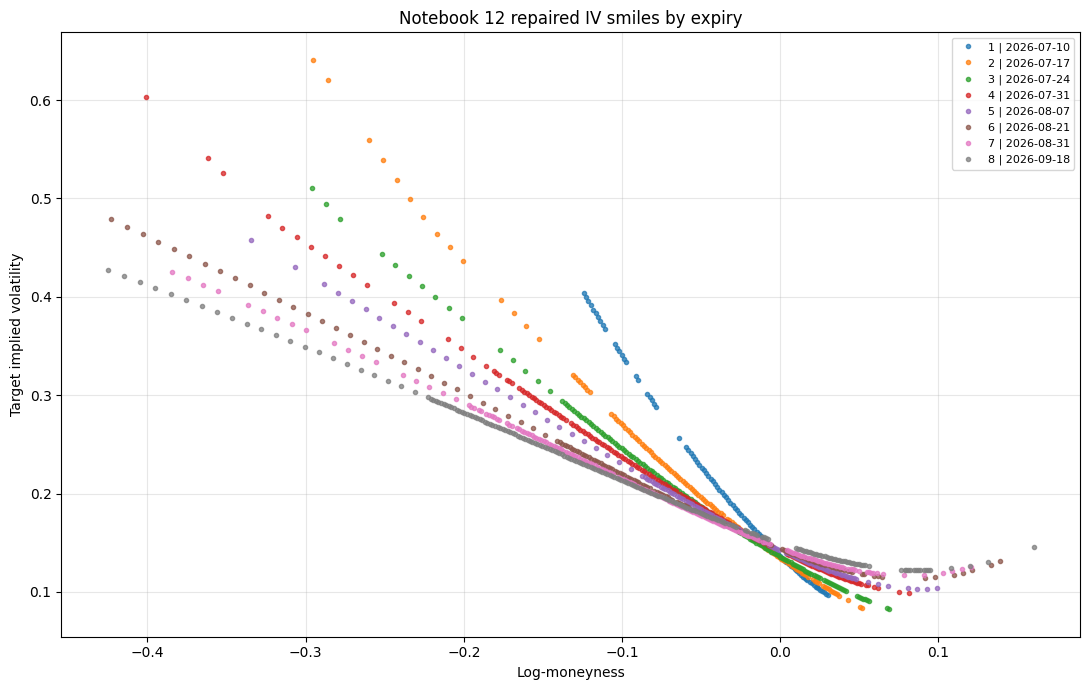

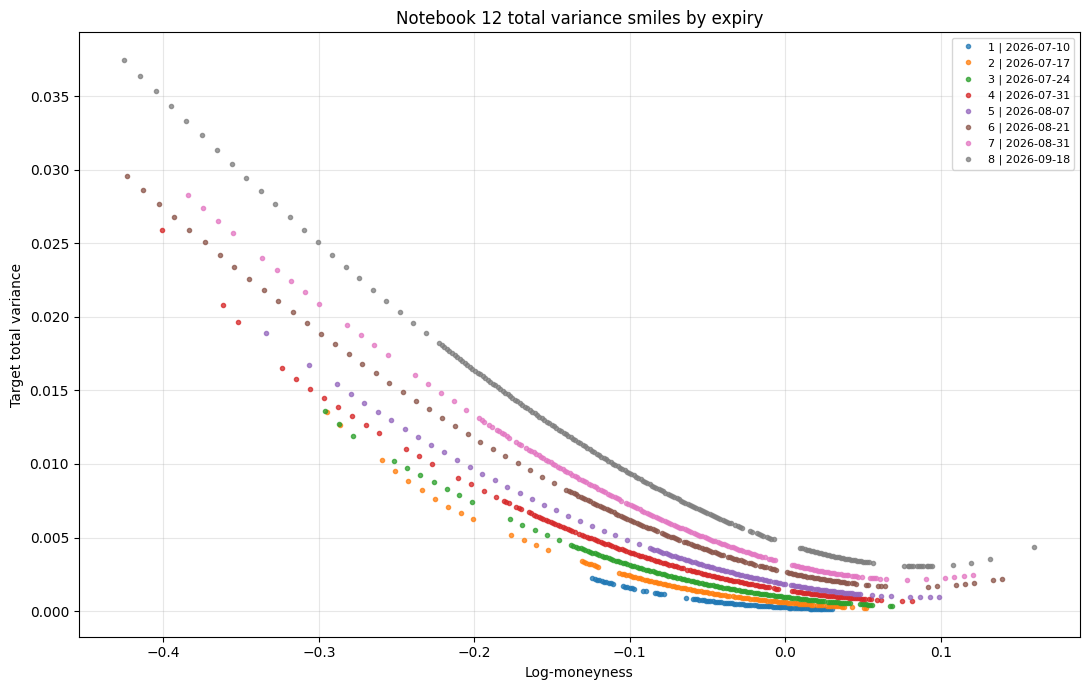

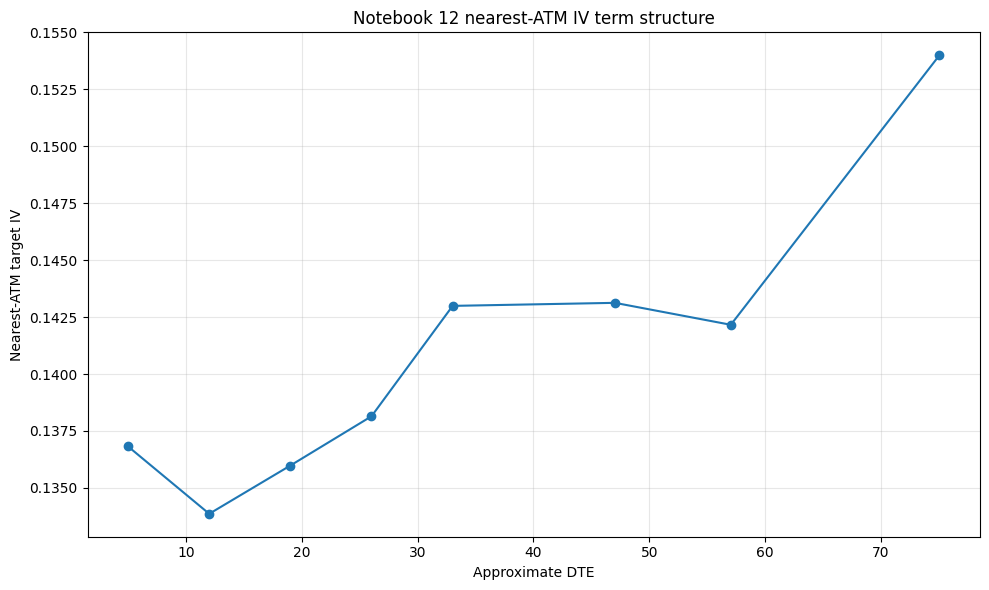

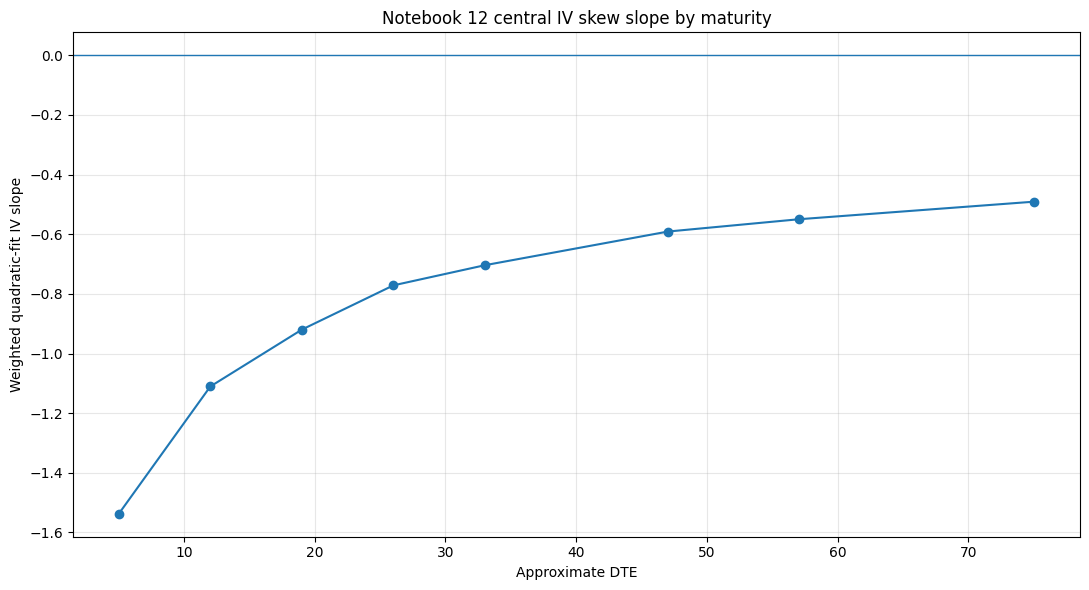

Notebook 12 pre-calibration surface diagnostics
Surface rows:               1,250
Expiries:                   8
Unique strikes:             253
ATM-covered expiries:       8
Wing-covered expiries:      8
Central polyfit expiries:   8
Calendar proxy status:      pass
Calendar grid points:       51
Calendar proxy violations:  0
Max calendar proxy breach:  0.0000000000
Surface panel persisted as: parquet_and_csv
Surface gate passed:        True
----------------------------------------------------------------------------------------
Surface shape summary by expiry:


,run_tag,expiry_rank,expiry_key,rows,calls,puts,unique_strikes,time_to_expiry,dte_approx,min_strike,median_strike,max_strike,min_log_moneyness,median_log_moneyness,max_log_moneyness,target_iv_min,target_iv_q25_w,target_iv_median,target_iv_median_w,target_iv_q75_w,target_iv_max,target_total_variance_min,target_total_variance_median,target_total_variance_max,atm_rows,wing_rows,atm_iv_nearest,atm_total_variance_nearest,atm_abs_log_moneyness_nearest,mean_calibration_weight,median_calibration_weight,repair_warning_rows
0,n12_20260706T023331Z,1,2026-07-10,97,29,68,97,0.0136986301,5.0034246575,658.0000000000,726.0000000000,768.0000000000,-0.1242195547,-0.0258744712,0.0303652471,0.0966643913,0.1218465122,0.1806038007,0.1537501684,0.2021670460,0.4035762809,0.0001280001,0.0004468183,0.0022311481,66,14,0.1368187931,0.0002564299,0.0000402676,0.7144187890,0.9003951047,0
1,n12_20260706T023331Z,2,2026-07-17,127,31,96,127,0.0328767123,12.0082191781,555.0000000000,711.0000000000,785.0000000000,-0.2951071410,-0.0474028249,0.0516084631,0.0832909497,0.1264256771,0.1926747287,0.1633967940,0.2106838976,0.6409736713,0.0002280783,0.0012205003,0.0135073068,63,27,0.1338624734,0.0005891231,0.0006503455,0.6996729070,1.0000000000,0
2,n12_20260706T023331Z,3,2026-07-24,152,41,111,152,0.0520547945,19.0130136986,555.0000000000,710.5000000000,799.0000000000,-0.2958546667,-0.0488540805,0.0685381653,0.0823540570,0.1242753480,0.1854396765,0.1611579480,0.2089477503,0.5107494970,0.0003530455,0.0017900844,0.0135792765,70,41,0.1359816638,0.0009625459,0.0000971803,0.6756368880,1.0000000000,0
3,n12_20260706T023331Z,4,2026-07-31,175,42,133,175,0.0712328767,26.0178082192,500.0000000000,697.0000000000,810.0000000000,-0.4009080739,-0.0687307616,0.0815180753,0.0986583843,0.1256997686,0.2049685476,0.1672333499,0.2141493856,0.6031006503,0.0006933436,0.0029926431,0.0259095623,67,66,0.1381450903,0.0013594129,0.0045570342,0.6370636150,1.0000000000,0
4,n12_20260706T023331Z,5,2026-08-07,131,45,86,131,0.0904109589,33.0226027397,535.0000000000,723.0000000000,825.0000000000,-0.3342401078,-0.0330976325,0.0988765317,0.1034115413,0.1277099319,0.1693018977,0.1582000866,0.1900172629,0.4572804985,0.0009668500,0.0025914613,0.0189054246,71,26,0.1429936184,0.0018486487,0.0004416695,0.6901806534,1.0000000000,0
5,n12_20260706T023331Z,6,2026-08-21,167,45,122,167,0.1287671233,47.0321917808,490.0000000000,703.0000000000,860.0000000000,-0.4233284145,-0.0623769138,0.1391985836,0.1139711990,0.1330154512,0.1892060277,0.1659657055,0.1981032182,0.4789500487,0.0016726121,0.0046097241,0.0295382959,63,65,0.1431271498,0.0026378436,0.0010051779,0.6577901413,1.0000000000,0
6,n12_20260706T023331Z,7,2026-08-31,187,46,141,187,0.1561643836,57.0390410959,510.0000000000,696.0000000000,845.0000000000,-0.3842214430,-0.0732825084,0.1207044586,0.1168749492,0.1330639840,0.1950474615,0.1652115086,0.2080824718,0.4255971810,0.0021331670,0.0059410416,0.0282865171,65,79,0.1421633511,0.0031561475,0.0041041552,0.6271721057,0.8420981457,0
7,n12_20260706T023331Z,8,2026-09-18,214,53,161,214,0.2054794521,75.0513698630,490.0000000000,684.5000000000,880.0000000000,-0.4252077096,-0.0909247228,0.1603088068,0.1219807762,0.1371604084,0.2073082753,0.1768173909,0.2093391108,0.4270220854,0.0030573924,0.0088308837,0.0374687387,57,105,0.1540000076,0.0048731512,0.0075720659,0.5869798576,0.7108345451,0


----------------------------------------------------------------------------------------
Smile slope and curvature diagnostics:


,run_tag,expiry_rank,expiry_key,time_to_expiry,dte_approx,fit_region,polyfit_rows,polyfit_status,iv_level_intercept,iv_skew_slope,iv_curvature_quad,iv_polyfit_weighted_rmse
0,n12_20260706T023331Z,1,2026-07-10,0.0136986301,5.0034246575,central_abs_k_le_0p10,83,ok,0.1372405132,-1.5374319839,5.0824034802,0.0004517893
1,n12_20260706T023331Z,1,2026-07-10,0.0136986301,5.0034246575,full,97,ok,0.1373446349,-1.5432052912,4.8792031609,0.0005078385
2,n12_20260706T023331Z,2,2026-07-17,0.0328767123,12.0082191781,central_abs_k_le_0p10,100,ok,0.1345358245,-1.1105038294,2.4703084837,0.0000702961
3,n12_20260706T023331Z,2,2026-07-17,0.0328767123,12.0082191781,full,127,ok,0.1350031121,-1.1364787958,1.9529356136,0.0009992951
4,n12_20260706T023331Z,3,2026-07-24,0.0520547945,19.0130136986,central_abs_k_le_0p10,111,ok,0.1360039744,-0.9198206808,1.8204886186,0.0001372379
5,n12_20260706T023331Z,3,2026-07-24,0.0520547945,19.0130136986,full,152,ok,0.1369266269,-0.9518598636,1.1882337858,0.0015131728
6,n12_20260706T023331Z,4,2026-07-31,0.0712328767,26.0178082192,central_abs_k_le_0p10,109,ok,0.1422141917,-0.7714716426,1.9685728339,0.0008343035
7,n12_20260706T023331Z,4,2026-07-31,0.0712328767,26.0178082192,full,175,ok,0.1444812842,-0.8205901432,0.8635607537,0.0028017368
8,n12_20260706T023331Z,5,2026-08-07,0.0904109589,33.0226027397,central_abs_k_le_0p10,105,ok,0.1425887200,-0.7038712322,2.1633703202,0.0011399847
9,n12_20260706T023331Z,5,2026-08-07,0.0904109589,33.0226027397,full,131,ok,0.1448607575,-0.7311133900,0.8444516468,0.0028483629


----------------------------------------------------------------------------------------
Moneyness-bucket diagnostics:


,run_tag,moneyness_bucket,rows,calls,puts,expiries,median_dte,min_log_moneyness,median_log_moneyness,max_log_moneyness,median_abs_log_moneyness,min_target_iv,median_target_iv,max_target_iv,median_total_variance,median_weight
0,n12_20260706T023331Z,call_wing,13,13,0,3,57.0390410959,0.1027935321,0.1197235267,0.1603088068,0.1197235267,0.1176835883,0.1238072432,0.1459375013,0.0022905283,0.2619683813
1,n12_20260706T023331Z,deep_put_wing,128,0,128,7,47.0321917808,-0.4252077096,-0.2703751527,-0.2006162976,0.2703751527,0.2831291357,0.3844620824,0.6409736713,0.0170596319,0.0672120658
2,n12_20260706T023331Z,near_atm,522,263,259,8,26.0178082192,-0.0498344248,-0.0005663529,0.0498849892,0.0247141554,0.0914313840,0.1414143716,0.2263573725,0.0016315564,1.0000000000
3,n12_20260706T023331Z,near_call,56,56,0,7,47.0321917808,0.0501675454,0.0631200860,0.0988765317,0.0631200860,0.0823540570,0.1159289362,0.1276259714,0.0017305780,0.7908314445
4,n12_20260706T023331Z,near_put,249,0,249,8,33.0226027397,-0.0994848808,-0.0740348941,-0.0501316803,0.0740348941,0.1783291276,0.2064097838,0.3370575825,0.0036277466,1.0000000000
5,n12_20260706T023331Z,put_wing,282,0,282,8,47.0321917808,-0.1996181726,-0.1327849749,-0.1000625327,0.1327849749,0.2138243746,0.2609954791,0.4035762809,0.0076025765,0.1792742869


----------------------------------------------------------------------------------------
Surface diagnostics gate:


,check_name,passed,severity,value,threshold
0,surface_rows_nonempty,True,blocking,1250,> 0
1,surface_expiry_coverage_sufficient,True,blocking,8,>= 4
2,surface_strike_coverage_sufficient,True,blocking,253,>= 40
3,surface_log_moneyness_valid,True,blocking,0,0 invalid rows
4,surface_target_iv_valid,True,blocking,0,0 invalid rows
5,surface_total_variance_valid,True,blocking,0,0 invalid rows
6,surface_target_price_valid,True,blocking,0,0 invalid rows
7,surface_calibration_weight_valid,True,blocking,0,0 invalid rows
8,atm_coverage_by_expiry,True,warning,8,>= 4
9,wing_coverage_by_expiry,True,warning,8,>= 4


----------------------------------------------------------------------------------------
Next step: fit simple implied-volatility baselines before Heston/Bates.


In [5]:
# ============================================================
# Notebook 12 — Pre-Calibration Surface Diagnostics
# ============================================================
#
# Purpose:
#   Diagnose the repaired modeling target before fitting baselines,
#   Heston, or Bates. This cell does not fit any pricing model.
#
# Core rule:
#   This is a diagnostic gate, not another repair engine.
#   If the selected N11 handoff is internally coherent, proceed.
#   If core fields are invalid, stop.
#
# Outputs:
#   n12_surface_panel
#   n12_surface_shape_summary
#   n12_smile_slope_curvature_diagnostics
#   n12_moneyness_bucket_diagnostics
#   n12_calendar_proxy_diagnostics
#   n12_surface_diagnostics_gate
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Output paths for this stage
# ------------------------------------------------------------

N12_OUTPUTS.update(
    {
        "surface_panel_csv": N12_TABLE_DIR / f"n12_surface_panel_{RUN_TAG}.csv",
        "surface_panel_csv_latest": N12_TABLE_DIR / "n12_surface_panel_latest.csv",
        "surface_panel_parquet": N12_ARTIFACT_DIR / f"n12_surface_panel_{RUN_TAG}.parquet",
        "surface_panel_parquet_latest": N12_ARTIFACT_DIR / "n12_surface_panel_latest.parquet",
        "surface_shape_summary": N12_TABLE_DIR / f"n12_surface_shape_summary_{RUN_TAG}.csv",
        "surface_shape_summary_latest": N12_TABLE_DIR / "n12_surface_shape_summary_latest.csv",
        "smile_slope_curvature_diagnostics": N12_TABLE_DIR / f"n12_smile_slope_curvature_diagnostics_{RUN_TAG}.csv",
        "smile_slope_curvature_diagnostics_latest": N12_TABLE_DIR / "n12_smile_slope_curvature_diagnostics_latest.csv",
        "moneyness_bucket_diagnostics": N12_TABLE_DIR / f"n12_moneyness_bucket_diagnostics_{RUN_TAG}.csv",
        "moneyness_bucket_diagnostics_latest": N12_TABLE_DIR / "n12_moneyness_bucket_diagnostics_latest.csv",
        "calendar_proxy_diagnostics": N12_TABLE_DIR / f"n12_calendar_proxy_diagnostics_{RUN_TAG}.csv",
        "calendar_proxy_diagnostics_latest": N12_TABLE_DIR / "n12_calendar_proxy_diagnostics_latest.csv",
        "calendar_proxy_grid": N12_TABLE_DIR / f"n12_calendar_proxy_grid_{RUN_TAG}.csv",
        "calendar_proxy_grid_latest": N12_TABLE_DIR / "n12_calendar_proxy_grid_latest.csv",
        "surface_diagnostics_gate": N12_TABLE_DIR / f"n12_surface_diagnostics_gate_{RUN_TAG}.csv",
        "surface_diagnostics_gate_latest": N12_TABLE_DIR / "n12_surface_diagnostics_gate_latest.csv",
        "fig_iv_smiles": N12_FIGURE_DIR / f"n12_iv_smiles_by_expiry_{RUN_TAG}.png",
        "fig_total_variance_smiles": N12_FIGURE_DIR / f"n12_total_variance_by_expiry_{RUN_TAG}.png",
        "fig_atm_term_structure": N12_FIGURE_DIR / f"n12_atm_term_structure_{RUN_TAG}.png",
        "fig_skew_slope_term_structure": N12_FIGURE_DIR / f"n12_skew_slope_term_structure_{RUN_TAG}.png",
    }
)


# ------------------------------------------------------------
# Guard against accidental out-of-order execution
# ------------------------------------------------------------

_REQUIRED_SURFACE_INPUT_NAMES = [
    "n12_modeling_target",
    "N12_POLICY",
    "RUN_TAG",
    "N12_TABLE_DIR",
    "N12_ARTIFACT_DIR",
    "N12_FIGURE_DIR",
    "N12_OUTPUTS",
]

missing_required_names = [
    name for name in _REQUIRED_SURFACE_INPUT_NAMES
    if name not in globals()
]

if missing_required_names:
    raise NameError(
        "Notebook 12 surface-diagnostics cell was run before required target-construction cells. "
        f"Missing names: {missing_required_names}"
    )


# ------------------------------------------------------------
# Surface-diagnostics helpers
# ------------------------------------------------------------

def finite_invalid_count(series: pd.Series) -> int:
    """Count non-finite values correctly."""
    values = pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)
    return int((~np.isfinite(values)).sum())


def positive_invalid_count(series: pd.Series, strict: bool = True) -> int:
    """Count invalid nonpositive numeric values."""
    values = pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)
    if strict:
        invalid = (~np.isfinite(values)) | (values <= 0)
    else:
        invalid = (~np.isfinite(values)) | (values < 0)
    return int(invalid.sum())


def weighted_quantile(
    values: pd.Series | np.ndarray,
    quantile: float,
    weights: Optional[pd.Series | np.ndarray] = None,
) -> float:
    """Compute a finite weighted quantile."""
    x = pd.to_numeric(pd.Series(values), errors="coerce").to_numpy(dtype=float)

    if weights is None:
        w = np.ones_like(x, dtype=float)
    else:
        w = pd.to_numeric(pd.Series(weights), errors="coerce").to_numpy(dtype=float)

    valid = np.isfinite(x) & np.isfinite(w) & (w > 0)

    if valid.sum() == 0:
        return np.nan

    x = x[valid]
    w = w[valid]

    order = np.argsort(x)
    x = x[order]
    w = w[order]

    cumulative = np.cumsum(w) - 0.5 * w
    cumulative = cumulative / np.sum(w)

    return float(np.interp(quantile, cumulative, x))


def weighted_rmse(residual: np.ndarray, weights: np.ndarray) -> float:
    """Compute weighted RMSE."""
    residual = np.asarray(residual, dtype=float)
    weights = np.asarray(weights, dtype=float)

    valid = np.isfinite(residual) & np.isfinite(weights) & (weights > 0)

    if valid.sum() == 0:
        return np.nan

    return float(np.sqrt(np.sum(weights[valid] * residual[valid] ** 2) / np.sum(weights[valid])))


def fit_weighted_quadratic_iv(
    df: pd.DataFrame,
    *,
    expiry_rank: int,
    expiry_key: str,
    fit_region: str,
    min_rows: int = 8,
) -> Dict[str, Any]:
    """
    Fit IV = beta0 + beta1*k + beta2*k^2 for one expiry slice.
    beta1 is the local skew proxy.
    beta2 is the curvature proxy.
    """
    work = df.copy()

    k = pd.to_numeric(work["log_moneyness"], errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(work["target_iv"], errors="coerce").to_numpy(dtype=float)
    w = pd.to_numeric(work["calibration_weight"], errors="coerce").to_numpy(dtype=float)

    valid = np.isfinite(k) & np.isfinite(y) & np.isfinite(w) & (w > 0)

    if valid.sum() < min_rows:
        return {
            "run_tag": RUN_TAG,
            "expiry_rank": expiry_rank,
            "expiry_key": expiry_key,
            "time_to_expiry": float(work["time_to_expiry"].median()) if "time_to_expiry" in work else np.nan,
            "dte_approx": float(work["dte_approx"].median()) if "dte_approx" in work else np.nan,
            "fit_region": fit_region,
            "polyfit_rows": int(valid.sum()),
            "polyfit_status": "insufficient_rows",
            "iv_level_intercept": np.nan,
            "iv_skew_slope": np.nan,
            "iv_curvature_quad": np.nan,
            "iv_polyfit_weighted_rmse": np.nan,
        }

    k = k[valid]
    y = y[valid]
    w = w[valid]

    if np.nanmax(k) - np.nanmin(k) <= 1e-8:
        return {
            "run_tag": RUN_TAG,
            "expiry_rank": expiry_rank,
            "expiry_key": expiry_key,
            "time_to_expiry": float(work["time_to_expiry"].median()),
            "dte_approx": float(work["dte_approx"].median()),
            "fit_region": fit_region,
            "polyfit_rows": int(len(k)),
            "polyfit_status": "insufficient_k_width",
            "iv_level_intercept": np.nan,
            "iv_skew_slope": np.nan,
            "iv_curvature_quad": np.nan,
            "iv_polyfit_weighted_rmse": np.nan,
        }

    X = np.column_stack([np.ones_like(k), k, k ** 2])
    sqrt_w = np.sqrt(w)

    try:
        beta, *_ = np.linalg.lstsq(X * sqrt_w[:, None], y * sqrt_w, rcond=None)
        fitted = X @ beta
        rmse = weighted_rmse(y - fitted, w)
        status = "ok"
    except np.linalg.LinAlgError:
        beta = np.array([np.nan, np.nan, np.nan], dtype=float)
        rmse = np.nan
        status = "linalg_error"

    return {
        "run_tag": RUN_TAG,
        "expiry_rank": expiry_rank,
        "expiry_key": expiry_key,
        "time_to_expiry": float(work["time_to_expiry"].median()),
        "dte_approx": float(work["dte_approx"].median()),
        "fit_region": fit_region,
        "polyfit_rows": int(len(k)),
        "polyfit_status": status,
        "iv_level_intercept": float(beta[0]) if np.isfinite(beta[0]) else np.nan,
        "iv_skew_slope": float(beta[1]) if np.isfinite(beta[1]) else np.nan,
        "iv_curvature_quad": float(beta[2]) if np.isfinite(beta[2]) else np.nan,
        "iv_polyfit_weighted_rmse": rmse,
    }


def aggregate_curve_for_interpolation(
    df: pd.DataFrame,
    *,
    x_col: str,
    y_col: str,
    weight_col: str,
) -> pd.DataFrame:
    """Aggregate duplicate x-values before interpolation."""
    work = df[[x_col, y_col, weight_col]].copy()
    work[x_col] = pd.to_numeric(work[x_col], errors="coerce")
    work[y_col] = pd.to_numeric(work[y_col], errors="coerce")
    work[weight_col] = pd.to_numeric(work[weight_col], errors="coerce")

    work = work.replace([np.inf, -np.inf], np.nan).dropna()

    if work.empty:
        return pd.DataFrame(columns=[x_col, y_col])

    def _weighted_mean(group: pd.DataFrame) -> float:
        y = group[y_col].to_numpy(dtype=float)
        w = group[weight_col].to_numpy(dtype=float)
        valid = np.isfinite(y) & np.isfinite(w) & (w > 0)
        if valid.sum() == 0:
            return float(np.nanmedian(y))
        return float(np.average(y[valid], weights=w[valid]))

    grouped = (
        work.groupby(x_col, as_index=False)
        .apply(lambda g: pd.Series({y_col: _weighted_mean(g)}), include_groups=False)
        .sort_values(x_col)
        .reset_index(drop=True)
    )

    return grouped


# ------------------------------------------------------------
# Build surface panel
# ------------------------------------------------------------

n12_surface_panel = n12_modeling_target.copy()

if "target_ready" in n12_surface_panel.columns:
    n12_surface_panel = n12_surface_panel.loc[n12_surface_panel["target_ready"]].copy()

n12_surface_panel = n12_surface_panel.replace([np.inf, -np.inf], np.nan)

# Recompute log-moneyness if any rows are missing it.
k_existing = pd.to_numeric(n12_surface_panel["log_moneyness"], errors="coerce")
k_from_forward = np.log(
    pd.to_numeric(n12_surface_panel["strike"], errors="coerce")
    / pd.to_numeric(n12_surface_panel["forward"], errors="coerce")
)

if "spot" in n12_surface_panel.columns:
    k_from_spot = np.log(
        pd.to_numeric(n12_surface_panel["strike"], errors="coerce")
        / pd.to_numeric(n12_surface_panel["spot"], errors="coerce")
    )
else:
    k_from_spot = pd.Series(np.nan, index=n12_surface_panel.index, dtype=float)

n12_surface_panel["log_moneyness_original"] = k_existing
n12_surface_panel["log_moneyness"] = k_existing.where(np.isfinite(k_existing), k_from_forward)
n12_surface_panel["log_moneyness"] = n12_surface_panel["log_moneyness"].where(
    np.isfinite(n12_surface_panel["log_moneyness"]),
    k_from_spot,
)

n12_surface_panel["abs_log_moneyness"] = n12_surface_panel["log_moneyness"].abs()
n12_surface_panel["target_total_variance"] = (
    pd.to_numeric(n12_surface_panel["target_iv"], errors="coerce")
    ** 2
    * pd.to_numeric(n12_surface_panel["time_to_expiry"], errors="coerce")
)

n12_surface_panel["atm_band_flag"] = n12_surface_panel["abs_log_moneyness"] <= 0.05
n12_surface_panel["central_band_flag"] = n12_surface_panel["abs_log_moneyness"] <= 0.10
n12_surface_panel["wing_flag"] = n12_surface_panel["abs_log_moneyness"] >= 0.10


# ------------------------------------------------------------
# Surface shape summary by expiry
# ------------------------------------------------------------

shape_rows: List[Dict[str, Any]] = []

for (expiry_rank, expiry_key), group in n12_surface_panel.groupby(
    ["expiry_rank", "expiry_key"],
    observed=False,
    dropna=False,
):
    group = group.copy()
    atm_idx = group["abs_log_moneyness"].idxmin()

    shape_rows.append(
        {
            "run_tag": RUN_TAG,
            "expiry_rank": int(expiry_rank),
            "expiry_key": str(expiry_key),
            "rows": int(len(group)),
            "calls": int((group["option_type"] == "call").sum()),
            "puts": int((group["option_type"] == "put").sum()),
            "unique_strikes": int(group["strike"].nunique(dropna=True)),
            "time_to_expiry": float(group["time_to_expiry"].median()),
            "dte_approx": float(group["dte_approx"].median()),
            "min_strike": float(group["strike"].min()),
            "median_strike": float(group["strike"].median()),
            "max_strike": float(group["strike"].max()),
            "min_log_moneyness": float(group["log_moneyness"].min()),
            "median_log_moneyness": float(group["log_moneyness"].median()),
            "max_log_moneyness": float(group["log_moneyness"].max()),
            "target_iv_min": float(group["target_iv"].min()),
            "target_iv_q25_w": weighted_quantile(group["target_iv"], 0.25, group["calibration_weight"]),
            "target_iv_median": float(group["target_iv"].median()),
            "target_iv_median_w": weighted_quantile(group["target_iv"], 0.50, group["calibration_weight"]),
            "target_iv_q75_w": weighted_quantile(group["target_iv"], 0.75, group["calibration_weight"]),
            "target_iv_max": float(group["target_iv"].max()),
            "target_total_variance_min": float(group["target_total_variance"].min()),
            "target_total_variance_median": float(group["target_total_variance"].median()),
            "target_total_variance_max": float(group["target_total_variance"].max()),
            "atm_rows": int(group["atm_band_flag"].sum()),
            "wing_rows": int(group["wing_flag"].sum()),
            "atm_iv_nearest": float(group.loc[atm_idx, "target_iv"]),
            "atm_total_variance_nearest": float(group.loc[atm_idx, "target_total_variance"]),
            "atm_abs_log_moneyness_nearest": float(group.loc[atm_idx, "abs_log_moneyness"]),
            "mean_calibration_weight": float(group["calibration_weight"].mean()),
            "median_calibration_weight": float(group["calibration_weight"].median()),
            "repair_warning_rows": int(group["repair_warning_flag"].sum()),
        }
    )

n12_surface_shape_summary = (
    pd.DataFrame(shape_rows)
    .sort_values("expiry_rank")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Smile slope and curvature diagnostics
# ------------------------------------------------------------

polyfit_rows: List[Dict[str, Any]] = []

for (expiry_rank, expiry_key), group in n12_surface_panel.groupby(
    ["expiry_rank", "expiry_key"],
    observed=False,
    dropna=False,
):
    group = group.copy()

    full_fit = fit_weighted_quadratic_iv(
        group,
        expiry_rank=int(expiry_rank),
        expiry_key=str(expiry_key),
        fit_region="full",
    )

    central_fit = fit_weighted_quadratic_iv(
        group.loc[group["central_band_flag"]],
        expiry_rank=int(expiry_rank),
        expiry_key=str(expiry_key),
        fit_region="central_abs_k_le_0p10",
    )

    polyfit_rows.extend([full_fit, central_fit])

n12_smile_slope_curvature_diagnostics = (
    pd.DataFrame(polyfit_rows)
    .sort_values(["expiry_rank", "fit_region"])
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Moneyness-bucket diagnostics
# ------------------------------------------------------------

n12_moneyness_bucket_diagnostics = (
    n12_surface_panel
    .groupby("moneyness_bucket", observed=False)
    .agg(
        rows=("source_row_id", "count"),
        calls=("option_type", lambda x: int((x == "call").sum())),
        puts=("option_type", lambda x: int((x == "put").sum())),
        expiries=("expiry_key", "nunique"),
        median_dte=("dte_approx", "median"),
        min_log_moneyness=("log_moneyness", "min"),
        median_log_moneyness=("log_moneyness", "median"),
        max_log_moneyness=("log_moneyness", "max"),
        median_abs_log_moneyness=("abs_log_moneyness", "median"),
        min_target_iv=("target_iv", "min"),
        median_target_iv=("target_iv", "median"),
        max_target_iv=("target_iv", "max"),
        median_total_variance=("target_total_variance", "median"),
        median_weight=("calibration_weight", "median"),
    )
    .reset_index()
)

n12_moneyness_bucket_diagnostics.insert(0, "run_tag", RUN_TAG)


# ------------------------------------------------------------
# Calendar proxy diagnostic on common log-moneyness grid
# ------------------------------------------------------------
#
# This is a proxy check, not the full Notebook 11 repair engine.
# It checks whether interpolated total variance is nondecreasing
# across expiries on the common moneyness domain.
# ------------------------------------------------------------

CALENDAR_PROXY_TOL = 3.0e-4
CALENDAR_GRID_POINTS = 51

curve_ranges = []

for (expiry_rank, expiry_key), group in n12_surface_panel.groupby(
    ["expiry_rank", "expiry_key"],
    observed=False,
    dropna=False,
):
    curve = aggregate_curve_for_interpolation(
        group,
        x_col="log_moneyness",
        y_col="target_total_variance",
        weight_col="calibration_weight",
    )

    if len(curve) >= 4:
        curve_ranges.append(
            {
                "expiry_rank": int(expiry_rank),
                "expiry_key": str(expiry_key),
                "k_min": float(curve["log_moneyness"].min()),
                "k_max": float(curve["log_moneyness"].max()),
                "curve_rows": int(len(curve)),
            }
        )

curve_ranges_df = pd.DataFrame(curve_ranges)

calendar_grid_valid = False
calendar_grid = np.array([], dtype=float)
calendar_grid_df = pd.DataFrame()
calendar_pair_rows: List[Dict[str, Any]] = []

if not curve_ranges_df.empty:
    common_k_min = float(curve_ranges_df["k_min"].max())
    common_k_max = float(curve_ranges_df["k_max"].min())

    if np.isfinite(common_k_min) and np.isfinite(common_k_max) and common_k_max > common_k_min:
        calendar_grid = np.linspace(common_k_min, common_k_max, CALENDAR_GRID_POINTS)
        interpolated_columns = {"log_moneyness": calendar_grid}
        interpolation_ok_expiries = []

        for (expiry_rank, expiry_key), group in n12_surface_panel.groupby(
            ["expiry_rank", "expiry_key"],
            observed=False,
            dropna=False,
        ):
            curve = aggregate_curve_for_interpolation(
                group,
                x_col="log_moneyness",
                y_col="target_total_variance",
                weight_col="calibration_weight",
            )

            curve = curve.dropna(subset=["log_moneyness", "target_total_variance"])

            if len(curve) < 4:
                continue

            x = curve["log_moneyness"].to_numpy(dtype=float)
            y = curve["target_total_variance"].to_numpy(dtype=float)

            if calendar_grid.min() < x.min() or calendar_grid.max() > x.max():
                continue

            interpolated_columns[f"expiry_{int(expiry_rank):02d}_{expiry_key}"] = np.interp(calendar_grid, x, y)
            interpolation_ok_expiries.append((int(expiry_rank), str(expiry_key)))

        calendar_grid_df = pd.DataFrame(interpolated_columns)
        calendar_grid_valid = len(interpolation_ok_expiries) >= 2

        if calendar_grid_valid:
            expiry_cols = [
                col for col in calendar_grid_df.columns
                if col.startswith("expiry_")
            ]

            for left_col, right_col in zip(expiry_cols[:-1], expiry_cols[1:]):
                left_values = calendar_grid_df[left_col].to_numpy(dtype=float)
                right_values = calendar_grid_df[right_col].to_numpy(dtype=float)

                raw_breach = left_values - right_values
                positive_breach = np.maximum(raw_breach, 0.0)
                violation_mask = positive_breach > CALENDAR_PROXY_TOL

                calendar_pair_rows.append(
                    {
                        "run_tag": RUN_TAG,
                        "left_expiry_column": left_col,
                        "right_expiry_column": right_col,
                        "grid_points": int(len(calendar_grid)),
                        "calendar_proxy_tolerance": CALENDAR_PROXY_TOL,
                        "violation_count": int(violation_mask.sum()),
                        "max_raw_breach": float(np.nanmax(positive_breach)),
                        "mean_raw_breach": float(np.nanmean(positive_breach)),
                        "status": "pass" if int(violation_mask.sum()) == 0 else "fail",
                    }
                )

n12_calendar_proxy_diagnostics = pd.DataFrame(calendar_pair_rows)

if n12_calendar_proxy_diagnostics.empty:
    n12_calendar_proxy_status = "unavailable"
    calendar_proxy_violations = np.nan
    max_calendar_proxy_breach = np.nan
    calendar_grid_points = int(len(calendar_grid))
else:
    calendar_proxy_violations = int(n12_calendar_proxy_diagnostics["violation_count"].sum())
    max_calendar_proxy_breach = float(n12_calendar_proxy_diagnostics["max_raw_breach"].max())
    calendar_grid_points = int(n12_calendar_proxy_diagnostics["grid_points"].max())
    n12_calendar_proxy_status = "pass" if calendar_proxy_violations == 0 else "fail"


# ------------------------------------------------------------
# Figures
# ------------------------------------------------------------

N12_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(11, 7))
for expiry_rank, group in n12_surface_panel.groupby("expiry_rank", observed=False):
    label = f"{int(expiry_rank)} | {group['expiry_key'].iloc[0]}"
    plot_group = group.sort_values("log_moneyness")
    ax.plot(
        plot_group["log_moneyness"],
        plot_group["target_iv"],
        marker=".",
        linestyle="",
        label=label,
        alpha=0.75,
    )
ax.set_title("Notebook 12 repaired IV smiles by expiry")
ax.set_xlabel("Log-moneyness")
ax.set_ylabel("Target implied volatility")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(N12_OUTPUTS["fig_iv_smiles"], dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(11, 7))
for expiry_rank, group in n12_surface_panel.groupby("expiry_rank", observed=False):
    label = f"{int(expiry_rank)} | {group['expiry_key'].iloc[0]}"
    plot_group = group.sort_values("log_moneyness")
    ax.plot(
        plot_group["log_moneyness"],
        plot_group["target_total_variance"],
        marker=".",
        linestyle="",
        label=label,
        alpha=0.75,
    )
ax.set_title("Notebook 12 total variance smiles by expiry")
ax.set_xlabel("Log-moneyness")
ax.set_ylabel("Target total variance")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(N12_OUTPUTS["fig_total_variance_smiles"], dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    n12_surface_shape_summary["dte_approx"],
    n12_surface_shape_summary["atm_iv_nearest"],
    marker="o",
)
ax.set_title("Notebook 12 nearest-ATM IV term structure")
ax.set_xlabel("Approximate DTE")
ax.set_ylabel("Nearest-ATM target IV")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(N12_OUTPUTS["fig_atm_term_structure"], dpi=160)
plt.show()

central_polyfit = n12_smile_slope_curvature_diagnostics.query(
    "fit_region == 'central_abs_k_le_0p10' and polyfit_status == 'ok'"
).copy()

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(
    central_polyfit["dte_approx"],
    central_polyfit["iv_skew_slope"],
    marker="o",
)
ax.axhline(0.0, linewidth=1)
ax.set_title("Notebook 12 central IV skew slope by maturity")
ax.set_xlabel("Approximate DTE")
ax.set_ylabel("Weighted quadratic-fit IV slope")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(N12_OUTPUTS["fig_skew_slope_term_structure"], dpi=160)
plt.show()


# ------------------------------------------------------------
# Surface diagnostics gate
# ------------------------------------------------------------

surface_rows = int(len(n12_surface_panel))
surface_expiries = int(n12_surface_panel["expiry_key"].nunique(dropna=True))
surface_unique_strikes = int(n12_surface_panel["strike"].nunique(dropna=True))
atm_covered_expiries = int(
    n12_surface_panel.groupby("expiry_key", observed=False)["atm_band_flag"].sum().gt(0).sum()
)
wing_covered_expiries = int(
    n12_surface_panel.groupby("expiry_key", observed=False)["wing_flag"].sum().gt(0).sum()
)
central_polyfit_expiries = int(
    central_polyfit["expiry_key"].nunique(dropna=True)
)

log_moneyness_invalid_rows = finite_invalid_count(n12_surface_panel["log_moneyness"])
target_iv_invalid_rows = positive_invalid_count(n12_surface_panel["target_iv"], strict=True)
total_variance_invalid_rows = positive_invalid_count(n12_surface_panel["target_total_variance"], strict=True)
target_price_invalid_rows = positive_invalid_count(n12_surface_panel["target_price"], strict=False)
weight_invalid_rows = positive_invalid_count(n12_surface_panel["calibration_weight"], strict=True)

calendar_proxy_available = n12_calendar_proxy_status in ["pass", "fail"]
calendar_proxy_passed = n12_calendar_proxy_status == "pass"

n12_surface_diagnostics_gate = pd.DataFrame(
    [
        build_check(
            "surface_rows_nonempty",
            surface_rows > 0,
            "blocking",
            "Surface panel must be nonempty.",
            surface_rows,
            "> 0",
        ),
        build_check(
            "surface_expiry_coverage_sufficient",
            surface_expiries >= N12_POLICY.min_expiries_for_parametric_calibration,
            "blocking",
            "Surface must span enough expiry slices before calibration.",
            surface_expiries,
            f">= {N12_POLICY.min_expiries_for_parametric_calibration}",
        ),
        build_check(
            "surface_strike_coverage_sufficient",
            surface_unique_strikes >= N12_POLICY.min_unique_strikes_for_parametric_calibration,
            "blocking",
            "Surface must span enough unique strikes before calibration.",
            surface_unique_strikes,
            f">= {N12_POLICY.min_unique_strikes_for_parametric_calibration}",
        ),
        build_check(
            "surface_log_moneyness_valid",
            log_moneyness_invalid_rows == 0,
            "blocking",
            "Log-moneyness must be finite for every surface row.",
            log_moneyness_invalid_rows,
            "0 invalid rows",
        ),
        build_check(
            "surface_target_iv_valid",
            target_iv_invalid_rows == 0,
            "blocking",
            "Target IV must be finite and strictly positive for every surface row.",
            target_iv_invalid_rows,
            "0 invalid rows",
        ),
        build_check(
            "surface_total_variance_valid",
            total_variance_invalid_rows == 0,
            "blocking",
            "Total variance must be finite and strictly positive for every surface row.",
            total_variance_invalid_rows,
            "0 invalid rows",
        ),
        build_check(
            "surface_target_price_valid",
            target_price_invalid_rows == 0,
            "blocking",
            "Target price must be finite and nonnegative for every surface row.",
            target_price_invalid_rows,
            "0 invalid rows",
        ),
        build_check(
            "surface_calibration_weight_valid",
            weight_invalid_rows == 0,
            "blocking",
            "Calibration weight must be finite and strictly positive for every surface row.",
            weight_invalid_rows,
            "0 invalid rows",
        ),
        build_check(
            "atm_coverage_by_expiry",
            atm_covered_expiries >= N12_POLICY.min_expiries_for_parametric_calibration,
            "warning",
            "ATM coverage anchors level and variance diagnostics.",
            atm_covered_expiries,
            f">= {N12_POLICY.min_expiries_for_parametric_calibration}",
        ),
        build_check(
            "wing_coverage_by_expiry",
            wing_covered_expiries >= N12_POLICY.min_expiries_for_parametric_calibration,
            "warning",
            "Wing coverage supports skew, smile, and jump diagnostics.",
            wing_covered_expiries,
            f">= {N12_POLICY.min_expiries_for_parametric_calibration}",
        ),
        build_check(
            "central_polyfit_coverage",
            central_polyfit_expiries >= N12_POLICY.min_expiries_for_parametric_calibration,
            "warning",
            "Central quadratic fits should be available across enough expiries.",
            central_polyfit_expiries,
            f">= {N12_POLICY.min_expiries_for_parametric_calibration}",
        ),
        build_check(
            "calendar_proxy_available",
            calendar_proxy_available,
            "warning",
            "Calendar proxy should be available on a common log-moneyness grid.",
            n12_calendar_proxy_status,
            "pass or fail",
        ),
        build_check(
            "calendar_proxy_no_material_violations",
            calendar_proxy_passed if calendar_proxy_available else True,
            "blocking",
            "Interpolated total variance should not materially decrease across expiries on the common grid.",
            calendar_proxy_violations,
            "0 violations above tolerance",
        ),
    ]
)

surface_blocking_failures = n12_surface_diagnostics_gate.query(
    "severity == 'blocking' and passed == False"
).copy()

surface_gate_passed = bool(surface_blocking_failures.empty)


# ------------------------------------------------------------
# Persist artifacts
# ------------------------------------------------------------

write_table(
    n12_surface_shape_summary,
    N12_OUTPUTS["surface_shape_summary"],
    N12_OUTPUTS["surface_shape_summary_latest"],
)

write_table(
    n12_smile_slope_curvature_diagnostics,
    N12_OUTPUTS["smile_slope_curvature_diagnostics"],
    N12_OUTPUTS["smile_slope_curvature_diagnostics_latest"],
)

write_table(
    n12_moneyness_bucket_diagnostics,
    N12_OUTPUTS["moneyness_bucket_diagnostics"],
    N12_OUTPUTS["moneyness_bucket_diagnostics_latest"],
)

write_table(
    n12_calendar_proxy_diagnostics,
    N12_OUTPUTS["calendar_proxy_diagnostics"],
    N12_OUTPUTS["calendar_proxy_diagnostics_latest"],
)

write_table(
    calendar_grid_df,
    N12_OUTPUTS["calendar_proxy_grid"],
    N12_OUTPUTS["calendar_proxy_grid_latest"],
)

write_table(
    n12_surface_diagnostics_gate,
    N12_OUTPUTS["surface_diagnostics_gate"],
    N12_OUTPUTS["surface_diagnostics_gate_latest"],
)

n12_surface_panel_persist_format = write_parquet_with_fallback(
    n12_surface_panel,
    N12_OUTPUTS["surface_panel_parquet"],
    N12_OUTPUTS["surface_panel_csv"],
)

_ = write_parquet_with_fallback(
    n12_surface_panel,
    N12_OUTPUTS["surface_panel_parquet_latest"],
    N12_OUTPUTS["surface_panel_csv_latest"],
)


# ------------------------------------------------------------
# Reader-facing output
# ------------------------------------------------------------

print("=" * 88)
print("Notebook 12 pre-calibration surface diagnostics")
print("=" * 88)
print(f"Surface rows:               {surface_rows:,}")
print(f"Expiries:                   {surface_expiries:,}")
print(f"Unique strikes:             {surface_unique_strikes:,}")
print(f"ATM-covered expiries:       {atm_covered_expiries:,}")
print(f"Wing-covered expiries:      {wing_covered_expiries:,}")
print(f"Central polyfit expiries:   {central_polyfit_expiries:,}")
print(f"Calendar proxy status:      {n12_calendar_proxy_status}")
print(f"Calendar grid points:       {calendar_grid_points:,}")
print(f"Calendar proxy violations:  {0 if pd.isna(calendar_proxy_violations) else int(calendar_proxy_violations):,}")
print(f"Max calendar proxy breach:  {np.nan if pd.isna(max_calendar_proxy_breach) else max_calendar_proxy_breach:,.10f}")
print(f"Surface panel persisted as: {n12_surface_panel_persist_format}")
print(f"Surface gate passed:        {surface_gate_passed}")
print("-" * 88)

print("Surface shape summary by expiry:")
display_or_print(n12_surface_shape_summary)

print("-" * 88)
print("Smile slope and curvature diagnostics:")
display_or_print(n12_smile_slope_curvature_diagnostics)

print("-" * 88)
print("Moneyness-bucket diagnostics:")
display_or_print(n12_moneyness_bucket_diagnostics)

print("-" * 88)
print("Surface diagnostics gate:")
display_or_print(n12_surface_diagnostics_gate[["check_name", "passed", "severity", "value", "threshold"]])

if not surface_gate_passed:
    print("-" * 88)
    print("Blocking failures:")
    display_or_print(surface_blocking_failures[["check_name", "value", "threshold", "detail"]])
    raise RuntimeError(
        "Notebook 12 surface diagnostics gate failed. Do not proceed to baseline fitting."
    )

print("-" * 88)
print("Next step: fit simple implied-volatility baselines before Heston/Bates.")

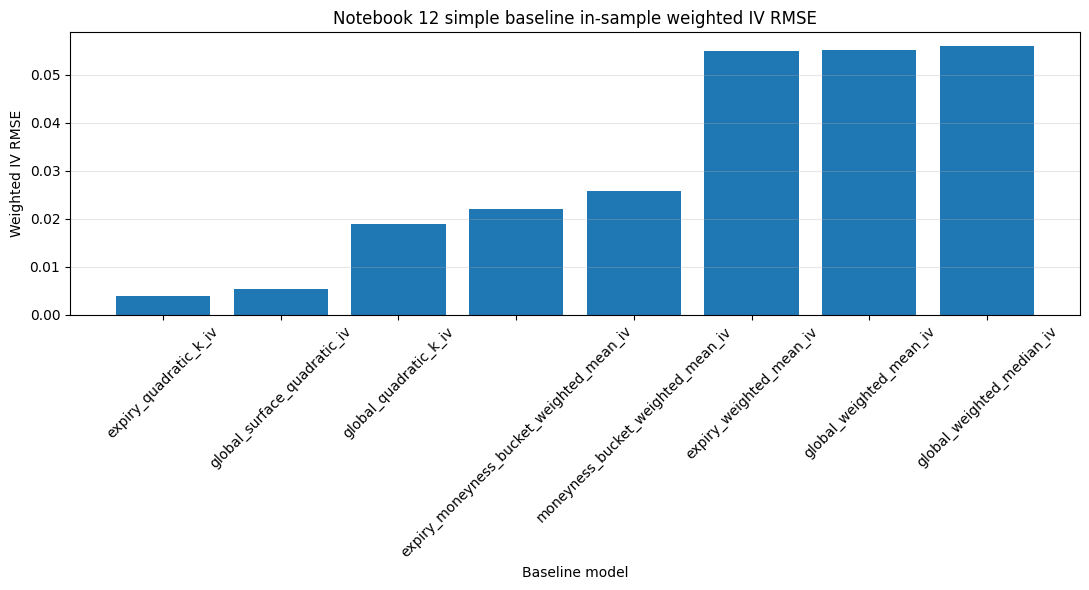

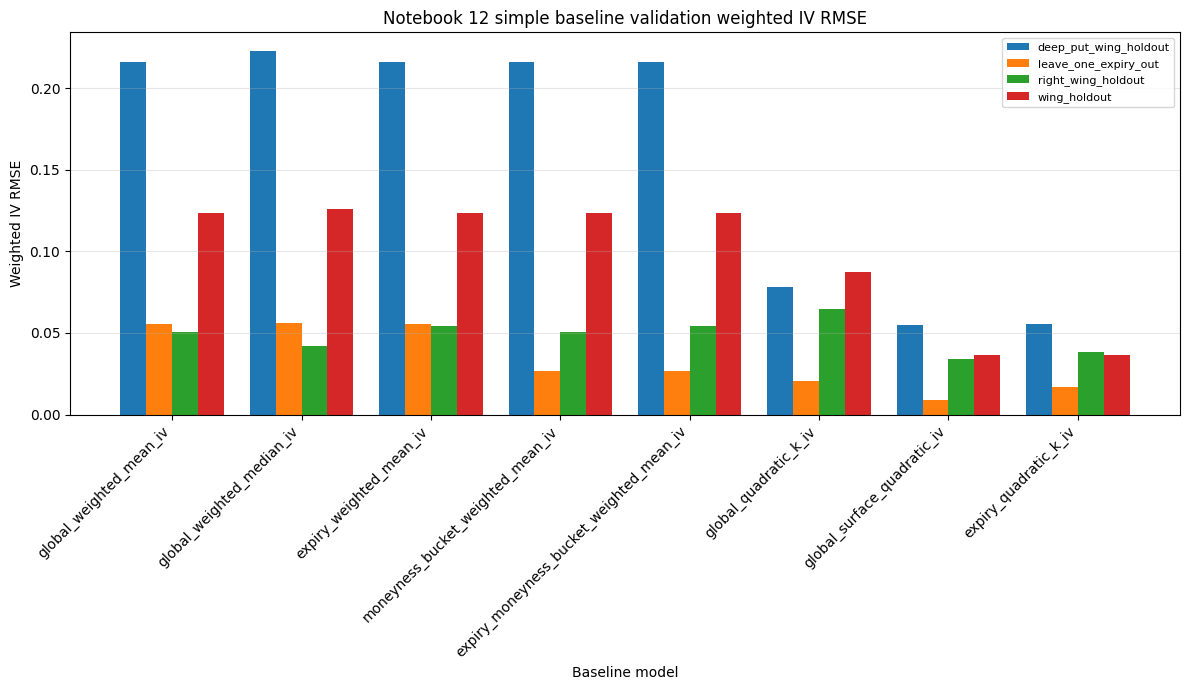

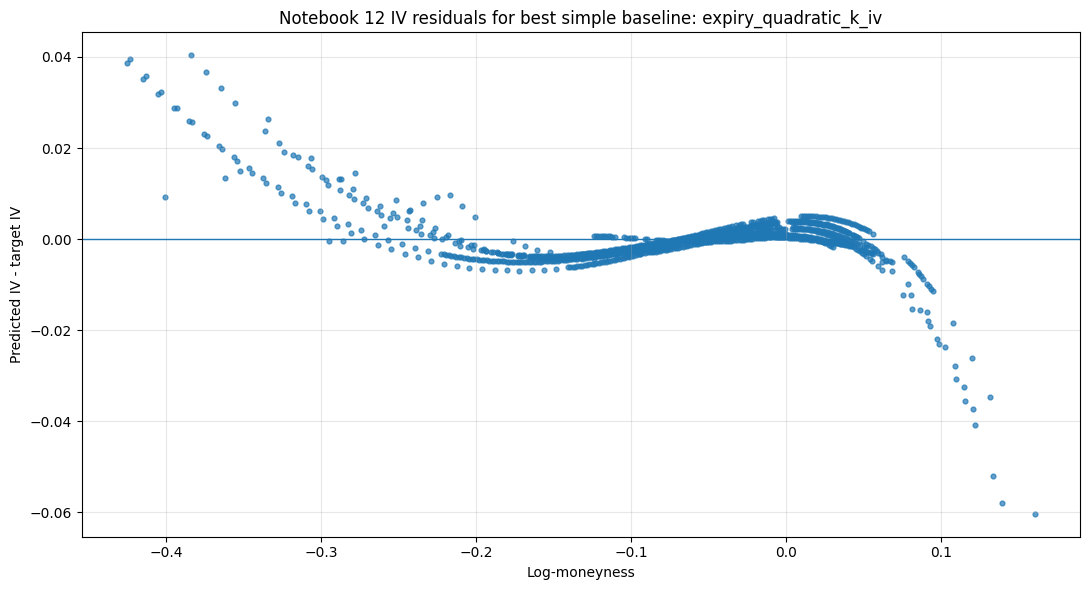

Notebook 12 simple implied-volatility baselines
Baseline source rows:              1,250
Validation splits:                 12
Baseline models:                   8
Prediction rows:                   24,512
Successful in-sample baselines:    8
Successful LOEO baselines:         8
Best low-complexity baseline:      global_surface_quadratic_iv
Best low-complexity IV RMSE:       0.0053823027
Best all-simple baseline:          expiry_quadratic_k_iv
Best all-simple IV RMSE:           0.0037868480
Prediction panel persisted as:     parquet_and_csv
Baseline gate passed:              True
----------------------------------------------------------------------------------------
Best baseline by validation family:


,run_tag,validation_family,rank,model_name,model_family,weighted_iv_rmse,weighted_iv_mae,weighted_iv_bias,weighted_iv_r2,weighted_price_rmse,weighted_price_mae,iv_p95_abs_error,prediction_clip_rate,rows,splits
0,n12_20260706T023331Z,deep_put_wing_holdout,1,global_surface_quadratic_iv,weighted_polynomial,0.0549532269,0.0442157466,0.0442157466,0.3523489465,0.7151648162,0.5569864601,0.1160124339,0.0000000000,128,1
1,n12_20260706T023331Z,in_sample,1,expiry_quadratic_k_iv,expiry_weighted_polynomial,0.0037868480,0.0022139230,-0.0000000000,0.9952984215,0.1922602487,0.1272834134,0.0116313295,0.0000000000,1250,1
2,n12_20260706T023331Z,leave_one_expiry_out,1,global_surface_quadratic_iv,weighted_polynomial,0.0088592652,0.0062419761,-0.0000328753,0.9742674189,0.4154447370,0.2898638224,0.0290029948,0.0000000000,1250,8
3,n12_20260706T023331Z,right_wing_holdout,1,global_surface_quadratic_iv,weighted_polynomial,0.0340775947,0.0325831160,-0.0325831160,-47.4856367995,0.2048778920,0.1636187260,0.0613454204,0.0000000000,13,1
4,n12_20260706T023331Z,wing_holdout,1,global_surface_quadratic_iv,weighted_polynomial,0.0361683759,0.0198055588,0.0168643577,0.6350240092,0.8374140625,0.4959331047,0.1564568993,0.0000000000,423,1


----------------------------------------------------------------------------------------
Validation-family summary:


,run_tag,validation_family,model_name,model_family,splits,train_rows_median,test_rows_total,rows,valid_iv_rows,valid_price_rows,invalid_iv_prediction_rows,prediction_clip_rows,prediction_clip_rate,weighted_iv_rmse,weighted_iv_mae,weighted_iv_bias,weighted_iv_r2,iv_rmse,iv_mae,iv_p95_abs_error,weighted_price_rmse,weighted_price_mae,weighted_price_bias,price_rmse,price_mae,price_p95_abs_error
0,n12_20260706T023331Z,deep_put_wing_holdout,global_surface_quadratic_iv,weighted_polynomial,1,"1,122.0000000000",128,128,128,128,0,0,0.0000000000,0.0549532269,0.0442157466,0.0442157466,0.3523489465,0.0615574388,0.0508996150,0.1160124339,0.7151648162,0.5569864601,0.5569864601,0.7874167641,0.6270927296,1.5910563238
1,n12_20260706T023331Z,deep_put_wing_holdout,expiry_quadratic_k_iv,expiry_weighted_polynomial,1,"1,122.0000000000",128,128,128,128,0,0,0.0000000000,0.0557029192,0.0438114644,0.0438114644,0.3345574160,0.0624381464,0.0492233273,0.1296630523,0.8027860657,0.6108913666,0.6108913666,0.8766629085,0.6614257736,1.8426273564
2,n12_20260706T023331Z,deep_put_wing_holdout,global_quadratic_k_iv,weighted_polynomial,1,"1,122.0000000000",128,128,128,128,0,0,0.0000000000,0.0778912676,0.0626833053,0.0362953620,-0.3011645449,0.0870430821,0.0710146835,0.1637620207,1.5684115918,1.0969574686,1.0587846115,1.6920408854,1.1942388609,3.6670272916
3,n12_20260706T023331Z,deep_put_wing_holdout,global_weighted_mean_iv,constant,1,"1,122.0000000000",128,128,128,128,0,0,0.0000000000,0.2159871700,0.2049089391,-0.2049089391,-9.0048500932,0.2313083709,0.2193389327,0.3522542816,0.8784108377,0.7017091432,-0.7017091432,0.8911748741,0.6753813602,1.9654182053
4,n12_20260706T023331Z,deep_put_wing_holdout,moneyness_bucket_weighted_mean_iv,group_mean,1,"1,122.0000000000",128,128,128,128,0,0,0.0000000000,0.2159871700,0.2049089391,-0.2049089391,-9.0048500932,0.2313083709,0.2193389327,0.3522542816,0.8784108377,0.7017091432,-0.7017091432,0.8911748741,0.6753813602,1.9654182053
5,n12_20260706T023331Z,deep_put_wing_holdout,expiry_moneyness_bucket_weighted_mean_iv,hierarchical_group_mean,1,"1,122.0000000000",128,128,128,128,0,0,0.0000000000,0.2160312872,0.2046779921,-0.2046779921,-9.0089376671,0.2310900915,0.2186719992,0.3499001511,0.8743767384,0.6998673023,-0.6998673023,0.8857323020,0.6728609979,1.9453711204
6,n12_20260706T023331Z,deep_put_wing_holdout,expiry_weighted_mean_iv,group_mean,1,"1,122.0000000000",128,128,128,128,0,0,0.0000000000,0.2160312872,0.2046779921,-0.2046779921,-9.0089376671,0.2310900915,0.2186719992,0.3499001511,0.8743767384,0.6998673023,-0.6998673023,0.8857323020,0.6728609979,1.9453711204
7,n12_20260706T023331Z,deep_put_wing_holdout,global_weighted_median_iv,constant,1,"1,122.0000000000",128,128,128,128,0,0,0.0000000000,0.2229616450,0.2122477583,-0.2122477583,-9.6614186573,0.2382788246,0.2266777519,0.3595931008,0.8825083953,0.7037761646,-0.7037761646,0.8962788849,0.6777995027,1.9836355189
8,n12_20260706T023331Z,in_sample,expiry_quadratic_k_iv,expiry_weighted_polynomial,1,"1,250.0000000000",1250,1250,1250,1250,0,0,0.0000000000,0.0037868480,0.0022139230,-0.0000000000,0.9952984215,0.0067570378,0.0034777336,0.0116313295,0.1922602487,0.1272834134,0.0608937520,0.1763177681,0.1177244992,0.4037813574
9,n12_20260706T023331Z,in_sample,global_surface_quadratic_iv,weighted_polynomial,1,"1,250.0000000000",1250,1250,1250,1250,0,0,0.0000000000,0.0053823027,0.0036939577,-0.0000000000,0.9905021744,0.0087700271,0.0052389197,0.0200614771,0.2374265161,0.1731297950,0.0635393714,0.2146436287,0.1531598778,0.4727567632


----------------------------------------------------------------------------------------
Baseline diagnostics gate:


,check_name,passed,severity,value,threshold
0,baseline_source_rows_sufficient,True,blocking,1250,>= 250
1,baseline_validation_splits_available,True,blocking,12,>= 2
2,baseline_predictions_nonempty,True,blocking,24512,> 0
3,successful_insample_baselines,True,blocking,8,>= 4
4,successful_leave_one_expiry_baselines,True,warning,8,>= 3
5,baseline_invalid_predictions_zero,True,warning,0,0
6,best_low_complexity_baseline_available,True,blocking,global_surface_quadratic_iv,available
7,best_all_simple_baseline_available,True,blocking,expiry_quadratic_k_iv,available


----------------------------------------------------------------------------------------
Next step: use these baseline errors as the hurdle before Heston/Bates calibration.


In [6]:
# ============================================================
# Notebook 12 — Simple Implied-Volatility Baselines
# ============================================================
#
# Purpose:
#   Fit transparent IV-space baselines before any Heston/Bates calibration.
#
# Rule:
#   Heston/Bates does not get credit merely for fitting the surface.
#   It must be judged against simple baselines that already capture level,
#   maturity structure, moneyness structure, and smile curvature.
#
# Outputs:
#   n12_baseline_prediction_panel
#   n12_baseline_split_summary
#   n12_baseline_validation_summary
#   n12_baseline_leaderboard
#   n12_baseline_gate
# ============================================================

from typing import Optional, Sequence


# ------------------------------------------------------------
# Output paths for this stage
# ------------------------------------------------------------

N12_OUTPUTS.update(
    {
        "baseline_prediction_panel_csv": N12_TABLE_DIR / f"n12_baseline_prediction_panel_{RUN_TAG}.csv",
        "baseline_prediction_panel_csv_latest": N12_TABLE_DIR / "n12_baseline_prediction_panel_latest.csv",
        "baseline_prediction_panel_parquet": N12_ARTIFACT_DIR / f"n12_baseline_prediction_panel_{RUN_TAG}.parquet",
        "baseline_prediction_panel_parquet_latest": N12_ARTIFACT_DIR / "n12_baseline_prediction_panel_latest.parquet",
        "baseline_split_summary": N12_TABLE_DIR / f"n12_baseline_split_summary_{RUN_TAG}.csv",
        "baseline_split_summary_latest": N12_TABLE_DIR / "n12_baseline_split_summary_latest.csv",
        "baseline_validation_summary": N12_TABLE_DIR / f"n12_baseline_validation_summary_{RUN_TAG}.csv",
        "baseline_validation_summary_latest": N12_TABLE_DIR / "n12_baseline_validation_summary_latest.csv",
        "baseline_leaderboard": N12_TABLE_DIR / f"n12_baseline_leaderboard_{RUN_TAG}.csv",
        "baseline_leaderboard_latest": N12_TABLE_DIR / "n12_baseline_leaderboard_latest.csv",
        "baseline_gate": N12_TABLE_DIR / f"n12_baseline_gate_{RUN_TAG}.csv",
        "baseline_gate_latest": N12_TABLE_DIR / "n12_baseline_gate_latest.csv",
        "fig_baseline_insample_rmse": N12_FIGURE_DIR / f"n12_baseline_insample_iv_rmse_{RUN_TAG}.png",
        "fig_baseline_cv_rmse": N12_FIGURE_DIR / f"n12_baseline_cv_iv_rmse_{RUN_TAG}.png",
        "fig_baseline_residual_by_moneyness": N12_FIGURE_DIR / f"n12_baseline_residual_by_moneyness_{RUN_TAG}.png",
    }
)


# ------------------------------------------------------------
# Guard against accidental out-of-order execution
# ------------------------------------------------------------

_REQUIRED_BASELINE_INPUT_NAMES = [
    "n12_surface_panel",
    "N12_POLICY",
    "RUN_TAG",
    "N12_TABLE_DIR",
    "N12_ARTIFACT_DIR",
    "N12_FIGURE_DIR",
    "N12_OUTPUTS",
]

missing_required_names = [
    name for name in _REQUIRED_BASELINE_INPUT_NAMES
    if name not in globals()
]

if missing_required_names:
    raise NameError(
        "Notebook 12 baseline cell was run before required surface-diagnostics cells. "
        f"Missing names: {missing_required_names}"
    )


# ------------------------------------------------------------
# Local numerical helpers
# ------------------------------------------------------------

def as_numeric_array(values: pd.Series | np.ndarray | Sequence[Any]) -> np.ndarray:
    """Convert values to a finite-compatible float array."""
    return pd.to_numeric(pd.Series(values), errors="coerce").to_numpy(dtype=float)


def weighted_mean_value(values: pd.Series | np.ndarray, weights: Optional[pd.Series | np.ndarray] = None) -> float:
    """Finite weighted mean."""
    x = as_numeric_array(values)

    if weights is None:
        w = np.ones_like(x, dtype=float)
    else:
        w = as_numeric_array(weights)

    valid = np.isfinite(x) & np.isfinite(w) & (w > 0)

    if valid.sum() == 0:
        return np.nan

    return float(np.average(x[valid], weights=w[valid]))


def weighted_median_value(values: pd.Series | np.ndarray, weights: Optional[pd.Series | np.ndarray] = None) -> float:
    """Finite weighted median."""
    x = as_numeric_array(values)

    if weights is None:
        w = np.ones_like(x, dtype=float)
    else:
        w = as_numeric_array(weights)

    valid = np.isfinite(x) & np.isfinite(w) & (w > 0)

    if valid.sum() == 0:
        return np.nan

    x = x[valid]
    w = w[valid]

    order = np.argsort(x)
    x = x[order]
    w = w[order]

    cumulative = np.cumsum(w) / np.sum(w)

    return float(x[np.searchsorted(cumulative, 0.50, side="left")])


def safe_key(values: Sequence[Any]) -> tuple:
    """Stable tuple key for group maps."""
    return tuple("MISSING" if pd.isna(value) else str(value) for value in values)


def make_group_key_frame(df: pd.DataFrame, group_cols: Sequence[str]) -> pd.DataFrame:
    """Return group-key columns converted to stable strings."""
    out = pd.DataFrame(index=df.index)

    for col in group_cols:
        out[col] = (
            df[col]
            .astype("string")
            .fillna("MISSING")
            .astype(str)
        )

    return out


def fit_group_weighted_mean(
    train: pd.DataFrame,
    group_cols: Sequence[str],
    *,
    value_col: str = "target_iv",
    weight_col: str = "calibration_weight",
    min_group_rows: int = 3,
) -> Dict[tuple, float]:
    """Fit finite weighted means by group."""
    work = train.copy()
    key_frame = make_group_key_frame(work, group_cols)
    work = pd.concat([work.reset_index(drop=True), key_frame.reset_index(drop=True).add_prefix("__key__")], axis=1)

    key_cols = [f"__key__{col}" for col in group_cols]
    result: Dict[tuple, float] = {}

    for key, group in work.groupby(key_cols, observed=True, dropna=False):
        if not isinstance(key, tuple):
            key = (key,)

        if len(group) < min_group_rows:
            continue

        value = weighted_mean_value(group[value_col], group[weight_col])

        if np.isfinite(value):
            result[tuple(key)] = value

    return result


def predict_group_weighted_mean(
    test: pd.DataFrame,
    group_map: Dict[tuple, float],
    group_cols: Sequence[str],
    fallback_value: float,
) -> np.ndarray:
    """Predict from a group mean map with global fallback."""
    key_frame = make_group_key_frame(test, group_cols)
    preds = []

    for _, row in key_frame.iterrows():
        key = safe_key([row[col] for col in group_cols])
        preds.append(group_map.get(key, fallback_value))

    return np.asarray(preds, dtype=float)


def fit_hierarchical_expiry_moneyness_model(train: pd.DataFrame) -> Dict[str, Any]:
    """Fit expiry × moneyness bucket with expiry, bucket, then global fallback."""
    global_value = weighted_mean_value(train["target_iv"], train["calibration_weight"])

    return {
        "model_type": "hierarchical_group_mean",
        "fit_status": "ok" if np.isfinite(global_value) else "failed",
        "global_value": global_value,
        "primary_group_cols": ["expiry_key", "moneyness_bucket"],
        "primary_map": fit_group_weighted_mean(train, ["expiry_key", "moneyness_bucket"]),
        "expiry_map": fit_group_weighted_mean(train, ["expiry_key"]),
        "bucket_map": fit_group_weighted_mean(train, ["moneyness_bucket"]),
    }


def predict_hierarchical_expiry_moneyness_model(model: Dict[str, Any], test: pd.DataFrame) -> np.ndarray:
    """Predict with hierarchical expiry × moneyness fallback."""
    preds = []

    for _, row in test.iterrows():
        expiry_key = "MISSING" if pd.isna(row["expiry_key"]) else str(row["expiry_key"])
        bucket_key = "MISSING" if pd.isna(row["moneyness_bucket"]) else str(row["moneyness_bucket"])

        primary_key = (expiry_key, bucket_key)
        expiry_only_key = (expiry_key,)
        bucket_only_key = (bucket_key,)

        if primary_key in model["primary_map"]:
            preds.append(model["primary_map"][primary_key])
        elif expiry_only_key in model["expiry_map"]:
            preds.append(model["expiry_map"][expiry_only_key])
        elif bucket_only_key in model["bucket_map"]:
            preds.append(model["bucket_map"][bucket_only_key])
        else:
            preds.append(model["global_value"])

    return np.asarray(preds, dtype=float)


# ------------------------------------------------------------
# Feature construction for polynomial baselines
# ------------------------------------------------------------

def make_baseline_features(df: pd.DataFrame, feature_set: str) -> pd.DataFrame:
    """Construct transparent IV-baseline features."""
    k = pd.to_numeric(df["log_moneyness"], errors="coerce").astype(float)
    tau = pd.to_numeric(df["time_to_expiry"], errors="coerce").astype(float)
    sqrt_tau = np.sqrt(tau.clip(lower=0))

    features = pd.DataFrame(index=df.index)

    if feature_set == "k_quadratic":
        features["k"] = k
        features["k2"] = k ** 2

    elif feature_set == "surface_quadratic":
        features["k"] = k
        features["k2"] = k ** 2
        features["tau"] = tau
        features["sqrt_tau"] = sqrt_tau
        features["k_tau"] = k * tau
        features["k_sqrt_tau"] = k * sqrt_tau
        features["k2_tau"] = (k ** 2) * tau

    else:
        raise ValueError(f"Unknown feature_set: {feature_set}")

    return features


def fit_weighted_linear_iv_model(
    train: pd.DataFrame,
    feature_set: str,
    *,
    ridge: float = 1e-8,
    min_rows: int = 12,
) -> Dict[str, Any]:
    """Fit weighted linear IV model with standardized features."""
    y = pd.to_numeric(train["target_iv"], errors="coerce").astype(float)
    w = pd.to_numeric(train["calibration_weight"], errors="coerce").astype(float)
    X_raw = make_baseline_features(train, feature_set)

    valid = (
        np.isfinite(y)
        & np.isfinite(w)
        & (w > 0)
        & X_raw.apply(lambda col: np.isfinite(pd.to_numeric(col, errors="coerce"))).all(axis=1)
    )

    global_value = weighted_mean_value(y, w)

    if int(valid.sum()) < min_rows:
        return {
            "model_type": "weighted_linear_iv",
            "feature_set": feature_set,
            "fit_status": "insufficient_rows",
            "global_value": global_value,
            "beta": None,
            "feature_means": None,
            "feature_stds": None,
            "train_rows": int(valid.sum()),
        }

    X_fit = X_raw.loc[valid].astype(float)
    y_fit = y.loc[valid].to_numpy(dtype=float)
    w_fit = w.loc[valid].to_numpy(dtype=float)

    feature_means = X_fit.mean(axis=0)
    feature_stds = X_fit.std(axis=0, ddof=0).replace(0.0, 1.0)

    X_std = (X_fit - feature_means) / feature_stds
    X = np.column_stack([np.ones(len(X_std)), X_std.to_numpy(dtype=float)])
    sqrt_w = np.sqrt(w_fit)

    Xw = X * sqrt_w[:, None]
    yw = y_fit * sqrt_w

    lhs = Xw.T @ Xw
    rhs = Xw.T @ yw

    ridge_matrix = ridge * np.eye(lhs.shape[0])
    ridge_matrix[0, 0] = 0.0

    try:
        beta = np.linalg.solve(lhs + ridge_matrix, rhs)
        status = "ok"
    except np.linalg.LinAlgError:
        beta, *_ = np.linalg.lstsq(lhs + ridge_matrix, rhs, rcond=None)
        status = "lstsq_fallback"

    return {
        "model_type": "weighted_linear_iv",
        "feature_set": feature_set,
        "fit_status": status,
        "global_value": global_value,
        "beta": beta,
        "feature_means": feature_means,
        "feature_stds": feature_stds,
        "train_rows": int(valid.sum()),
    }


def predict_weighted_linear_iv_model(model: Dict[str, Any], test: pd.DataFrame) -> np.ndarray:
    """Predict from weighted linear IV model."""
    if model["beta"] is None:
        return np.full(len(test), model["global_value"], dtype=float)

    X_raw = make_baseline_features(test, model["feature_set"]).astype(float)
    X_raw = X_raw.replace([np.inf, -np.inf], np.nan)
    X_raw = X_raw.fillna(model["feature_means"])

    X_std = (X_raw - model["feature_means"]) / model["feature_stds"]
    X = np.column_stack([np.ones(len(X_std)), X_std.to_numpy(dtype=float)])

    return X @ model["beta"]


def fit_expiry_quadratic_iv_model(train: pd.DataFrame) -> Dict[str, Any]:
    """Fit one weighted quadratic IV smile per expiry, with nearest-expiry fallback."""
    global_model = fit_weighted_linear_iv_model(train, "surface_quadratic")
    expiry_models: Dict[str, Dict[str, Any]] = {}
    expiry_times: Dict[str, float] = {}

    for expiry_key, group in train.groupby("expiry_key", observed=True, dropna=False):
        expiry_key = str(expiry_key)
        group = group.copy()

        model = fit_weighted_linear_iv_model(
            group,
            "k_quadratic",
            min_rows=8,
        )

        if model["fit_status"] in ["ok", "lstsq_fallback"]:
            expiry_models[expiry_key] = model
            expiry_times[expiry_key] = float(group["time_to_expiry"].median())

    status = "ok" if len(expiry_models) > 0 else "global_fallback_only"

    return {
        "model_type": "expiry_quadratic_iv",
        "fit_status": status,
        "expiry_models": expiry_models,
        "expiry_times": expiry_times,
        "global_model": global_model,
        "global_value": weighted_mean_value(train["target_iv"], train["calibration_weight"]),
        "train_rows": int(len(train)),
    }


def predict_expiry_quadratic_iv_model(model: Dict[str, Any], test: pd.DataFrame) -> np.ndarray:
    """Predict with same-expiry quadratic smile, or nearest trained expiry fallback."""
    preds = np.full(len(test), np.nan, dtype=float)

    if len(test) == 0:
        return preds

    test_work = test.copy().reset_index(drop=True)

    expiry_models = model["expiry_models"]
    expiry_times = model["expiry_times"]

    if not expiry_models:
        return predict_weighted_linear_iv_model(model["global_model"], test_work)

    trained_expiries = list(expiry_models.keys())
    trained_times = np.array([expiry_times[key] for key in trained_expiries], dtype=float)

    for expiry_key, row_idx in test_work.groupby("expiry_key", observed=True, dropna=False).groups.items():
        expiry_key = str(expiry_key)
        row_idx = np.asarray(list(row_idx), dtype=int)
        subset = test_work.iloc[row_idx].copy()

        if expiry_key in expiry_models:
            chosen_model = expiry_models[expiry_key]
        else:
            tau = float(subset["time_to_expiry"].median())
            nearest_pos = int(np.nanargmin(np.abs(trained_times - tau)))
            chosen_model = expiry_models[trained_expiries[nearest_pos]]

        preds[row_idx] = predict_weighted_linear_iv_model(chosen_model, subset)

    return preds


# ------------------------------------------------------------
# Baseline model dispatcher
# ------------------------------------------------------------

BASELINE_MODEL_NAMES = [
    "global_weighted_mean_iv",
    "global_weighted_median_iv",
    "expiry_weighted_mean_iv",
    "moneyness_bucket_weighted_mean_iv",
    "expiry_moneyness_bucket_weighted_mean_iv",
    "global_quadratic_k_iv",
    "global_surface_quadratic_iv",
    "expiry_quadratic_k_iv",
]


def fit_baseline_model(model_name: str, train: pd.DataFrame) -> Dict[str, Any]:
    """Fit a named simple IV baseline."""
    global_mean = weighted_mean_value(train["target_iv"], train["calibration_weight"])

    if model_name == "global_weighted_mean_iv":
        return {
            "model_name": model_name,
            "model_family": "constant",
            "fit_status": "ok" if np.isfinite(global_mean) else "failed",
            "value": global_mean,
        }

    if model_name == "global_weighted_median_iv":
        value = weighted_median_value(train["target_iv"], train["calibration_weight"])
        return {
            "model_name": model_name,
            "model_family": "constant",
            "fit_status": "ok" if np.isfinite(value) else "failed",
            "value": value,
        }

    if model_name == "expiry_weighted_mean_iv":
        return {
            "model_name": model_name,
            "model_family": "group_mean",
            "fit_status": "ok" if np.isfinite(global_mean) else "failed",
            "global_value": global_mean,
            "group_cols": ["expiry_key"],
            "group_map": fit_group_weighted_mean(train, ["expiry_key"]),
        }

    if model_name == "moneyness_bucket_weighted_mean_iv":
        return {
            "model_name": model_name,
            "model_family": "group_mean",
            "fit_status": "ok" if np.isfinite(global_mean) else "failed",
            "global_value": global_mean,
            "group_cols": ["moneyness_bucket"],
            "group_map": fit_group_weighted_mean(train, ["moneyness_bucket"]),
        }

    if model_name == "expiry_moneyness_bucket_weighted_mean_iv":
        model = fit_hierarchical_expiry_moneyness_model(train)
        model["model_name"] = model_name
        model["model_family"] = "hierarchical_group_mean"
        return model

    if model_name == "global_quadratic_k_iv":
        model = fit_weighted_linear_iv_model(train, "k_quadratic")
        model["model_name"] = model_name
        model["model_family"] = "weighted_polynomial"
        return model

    if model_name == "global_surface_quadratic_iv":
        model = fit_weighted_linear_iv_model(train, "surface_quadratic")
        model["model_name"] = model_name
        model["model_family"] = "weighted_polynomial"
        return model

    if model_name == "expiry_quadratic_k_iv":
        model = fit_expiry_quadratic_iv_model(train)
        model["model_name"] = model_name
        model["model_family"] = "expiry_weighted_polynomial"
        return model

    raise ValueError(f"Unknown baseline model: {model_name}")


def predict_baseline_model(model: Dict[str, Any], test: pd.DataFrame) -> np.ndarray:
    """Predict from a fitted baseline model."""
    model_name = model["model_name"]

    if model_name in ["global_weighted_mean_iv", "global_weighted_median_iv"]:
        return np.full(len(test), model["value"], dtype=float)

    if model_name in ["expiry_weighted_mean_iv", "moneyness_bucket_weighted_mean_iv"]:
        return predict_group_weighted_mean(
            test,
            model["group_map"],
            model["group_cols"],
            model["global_value"],
        )

    if model_name == "expiry_moneyness_bucket_weighted_mean_iv":
        return predict_hierarchical_expiry_moneyness_model(model, test)

    if model_name in ["global_quadratic_k_iv", "global_surface_quadratic_iv"]:
        return predict_weighted_linear_iv_model(model, test)

    if model_name == "expiry_quadratic_k_iv":
        return predict_expiry_quadratic_iv_model(model, test)

    raise ValueError(f"Unknown baseline model: {model_name}")


# ------------------------------------------------------------
# Evaluation helpers
# ------------------------------------------------------------

def evaluate_prediction_frame(prediction_frame: pd.DataFrame) -> Dict[str, Any]:
    """Evaluate IV and price errors for one prediction frame."""
    target_iv = as_numeric_array(prediction_frame["target_iv"])
    pred_iv = as_numeric_array(prediction_frame["predicted_iv"])
    target_price = as_numeric_array(prediction_frame["target_price"])
    pred_price = as_numeric_array(prediction_frame["predicted_price"])
    weights = as_numeric_array(prediction_frame["calibration_weight"])

    valid_iv = (
        np.isfinite(target_iv)
        & np.isfinite(pred_iv)
        & np.isfinite(weights)
        & (weights > 0)
    )

    valid_price = (
        np.isfinite(target_price)
        & np.isfinite(pred_price)
        & np.isfinite(weights)
        & (weights > 0)
    )

    iv_resid = pred_iv - target_iv
    price_resid = pred_price - target_price

    if valid_iv.sum() > 0:
        weighted_iv_rmse = float(np.sqrt(np.average(iv_resid[valid_iv] ** 2, weights=weights[valid_iv])))
        weighted_iv_mae = float(np.average(np.abs(iv_resid[valid_iv]), weights=weights[valid_iv]))
        weighted_iv_bias = float(np.average(iv_resid[valid_iv], weights=weights[valid_iv]))
        iv_rmse = float(np.sqrt(np.mean(iv_resid[valid_iv] ** 2)))
        iv_mae = float(np.mean(np.abs(iv_resid[valid_iv])))
        iv_p95_abs_error = float(np.quantile(np.abs(iv_resid[valid_iv]), 0.95))

        target_mean = float(np.average(target_iv[valid_iv], weights=weights[valid_iv]))
        weighted_sst = float(np.sum(weights[valid_iv] * (target_iv[valid_iv] - target_mean) ** 2))
        weighted_sse = float(np.sum(weights[valid_iv] * iv_resid[valid_iv] ** 2))
        weighted_iv_r2 = float(1.0 - weighted_sse / weighted_sst) if weighted_sst > 0 else np.nan
    else:
        weighted_iv_rmse = np.nan
        weighted_iv_mae = np.nan
        weighted_iv_bias = np.nan
        iv_rmse = np.nan
        iv_mae = np.nan
        iv_p95_abs_error = np.nan
        weighted_iv_r2 = np.nan

    if valid_price.sum() > 0:
        weighted_price_rmse = float(np.sqrt(np.average(price_resid[valid_price] ** 2, weights=weights[valid_price])))
        weighted_price_mae = float(np.average(np.abs(price_resid[valid_price]), weights=weights[valid_price]))
        weighted_price_bias = float(np.average(price_resid[valid_price], weights=weights[valid_price]))
        price_rmse = float(np.sqrt(np.mean(price_resid[valid_price] ** 2)))
        price_mae = float(np.mean(np.abs(price_resid[valid_price])))
        price_p95_abs_error = float(np.quantile(np.abs(price_resid[valid_price]), 0.95))
    else:
        weighted_price_rmse = np.nan
        weighted_price_mae = np.nan
        weighted_price_bias = np.nan
        price_rmse = np.nan
        price_mae = np.nan
        price_p95_abs_error = np.nan

    return {
        "rows": int(len(prediction_frame)),
        "valid_iv_rows": int(valid_iv.sum()),
        "valid_price_rows": int(valid_price.sum()),
        "invalid_iv_prediction_rows": int((~np.isfinite(pred_iv)).sum()),
        "prediction_clip_rows": int(prediction_frame["prediction_clipped_flag"].sum()),
        "prediction_clip_rate": float(prediction_frame["prediction_clipped_flag"].mean()) if len(prediction_frame) else np.nan,
        "weighted_iv_rmse": weighted_iv_rmse,
        "weighted_iv_mae": weighted_iv_mae,
        "weighted_iv_bias": weighted_iv_bias,
        "weighted_iv_r2": weighted_iv_r2,
        "iv_rmse": iv_rmse,
        "iv_mae": iv_mae,
        "iv_p95_abs_error": iv_p95_abs_error,
        "weighted_price_rmse": weighted_price_rmse,
        "weighted_price_mae": weighted_price_mae,
        "weighted_price_bias": weighted_price_bias,
        "price_rmse": price_rmse,
        "price_mae": price_mae,
        "price_p95_abs_error": price_p95_abs_error,
    }


def make_baseline_prediction_frame(
    *,
    model: Dict[str, Any],
    train: pd.DataFrame,
    test: pd.DataFrame,
    validation_family: str,
    validation_name: str,
    heldout_label: str,
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """Fit/predict one model on one validation split and return row predictions plus summary."""
    raw_pred_iv = predict_baseline_model(model, test)
    raw_pred_iv = pd.Series(raw_pred_iv, index=test.index, dtype=float)

    min_iv = N12_POLICY.min_positive_iv
    max_iv = N12_POLICY.max_reasonable_iv

    prediction_clipped = (
        np.isfinite(raw_pred_iv)
        & ((raw_pred_iv < min_iv) | (raw_pred_iv > max_iv))
    )

    pred_iv = raw_pred_iv.clip(lower=min_iv, upper=max_iv)

    pred_price = bsm_price_from_forward(
        forward=test["forward"],
        strike=test["strike"],
        tau=test["time_to_expiry"],
        rate=test["risk_free_rate"],
        iv=pred_iv,
        option_type=test["option_type"],
    )

    prediction_frame = pd.DataFrame(
        {
            "run_tag": RUN_TAG,
            "validation_family": validation_family,
            "validation_name": validation_name,
            "heldout_label": heldout_label,
            "model_name": model["model_name"],
            "model_family": model.get("model_family", model.get("model_type", "unknown")),
            "fit_status": model.get("fit_status", "unknown"),
            "train_rows": int(len(train)),
            "test_rows": int(len(test)),
            "source_row_id": test["source_row_id"].to_numpy(),
            "expiry_rank": test["expiry_rank"].to_numpy(),
            "expiry_key": test["expiry_key"].astype("string").to_numpy(),
            "moneyness_bucket": test["moneyness_bucket"].astype("string").to_numpy(),
            "option_type": test["option_type"].astype("string").to_numpy(),
            "time_to_expiry": test["time_to_expiry"].to_numpy(dtype=float),
            "dte_approx": test["dte_approx"].to_numpy(dtype=float),
            "strike": test["strike"].to_numpy(dtype=float),
            "log_moneyness": test["log_moneyness"].to_numpy(dtype=float),
            "target_iv": test["target_iv"].to_numpy(dtype=float),
            "raw_predicted_iv": raw_pred_iv.to_numpy(dtype=float),
            "predicted_iv": pred_iv.to_numpy(dtype=float),
            "iv_residual": pred_iv.to_numpy(dtype=float) - test["target_iv"].to_numpy(dtype=float),
            "target_price": test["target_price"].to_numpy(dtype=float),
            "predicted_price": pred_price.to_numpy(dtype=float),
            "price_residual": pred_price.to_numpy(dtype=float) - test["target_price"].to_numpy(dtype=float),
            "calibration_weight": test["calibration_weight"].to_numpy(dtype=float),
            "prediction_clipped_flag": prediction_clipped.to_numpy(dtype=bool),
        }
    )

    metrics = evaluate_prediction_frame(prediction_frame)

    summary = {
        "run_tag": RUN_TAG,
        "validation_family": validation_family,
        "validation_name": validation_name,
        "heldout_label": heldout_label,
        "model_name": model["model_name"],
        "model_family": model.get("model_family", model.get("model_type", "unknown")),
        "fit_status": model.get("fit_status", "unknown"),
        "train_rows": int(len(train)),
        "test_rows": int(len(test)),
        **metrics,
    }

    return prediction_frame, summary


# ------------------------------------------------------------
# Build baseline source panel
# ------------------------------------------------------------

n12_baseline_source = n12_surface_panel.copy().reset_index(drop=True)

n12_baseline_source["expiry_key"] = n12_baseline_source["expiry_key"].astype("string").fillna("MISSING")
n12_baseline_source["moneyness_bucket"] = n12_baseline_source["moneyness_bucket"].astype("string").fillna("MISSING")
n12_baseline_source["option_type"] = n12_baseline_source["option_type"].astype("string").str.lower()

baseline_core_valid = (
    np.isfinite(pd.to_numeric(n12_baseline_source["target_iv"], errors="coerce"))
    & np.isfinite(pd.to_numeric(n12_baseline_source["target_price"], errors="coerce"))
    & np.isfinite(pd.to_numeric(n12_baseline_source["log_moneyness"], errors="coerce"))
    & np.isfinite(pd.to_numeric(n12_baseline_source["time_to_expiry"], errors="coerce"))
    & np.isfinite(pd.to_numeric(n12_baseline_source["calibration_weight"], errors="coerce"))
    & (pd.to_numeric(n12_baseline_source["target_iv"], errors="coerce") > 0)
    & (pd.to_numeric(n12_baseline_source["time_to_expiry"], errors="coerce") > 0)
    & (pd.to_numeric(n12_baseline_source["calibration_weight"], errors="coerce") > 0)
)

n12_baseline_source = n12_baseline_source.loc[baseline_core_valid].copy().reset_index(drop=True)
n12_baseline_source["baseline_row_id"] = np.arange(len(n12_baseline_source), dtype=int)


# ------------------------------------------------------------
# Validation split design
# ------------------------------------------------------------

validation_splits: List[Dict[str, Any]] = []

all_mask = pd.Series(True, index=n12_baseline_source.index)

validation_splits.append(
    {
        "validation_family": "in_sample",
        "validation_name": "full_surface_fit",
        "heldout_label": "none",
        "train_mask": all_mask.copy(),
        "test_mask": all_mask.copy(),
    }
)

# Leave-one-expiry-out checks generalization across maturity slices.
expiry_order = (
    n12_baseline_source[["expiry_rank", "expiry_key"]]
    .drop_duplicates()
    .sort_values("expiry_rank")
)

for _, row in expiry_order.iterrows():
    expiry_key = str(row["expiry_key"])
    test_mask = n12_baseline_source["expiry_key"].astype(str).eq(expiry_key)
    train_mask = ~test_mask

    if int(train_mask.sum()) >= 250 and int(test_mask.sum()) > 0:
        validation_splits.append(
            {
                "validation_family": "leave_one_expiry_out",
                "validation_name": f"holdout_expiry_{int(row['expiry_rank']):02d}_{expiry_key}",
                "heldout_label": expiry_key,
                "train_mask": train_mask,
                "test_mask": test_mask,
            }
        )

# Wing holdouts test whether simple models can extrapolate smile wings.
central_train_mask = n12_baseline_source["abs_log_moneyness"] <= 0.10
wing_test_mask = n12_baseline_source["abs_log_moneyness"] >= 0.10

if int(central_train_mask.sum()) >= 250 and int(wing_test_mask.sum()) > 0:
    validation_splits.append(
        {
            "validation_family": "wing_holdout",
            "validation_name": "train_abs_k_le_0p10_test_abs_k_ge_0p10",
            "heldout_label": "wings",
            "train_mask": central_train_mask,
            "test_mask": wing_test_mask,
        }
    )

deep_put_train_mask = n12_baseline_source["log_moneyness"] > -0.20
deep_put_test_mask = n12_baseline_source["log_moneyness"] <= -0.20

if int(deep_put_train_mask.sum()) >= 250 and int(deep_put_test_mask.sum()) > 0:
    validation_splits.append(
        {
            "validation_family": "deep_put_wing_holdout",
            "validation_name": "train_k_gt_minus_0p20_test_k_le_minus_0p20",
            "heldout_label": "deep_put_wing",
            "train_mask": deep_put_train_mask,
            "test_mask": deep_put_test_mask,
        }
    )

right_wing_train_mask = n12_baseline_source["log_moneyness"] <= 0.10
right_wing_test_mask = n12_baseline_source["log_moneyness"] > 0.10

if int(right_wing_train_mask.sum()) >= 250 and int(right_wing_test_mask.sum()) > 0:
    validation_splits.append(
        {
            "validation_family": "right_wing_holdout",
            "validation_name": "train_k_le_0p10_test_k_gt_0p10",
            "heldout_label": "right_wing",
            "train_mask": right_wing_train_mask,
            "test_mask": right_wing_test_mask,
        }
    )


# ------------------------------------------------------------
# Fit and evaluate simple baselines
# ------------------------------------------------------------

prediction_frames: List[pd.DataFrame] = []
split_summary_rows: List[Dict[str, Any]] = []
model_fit_rows: List[Dict[str, Any]] = []

for split in validation_splits:
    train = n12_baseline_source.loc[split["train_mask"]].copy()
    test = n12_baseline_source.loc[split["test_mask"]].copy()

    for model_name in BASELINE_MODEL_NAMES:
        try:
            fitted_model = fit_baseline_model(model_name, train)
            prediction_frame, summary = make_baseline_prediction_frame(
                model=fitted_model,
                train=train,
                test=test,
                validation_family=split["validation_family"],
                validation_name=split["validation_name"],
                heldout_label=split["heldout_label"],
            )
        except Exception as exc:
            prediction_frame = pd.DataFrame()
            summary = {
                "run_tag": RUN_TAG,
                "validation_family": split["validation_family"],
                "validation_name": split["validation_name"],
                "heldout_label": split["heldout_label"],
                "model_name": model_name,
                "model_family": "unknown",
                "fit_status": f"error: {type(exc).__name__}",
                "train_rows": int(len(train)),
                "test_rows": int(len(test)),
                "rows": int(len(test)),
                "valid_iv_rows": 0,
                "valid_price_rows": 0,
                "invalid_iv_prediction_rows": int(len(test)),
                "prediction_clip_rows": np.nan,
                "prediction_clip_rate": np.nan,
                "weighted_iv_rmse": np.nan,
                "weighted_iv_mae": np.nan,
                "weighted_iv_bias": np.nan,
                "weighted_iv_r2": np.nan,
                "iv_rmse": np.nan,
                "iv_mae": np.nan,
                "iv_p95_abs_error": np.nan,
                "weighted_price_rmse": np.nan,
                "weighted_price_mae": np.nan,
                "weighted_price_bias": np.nan,
                "price_rmse": np.nan,
                "price_mae": np.nan,
                "price_p95_abs_error": np.nan,
            }

        if not prediction_frame.empty:
            prediction_frames.append(prediction_frame)

        split_summary_rows.append(summary)

        model_fit_rows.append(
            {
                "run_tag": RUN_TAG,
                "validation_family": split["validation_family"],
                "validation_name": split["validation_name"],
                "heldout_label": split["heldout_label"],
                "model_name": model_name,
                "fit_status": summary["fit_status"],
                "train_rows": int(len(train)),
                "test_rows": int(len(test)),
            }
        )

n12_baseline_prediction_panel = (
    pd.concat(prediction_frames, ignore_index=True)
    if prediction_frames
    else pd.DataFrame()
)

n12_baseline_split_summary = (
    pd.DataFrame(split_summary_rows)
    .sort_values(["validation_family", "validation_name", "weighted_iv_rmse", "model_name"])
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Aggregate validation-family metrics by model
# ------------------------------------------------------------

validation_summary_rows: List[Dict[str, Any]] = []

if not n12_baseline_prediction_panel.empty:
    for (validation_family, model_name), group in n12_baseline_prediction_panel.groupby(
        ["validation_family", "model_name"],
        observed=True,
        dropna=False,
    ):
        metrics = evaluate_prediction_frame(group)

        validation_summary_rows.append(
            {
                "run_tag": RUN_TAG,
                "validation_family": validation_family,
                "model_name": model_name,
                "model_family": str(group["model_family"].iloc[0]),
                "splits": int(group["validation_name"].nunique(dropna=True)),
                "train_rows_median": float(group["train_rows"].median()),
                "test_rows_total": int(len(group)),
                **metrics,
            }
        )

n12_baseline_validation_summary = (
    pd.DataFrame(validation_summary_rows)
    .sort_values(["validation_family", "weighted_iv_rmse", "model_name"])
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Leaderboard and baseline reference selection
# ------------------------------------------------------------

leaderboard_rows: List[Dict[str, Any]] = []

if not n12_baseline_validation_summary.empty:
    for validation_family, group in n12_baseline_validation_summary.groupby("validation_family", observed=True):
        group_sorted = group.sort_values(["weighted_iv_rmse", "weighted_price_rmse", "prediction_clip_rate", "model_name"]).reset_index(drop=True)

        for rank, (_, row) in enumerate(group_sorted.iterrows(), start=1):
            leaderboard_rows.append(
                {
                    "run_tag": RUN_TAG,
                    "validation_family": validation_family,
                    "rank": rank,
                    "model_name": row["model_name"],
                    "model_family": row["model_family"],
                    "weighted_iv_rmse": row["weighted_iv_rmse"],
                    "weighted_iv_mae": row["weighted_iv_mae"],
                    "weighted_iv_bias": row["weighted_iv_bias"],
                    "weighted_iv_r2": row["weighted_iv_r2"],
                    "weighted_price_rmse": row["weighted_price_rmse"],
                    "weighted_price_mae": row["weighted_price_mae"],
                    "iv_p95_abs_error": row["iv_p95_abs_error"],
                    "prediction_clip_rate": row["prediction_clip_rate"],
                    "rows": row["rows"],
                    "splits": row["splits"],
                }
            )

n12_baseline_leaderboard = pd.DataFrame(leaderboard_rows)

if not n12_baseline_leaderboard.empty:
    best_by_family = (
        n12_baseline_leaderboard
        .query("rank == 1")
        .sort_values("validation_family")
        .reset_index(drop=True)
    )
else:
    best_by_family = pd.DataFrame()

low_complexity_models = [
    "global_weighted_mean_iv",
    "global_weighted_median_iv",
    "expiry_weighted_mean_iv",
    "moneyness_bucket_weighted_mean_iv",
    "global_quadratic_k_iv",
    "global_surface_quadratic_iv",
]

low_complexity_insample = n12_baseline_validation_summary.query(
    "validation_family == 'in_sample' and model_name in @low_complexity_models"
).copy()

all_insample = n12_baseline_validation_summary.query(
    "validation_family == 'in_sample'"
).copy()

if not low_complexity_insample.empty:
    n12_best_low_complexity_baseline = (
        low_complexity_insample
        .sort_values(["weighted_iv_rmse", "weighted_price_rmse", "prediction_clip_rate", "model_name"])
        .iloc[0]
        .to_dict()
    )
else:
    n12_best_low_complexity_baseline = {}

if not all_insample.empty:
    n12_best_all_simple_baseline = (
        all_insample
        .sort_values(["weighted_iv_rmse", "weighted_price_rmse", "prediction_clip_rate", "model_name"])
        .iloc[0]
        .to_dict()
    )
else:
    n12_best_all_simple_baseline = {}


# ------------------------------------------------------------
# Baseline gate
# ------------------------------------------------------------

successful_insample_models = int(
    n12_baseline_validation_summary.query(
        "validation_family == 'in_sample' and valid_iv_rows > 0 and weighted_iv_rmse == weighted_iv_rmse"
    )["model_name"].nunique()
) if not n12_baseline_validation_summary.empty else 0

successful_loeo_models = int(
    n12_baseline_validation_summary.query(
        "validation_family == 'leave_one_expiry_out' and valid_iv_rows > 0 and weighted_iv_rmse == weighted_iv_rmse"
    )["model_name"].nunique()
) if not n12_baseline_validation_summary.empty else 0

baseline_prediction_rows = int(len(n12_baseline_prediction_panel))
baseline_invalid_prediction_rows = int(
    n12_baseline_prediction_panel["predicted_iv"].isna().sum()
) if not n12_baseline_prediction_panel.empty else 0

best_low_complexity_rmse = (
    float(n12_best_low_complexity_baseline["weighted_iv_rmse"])
    if n12_best_low_complexity_baseline
    else np.nan
)

best_all_simple_rmse = (
    float(n12_best_all_simple_baseline["weighted_iv_rmse"])
    if n12_best_all_simple_baseline
    else np.nan
)

n12_baseline_gate = pd.DataFrame(
    [
        build_check(
            "baseline_source_rows_sufficient",
            len(n12_baseline_source) >= N12_POLICY.min_total_rows_for_parametric_calibration,
            "blocking",
            "Baseline source panel must retain enough valid surface rows.",
            int(len(n12_baseline_source)),
            f">= {N12_POLICY.min_total_rows_for_parametric_calibration}",
        ),
        build_check(
            "baseline_validation_splits_available",
            len(validation_splits) >= 2,
            "blocking",
            "Baseline diagnostics require at least in-sample and one validation-style split.",
            int(len(validation_splits)),
            ">= 2",
        ),
        build_check(
            "baseline_predictions_nonempty",
            baseline_prediction_rows > 0,
            "blocking",
            "Baseline prediction panel must be nonempty.",
            baseline_prediction_rows,
            "> 0",
        ),
        build_check(
            "successful_insample_baselines",
            successful_insample_models >= 4,
            "blocking",
            "At least four simple baselines should fit the full target surface.",
            successful_insample_models,
            ">= 4",
        ),
        build_check(
            "successful_leave_one_expiry_baselines",
            successful_loeo_models >= 3,
            "warning",
            "Leave-one-expiry-out diagnostics should be available for several baselines.",
            successful_loeo_models,
            ">= 3",
        ),
        build_check(
            "baseline_invalid_predictions_zero",
            baseline_invalid_prediction_rows == 0,
            "warning",
            "Baseline predictions should be finite after clipping policy.",
            baseline_invalid_prediction_rows,
            "0",
        ),
        build_check(
            "best_low_complexity_baseline_available",
            bool(n12_best_low_complexity_baseline),
            "blocking",
            "A low-complexity baseline must be available as a fair comparison for Heston/Bates.",
            n12_best_low_complexity_baseline.get("model_name", None),
            "available",
        ),
        build_check(
            "best_all_simple_baseline_available",
            bool(n12_best_all_simple_baseline),
            "blocking",
            "The best simple baseline must be available as the empirical fit benchmark.",
            n12_best_all_simple_baseline.get("model_name", None),
            "available",
        ),
    ]
)

baseline_blocking_failures = n12_baseline_gate.query(
    "severity == 'blocking' and passed == False"
).copy()

baseline_gate_passed = bool(baseline_blocking_failures.empty)


# ------------------------------------------------------------
# Persist artifacts
# ------------------------------------------------------------

write_table(
    n12_baseline_split_summary,
    N12_OUTPUTS["baseline_split_summary"],
    N12_OUTPUTS["baseline_split_summary_latest"],
)

write_table(
    n12_baseline_validation_summary,
    N12_OUTPUTS["baseline_validation_summary"],
    N12_OUTPUTS["baseline_validation_summary_latest"],
)

write_table(
    n12_baseline_leaderboard,
    N12_OUTPUTS["baseline_leaderboard"],
    N12_OUTPUTS["baseline_leaderboard_latest"],
)

write_table(
    n12_baseline_gate,
    N12_OUTPUTS["baseline_gate"],
    N12_OUTPUTS["baseline_gate_latest"],
)

n12_baseline_prediction_persist_format = write_parquet_with_fallback(
    n12_baseline_prediction_panel,
    N12_OUTPUTS["baseline_prediction_panel_parquet"],
    N12_OUTPUTS["baseline_prediction_panel_csv"],
)

_ = write_parquet_with_fallback(
    n12_baseline_prediction_panel,
    N12_OUTPUTS["baseline_prediction_panel_parquet_latest"],
    N12_OUTPUTS["baseline_prediction_panel_csv_latest"],
)


# ------------------------------------------------------------
# Figures
# ------------------------------------------------------------

N12_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

insample_plot = n12_baseline_validation_summary.query("validation_family == 'in_sample'").copy()

if not insample_plot.empty:
    insample_plot = insample_plot.sort_values("weighted_iv_rmse")

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bar(insample_plot["model_name"], insample_plot["weighted_iv_rmse"])
    ax.set_title("Notebook 12 simple baseline in-sample weighted IV RMSE")
    ax.set_xlabel("Baseline model")
    ax.set_ylabel("Weighted IV RMSE")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(N12_OUTPUTS["fig_baseline_insample_rmse"], dpi=160)
    plt.show()

cv_plot = n12_baseline_validation_summary.query(
    "validation_family in ['leave_one_expiry_out', 'wing_holdout', 'deep_put_wing_holdout', 'right_wing_holdout']"
).copy()

if not cv_plot.empty:
    fig, ax = plt.subplots(figsize=(12, 7))

    families = list(cv_plot["validation_family"].drop_duplicates())
    x_positions = np.arange(len(BASELINE_MODEL_NAMES))
    width = 0.8 / max(len(families), 1)

    for i, family in enumerate(families):
        family_frame = (
            cv_plot.query("validation_family == @family")
            .set_index("model_name")
            .reindex(BASELINE_MODEL_NAMES)
        )

        ax.bar(
            x_positions + i * width,
            family_frame["weighted_iv_rmse"].to_numpy(dtype=float),
            width=width,
            label=family,
        )

    ax.set_title("Notebook 12 simple baseline validation weighted IV RMSE")
    ax.set_xlabel("Baseline model")
    ax.set_ylabel("Weighted IV RMSE")
    ax.set_xticks(x_positions + width * (len(families) - 1) / 2)
    ax.set_xticklabels(BASELINE_MODEL_NAMES, rotation=45, ha="right")
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(N12_OUTPUTS["fig_baseline_cv_rmse"], dpi=160)
    plt.show()

if not n12_baseline_prediction_panel.empty and n12_best_all_simple_baseline:
    best_model_name = n12_best_all_simple_baseline["model_name"]

    residual_plot = n12_baseline_prediction_panel.query(
        "validation_family == 'in_sample' and model_name == @best_model_name"
    ).copy()

    if not residual_plot.empty:
        fig, ax = plt.subplots(figsize=(11, 6))
        ax.scatter(
            residual_plot["log_moneyness"],
            residual_plot["iv_residual"],
            s=12,
            alpha=0.70,
        )
        ax.axhline(0.0, linewidth=1)
        ax.set_title(f"Notebook 12 IV residuals for best simple baseline: {best_model_name}")
        ax.set_xlabel("Log-moneyness")
        ax.set_ylabel("Predicted IV - target IV")
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        fig.savefig(N12_OUTPUTS["fig_baseline_residual_by_moneyness"], dpi=160)
        plt.show()


# ------------------------------------------------------------
# Reader-facing output
# ------------------------------------------------------------

print("=" * 88)
print("Notebook 12 simple implied-volatility baselines")
print("=" * 88)
print(f"Baseline source rows:              {len(n12_baseline_source):,}")
print(f"Validation splits:                 {len(validation_splits):,}")
print(f"Baseline models:                   {len(BASELINE_MODEL_NAMES):,}")
print(f"Prediction rows:                   {baseline_prediction_rows:,}")
print(f"Successful in-sample baselines:    {successful_insample_models:,}")
print(f"Successful LOEO baselines:         {successful_loeo_models:,}")
print(f"Best low-complexity baseline:      {n12_best_low_complexity_baseline.get('model_name', None)}")
print(f"Best low-complexity IV RMSE:       {best_low_complexity_rmse:,.10f}")
print(f"Best all-simple baseline:          {n12_best_all_simple_baseline.get('model_name', None)}")
print(f"Best all-simple IV RMSE:           {best_all_simple_rmse:,.10f}")
print(f"Prediction panel persisted as:     {n12_baseline_prediction_persist_format}")
print(f"Baseline gate passed:              {baseline_gate_passed}")
print("-" * 88)

print("Best baseline by validation family:")
display_or_print(best_by_family)

print("-" * 88)
print("Validation-family summary:")
display_or_print(n12_baseline_validation_summary)

print("-" * 88)
print("Baseline diagnostics gate:")
display_or_print(n12_baseline_gate[["check_name", "passed", "severity", "value", "threshold"]])

if not baseline_gate_passed:
    print("-" * 88)
    print("Blocking failures:")
    display_or_print(baseline_blocking_failures[["check_name", "value", "threshold", "detail"]])
    raise RuntimeError(
        "Notebook 12 simple-baseline gate failed. Do not proceed to Heston/Bates."
    )

print("-" * 88)
print("Next step: use these baseline errors as the hurdle before Heston/Bates calibration.")

In [7]:
# ============================================================
# Notebook 12 — Parametric Calibration Target and Baseline Hurdles
# ============================================================
#
# Purpose:
#   Convert the repaired IV surface into a canonical Heston/Bates calibration
#   target and formalize the simple-baseline hurdle.
#
# Core rule:
#   Heston/Bates calibration must be judged against the simple IV baselines.
#   The best simple baseline is the empirical surface-fit ceiling.
#   The best low-complexity baseline is the fair parametric hurdle.
#
# Outputs:
#   n12_parametric_target
#   n12_parametric_arrays
#   n12_calibration_hurdles
#   n12_parametric_seed_table
#   n12_parametric_target_gate
# ============================================================

from typing import Any, Dict, List, Optional, Sequence, Tuple


# ------------------------------------------------------------
# Output paths for this stage
# ------------------------------------------------------------

N12_OUTPUTS.update(
    {
        "parametric_target_csv": N12_TABLE_DIR / f"n12_parametric_calibration_target_{RUN_TAG}.csv",
        "parametric_target_csv_latest": N12_TABLE_DIR / "n12_parametric_calibration_target_latest.csv",
        "parametric_target_parquet": N12_ARTIFACT_DIR / f"n12_parametric_calibration_target_{RUN_TAG}.parquet",
        "parametric_target_parquet_latest": N12_ARTIFACT_DIR / "n12_parametric_calibration_target_latest.parquet",
        "parametric_target_npz": N12_ARTIFACT_DIR / f"n12_parametric_calibration_arrays_{RUN_TAG}.npz",
        "parametric_target_npz_latest": N12_ARTIFACT_DIR / "n12_parametric_calibration_arrays_latest.npz",
        "calibration_hurdles": N12_TABLE_DIR / f"n12_calibration_hurdles_{RUN_TAG}.csv",
        "calibration_hurdles_latest": N12_TABLE_DIR / "n12_calibration_hurdles_latest.csv",
        "parametric_seed_table": N12_TABLE_DIR / f"n12_parametric_seed_table_{RUN_TAG}.csv",
        "parametric_seed_table_latest": N12_TABLE_DIR / "n12_parametric_seed_table_latest.csv",
        "parametric_target_gate": N12_TABLE_DIR / f"n12_parametric_target_gate_{RUN_TAG}.csv",
        "parametric_target_gate_latest": N12_TABLE_DIR / "n12_parametric_target_gate_latest.csv",
        "parametric_target_manifest": N12_LOG_DIR / f"n12_parametric_target_manifest_{RUN_TAG}.json",
        "parametric_target_manifest_latest": N12_LOG_DIR / "n12_parametric_target_manifest_latest.json",
    }
)


# ------------------------------------------------------------
# Guard against accidental out-of-order execution
# ------------------------------------------------------------

_REQUIRED_PARAMETRIC_INPUT_NAMES = [
    "n12_surface_panel",
    "n12_baseline_validation_summary",
    "n12_baseline_leaderboard",
    "N12_POLICY",
    "RUN_TAG",
    "N12_TABLE_DIR",
    "N12_ARTIFACT_DIR",
    "N12_LOG_DIR",
    "N12_OUTPUTS",
]

missing_required_names = [
    name for name in _REQUIRED_PARAMETRIC_INPUT_NAMES
    if name not in globals()
]

if missing_required_names:
    raise NameError(
        "Notebook 12 parametric-target cell was run before required baseline cells. "
        f"Missing names: {missing_required_names}"
    )


# ------------------------------------------------------------
# Local helpers
# ------------------------------------------------------------

def np_finite_invalid_count(values: pd.Series | np.ndarray) -> int:
    """Count non-finite entries."""
    arr = pd.to_numeric(pd.Series(values), errors="coerce").to_numpy(dtype=float)
    return int((~np.isfinite(arr)).sum())


def np_nonpositive_invalid_count(values: pd.Series | np.ndarray) -> int:
    """Count non-finite or nonpositive entries."""
    arr = pd.to_numeric(pd.Series(values), errors="coerce").to_numpy(dtype=float)
    return int(((~np.isfinite(arr)) | (arr <= 0)).sum())


def bsm_forward_vega(
    forward: pd.Series | np.ndarray,
    strike: pd.Series | np.ndarray,
    tau: pd.Series | np.ndarray,
    rate: pd.Series | np.ndarray,
    iv: pd.Series | np.ndarray,
) -> np.ndarray:
    """
    Black-Scholes vega using forward notation.

    price = D * BS_forward(F, K, T, sigma)
    vega  = D * F * sqrt(T) * phi(d1)
    """
    F = pd.to_numeric(pd.Series(forward), errors="coerce").to_numpy(dtype=float)
    K = pd.to_numeric(pd.Series(strike), errors="coerce").to_numpy(dtype=float)
    T = pd.to_numeric(pd.Series(tau), errors="coerce").to_numpy(dtype=float)
    r = pd.to_numeric(pd.Series(rate), errors="coerce").fillna(0.0).to_numpy(dtype=float)
    sigma = pd.to_numeric(pd.Series(iv), errors="coerce").to_numpy(dtype=float)

    out = np.full_like(F, np.nan, dtype=float)

    valid = (
        np.isfinite(F)
        & np.isfinite(K)
        & np.isfinite(T)
        & np.isfinite(r)
        & np.isfinite(sigma)
        & (F > 0)
        & (K > 0)
        & (T > 0)
        & (sigma > 0)
    )

    if valid.sum() == 0:
        return out

    sqrt_T = np.sqrt(T[valid])
    vol_sqrt_T = sigma[valid] * sqrt_T

    d1 = (
        np.log(F[valid] / K[valid])
        + 0.5 * sigma[valid] ** 2 * T[valid]
    ) / vol_sqrt_T

    discount = np.exp(-r[valid] * T[valid])
    out[valid] = discount * F[valid] * sqrt_T * sps.norm.pdf(d1)

    return out


def baseline_summary_row(validation_family: str, model_name: str) -> Dict[str, Any]:
    """Return one row from the baseline validation summary as a dict."""
    if n12_baseline_validation_summary.empty:
        return {}

    hit = n12_baseline_validation_summary.query(
        "validation_family == @validation_family and model_name == @model_name"
    ).copy()

    if hit.empty:
        return {}

    return hit.iloc[0].to_dict()


def best_baseline_row(validation_family: str) -> Dict[str, Any]:
    """Return the best baseline row for a validation family."""
    if n12_baseline_leaderboard.empty:
        return {}

    hit = n12_baseline_leaderboard.query(
        "validation_family == @validation_family and rank == 1"
    ).copy()

    if hit.empty:
        return {}

    return hit.iloc[0].to_dict()


def finite_or_nan(value: Any) -> float:
    """Return finite float or nan."""
    try:
        value = float(value)
    except Exception:
        return np.nan
    return value if np.isfinite(value) else np.nan


# ------------------------------------------------------------
# Resolve baseline references
# ------------------------------------------------------------

LOW_COMPLEXITY_REFERENCE_MODEL = "global_surface_quadratic_iv"

if "n12_best_low_complexity_baseline" in globals() and n12_best_low_complexity_baseline:
    LOW_COMPLEXITY_REFERENCE_MODEL = str(
        n12_best_low_complexity_baseline.get(
            "model_name",
            LOW_COMPLEXITY_REFERENCE_MODEL,
        )
    )

ALL_SIMPLE_REFERENCE_MODEL = "expiry_quadratic_k_iv"

if "n12_best_all_simple_baseline" in globals() and n12_best_all_simple_baseline:
    ALL_SIMPLE_REFERENCE_MODEL = str(
        n12_best_all_simple_baseline.get(
            "model_name",
            ALL_SIMPLE_REFERENCE_MODEL,
        )
    )

low_complexity_insample = baseline_summary_row(
    "in_sample",
    LOW_COMPLEXITY_REFERENCE_MODEL,
)

all_simple_insample = baseline_summary_row(
    "in_sample",
    ALL_SIMPLE_REFERENCE_MODEL,
)

loeo_best = best_baseline_row("leave_one_expiry_out")
wing_best = best_baseline_row("wing_holdout")
deep_put_best = best_baseline_row("deep_put_wing_holdout")
right_wing_best = best_baseline_row("right_wing_holdout")

low_complexity_iv_rmse = finite_or_nan(low_complexity_insample.get("weighted_iv_rmse", np.nan))
low_complexity_price_rmse = finite_or_nan(low_complexity_insample.get("weighted_price_rmse", np.nan))
all_simple_iv_rmse = finite_or_nan(all_simple_insample.get("weighted_iv_rmse", np.nan))
all_simple_price_rmse = finite_or_nan(all_simple_insample.get("weighted_price_rmse", np.nan))
loeo_best_iv_rmse = finite_or_nan(loeo_best.get("weighted_iv_rmse", np.nan))
wing_best_iv_rmse = finite_or_nan(wing_best.get("weighted_iv_rmse", np.nan))
deep_put_best_iv_rmse = finite_or_nan(deep_put_best.get("weighted_iv_rmse", np.nan))
right_wing_best_iv_rmse = finite_or_nan(right_wing_best.get("weighted_iv_rmse", np.nan))

required_iv_improvement = float(N12_POLICY.material_iv_rmse_improvement)
required_price_improvement = float(N12_POLICY.material_price_rmse_improvement)

parametric_iv_hurdle = (
    low_complexity_iv_rmse * (1.0 - required_iv_improvement)
    if np.isfinite(low_complexity_iv_rmse)
    else np.nan
)

parametric_price_hurdle = (
    low_complexity_price_rmse * (1.0 - required_price_improvement)
    if np.isfinite(low_complexity_price_rmse)
    else np.nan
)

n12_calibration_hurdles = pd.DataFrame(
    [
        {
            "run_tag": RUN_TAG,
            "hurdle_name": "fair_parametric_iv_hurdle",
            "reference_model": LOW_COMPLEXITY_REFERENCE_MODEL,
            "validation_family": "in_sample",
            "metric": "weighted_iv_rmse",
            "reference_value": low_complexity_iv_rmse,
            "required_improvement_fraction": required_iv_improvement,
            "hurdle_value": parametric_iv_hurdle,
            "direction": "model_metric_must_be_lower_or_equal",
            "usage": "Primary IV-space hurdle for Heston/Bates acceptance.",
        },
        {
            "run_tag": RUN_TAG,
            "hurdle_name": "fair_parametric_price_hurdle",
            "reference_model": LOW_COMPLEXITY_REFERENCE_MODEL,
            "validation_family": "in_sample",
            "metric": "weighted_price_rmse",
            "reference_value": low_complexity_price_rmse,
            "required_improvement_fraction": required_price_improvement,
            "hurdle_value": parametric_price_hurdle,
            "direction": "model_metric_must_be_lower_or_equal",
            "usage": "Primary price-space hurdle for Heston/Bates acceptance.",
        },
        {
            "run_tag": RUN_TAG,
            "hurdle_name": "best_simple_surface_fit_ceiling_iv",
            "reference_model": ALL_SIMPLE_REFERENCE_MODEL,
            "validation_family": "in_sample",
            "metric": "weighted_iv_rmse",
            "reference_value": all_simple_iv_rmse,
            "required_improvement_fraction": 0.0,
            "hurdle_value": all_simple_iv_rmse,
            "direction": "informational_not_hard_required",
            "usage": "Empirical surface-fit ceiling; Heston is not required to beat this per-expiry interpolating baseline.",
        },
        {
            "run_tag": RUN_TAG,
            "hurdle_name": "best_simple_surface_fit_ceiling_price",
            "reference_model": ALL_SIMPLE_REFERENCE_MODEL,
            "validation_family": "in_sample",
            "metric": "weighted_price_rmse",
            "reference_value": all_simple_price_rmse,
            "required_improvement_fraction": 0.0,
            "hurdle_value": all_simple_price_rmse,
            "direction": "informational_not_hard_required",
            "usage": "Empirical price-space fit ceiling.",
        },
        {
            "run_tag": RUN_TAG,
            "hurdle_name": "leave_one_expiry_reference_iv",
            "reference_model": loeo_best.get("model_name", None),
            "validation_family": "leave_one_expiry_out",
            "metric": "weighted_iv_rmse",
            "reference_value": loeo_best_iv_rmse,
            "required_improvement_fraction": 0.0,
            "hurdle_value": loeo_best_iv_rmse,
            "direction": "diagnostic_reference",
            "usage": "Reference for maturity generalization diagnostics.",
        },
        {
            "run_tag": RUN_TAG,
            "hurdle_name": "wing_holdout_reference_iv",
            "reference_model": wing_best.get("model_name", None),
            "validation_family": "wing_holdout",
            "metric": "weighted_iv_rmse",
            "reference_value": wing_best_iv_rmse,
            "required_improvement_fraction": 0.0,
            "hurdle_value": wing_best_iv_rmse,
            "direction": "diagnostic_reference",
            "usage": "Reference for wing extrapolation diagnostics.",
        },
        {
            "run_tag": RUN_TAG,
            "hurdle_name": "deep_put_wing_holdout_reference_iv",
            "reference_model": deep_put_best.get("model_name", None),
            "validation_family": "deep_put_wing_holdout",
            "metric": "weighted_iv_rmse",
            "reference_value": deep_put_best_iv_rmse,
            "required_improvement_fraction": 0.0,
            "hurdle_value": deep_put_best_iv_rmse,
            "direction": "diagnostic_reference",
            "usage": "Reference for left-tail/deep-put diagnostics.",
        },
        {
            "run_tag": RUN_TAG,
            "hurdle_name": "right_wing_holdout_reference_iv",
            "reference_model": right_wing_best.get("model_name", None),
            "validation_family": "right_wing_holdout",
            "metric": "weighted_iv_rmse",
            "reference_value": right_wing_best_iv_rmse,
            "required_improvement_fraction": 0.0,
            "hurdle_value": right_wing_best_iv_rmse,
            "direction": "diagnostic_reference",
            "usage": "Reference for sparse right-wing diagnostics.",
        },
    ]
)


# ------------------------------------------------------------
# Construct call-equivalent parametric calibration target
# ------------------------------------------------------------

n12_parametric_target_full = n12_surface_panel.copy().reset_index(drop=True)

option = n12_parametric_target_full["option_type"].astype("string").str.lower()

F = pd.to_numeric(n12_parametric_target_full["forward"], errors="coerce").astype(float)
K = pd.to_numeric(n12_parametric_target_full["strike"], errors="coerce").astype(float)
T = pd.to_numeric(n12_parametric_target_full["time_to_expiry"], errors="coerce").astype(float)
r = pd.to_numeric(n12_parametric_target_full["risk_free_rate"], errors="coerce").fillna(0.0).astype(float)
q = pd.to_numeric(n12_parametric_target_full["dividend_yield"], errors="coerce").fillna(0.0).astype(float)
target_iv = pd.to_numeric(n12_parametric_target_full["target_iv"], errors="coerce").astype(float)
target_price = pd.to_numeric(n12_parametric_target_full["target_price"], errors="coerce").astype(float)
calibration_weight = pd.to_numeric(n12_parametric_target_full["calibration_weight"], errors="coerce").astype(float)

discount_factor = np.exp(-r * T)

call_equivalent_price = np.full(len(n12_parametric_target_full), np.nan, dtype=float)

call_mask = option.eq("call").to_numpy()
put_mask = option.eq("put").to_numpy()

call_equivalent_price[call_mask] = target_price.to_numpy(dtype=float)[call_mask]
call_equivalent_price[put_mask] = (
    target_price.to_numpy(dtype=float)[put_mask]
    + discount_factor.to_numpy(dtype=float)[put_mask]
    * (F.to_numpy(dtype=float)[put_mask] - K.to_numpy(dtype=float)[put_mask])
)

call_lower_bound = discount_factor.to_numpy(dtype=float) * np.maximum(F.to_numpy(dtype=float) - K.to_numpy(dtype=float), 0.0)
call_upper_bound = discount_factor.to_numpy(dtype=float) * F.to_numpy(dtype=float)

call_equivalent_vega = bsm_forward_vega(
    forward=F,
    strike=K,
    tau=T,
    rate=r,
    iv=target_iv,
)

positive_vega = call_equivalent_vega[
    np.isfinite(call_equivalent_vega)
    & (call_equivalent_vega > 0)
]

if len(positive_vega) > 0:
    vega_floor = max(float(np.quantile(positive_vega, 0.05)), 1e-4)
else:
    vega_floor = 1e-4

price_residual_scale = np.maximum(call_equivalent_vega, vega_floor)
price_residual_scale = np.where(np.isfinite(price_residual_scale) & (price_residual_scale > 0), price_residual_scale, vega_floor)

sqrt_calibration_weight = np.sqrt(np.maximum(calibration_weight.to_numpy(dtype=float), 0.0))
price_objective_weight = sqrt_calibration_weight / price_residual_scale
iv_objective_weight = sqrt_calibration_weight.copy()

n12_parametric_target_full["param_forward"] = F
n12_parametric_target_full["param_strike"] = K
n12_parametric_target_full["param_tau"] = T
n12_parametric_target_full["param_rate"] = r
n12_parametric_target_full["param_dividend_yield"] = q
n12_parametric_target_full["param_discount_factor"] = discount_factor
n12_parametric_target_full["param_target_iv"] = target_iv
n12_parametric_target_full["param_option_price"] = target_price
n12_parametric_target_full["param_call_equivalent_price"] = call_equivalent_price
n12_parametric_target_full["param_call_lower_bound"] = call_lower_bound
n12_parametric_target_full["param_call_upper_bound"] = call_upper_bound
n12_parametric_target_full["param_call_equivalent_vega"] = call_equivalent_vega
n12_parametric_target_full["param_vega_floor"] = vega_floor
n12_parametric_target_full["param_price_residual_scale"] = price_residual_scale
n12_parametric_target_full["param_iv_objective_weight"] = iv_objective_weight
n12_parametric_target_full["param_price_objective_weight"] = price_objective_weight
n12_parametric_target_full["param_log_moneyness"] = np.log(K / F)

bound_tol = 1e-6 * np.maximum(1.0, np.abs(call_upper_bound))
call_bound_violation = (
    np.isfinite(call_equivalent_price)
    & np.isfinite(call_lower_bound)
    & np.isfinite(call_upper_bound)
    & (
        (call_equivalent_price < call_lower_bound - bound_tol)
        | (call_equivalent_price > call_upper_bound + bound_tol)
    )
)

parametric_ready = (
    np.isfinite(n12_parametric_target_full["param_forward"])
    & np.isfinite(n12_parametric_target_full["param_strike"])
    & np.isfinite(n12_parametric_target_full["param_tau"])
    & np.isfinite(n12_parametric_target_full["param_rate"])
    & np.isfinite(n12_parametric_target_full["param_discount_factor"])
    & np.isfinite(n12_parametric_target_full["param_target_iv"])
    & np.isfinite(n12_parametric_target_full["param_call_equivalent_price"])
    & np.isfinite(n12_parametric_target_full["param_call_equivalent_vega"])
    & np.isfinite(n12_parametric_target_full["param_price_residual_scale"])
    & np.isfinite(n12_parametric_target_full["param_log_moneyness"])
    & (n12_parametric_target_full["param_forward"] > 0)
    & (n12_parametric_target_full["param_strike"] > 0)
    & (n12_parametric_target_full["param_tau"] > 0)
    & (n12_parametric_target_full["param_target_iv"] > 0)
    & (n12_parametric_target_full["param_call_equivalent_price"] >= -bound_tol)
    & (n12_parametric_target_full["param_price_residual_scale"] > 0)
    & (n12_parametric_target_full["calibration_weight"] > 0)
    & option.isin(["call", "put"])
    & (~call_bound_violation)
)

n12_parametric_target_full["parametric_ready"] = parametric_ready

n12_parametric_target = (
    n12_parametric_target_full
    .loc[n12_parametric_target_full["parametric_ready"]]
    .copy()
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Parameter seeds and bounds
# ------------------------------------------------------------

atm_target = (
    n12_parametric_target
    .sort_values(["expiry_rank", "abs_log_moneyness"])
    .groupby("expiry_key", observed=True, as_index=False)
    .first()
    .sort_values("expiry_rank")
)

if len(atm_target) > 0:
    v0_seed = float(atm_target.iloc[0]["param_target_iv"] ** 2)
    theta_seed = float(np.median(atm_target["param_target_iv"].to_numpy(dtype=float) ** 2))
else:
    v0_seed = float(n12_parametric_target["param_target_iv"].median() ** 2)
    theta_seed = v0_seed

if "n12_smile_slope_curvature_diagnostics" in globals():
    central_skew = n12_smile_slope_curvature_diagnostics.query(
        "fit_region == 'central_abs_k_le_0p10' and polyfit_status == 'ok'"
    )["iv_skew_slope"]
    median_central_skew = float(central_skew.median()) if len(central_skew) else np.nan
else:
    median_central_skew = np.nan

rho_seed = -0.70 if not np.isfinite(median_central_skew) else float(np.clip(-0.55 - 0.10 * np.sign(abs(median_central_skew)), -0.90, -0.25))
kappa_seed = 2.00
sigma_v_seed = 0.60

lambda_j_seed = 0.10
mu_j_seed = -0.03
sigma_j_seed = 0.15

heston_bounds = {
    "v0": (1e-6, 2.0),
    "theta": (1e-6, 2.0),
    "kappa": (1e-3, 20.0),
    "sigma_v": (1e-3, 5.0),
    "rho": (-0.999, 0.999),
}

bates_bounds = {
    **heston_bounds,
    "lambda_j": (0.0, 5.0),
    "mu_j": (-1.0, 1.0),
    "sigma_j": (1e-4, 2.0),
}

seed_rows = [
    ("heston", "v0", v0_seed, *heston_bounds["v0"], "initial variance; anchored to nearest short-expiry ATM IV squared"),
    ("heston", "theta", theta_seed, *heston_bounds["theta"], "long-run variance; anchored to median ATM IV squared"),
    ("heston", "kappa", kappa_seed, *heston_bounds["kappa"], "variance mean-reversion speed"),
    ("heston", "sigma_v", sigma_v_seed, *heston_bounds["sigma_v"], "volatility of variance"),
    ("heston", "rho", rho_seed, *heston_bounds["rho"], "spot/variance correlation; negative because the repaired surface has negative skew"),
    ("bates", "v0", v0_seed, *bates_bounds["v0"], "inherits Heston seed"),
    ("bates", "theta", theta_seed, *bates_bounds["theta"], "inherits Heston seed"),
    ("bates", "kappa", kappa_seed, *bates_bounds["kappa"], "inherits Heston seed"),
    ("bates", "sigma_v", sigma_v_seed, *bates_bounds["sigma_v"], "inherits Heston seed"),
    ("bates", "rho", rho_seed, *bates_bounds["rho"], "inherits Heston seed"),
    ("bates", "lambda_j", lambda_j_seed, *bates_bounds["lambda_j"], "jump intensity seed"),
    ("bates", "mu_j", mu_j_seed, *bates_bounds["mu_j"], "mean log-jump seed"),
    ("bates", "sigma_j", sigma_j_seed, *bates_bounds["sigma_j"], "log-jump volatility seed"),
]

n12_parametric_seed_table = pd.DataFrame(
    seed_rows,
    columns=[
        "model",
        "parameter",
        "seed_value",
        "lower_bound",
        "upper_bound",
        "rationale",
    ],
)

n12_parametric_seed_table.insert(0, "run_tag", RUN_TAG)


# ------------------------------------------------------------
# Canonical arrays for pricing objectives
# ------------------------------------------------------------

n12_parametric_arrays = {
    "source_row_id": n12_parametric_target["source_row_id"].to_numpy(dtype=int),
    "expiry_rank": n12_parametric_target["expiry_rank"].to_numpy(dtype=int),
    "expiry_key": n12_parametric_target["expiry_key"].astype(str).to_numpy(),
    "option_type": n12_parametric_target["option_type"].astype(str).to_numpy(),
    "moneyness_bucket": n12_parametric_target["moneyness_bucket"].astype(str).to_numpy(),
    "F": n12_parametric_target["param_forward"].to_numpy(dtype=float),
    "K": n12_parametric_target["param_strike"].to_numpy(dtype=float),
    "T": n12_parametric_target["param_tau"].to_numpy(dtype=float),
    "r": n12_parametric_target["param_rate"].to_numpy(dtype=float),
    "q": n12_parametric_target["param_dividend_yield"].to_numpy(dtype=float),
    "discount_factor": n12_parametric_target["param_discount_factor"].to_numpy(dtype=float),
    "log_moneyness": n12_parametric_target["param_log_moneyness"].to_numpy(dtype=float),
    "target_iv": n12_parametric_target["param_target_iv"].to_numpy(dtype=float),
    "target_price": n12_parametric_target["param_option_price"].to_numpy(dtype=float),
    "target_call_price": n12_parametric_target["param_call_equivalent_price"].to_numpy(dtype=float),
    "target_call_vega": n12_parametric_target["param_call_equivalent_vega"].to_numpy(dtype=float),
    "calibration_weight": n12_parametric_target["calibration_weight"].to_numpy(dtype=float),
    "sqrt_calibration_weight": np.sqrt(n12_parametric_target["calibration_weight"].to_numpy(dtype=float)),
    "price_residual_scale": n12_parametric_target["param_price_residual_scale"].to_numpy(dtype=float),
    "iv_objective_weight": n12_parametric_target["param_iv_objective_weight"].to_numpy(dtype=float),
    "price_objective_weight": n12_parametric_target["param_price_objective_weight"].to_numpy(dtype=float),
}


# ------------------------------------------------------------
# Target gate
# ------------------------------------------------------------

parametric_rows_full = int(len(n12_parametric_target_full))
parametric_rows_ready = int(len(n12_parametric_target))
parametric_expiries = int(n12_parametric_target["expiry_key"].nunique(dropna=True))
parametric_unique_strikes = int(n12_parametric_target["strike"].nunique(dropna=True))
parametric_calls = int((n12_parametric_target["option_type"] == "call").sum())
parametric_puts = int((n12_parametric_target["option_type"] == "put").sum())

call_bound_violation_rows = int(call_bound_violation.sum())
call_price_invalid_rows = int(
    np_finite_invalid_count(n12_parametric_target_full["param_call_equivalent_price"])
    + (n12_parametric_target_full["param_call_equivalent_price"] < -bound_tol).sum()
)

vega_invalid_rows = np_nonpositive_invalid_count(n12_parametric_target_full["param_price_residual_scale"])
log_moneyness_invalid_rows = np_finite_invalid_count(n12_parametric_target_full["param_log_moneyness"])

hurdles_defined = bool(
    np.isfinite(parametric_iv_hurdle)
    and np.isfinite(parametric_price_hurdle)
    and np.isfinite(all_simple_iv_rmse)
)

seed_values_valid = bool(
    np.isfinite(n12_parametric_seed_table["seed_value"]).all()
    and (
        n12_parametric_seed_table["seed_value"]
        >= n12_parametric_seed_table["lower_bound"]
    ).all()
    and (
        n12_parametric_seed_table["seed_value"]
        <= n12_parametric_seed_table["upper_bound"]
    ).all()
)

n12_parametric_target_gate = pd.DataFrame(
    [
        build_check(
            "parametric_target_ready_rows_sufficient",
            parametric_rows_ready >= N12_POLICY.min_total_rows_for_parametric_calibration,
            "blocking",
            "Parametric target must retain enough rows after call-equivalent conversion.",
            parametric_rows_ready,
            f">= {N12_POLICY.min_total_rows_for_parametric_calibration}",
        ),
        build_check(
            "parametric_expiry_coverage_sufficient",
            parametric_expiries >= N12_POLICY.min_expiries_for_parametric_calibration,
            "blocking",
            "Parametric target must span enough expiries.",
            parametric_expiries,
            f">= {N12_POLICY.min_expiries_for_parametric_calibration}",
        ),
        build_check(
            "parametric_strike_coverage_sufficient",
            parametric_unique_strikes >= N12_POLICY.min_unique_strikes_for_parametric_calibration,
            "blocking",
            "Parametric target must span enough strikes.",
            parametric_unique_strikes,
            f">= {N12_POLICY.min_unique_strikes_for_parametric_calibration}",
        ),
        build_check(
            "call_and_put_rows_retained",
            parametric_calls > 0 and parametric_puts > 0,
            "warning",
            "Both calls and puts should remain represented after call-equivalent conversion.",
            f"calls={parametric_calls}, puts={parametric_puts}",
            "calls > 0 and puts > 0",
        ),
        build_check(
            "call_equivalent_price_bounds_valid",
            call_bound_violation_rows == 0,
            "blocking",
            "Call-equivalent target prices must satisfy Black-Scholes no-arbitrage call bounds.",
            call_bound_violation_rows,
            "0 bound violations",
        ),
        build_check(
            "call_equivalent_price_finite",
            call_price_invalid_rows == 0,
            "blocking",
            "Call-equivalent target prices must be finite and nonnegative within tolerance.",
            call_price_invalid_rows,
            "0 invalid rows",
        ),
        build_check(
            "vega_scaled_price_objective_valid",
            vega_invalid_rows == 0,
            "blocking",
            "Price-residual scale must be finite and positive.",
            vega_invalid_rows,
            "0 invalid rows",
        ),
        build_check(
            "parametric_log_moneyness_valid",
            log_moneyness_invalid_rows == 0,
            "blocking",
            "Log-moneyness must remain finite after parametric target construction.",
            log_moneyness_invalid_rows,
            "0 invalid rows",
        ),
        build_check(
            "baseline_hurdles_defined",
            hurdles_defined,
            "blocking",
            "Simple-baseline hurdle values must be available before Heston/Bates calibration.",
            f"iv_hurdle={parametric_iv_hurdle}, price_hurdle={parametric_price_hurdle}, all_simple_iv={all_simple_iv_rmse}",
            "finite hurdle values",
        ),
        build_check(
            "parametric_seed_values_valid",
            seed_values_valid,
            "blocking",
            "Heston/Bates seed values must be finite and within declared bounds.",
            bool(seed_values_valid),
            "True",
        ),
    ]
)

parametric_blocking_failures = n12_parametric_target_gate.query(
    "severity == 'blocking' and passed == False"
).copy()

parametric_target_gate_passed = bool(parametric_blocking_failures.empty)


# ------------------------------------------------------------
# Persist artifacts
# ------------------------------------------------------------

write_table(
    n12_calibration_hurdles,
    N12_OUTPUTS["calibration_hurdles"],
    N12_OUTPUTS["calibration_hurdles_latest"],
)

write_table(
    n12_parametric_seed_table,
    N12_OUTPUTS["parametric_seed_table"],
    N12_OUTPUTS["parametric_seed_table_latest"],
)

write_table(
    n12_parametric_target_gate,
    N12_OUTPUTS["parametric_target_gate"],
    N12_OUTPUTS["parametric_target_gate_latest"],
)

n12_parametric_target_persist_format = write_parquet_with_fallback(
    n12_parametric_target,
    N12_OUTPUTS["parametric_target_parquet"],
    N12_OUTPUTS["parametric_target_csv"],
)

_ = write_parquet_with_fallback(
    n12_parametric_target,
    N12_OUTPUTS["parametric_target_parquet_latest"],
    N12_OUTPUTS["parametric_target_csv_latest"],
)

np.savez_compressed(
    N12_OUTPUTS["parametric_target_npz"],
    **n12_parametric_arrays,
)

np.savez_compressed(
    N12_OUTPUTS["parametric_target_npz_latest"],
    **n12_parametric_arrays,
)

n12_parametric_target_manifest = {
    "run_tag": RUN_TAG,
    "rows_full": parametric_rows_full,
    "rows_ready": parametric_rows_ready,
    "expiries": parametric_expiries,
    "unique_strikes": parametric_unique_strikes,
    "calls": parametric_calls,
    "puts": parametric_puts,
    "vega_floor": float(vega_floor),
    "low_complexity_reference_model": LOW_COMPLEXITY_REFERENCE_MODEL,
    "all_simple_reference_model": ALL_SIMPLE_REFERENCE_MODEL,
    "parametric_iv_hurdle": float(parametric_iv_hurdle),
    "parametric_price_hurdle": float(parametric_price_hurdle),
    "all_simple_iv_rmse": float(all_simple_iv_rmse),
    "all_simple_price_rmse": float(all_simple_price_rmse),
    "heston_bounds": heston_bounds,
    "bates_bounds": bates_bounds,
    "target_gate_passed": parametric_target_gate_passed,
    "artifacts": {
        "parametric_target_csv": str(N12_OUTPUTS["parametric_target_csv"]),
        "parametric_target_parquet": str(N12_OUTPUTS["parametric_target_parquet"]),
        "parametric_target_npz": str(N12_OUTPUTS["parametric_target_npz"]),
        "calibration_hurdles": str(N12_OUTPUTS["calibration_hurdles"]),
        "parametric_seed_table": str(N12_OUTPUTS["parametric_seed_table"]),
    },
}

write_json(
    n12_parametric_target_manifest,
    N12_OUTPUTS["parametric_target_manifest"],
)

write_json(
    n12_parametric_target_manifest,
    N12_OUTPUTS["parametric_target_manifest_latest"],
)


# ------------------------------------------------------------
# Reader-facing output
# ------------------------------------------------------------

print("=" * 88)
print("Notebook 12 parametric calibration target and baseline hurdles")
print("=" * 88)
print(f"Full surface rows:                    {parametric_rows_full:,}")
print(f"Parametric-ready rows:                {parametric_rows_ready:,}")
print(f"Expiries:                             {parametric_expiries:,}")
print(f"Unique strikes:                       {parametric_unique_strikes:,}")
print(f"Calls / puts retained:                {parametric_calls:,} / {parametric_puts:,}")
print(f"Call-equivalent bound violations:     {call_bound_violation_rows:,}")
print(f"Vega floor:                           {vega_floor:,.10f}")
print(f"Low-complexity reference baseline:    {LOW_COMPLEXITY_REFERENCE_MODEL}")
print(f"Low-complexity IV RMSE:               {low_complexity_iv_rmse:,.10f}")
print(f"Parametric IV hurdle:                 {parametric_iv_hurdle:,.10f}")
print(f"Low-complexity price RMSE:            {low_complexity_price_rmse:,.10f}")
print(f"Parametric price hurdle:              {parametric_price_hurdle:,.10f}")
print(f"Best all-simple baseline:             {ALL_SIMPLE_REFERENCE_MODEL}")
print(f"Best all-simple IV RMSE ceiling:      {all_simple_iv_rmse:,.10f}")
print(f"Parametric target persisted as:        {n12_parametric_target_persist_format}")
print(f"Parametric target gate passed:        {parametric_target_gate_passed}")
print("-" * 88)

print("Calibration hurdles:")
display_or_print(n12_calibration_hurdles)

print("-" * 88)
print("Heston/Bates parameter seed table:")
display_or_print(n12_parametric_seed_table)

print("-" * 88)
print("Parametric target gate:")
display_or_print(n12_parametric_target_gate[["check_name", "passed", "severity", "value", "threshold"]])

if not parametric_target_gate_passed:
    print("-" * 88)
    print("Blocking failures:")
    display_or_print(parametric_blocking_failures[["check_name", "value", "threshold", "detail"]])
    raise RuntimeError(
        "Notebook 12 parametric calibration target gate failed. Do not proceed to Heston/Bates kernels."
    )

print("-" * 88)
print("Next step: implement the Heston pricing kernel and smoke-test it before calibration.")

Notebook 12 parametric calibration target and baseline hurdles
Full surface rows:                    1,250
Parametric-ready rows:                1,250
Expiries:                             8
Unique strikes:                       253
Calls / puts retained:                332 / 918
Call-equivalent bound violations:     0
Vega floor:                           2.8727324023
Low-complexity reference baseline:    global_surface_quadratic_iv
Low-complexity IV RMSE:               0.0053823027
Parametric IV hurdle:                 0.0051131876
Low-complexity price RMSE:            0.2374265161
Parametric price hurdle:              0.2255551903
Best all-simple baseline:             expiry_quadratic_k_iv
Best all-simple IV RMSE ceiling:      0.0037868480
Parametric target persisted as:        parquet_and_csv
Parametric target gate passed:        True
----------------------------------------------------------------------------------------
Calibration hurdles:


,run_tag,hurdle_name,reference_model,validation_family,metric,reference_value,required_improvement_fraction,hurdle_value,direction,usage
0,n12_20260706T023331Z,fair_parametric_iv_hurdle,global_surface_quadratic_iv,in_sample,weighted_iv_rmse,0.0053823027,0.0500000000,0.0051131876,model_metric_must_be_lower_or_equal,Primary IV-space hurdle for Heston/Bates accep...
1,n12_20260706T023331Z,fair_parametric_price_hurdle,global_surface_quadratic_iv,in_sample,weighted_price_rmse,0.2374265161,0.0500000000,0.2255551903,model_metric_must_be_lower_or_equal,Primary price-space hurdle for Heston/Bates ac...
2,n12_20260706T023331Z,best_simple_surface_fit_ceiling_iv,expiry_quadratic_k_iv,in_sample,weighted_iv_rmse,0.0037868480,0.0000000000,0.0037868480,informational_not_hard_required,Empirical surface-fit ceiling; Heston is not r...
3,n12_20260706T023331Z,best_simple_surface_fit_ceiling_price,expiry_quadratic_k_iv,in_sample,weighted_price_rmse,0.1922602487,0.0000000000,0.1922602487,informational_not_hard_required,Empirical price-space fit ceiling.
4,n12_20260706T023331Z,leave_one_expiry_reference_iv,global_surface_quadratic_iv,leave_one_expiry_out,weighted_iv_rmse,0.0088592652,0.0000000000,0.0088592652,diagnostic_reference,Reference for maturity generalization diagnost...
5,n12_20260706T023331Z,wing_holdout_reference_iv,global_surface_quadratic_iv,wing_holdout,weighted_iv_rmse,0.0361683759,0.0000000000,0.0361683759,diagnostic_reference,Reference for wing extrapolation diagnostics.
6,n12_20260706T023331Z,deep_put_wing_holdout_reference_iv,global_surface_quadratic_iv,deep_put_wing_holdout,weighted_iv_rmse,0.0549532269,0.0000000000,0.0549532269,diagnostic_reference,Reference for left-tail/deep-put diagnostics.
7,n12_20260706T023331Z,right_wing_holdout_reference_iv,global_surface_quadratic_iv,right_wing_holdout,weighted_iv_rmse,0.0340775947,0.0000000000,0.0340775947,diagnostic_reference,Reference for sparse right-wing diagnostics.


----------------------------------------------------------------------------------------
Heston/Bates parameter seed table:


,run_tag,model,parameter,seed_value,lower_bound,upper_bound,rationale
0,n12_20260706T023331Z,heston,v0,0.0187193821,0.0000010000,2.0000000000,initial variance; anchored to nearest short-ex...
1,n12_20260706T023331Z,heston,theta,0.0196472422,0.0000010000,2.0000000000,long-run variance; anchored to median ATM IV s...
2,n12_20260706T023331Z,heston,kappa,2.0000000000,0.0010000000,20.0000000000,variance mean-reversion speed
3,n12_20260706T023331Z,heston,sigma_v,0.6000000000,0.0010000000,5.0000000000,volatility of variance
4,n12_20260706T023331Z,heston,rho,-0.6500000000,-0.9990000000,0.9990000000,spot/variance correlation; negative because th...
5,n12_20260706T023331Z,bates,v0,0.0187193821,0.0000010000,2.0000000000,inherits Heston seed
6,n12_20260706T023331Z,bates,theta,0.0196472422,0.0000010000,2.0000000000,inherits Heston seed
7,n12_20260706T023331Z,bates,kappa,2.0000000000,0.0010000000,20.0000000000,inherits Heston seed
8,n12_20260706T023331Z,bates,sigma_v,0.6000000000,0.0010000000,5.0000000000,inherits Heston seed
9,n12_20260706T023331Z,bates,rho,-0.6500000000,-0.9990000000,0.9990000000,inherits Heston seed


----------------------------------------------------------------------------------------
Parametric target gate:


,check_name,passed,severity,value,threshold
0,parametric_target_ready_rows_sufficient,True,blocking,1250,>= 250
1,parametric_expiry_coverage_sufficient,True,blocking,8,>= 4
2,parametric_strike_coverage_sufficient,True,blocking,253,>= 40
3,call_and_put_rows_retained,True,warning,"calls=332, puts=918",calls > 0 and puts > 0
4,call_equivalent_price_bounds_valid,True,blocking,0,0 bound violations
5,call_equivalent_price_finite,True,blocking,0,0 invalid rows
6,vega_scaled_price_objective_valid,True,blocking,0,0 invalid rows
7,parametric_log_moneyness_valid,True,blocking,0,0 invalid rows
8,baseline_hurdles_defined,True,blocking,"iv_hurdle=0.0051131876075148335, price_hurdle=...",finite hurdle values
9,parametric_seed_values_valid,True,blocking,True,True


----------------------------------------------------------------------------------------
Next step: implement the Heston pricing kernel and smoke-test it before calibration.


In [9]:
# ============================================================
# Notebook 12 — Heston Pricing Kernel Smoke Test
# ============================================================
#
# Purpose:
#   Define the Heston pricing kernel used by downstream calibration and
#   smoke-test it against:
#       1. Black-Scholes target reconstruction,
#       2. deterministic-variance fallback,
#       3. Heston martingale consistency,
#       4. finite seed-surface pricing,
#       5. safe no-arbitrage projection for numerical objective use.
#
# Important:
#   Seed Heston prices are diagnostic only. They are not expected to fit
#   the repaired surface before calibration.
#
# Outputs:
#   heston_forward_call_price_raw
#   heston_forward_call_price_safe
#   heston_implied_vol_from_call_price
#   n12_heston_kernel_prediction_panel
#   n12_heston_kernel_smoke_summary
#   n12_heston_kernel_gate
# ============================================================

from numpy.polynomial.legendre import leggauss
from scipy import stats as sps
import time


# ------------------------------------------------------------
# Output paths for this stage
# ------------------------------------------------------------

N12_OUTPUTS.update(
    {
        "heston_kernel_prediction_panel_csv": N12_TABLE_DIR / f"n12_heston_kernel_prediction_panel_{RUN_TAG}.csv",
        "heston_kernel_prediction_panel_csv_latest": N12_TABLE_DIR / "n12_heston_kernel_prediction_panel_latest.csv",
        "heston_kernel_prediction_panel_parquet": N12_ARTIFACT_DIR / f"n12_heston_kernel_prediction_panel_{RUN_TAG}.parquet",
        "heston_kernel_prediction_panel_parquet_latest": N12_ARTIFACT_DIR / "n12_heston_kernel_prediction_panel_latest.parquet",
        "heston_kernel_smoke_summary": N12_TABLE_DIR / f"n12_heston_kernel_smoke_summary_{RUN_TAG}.csv",
        "heston_kernel_smoke_summary_latest": N12_TABLE_DIR / "n12_heston_kernel_smoke_summary_latest.csv",
        "heston_kernel_gate": N12_TABLE_DIR / f"n12_heston_kernel_gate_{RUN_TAG}.csv",
        "heston_kernel_gate_latest": N12_TABLE_DIR / "n12_heston_kernel_gate_latest.csv",
        "heston_kernel_config": N12_LOG_DIR / f"n12_heston_kernel_config_{RUN_TAG}.json",
        "heston_kernel_config_latest": N12_LOG_DIR / "n12_heston_kernel_config_latest.json",
    }
)


# ------------------------------------------------------------
# Guard against accidental out-of-order execution
# ------------------------------------------------------------

_REQUIRED_HESTON_KERNEL_INPUT_NAMES = [
    "n12_parametric_target",
    "n12_parametric_seed_table",
    "n12_calibration_hurdles",
    "N12_POLICY",
    "RUN_TAG",
    "N12_TABLE_DIR",
    "N12_ARTIFACT_DIR",
    "N12_LOG_DIR",
    "N12_OUTPUTS",
]

missing_required_names = [
    name for name in _REQUIRED_HESTON_KERNEL_INPUT_NAMES
    if name not in globals()
]

if missing_required_names:
    raise NameError(
        "Notebook 12 Heston-kernel cell was run before required parametric-target cells. "
        f"Missing names: {missing_required_names}"
    )


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

HESTON_PARAM_ORDER = ("v0", "theta", "kappa", "sigma_v", "rho")

HESTON_QUADRATURE_NODES = 256
HESTON_INTEGRATION_UPPER = 200.0
HESTON_INTEGRATION_LOWER = 1.0e-8
HESTON_DEGENERATE_SIGMA_V = 1.0e-8
HESTON_PRICE_BOUND_TOL = 1.0e-8
HESTON_IV_BISECTION_ITER = 80

HESTON_KERNEL_CONFIG = {
    "pricing_formula": "Heston P1/P2 forward characteristic-function formula",
    "characteristic_function": "Little-trap style Heston characteristic function with forward embedded in phi",
    "deterministic_variance_fallback": "Used when sigma_v <= 1e-8",
    "quadrature": "Gauss-Legendre on finite interval",
    "quadrature_nodes": HESTON_QUADRATURE_NODES,
    "integration_lower": HESTON_INTEGRATION_LOWER,
    "integration_upper": HESTON_INTEGRATION_UPPER,
    "price_bound_tolerance": HESTON_PRICE_BOUND_TOL,
    "iv_bisection_iter": HESTON_IV_BISECTION_ITER,
    "objective_price_policy": "Use raw model prices for diagnostics; use no-arbitrage projected prices for IV inversion and calibration residual safety.",
}


# ------------------------------------------------------------
# Array helpers
# ------------------------------------------------------------

def to_float_array(values: Any) -> np.ndarray:
    """Convert scalar, Series, Index, list, or ndarray to float ndarray."""
    if isinstance(values, (pd.Series, pd.Index)):
        return pd.to_numeric(values, errors="coerce").to_numpy(dtype=float)
    return np.asarray(values, dtype=float)


def broadcast_float_arrays(*arrays: Any) -> Tuple[np.ndarray, ...]:
    """Broadcast values as float arrays."""
    return tuple(np.broadcast_arrays(*[to_float_array(x) for x in arrays]))


def weighted_metric_summary(
    target: np.ndarray,
    predicted: np.ndarray,
    weights: np.ndarray,
) -> Dict[str, float]:
    """Weighted RMSE, MAE, and bias for finite predictions."""
    target = np.asarray(target, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    weights = np.asarray(weights, dtype=float)

    valid = (
        np.isfinite(target)
        & np.isfinite(predicted)
        & np.isfinite(weights)
        & (weights > 0)
    )

    if valid.sum() == 0:
        return {
            "weighted_rmse": np.nan,
            "weighted_mae": np.nan,
            "weighted_bias": np.nan,
            "valid_rows": 0,
        }

    residual = predicted[valid] - target[valid]
    w = weights[valid]

    return {
        "weighted_rmse": float(np.sqrt(np.average(residual ** 2, weights=w))),
        "weighted_mae": float(np.average(np.abs(residual), weights=w)),
        "weighted_bias": float(np.average(residual, weights=w)),
        "valid_rows": int(valid.sum()),
    }


# ------------------------------------------------------------
# Black-Scholes forward-call utilities
# ------------------------------------------------------------

def bsm_forward_call_price(
    forward: Any,
    strike: Any,
    tau: Any,
    rate: Any,
    iv: Any,
) -> np.ndarray:
    """Black-Scholes European call price using forward input."""
    F, K, T, r, sigma = broadcast_float_arrays(forward, strike, tau, rate, iv)

    out = np.full(F.shape, np.nan, dtype=float)

    valid = (
        np.isfinite(F)
        & np.isfinite(K)
        & np.isfinite(T)
        & np.isfinite(r)
        & np.isfinite(sigma)
        & (F > 0)
        & (K > 0)
        & (T > 0)
        & (sigma > 0)
    )

    if valid.sum() == 0:
        return out

    sqrt_T = np.sqrt(T[valid])
    vol_sqrt_T = sigma[valid] * sqrt_T

    d1 = (
        np.log(F[valid] / K[valid])
        + 0.5 * sigma[valid] ** 2 * T[valid]
    ) / vol_sqrt_T

    d2 = d1 - vol_sqrt_T
    discount = np.exp(-r[valid] * T[valid])

    out[valid] = discount * (
        F[valid] * sps.norm.cdf(d1)
        - K[valid] * sps.norm.cdf(d2)
    )

    return out


def bsm_forward_call_bounds(
    forward: Any,
    strike: Any,
    tau: Any,
    rate: Any,
) -> Tuple[np.ndarray, np.ndarray]:
    """European call lower and upper no-arbitrage bounds in forward notation."""
    F, K, T, r = broadcast_float_arrays(forward, strike, tau, rate)
    discount = np.exp(-r * T)

    lower = discount * np.maximum(F - K, 0.0)
    upper = discount * F

    return lower, upper


def project_call_price_to_bounds(
    price: Any,
    forward: Any,
    strike: Any,
    tau: Any,
    rate: Any,
    *,
    tolerance: float = HESTON_PRICE_BOUND_TOL,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Project call prices to admissible numerical bounds.

    Returns:
        projected_price,
        raw_bound_violation_flag,
        lower_bound,
        upper_bound
    """
    price, F, K, T, r = broadcast_float_arrays(price, forward, strike, tau, rate)
    lower, upper = bsm_forward_call_bounds(F, K, T, r)

    tol = tolerance * np.maximum(1.0, np.abs(upper))
    raw_violation = (
        np.isfinite(price)
        & np.isfinite(lower)
        & np.isfinite(upper)
        & ((price < lower - tol) | (price > upper + tol))
    )

    projected = np.clip(price, lower, upper)

    return projected, raw_violation, lower, upper


def heston_implied_vol_from_call_price(
    call_price: Any,
    forward: Any,
    strike: Any,
    tau: Any,
    rate: Any,
    *,
    min_iv: Optional[float] = None,
    max_iv: Optional[float] = None,
    max_iter: int = HESTON_IV_BISECTION_ITER,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Robust Black-Scholes implied-vol inversion for call prices.

    Prices are first clipped to the Black-Scholes price range implied by
    [min_iv, max_iv]. The failure flag only indicates a numerical failure
    after this safe clipping.
    """
    if min_iv is None:
        min_iv = float(N12_POLICY.min_positive_iv)

    if max_iv is None:
        max_iv = float(N12_POLICY.max_reasonable_iv)

    price, F, K, T, r = broadcast_float_arrays(call_price, forward, strike, tau, rate)

    low_iv = np.full(price.shape, min_iv, dtype=float)
    high_iv = np.full(price.shape, max_iv, dtype=float)

    low_price = bsm_forward_call_price(F, K, T, r, low_iv)
    high_price = bsm_forward_call_price(F, K, T, r, high_iv)

    valid = (
        np.isfinite(price)
        & np.isfinite(F)
        & np.isfinite(K)
        & np.isfinite(T)
        & np.isfinite(r)
        & np.isfinite(low_price)
        & np.isfinite(high_price)
        & (F > 0)
        & (K > 0)
        & (T > 0)
        & (high_price >= low_price)
    )

    clipped_price = np.clip(price, low_price, high_price)

    lo = low_iv.copy()
    hi = high_iv.copy()

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        mid_price = bsm_forward_call_price(F, K, T, r, mid)
        move_low = mid_price < clipped_price
        lo = np.where(move_low, mid, lo)
        hi = np.where(move_low, hi, mid)

    implied_iv = 0.5 * (lo + hi)
    implied_iv = np.where(valid & np.isfinite(implied_iv), implied_iv, np.nan)

    failure_flag = ~(valid & np.isfinite(implied_iv))

    return implied_iv, failure_flag


# ------------------------------------------------------------
# Heston characteristic function and pricing kernel
# ------------------------------------------------------------

def heston_deterministic_variance_call_price(
    forward: Any,
    strike: Any,
    tau: Any,
    rate: Any,
    *,
    v0: float,
    theta: float,
    kappa: float,
) -> np.ndarray:
    """
    Deterministic-variance limit of Heston when sigma_v is effectively zero.

    Average variance over [0, T]:
        theta + (v0 - theta) * (1 - exp(-kappa T)) / (kappa T)
    """
    F, K, T, r = broadcast_float_arrays(forward, strike, tau, rate)

    if abs(kappa) <= 1.0e-12:
        avg_var = np.full_like(T, max(v0, 1.0e-12), dtype=float)
    else:
        avg_var = theta + (v0 - theta) * (1.0 - np.exp(-kappa * T)) / (kappa * T)

    avg_var = np.maximum(avg_var, 1.0e-12)
    eff_iv = np.sqrt(avg_var)

    return bsm_forward_call_price(F, K, T, r, eff_iv)


def heston_cf_log_spot(
    u_values: Any,
    forward: Any,
    tau: Any,
    *,
    v0: float,
    theta: float,
    kappa: float,
    sigma_v: float,
    rho: float,
) -> np.ndarray:
    """
    Heston characteristic function of log(S_T), with forward embedded.

    E[exp(i u log S_T)] = exp(iu log(F) + C(u,T) + D(u,T) v0)
    """
    u = np.asarray(u_values, dtype=complex).reshape(-1, 1)
    F = to_float_array(forward).reshape(1, -1)
    T = to_float_array(tau).reshape(1, -1)

    iu = 1j * u
    sigma2 = sigma_v ** 2

    b = kappa - rho * sigma_v * iu
    d = np.sqrt(b ** 2 + sigma2 * (u ** 2 + iu))
    g = (b - d) / (b + d)

    exp_neg_dT = np.exp(-d * T)
    one_minus_g = 1.0 - g
    one_minus_g_exp = 1.0 - g * exp_neg_dT

    log_ratio = np.log(one_minus_g_exp / one_minus_g)

    C = (kappa * theta / sigma2) * (
        (b - d) * T
        - 2.0 * log_ratio
    )

    D = ((b - d) / sigma2) * (
        (1.0 - exp_neg_dT) / one_minus_g_exp
    )

    return np.exp(iu * np.log(F) + C + D * v0)


def heston_forward_call_price_raw(
    forward: Any,
    strike: Any,
    tau: Any,
    rate: Any,
    params: Dict[str, float],
    *,
    nodes: Optional[np.ndarray] = None,
    weights: Optional[np.ndarray] = None,
) -> np.ndarray:
    """Raw Heston forward-call prices before numerical no-arbitrage projection."""
    F, K, T, r = broadcast_float_arrays(forward, strike, tau, rate)

    v0 = float(params["v0"])
    theta = float(params["theta"])
    kappa = float(params["kappa"])
    sigma_v = float(params["sigma_v"])
    rho = float(params["rho"])

    if sigma_v <= HESTON_DEGENERATE_SIGMA_V:
        return heston_deterministic_variance_call_price(
            F,
            K,
            T,
            r,
            v0=v0,
            theta=theta,
            kappa=kappa,
        )

    if nodes is None or weights is None:
        nodes, weights = heston_quadrature_grid(
            n_nodes=HESTON_QUADRATURE_NODES,
            u_min=HESTON_INTEGRATION_LOWER,
            u_max=HESTON_INTEGRATION_UPPER,
        )

    u = np.asarray(nodes, dtype=float).reshape(-1, 1)
    w = np.asarray(weights, dtype=float).reshape(-1, 1)

    log_K = np.log(K).reshape(1, -1)

    phi_u = heston_cf_log_spot(
        u.ravel(),
        F,
        T,
        v0=v0,
        theta=theta,
        kappa=kappa,
        sigma_v=sigma_v,
        rho=rho,
    )

    phi_u_minus_i = heston_cf_log_spot(
        u.ravel() - 1j,
        F,
        T,
        v0=v0,
        theta=theta,
        kappa=kappa,
        sigma_v=sigma_v,
        rho=rho,
    )

    exp_term = np.exp(-1j * u * log_K)
    denom = 1j * u

    integrand_p2 = np.real(exp_term * phi_u / denom)
    integrand_p1 = np.real(exp_term * phi_u_minus_i / (denom * F.reshape(1, -1)))

    p2 = 0.5 + np.sum(w * integrand_p2, axis=0) / np.pi
    p1 = 0.5 + np.sum(w * integrand_p1, axis=0) / np.pi

    discount = np.exp(-r * T)

    raw_price = discount * (F * p1 - K * p2)

    return np.asarray(np.real(raw_price), dtype=float)


def heston_forward_call_price_safe(
    forward: Any,
    strike: Any,
    tau: Any,
    rate: Any,
    params: Dict[str, float],
    *,
    nodes: Optional[np.ndarray] = None,
    weights: Optional[np.ndarray] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Heston forward-call prices projected to no-arbitrage call bounds.

    Returns:
        projected_price,
        raw_bound_violation_flag
    """
    raw_price = heston_forward_call_price_raw(
        forward,
        strike,
        tau,
        rate,
        params,
        nodes=nodes,
        weights=weights,
    )

    projected_price, raw_violation, _lower, _upper = project_call_price_to_bounds(
        raw_price,
        forward,
        strike,
        tau,
        rate,
    )

    return projected_price, raw_violation


def heston_quadrature_grid(
    *,
    n_nodes: int = HESTON_QUADRATURE_NODES,
    u_min: float = HESTON_INTEGRATION_LOWER,
    u_max: float = HESTON_INTEGRATION_UPPER,
) -> Tuple[np.ndarray, np.ndarray]:
    """Gauss-Legendre quadrature nodes and weights on [u_min, u_max]."""
    x, w = leggauss(n_nodes)
    nodes = 0.5 * (x + 1.0) * (u_max - u_min) + u_min
    weights = 0.5 * (u_max - u_min) * w
    return nodes.astype(float), weights.astype(float)


# ------------------------------------------------------------
# Extract arrays and Heston seed
# ------------------------------------------------------------

heston_seed_map = (
    n12_parametric_seed_table
    .query("model == 'heston'")
    .set_index("parameter")["seed_value"]
    .to_dict()
)

HESTON_SEED_PARAMS = {
    name: float(heston_seed_map[name])
    for name in HESTON_PARAM_ORDER
}

HESTON_LOWER_BOUNDS = (
    n12_parametric_seed_table
    .query("model == 'heston'")
    .set_index("parameter")
    .loc[list(HESTON_PARAM_ORDER), "lower_bound"]
    .to_numpy(dtype=float)
)

HESTON_UPPER_BOUNDS = (
    n12_parametric_seed_table
    .query("model == 'heston'")
    .set_index("parameter")
    .loc[list(HESTON_PARAM_ORDER), "upper_bound"]
    .to_numpy(dtype=float)
)

HESTON_SEED_VECTOR = np.array(
    [HESTON_SEED_PARAMS[name] for name in HESTON_PARAM_ORDER],
    dtype=float,
)

target = n12_parametric_target.copy().reset_index(drop=True)

F_arr = target["param_forward"].to_numpy(dtype=float)
K_arr = target["param_strike"].to_numpy(dtype=float)
T_arr = target["param_tau"].to_numpy(dtype=float)
r_arr = target["param_rate"].to_numpy(dtype=float)
target_iv_arr = target["param_target_iv"].to_numpy(dtype=float)
target_call_price_arr = target["param_call_equivalent_price"].to_numpy(dtype=float)
calibration_weight_arr = target["calibration_weight"].to_numpy(dtype=float)
price_scale_arr = target["param_price_residual_scale"].to_numpy(dtype=float)

quad_nodes, quad_weights = heston_quadrature_grid()


# ------------------------------------------------------------
# Smoke tests
# ------------------------------------------------------------

kernel_start_time = time.perf_counter()

target_bsm_rebuild = bsm_forward_call_price(
    F_arr,
    K_arr,
    T_arr,
    r_arr,
    target_iv_arr,
)

target_bsm_abs_error = np.abs(target_bsm_rebuild - target_call_price_arr)
target_bsm_metrics = weighted_metric_summary(
    target_call_price_arr,
    target_bsm_rebuild,
    calibration_weight_arr,
)

constant_variance_iv = float(np.nanmedian(target_iv_arr))
constant_variance = constant_variance_iv ** 2

constant_variance_params = {
    "v0": constant_variance,
    "theta": constant_variance,
    "kappa": 1.0,
    "sigma_v": 0.0,
    "rho": 0.0,
}

constant_variance_heston_price = heston_forward_call_price_raw(
    F_arr,
    K_arr,
    T_arr,
    r_arr,
    constant_variance_params,
    nodes=quad_nodes,
    weights=quad_weights,
)

constant_variance_bsm_price = bsm_forward_call_price(
    F_arr,
    K_arr,
    T_arr,
    r_arr,
    constant_variance_iv,
)

constant_variance_abs_error = np.abs(
    constant_variance_heston_price - constant_variance_bsm_price
)

constant_variance_metrics = weighted_metric_summary(
    constant_variance_bsm_price,
    constant_variance_heston_price,
    calibration_weight_arr,
)

seed_cf_minus_i = heston_cf_log_spot(
    np.array([-1j]),
    F_arr,
    T_arr,
    **HESTON_SEED_PARAMS,
)[0]

seed_martingale_rel_error = np.abs(seed_cf_minus_i - F_arr) / np.maximum(1.0, np.abs(F_arr))
seed_martingale_max_rel_error = float(np.nanmax(seed_martingale_rel_error))

heston_seed_raw_price = heston_forward_call_price_raw(
    F_arr,
    K_arr,
    T_arr,
    r_arr,
    HESTON_SEED_PARAMS,
    nodes=quad_nodes,
    weights=quad_weights,
)

heston_seed_safe_price, heston_seed_raw_bound_violation = heston_forward_call_price_safe(
    F_arr,
    K_arr,
    T_arr,
    r_arr,
    HESTON_SEED_PARAMS,
    nodes=quad_nodes,
    weights=quad_weights,
)

heston_seed_lower_bound, heston_seed_upper_bound = bsm_forward_call_bounds(
    F_arr,
    K_arr,
    T_arr,
    r_arr,
)

heston_seed_safe_bound_violation = (
    (heston_seed_safe_price < heston_seed_lower_bound - HESTON_PRICE_BOUND_TOL)
    | (heston_seed_safe_price > heston_seed_upper_bound + HESTON_PRICE_BOUND_TOL)
)

heston_seed_iv, heston_seed_iv_failure = heston_implied_vol_from_call_price(
    heston_seed_safe_price,
    F_arr,
    K_arr,
    T_arr,
    r_arr,
)

heston_seed_price_metrics = weighted_metric_summary(
    target_call_price_arr,
    heston_seed_safe_price,
    calibration_weight_arr,
)

heston_seed_iv_metrics = weighted_metric_summary(
    target_iv_arr,
    heston_seed_iv,
    calibration_weight_arr,
)

scaled_price_residual = (
    heston_seed_safe_price - target_call_price_arr
) / np.maximum(price_scale_arr, 1.0e-12)

scaled_price_metrics = weighted_metric_summary(
    np.zeros_like(scaled_price_residual),
    scaled_price_residual,
    calibration_weight_arr,
)

kernel_elapsed_seconds = time.perf_counter() - kernel_start_time


# ------------------------------------------------------------
# Prediction panel
# ------------------------------------------------------------

n12_heston_kernel_prediction_panel = pd.DataFrame(
    {
        "run_tag": RUN_TAG,
        "source_row_id": target["source_row_id"].to_numpy(dtype=int),
        "expiry_rank": target["expiry_rank"].to_numpy(dtype=int),
        "expiry_key": target["expiry_key"].astype("string").to_numpy(),
        "option_type": target["option_type"].astype("string").to_numpy(),
        "moneyness_bucket": target["moneyness_bucket"].astype("string").to_numpy(),
        "time_to_expiry": T_arr,
        "dte_approx": target["dte_approx"].to_numpy(dtype=float),
        "forward": F_arr,
        "strike": K_arr,
        "log_moneyness": target["param_log_moneyness"].to_numpy(dtype=float),
        "target_iv": target_iv_arr,
        "target_call_price": target_call_price_arr,
        "heston_seed_raw_call_price": heston_seed_raw_price,
        "heston_seed_safe_call_price": heston_seed_safe_price,
        "heston_seed_raw_bound_violation_flag": heston_seed_raw_bound_violation.astype(bool),
        "heston_seed_safe_bound_violation_flag": heston_seed_safe_bound_violation.astype(bool),
        "heston_seed_implied_iv": heston_seed_iv,
        "heston_seed_iv_failure_flag": heston_seed_iv_failure.astype(bool),
        "heston_seed_price_residual": heston_seed_safe_price - target_call_price_arr,
        "heston_seed_iv_residual": heston_seed_iv - target_iv_arr,
        "heston_seed_scaled_price_residual": scaled_price_residual,
        "calibration_weight": calibration_weight_arr,
        "price_residual_scale": price_scale_arr,
    }
)


# ------------------------------------------------------------
# Smoke summary
# ------------------------------------------------------------

heston_seed_finite_price_rate = float(np.isfinite(heston_seed_raw_price).mean())
heston_seed_raw_bound_violation_rate = float(heston_seed_raw_bound_violation.mean())
heston_seed_safe_bound_violation_rate = float(heston_seed_safe_bound_violation.mean())
heston_seed_iv_failure_rate = float(heston_seed_iv_failure.mean())

n12_heston_kernel_smoke_summary = pd.DataFrame(
    [
        {
            "run_tag": RUN_TAG,
            "test_name": "target_bsm_reconstruction",
            "metric": "max_abs_price_error",
            "value": float(np.nanmax(target_bsm_abs_error)),
            "interpretation": "Rebuild target call-equivalent prices from target IV.",
        },
        {
            "run_tag": RUN_TAG,
            "test_name": "target_bsm_reconstruction",
            "metric": "weighted_price_rmse",
            "value": target_bsm_metrics["weighted_rmse"],
            "interpretation": "Weighted target reconstruction error.",
        },
        {
            "run_tag": RUN_TAG,
            "test_name": "constant_variance_sanity",
            "metric": "constant_variance_iv",
            "value": constant_variance_iv,
            "interpretation": "Volatility used for deterministic-variance Heston fallback.",
        },
        {
            "run_tag": RUN_TAG,
            "test_name": "constant_variance_sanity",
            "metric": "max_abs_price_error",
            "value": float(np.nanmax(constant_variance_abs_error)),
            "interpretation": "Deterministic-variance Heston fallback versus Black-Scholes.",
        },
        {
            "run_tag": RUN_TAG,
            "test_name": "constant_variance_sanity",
            "metric": "weighted_price_rmse",
            "value": constant_variance_metrics["weighted_rmse"],
            "interpretation": "Weighted deterministic-variance fallback error.",
        },
        {
            "run_tag": RUN_TAG,
            "test_name": "heston_seed_martingale_check",
            "metric": "max_relative_error_phi_minus_i",
            "value": seed_martingale_max_rel_error,
            "interpretation": "Checks phi(-i,T) equals forward price.",
        },
        {
            "run_tag": RUN_TAG,
            "test_name": "heston_seed_surface",
            "metric": "finite_price_rate",
            "value": heston_seed_finite_price_rate,
            "interpretation": "Share of finite raw Heston seed prices.",
        },
        {
            "run_tag": RUN_TAG,
            "test_name": "heston_seed_surface",
            "metric": "raw_bound_violation_rate",
            "value": heston_seed_raw_bound_violation_rate,
            "interpretation": "Numerical raw-price call-bound violations before projection.",
        },
        {
            "run_tag": RUN_TAG,
            "test_name": "heston_seed_surface",
            "metric": "safe_bound_violation_rate",
            "value": heston_seed_safe_bound_violation_rate,
            "interpretation": "Call-bound violations after numerical no-arbitrage projection.",
        },
        {
            "run_tag": RUN_TAG,
            "test_name": "heston_seed_surface",
            "metric": "iv_inversion_failure_rate",
            "value": heston_seed_iv_failure_rate,
            "interpretation": "Share of safe Heston seed call prices that failed IV inversion.",
        },
        {
            "run_tag": RUN_TAG,
            "test_name": "heston_seed_surface",
            "metric": "weighted_price_rmse",
            "value": heston_seed_price_metrics["weighted_rmse"],
            "interpretation": "Seed Heston weighted price RMSE versus repaired target.",
        },
        {
            "run_tag": RUN_TAG,
            "test_name": "heston_seed_surface",
            "metric": "weighted_price_mae",
            "value": heston_seed_price_metrics["weighted_mae"],
            "interpretation": "Seed Heston weighted price MAE.",
        },
        {
            "run_tag": RUN_TAG,
            "test_name": "heston_seed_surface",
            "metric": "weighted_price_bias",
            "value": heston_seed_price_metrics["weighted_bias"],
            "interpretation": "Seed Heston weighted price bias.",
        },
        {
            "run_tag": RUN_TAG,
            "test_name": "heston_seed_surface",
            "metric": "weighted_scaled_price_rmse",
            "value": scaled_price_metrics["weighted_rmse"],
            "interpretation": "Seed price residual scaled by target Black-Scholes vega proxy.",
        },
        {
            "run_tag": RUN_TAG,
            "test_name": "heston_seed_surface",
            "metric": "weighted_iv_rmse",
            "value": heston_seed_iv_metrics["weighted_rmse"],
            "interpretation": "Seed Heston IV RMSE after call-price inversion.",
        },
        {
            "run_tag": RUN_TAG,
            "test_name": "heston_seed_surface",
            "metric": "weighted_iv_mae",
            "value": heston_seed_iv_metrics["weighted_mae"],
            "interpretation": "Seed Heston IV MAE after call-price inversion.",
        },
        {
            "run_tag": RUN_TAG,
            "test_name": "heston_seed_surface",
            "metric": "weighted_iv_bias",
            "value": heston_seed_iv_metrics["weighted_bias"],
            "interpretation": "Seed Heston IV bias after call-price inversion.",
        },
        {
            "run_tag": RUN_TAG,
            "test_name": "runtime",
            "metric": "kernel_elapsed_seconds",
            "value": float(kernel_elapsed_seconds),
            "interpretation": "Elapsed time for smoke-test pricing calls.",
        },
    ]
)


# ------------------------------------------------------------
# Kernel gate
# ------------------------------------------------------------

target_bsm_rebuild_max_error = float(np.nanmax(target_bsm_abs_error))
constant_variance_max_error = float(np.nanmax(constant_variance_abs_error))

heston_kernel_config_valid = (
    HESTON_QUADRATURE_NODES >= 64
    and HESTON_INTEGRATION_UPPER >= 40.0
    and HESTON_IV_BISECTION_ITER >= 40
    and HESTON_INTEGRATION_LOWER > 0
)

n12_heston_kernel_gate = pd.DataFrame(
    [
        build_check(
            "target_bsm_reconstruction_valid",
            target_bsm_rebuild_max_error <= 1.0e-8,
            "blocking",
            "Target BSM reconstruction must be exact up to floating-point tolerance.",
            target_bsm_rebuild_max_error,
            "<= 1e-8",
        ),
        build_check(
            "constant_variance_sanity_valid",
            constant_variance_max_error <= 1.0e-8,
            "blocking",
            "Deterministic-variance Heston fallback must reproduce Black-Scholes.",
            constant_variance_max_error,
            "<= 1e-8",
        ),
        build_check(
            "heston_seed_martingale_check_valid",
            seed_martingale_max_rel_error <= 1.0e-8,
            "blocking",
            "Heston characteristic function must satisfy phi(-i,T)=F.",
            seed_martingale_max_rel_error,
            "<= 1e-8",
        ),
        build_check(
            "heston_seed_raw_prices_finite",
            heston_seed_finite_price_rate >= 0.99,
            "blocking",
            "Raw Heston seed prices must be finite for nearly all rows.",
            heston_seed_finite_price_rate,
            ">= 0.99",
        ),
        build_check(
            "heston_seed_raw_bound_violations_diagnostic",
            heston_seed_raw_bound_violation_rate <= 0.05,
            "warning",
            "Raw seed prices may show small numerical bound leakage before projection; this is diagnostic, not an optimization blocker.",
            heston_seed_raw_bound_violation_rate,
            "<= 0.05",
        ),
        build_check(
            "heston_seed_safe_bound_violations_zero",
            heston_seed_safe_bound_violation_rate == 0.0,
            "blocking",
            "Projected Heston seed prices must satisfy call bounds.",
            heston_seed_safe_bound_violation_rate,
            "0",
        ),
        build_check(
            "heston_seed_iv_inversion_failures_controlled",
            heston_seed_iv_failure_rate <= 0.01,
            "blocking",
            "Safe Heston seed prices should invert to finite IVs.",
            heston_seed_iv_failure_rate,
            "<= 0.01",
        ),
        build_check(
            "heston_seed_iv_rmse_finite",
            np.isfinite(heston_seed_iv_metrics["weighted_rmse"]),
            "blocking",
            "Seed Heston IV RMSE must be finite.",
            heston_seed_iv_metrics["weighted_rmse"],
            "finite",
        ),
        build_check(
            "heston_seed_price_rmse_finite",
            np.isfinite(heston_seed_price_metrics["weighted_rmse"]),
            "blocking",
            "Seed Heston price RMSE must be finite.",
            heston_seed_price_metrics["weighted_rmse"],
            "finite",
        ),
        build_check(
            "heston_kernel_config_valid",
            heston_kernel_config_valid,
            "blocking",
            "Heston numerical integration and IV inversion config must be adequate.",
            HESTON_KERNEL_CONFIG,
            "nodes >= 64, u_max >= 40, bisection_iter >= 40",
        ),
    ]
)

heston_kernel_blocking_failures = n12_heston_kernel_gate.query(
    "severity == 'blocking' and passed == False"
).copy()

heston_kernel_gate_passed = bool(heston_kernel_blocking_failures.empty)


# ------------------------------------------------------------
# Persist artifacts
# ------------------------------------------------------------

write_table(
    n12_heston_kernel_smoke_summary,
    N12_OUTPUTS["heston_kernel_smoke_summary"],
    N12_OUTPUTS["heston_kernel_smoke_summary_latest"],
)

write_table(
    n12_heston_kernel_gate,
    N12_OUTPUTS["heston_kernel_gate"],
    N12_OUTPUTS["heston_kernel_gate_latest"],
)

n12_heston_kernel_prediction_persist_format = write_parquet_with_fallback(
    n12_heston_kernel_prediction_panel,
    N12_OUTPUTS["heston_kernel_prediction_panel_parquet"],
    N12_OUTPUTS["heston_kernel_prediction_panel_csv"],
)

_ = write_parquet_with_fallback(
    n12_heston_kernel_prediction_panel,
    N12_OUTPUTS["heston_kernel_prediction_panel_parquet_latest"],
    N12_OUTPUTS["heston_kernel_prediction_panel_csv_latest"],
)

write_json(
    {
        **HESTON_KERNEL_CONFIG,
        "param_order": HESTON_PARAM_ORDER,
        "seed_params": HESTON_SEED_PARAMS,
        "lower_bounds": dict(zip(HESTON_PARAM_ORDER, HESTON_LOWER_BOUNDS.tolist())),
        "upper_bounds": dict(zip(HESTON_PARAM_ORDER, HESTON_UPPER_BOUNDS.tolist())),
        "kernel_gate_passed": heston_kernel_gate_passed,
    },
    N12_OUTPUTS["heston_kernel_config"],
)

write_json(
    {
        **HESTON_KERNEL_CONFIG,
        "param_order": HESTON_PARAM_ORDER,
        "seed_params": HESTON_SEED_PARAMS,
        "lower_bounds": dict(zip(HESTON_PARAM_ORDER, HESTON_LOWER_BOUNDS.tolist())),
        "upper_bounds": dict(zip(HESTON_PARAM_ORDER, HESTON_UPPER_BOUNDS.tolist())),
        "kernel_gate_passed": heston_kernel_gate_passed,
    },
    N12_OUTPUTS["heston_kernel_config_latest"],
)


# ------------------------------------------------------------
# Reader-facing output
# ------------------------------------------------------------

print("=" * 88)
print("Notebook 12 Heston pricing kernel smoke test")
print("=" * 88)
print(f"Target rows:                         {len(target):,}")
print(f"Quadrature nodes:                    {HESTON_QUADRATURE_NODES:,}")
print(f"Integration upper limit:             {HESTON_INTEGRATION_UPPER:,.2f}")
print(f"Heston seed v0 / theta:              {HESTON_SEED_PARAMS['v0']:,.10f} / {HESTON_SEED_PARAMS['theta']:,.10f}")
print(f"Heston seed kappa / sigma_v / rho:   {HESTON_SEED_PARAMS['kappa']:,.6f} / {HESTON_SEED_PARAMS['sigma_v']:,.6f} / {HESTON_SEED_PARAMS['rho']:,.6f}")
print(f"Target BSM rebuild max abs error:    {target_bsm_rebuild_max_error:,.12f}")
print(f"Constant-variance sanity max error:  {constant_variance_max_error:,.12f}")
print(f"Heston martingale max rel error:     {seed_martingale_max_rel_error:,.12f}")
print(f"Heston seed finite price rate:       {heston_seed_finite_price_rate:,.6f}")
print(f"Heston seed raw bound violation rate:{heston_seed_raw_bound_violation_rate:,.6f}")
print(f"Heston seed safe bound violation rate:{heston_seed_safe_bound_violation_rate:,.6f}")
print(f"Heston seed IV inversion fail rate:  {heston_seed_iv_failure_rate:,.6f}")
print(f"Heston seed weighted price RMSE:     {heston_seed_price_metrics['weighted_rmse']:,.10f}")
print(f"Heston seed weighted IV RMSE:        {heston_seed_iv_metrics['weighted_rmse']:,.10f}")
print(f"Kernel elapsed seconds:              {kernel_elapsed_seconds:,.4f}")
print(f"Prediction panel persisted as:       {n12_heston_kernel_prediction_persist_format}")
print(f"Heston kernel gate passed:           {heston_kernel_gate_passed}")
print("-" * 88)

print("Heston kernel smoke summary:")
display_or_print(n12_heston_kernel_smoke_summary)

print("-" * 88)
print("Heston kernel gate:")
display_or_print(n12_heston_kernel_gate[["check_name", "passed", "severity", "value", "threshold"]])

if not heston_kernel_gate_passed:
    print("-" * 88)
    print("Blocking failures:")
    display_or_print(heston_kernel_blocking_failures[["check_name", "value", "threshold", "detail"]])
    raise RuntimeError(
        "Notebook 12 Heston pricing kernel smoke test failed. Do not proceed to calibration."
    )

print("-" * 88)
print("Next step: calibrate Heston with multistart bounded least squares and compare it against the baseline hurdles.")

Notebook 12 Heston pricing kernel smoke test
Target rows:                         1,250
Quadrature nodes:                    256
Integration upper limit:             200.00
Heston seed v0 / theta:              0.0187193821 / 0.0196472422
Heston seed kappa / sigma_v / rho:   2.000000 / 0.600000 / -0.650000
Target BSM rebuild max abs error:    0.000000000000
Constant-variance sanity max error:  0.000000000000
Heston martingale max rel error:     0.000000000000
Heston seed finite price rate:       1.000000
Heston seed raw bound violation rate:0.040000
Heston seed safe bound violation rate:0.000000
Heston seed IV inversion fail rate:  0.000000
Heston seed weighted price RMSE:     1.5082055243
Heston seed weighted IV RMSE:        0.0501299019
Kernel elapsed seconds:              0.1832
Prediction panel persisted as:       parquet_and_csv
Heston kernel gate passed:           True
----------------------------------------------------------------------------------------
Heston kernel smoke summ

,run_tag,test_name,metric,value,interpretation
0,n12_20260706T023331Z,target_bsm_reconstruction,max_abs_price_error,0.0000000000,Rebuild target call-equivalent prices from tar...
1,n12_20260706T023331Z,target_bsm_reconstruction,weighted_price_rmse,0.0000000000,Weighted target reconstruction error.
2,n12_20260706T023331Z,constant_variance_sanity,constant_variance_iv,0.1914496400,Volatility used for deterministic-variance Hes...
3,n12_20260706T023331Z,constant_variance_sanity,max_abs_price_error,0.0000000000,Deterministic-variance Heston fallback versus ...
4,n12_20260706T023331Z,constant_variance_sanity,weighted_price_rmse,0.0000000000,Weighted deterministic-variance fallback error.
5,n12_20260706T023331Z,heston_seed_martingale_check,max_relative_error_phi_minus_i,0.0000000000,"Checks phi(-i,T) equals forward price."
6,n12_20260706T023331Z,heston_seed_surface,finite_price_rate,1.0000000000,Share of finite raw Heston seed prices.
7,n12_20260706T023331Z,heston_seed_surface,raw_bound_violation_rate,0.0400000000,Numerical raw-price call-bound violations befo...
8,n12_20260706T023331Z,heston_seed_surface,safe_bound_violation_rate,0.0000000000,Call-bound violations after numerical no-arbit...
9,n12_20260706T023331Z,heston_seed_surface,iv_inversion_failure_rate,0.0000000000,Share of safe Heston seed call prices that fai...


----------------------------------------------------------------------------------------
Heston kernel gate:


,check_name,passed,severity,value,threshold
0,target_bsm_reconstruction_valid,True,blocking,0.0000000000,<= 1e-8
1,constant_variance_sanity_valid,True,blocking,0.0000000000,<= 1e-8
2,heston_seed_martingale_check_valid,True,blocking,0.0000000000,<= 1e-8
3,heston_seed_raw_prices_finite,True,blocking,1.0000000000,>= 0.99
4,heston_seed_raw_bound_violations_diagnostic,True,warning,0.0400000000,<= 0.05
5,heston_seed_safe_bound_violations_zero,True,blocking,0.0000000000,0
6,heston_seed_iv_inversion_failures_controlled,True,blocking,0.0000000000,<= 0.01
7,heston_seed_iv_rmse_finite,True,blocking,0.0501299019,finite
8,heston_seed_price_rmse_finite,True,blocking,1.5082055243,finite
9,heston_kernel_config_valid,True,blocking,{'pricing_formula': 'Heston P1/P2 forward char...,"nodes >= 64, u_max >= 40, bisection_iter >= 40"


----------------------------------------------------------------------------------------
Next step: calibrate Heston with multistart bounded least squares and compare it against the baseline hurdles.


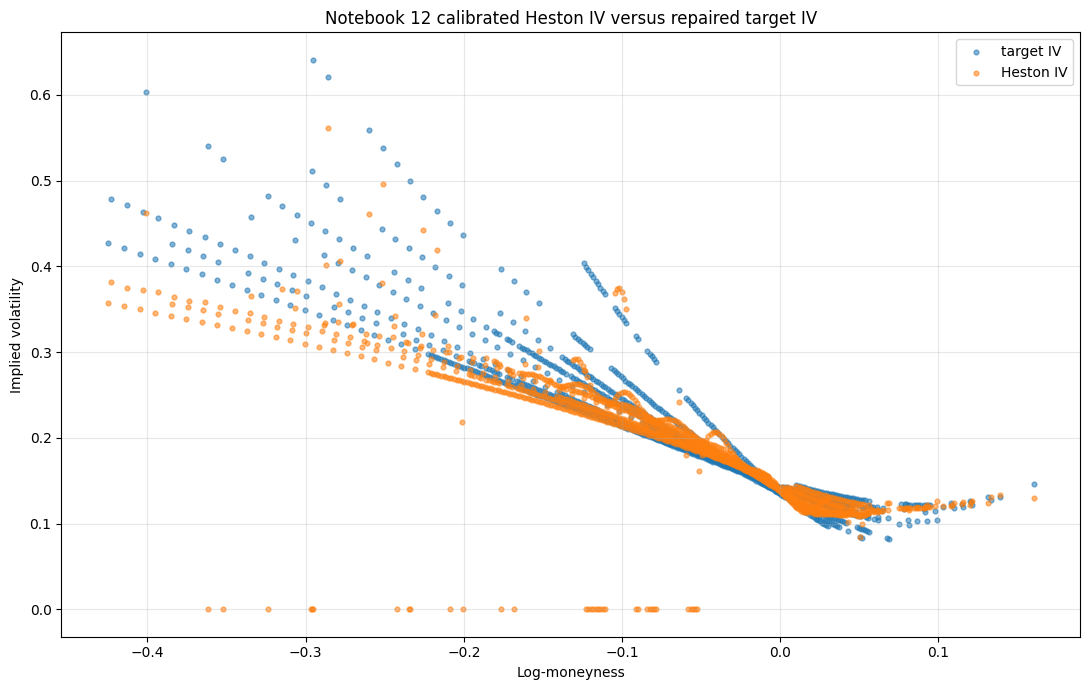

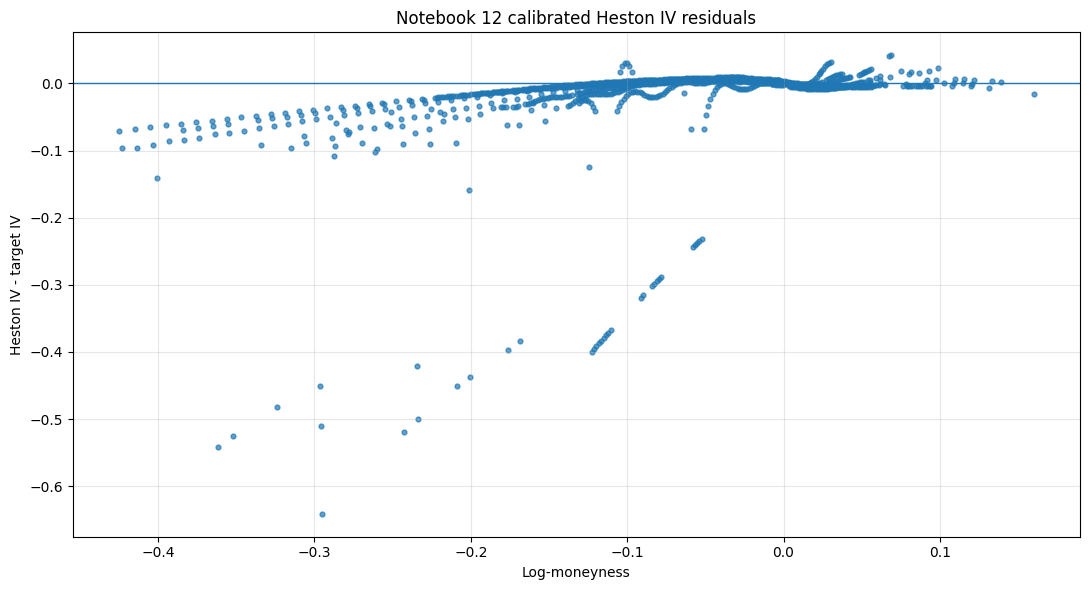

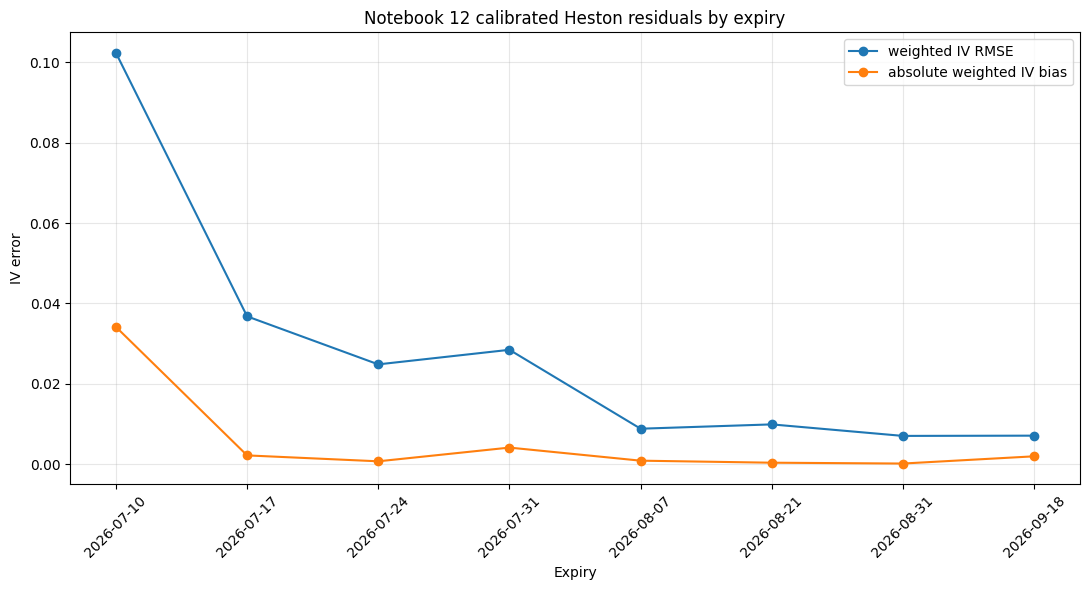

Notebook 12 Heston multistart calibration
Fit target rows:                    736
Full scoring rows:                  1,250
Start count:                        14
Finite calibration results:         14
Optimizer success count:            14
Best start id:                      6
Calibration elapsed seconds:        31.6396
Best objective:                     0.0236757601
Best fit-subset scaled RMSE:        0.0080209915
----------------------------------------------------------------------------------------
v0:                                 0.0200393466
theta:                              0.0394436036
kappa:                              8.9239017291
sigma_v:                            1.3813448976
rho:                                -0.6981892788
Feller margin:                      -1.2041320406
Boundary hit count:                 0
Boundary hit names:                 
----------------------------------------------------------------------------------------
Full weighted price RMSE:     

,run_tag,model,parameter,value,lower_bound,upper_bound,at_lower_bound_flag,at_upper_bound_flag
0,n12_20260706T023331Z,heston,v0,0.0200393466,0.0000010000,2.0000000000,False,False
1,n12_20260706T023331Z,heston,theta,0.0394436036,0.0000010000,2.0000000000,False,False
2,n12_20260706T023331Z,heston,kappa,8.9239017291,0.0010000000,20.0000000000,False,False
3,n12_20260706T023331Z,heston,sigma_v,1.3813448976,0.0010000000,5.0000000000,False,False
4,n12_20260706T023331Z,heston,rho,-0.6981892788,-0.9990000000,0.9990000000,False,False


----------------------------------------------------------------------------------------
Heston calibration summary:


,run_tag,score_label,rows,weighted_price_rmse,weighted_price_mae,weighted_price_bias,weighted_scaled_price_rmse,weighted_scaled_price_mae,weighted_scaled_price_bias,weighted_iv_rmse,weighted_iv_mae,weighted_iv_bias,finite_raw_price_rate,raw_bound_violation_rate,safe_bound_violation_rate,iv_failure_rate,model,best_start_id,optimizer_success,optimizer_nfev,optimizer_final_objective,calibration_elapsed_seconds,fit_rows_used_for_optimizer,full_rows_used_for_scoring,param_v0,param_theta,param_kappa,param_sigma_v,param_rho,boundary_hit_count,boundary_hit_names,min_relative_distance_to_bound,feller_lhs_2_kappa_theta,feller_rhs_sigma_v_sq,feller_margin,feller_ratio,feller_condition_passed,fair_iv_hurdle,fair_price_hurdle,best_simple_iv_ceiling,best_simple_price_ceiling,beats_fair_iv_hurdle,beats_fair_price_hurdle,beats_best_simple_iv_ceiling,beats_best_simple_price_ceiling
0,n12_20260706T023331Z,fit_subset_score,736,0.2713079688,0.2217189477,0.0121288501,0.0100758426,0.0065060718,-0.0011618201,0.0468105417,0.0127088006,-0.0075611713,1.0000000000,0.0461956522,0.0000000000,0.0000000000,heston,6,True,20,0.0236757601,31.6396353000,736,1250,0.0200393466,0.0394436036,8.9239017291,1.3813448976,-0.6981892788,0,,0.0100191783,0.7039816853,1.9081137260,-1.2041320406,0.3689411568,False,0.0051131876,0.2255551903,0.0037868480,0.1922602487,NaN,NaN,NaN,NaN
1,n12_20260706T023331Z,full_surface_score,1250,0.2908860496,0.2416217124,0.0291607454,0.0089953595,0.0059917832,-0.0002875316,0.0355361064,0.0094892439,-0.0040579965,1.0000000000,0.0272000000,0.0000000000,0.0000000000,heston,6,True,20,0.0236757601,31.6396353000,736,1250,0.0200393466,0.0394436036,8.9239017291,1.3813448976,-0.6981892788,0,,0.0100191783,0.7039816853,1.9081137260,-1.2041320406,0.3689411568,False,0.0051131876,0.2255551903,0.0037868480,0.1922602487,False,False,False,False


----------------------------------------------------------------------------------------
Top multistart results:


,run_tag,start_id,optimizer_success,optimizer_status,nfev,optimality,elapsed_seconds,initial_objective,final_objective,final_fit_subset_scaled_rmse,start_v0,start_theta,start_kappa,start_sigma_v,start_rho,final_v0,final_theta,final_kappa,final_sigma_v,final_rho,boundary_hit_count,boundary_hit_names,min_relative_distance_to_bound,feller_lhs_2_kappa_theta,feller_rhs_sigma_v_sq,feller_margin,feller_ratio,feller_condition_passed
0,n12_20260706T023331Z,6,True,`xtol` termination condition is satisfied.,20,0.0000039833,1.6819511000,0.1247285249,0.0236757601,0.0080209915,0.0196472422,0.0204567264,5.0000000000,1.0000000000,-0.5000000000,0.0200393466,0.0394436036,8.9239017291,1.3813448976,-0.6981892788,0,,0.0100191783,0.7039816853,1.9081137260,-1.2041320406,0.3689411568,False
1,n12_20260706T023331Z,8,True,`ftol` termination condition is satisfied.,20,0.0000309398,2.1200208000,0.0986209560,0.0236757783,0.0080209946,0.0204567264,0.0204567264,4.0000000000,1.2000000000,-0.7000000000,0.0200393650,0.0394437681,8.9237628966,1.3813457262,-0.6981878501,0,,0.0100191875,0.7039736694,1.9081160153,-1.2041423459,0.3689365132,False
2,n12_20260706T023331Z,7,True,`ftol` termination condition is satisfied.,19,0.0001047701,2.2015609000,0.1179949755,0.0236758587,0.0080210082,0.0204567264,0.0196472422,1.0000000000,0.9000000000,-0.8500000000,0.0200392713,0.0394425600,8.9246856538,1.3813698278,-0.6981919192,0,,0.0100191407,0.7040248986,1.9081826010,-1.2041577025,0.3689504863,False
3,n12_20260706T023331Z,3,True,`ftol` termination condition is satisfied.,18,0.0000688378,2.0987744000,0.1271776875,0.0236759212,0.0080210188,0.0186622898,0.0204567264,3.0000000000,0.8000000000,-0.7500000000,0.0200392750,0.0394429817,8.9244400212,1.3813754144,-0.6981889307,0,,0.0100191425,0.7040130480,1.9081980355,-1.2041849875,0.3689412917,False
4,n12_20260706T023331Z,9,True,`ftol` termination condition is satisfied.,14,0.0000275175,1.6608237000,0.2606445876,0.0236759387,0.0080210217,0.0196472422,0.0196472422,8.0000000000,0.4000000000,-0.3500000000,0.0200393363,0.0394407300,8.9258261580,1.3813994758,-0.6981945020,0,,0.0100191731,0.7040821983,1.9082645117,-1.2041823134,0.3689646765,False
5,n12_20260706T023331Z,13,True,`ftol` termination condition is satisfied.,16,0.0000094179,1.9365586000,0.2217401937,0.0236759805,0.0080210288,0.0187193821,0.0196472422,6.0000000000,1.7500000000,-0.8000000000,0.0200393913,0.0394408239,8.9256955684,1.3814005324,-0.6981903964,0,,0.0100192006,0.7040735746,1.9082674309,-1.2041938563,0.3689595930,False
6,n12_20260706T023331Z,0,True,`ftol` termination condition is satisfied.,20,0.0000055438,2.4177148000,0.1493962741,0.0236760036,0.0080210328,0.0187193821,0.0196472422,2.0000000000,0.6000000000,-0.6500000000,0.0200393446,0.0394415503,8.9252787886,1.3813968609,-0.6981884073,0,,0.0100191773,0.7040536637,1.9082572873,-1.2042036236,0.3689511202,False
7,n12_20260706T023331Z,4,True,`ftol` termination condition is satisfied.,32,0.0000136138,3.3428927000,0.1671734746,0.0236760439,0.0080210396,0.0196472422,0.0196472422,1.0000000000,0.3500000000,-0.8000000000,0.0200393352,0.0394408065,8.9258103678,1.3814137130,-0.6981913153,0,,0.0100191726,0.7040823191,1.9083038464,-1.2042215273,0.3689571346,False
8,n12_20260706T023331Z,2,True,`ftol` termination condition is satisfied.,21,0.0000087605,2.1523424000,0.1719695655,0.0236760671,0.0080210435,0.0186622898,0.0196472422,1.5000000000,0.5000000000,-0.6000000000,0.0200393461,0.0394407635,8.9258156496,1.3814153940,-0.6981898731,0,,0.0100191780,0.7040819682,1.9083084907,-1.2042265225,0.3689560528,False
9,n12_20260706T023331Z,5,True,`ftol` termination condition is satisfied.,19,0.0000232770,1.9902475000,0.1237707038,0.0236760850,0.0080210465,0.0196472422,0.0196472422,2.5000000000,0.7000000000,-0.6500000000,0.0200393199,0.0394413744,8.9254704317,1.3814139284,-0.6981885675,0,,0.0100191650,0.7040656412,1.9083044415,-1.2042388004,0.3689482799,False


----------------------------------------------------------------------------------------
Heston calibration gate:


,check_name,passed,severity,value,threshold
0,heston_fit_target_rows_sufficient,True,blocking,736.0000000000,>= 250
1,heston_multistart_finite_result_available,True,blocking,14.0000000000,> 0
2,heston_optimizer_success_available,True,warning,14.0000000000,> 0
3,heston_full_surface_prices_finite,True,blocking,1.0000000000,>= 0.99
4,heston_full_surface_safe_bounds_valid,True,blocking,0.0000000000,0
5,heston_full_surface_iv_inversion_valid,True,blocking,0.0000000000,<= 0.01
6,heston_full_surface_iv_rmse_finite,True,blocking,0.0355361064,finite
7,heston_full_surface_price_rmse_finite,True,blocking,0.2908860496,finite
8,heston_boundary_pressure_controlled,True,warning,0.0000000000,<= 2
9,heston_raw_bound_violations_diagnostic,True,warning,0.0272000000,<= 0.10


----------------------------------------------------------------------------------------
Next step: run residual localization and identifiability diagnostics for the calibrated Heston model.


In [10]:
# ============================================================
# Notebook 12 — Heston Multistart Calibration
# ============================================================
#
# Purpose:
#   Calibrate Heston to the repaired N11 surface using bounded nonlinear
#   least squares, then score the calibrated model on the full N12 target.
#
# Rule:
#   Calibration success is not the same as project success.
#   The model must be reported against:
#       1. numerical optimizer diagnostics,
#       2. no-arbitrage projection diagnostics,
#       3. baseline IV and price hurdles,
#       4. parameter stability and boundary pressure.
#
# Outputs:
#   n12_heston_fit_target
#   n12_heston_multistart_results
#   n12_heston_best_parameters
#   n12_heston_calibration_prediction_panel
#   n12_heston_calibration_summary
#   n12_heston_calibration_gate
# ============================================================

from scipy.optimize import least_squares
import time


# ------------------------------------------------------------
# Output paths for this stage
# ------------------------------------------------------------

N12_OUTPUTS.update(
    {
        "heston_fit_target_csv": N12_TABLE_DIR / f"n12_heston_fit_target_{RUN_TAG}.csv",
        "heston_fit_target_csv_latest": N12_TABLE_DIR / "n12_heston_fit_target_latest.csv",
        "heston_fit_target_parquet": N12_ARTIFACT_DIR / f"n12_heston_fit_target_{RUN_TAG}.parquet",
        "heston_fit_target_parquet_latest": N12_ARTIFACT_DIR / "n12_heston_fit_target_latest.parquet",
        "heston_multistart_results": N12_TABLE_DIR / f"n12_heston_multistart_results_{RUN_TAG}.csv",
        "heston_multistart_results_latest": N12_TABLE_DIR / "n12_heston_multistart_results_latest.csv",
        "heston_best_parameters": N12_TABLE_DIR / f"n12_heston_best_parameters_{RUN_TAG}.csv",
        "heston_best_parameters_latest": N12_TABLE_DIR / "n12_heston_best_parameters_latest.csv",
        "heston_calibration_prediction_panel_csv": N12_TABLE_DIR / f"n12_heston_calibration_prediction_panel_{RUN_TAG}.csv",
        "heston_calibration_prediction_panel_csv_latest": N12_TABLE_DIR / "n12_heston_calibration_prediction_panel_latest.csv",
        "heston_calibration_prediction_panel_parquet": N12_ARTIFACT_DIR / f"n12_heston_calibration_prediction_panel_{RUN_TAG}.parquet",
        "heston_calibration_prediction_panel_parquet_latest": N12_ARTIFACT_DIR / "n12_heston_calibration_prediction_panel_latest.parquet",
        "heston_calibration_summary": N12_TABLE_DIR / f"n12_heston_calibration_summary_{RUN_TAG}.csv",
        "heston_calibration_summary_latest": N12_TABLE_DIR / "n12_heston_calibration_summary_latest.csv",
        "heston_calibration_gate": N12_TABLE_DIR / f"n12_heston_calibration_gate_{RUN_TAG}.csv",
        "heston_calibration_gate_latest": N12_TABLE_DIR / "n12_heston_calibration_gate_latest.csv",
        "heston_calibration_manifest": N12_LOG_DIR / f"n12_heston_calibration_manifest_{RUN_TAG}.json",
        "heston_calibration_manifest_latest": N12_LOG_DIR / "n12_heston_calibration_manifest_latest.json",
        "fig_heston_iv_fit_by_moneyness": N12_FIGURE_DIR / f"n12_heston_iv_fit_by_moneyness_{RUN_TAG}.png",
        "fig_heston_iv_residual_by_moneyness": N12_FIGURE_DIR / f"n12_heston_iv_residual_by_moneyness_{RUN_TAG}.png",
        "fig_heston_residual_by_expiry": N12_FIGURE_DIR / f"n12_heston_residual_by_expiry_{RUN_TAG}.png",
    }
)


# ------------------------------------------------------------
# Guard against accidental out-of-order execution
# ------------------------------------------------------------

_REQUIRED_HESTON_CALIBRATION_INPUT_NAMES = [
    "n12_parametric_target",
    "n12_calibration_hurdles",
    "n12_parametric_seed_table",
    "heston_forward_call_price_raw",
    "heston_forward_call_price_safe",
    "heston_implied_vol_from_call_price",
    "HESTON_PARAM_ORDER",
    "HESTON_SEED_PARAMS",
    "HESTON_LOWER_BOUNDS",
    "HESTON_UPPER_BOUNDS",
    "N12_POLICY",
    "RUN_TAG",
    "N12_TABLE_DIR",
    "N12_ARTIFACT_DIR",
    "N12_FIGURE_DIR",
    "N12_LOG_DIR",
    "N12_OUTPUTS",
]

missing_required_names = [
    name for name in _REQUIRED_HESTON_CALIBRATION_INPUT_NAMES
    if name not in globals()
]

if missing_required_names:
    raise NameError(
        "Notebook 12 Heston calibration cell was run before required Heston-kernel cells. "
        f"Missing names: {missing_required_names}"
    )


# ------------------------------------------------------------
# Calibration configuration
# ------------------------------------------------------------

HESTON_CALIBRATION_NODES = 128
HESTON_CALIBRATION_UPPER = 160.0
HESTON_CALIBRATION_MAX_NFEV = 90
HESTON_CALIBRATION_LOSS = "soft_l1"
HESTON_CALIBRATION_F_SCALE = 0.015
HESTON_CALIBRATION_SUBSET_MAX_ROWS_PER_GROUP = 24
HESTON_CALIBRATION_RANDOM_SEED = RANDOM_SEED + 1205

heston_calibration_nodes, heston_calibration_weights = heston_quadrature_grid(
    n_nodes=HESTON_CALIBRATION_NODES,
    u_min=HESTON_INTEGRATION_LOWER,
    u_max=HESTON_CALIBRATION_UPPER,
)


# ------------------------------------------------------------
# Local helpers
# ------------------------------------------------------------

def lookup_hurdle_value(hurdle_name: str) -> float:
    """Read a hurdle value from n12_calibration_hurdles."""
    hit = n12_calibration_hurdles.query("hurdle_name == @hurdle_name").copy()

    if hit.empty:
        return np.nan

    return float(hit.iloc[0]["hurdle_value"])


def heston_vector_to_params(x: np.ndarray) -> Dict[str, float]:
    """Convert ordered vector to Heston parameter dict."""
    return {
        name: float(value)
        for name, value in zip(HESTON_PARAM_ORDER, np.asarray(x, dtype=float))
    }


def heston_params_to_vector(params: Dict[str, float]) -> np.ndarray:
    """Convert Heston parameter dict to ordered vector."""
    return np.array([float(params[name]) for name in HESTON_PARAM_ORDER], dtype=float)


def heston_parameter_boundary_diagnostics(
    x: np.ndarray,
    lower: np.ndarray,
    upper: np.ndarray,
    *,
    tolerance_fraction: float = 0.01,
) -> Dict[str, Any]:
    """Boundary pressure diagnostics for calibrated parameters."""
    x = np.asarray(x, dtype=float)
    lower = np.asarray(lower, dtype=float)
    upper = np.asarray(upper, dtype=float)

    width = np.maximum(upper - lower, 1.0e-12)
    distance_to_lower = (x - lower) / width
    distance_to_upper = (upper - x) / width

    lower_hit = distance_to_lower <= tolerance_fraction
    upper_hit = distance_to_upper <= tolerance_fraction

    hit_names = []

    for name, is_hit in zip(HESTON_PARAM_ORDER, lower_hit):
        if is_hit:
            hit_names.append(f"{name}:lower")

    for name, is_hit in zip(HESTON_PARAM_ORDER, upper_hit):
        if is_hit:
            hit_names.append(f"{name}:upper")

    return {
        "boundary_hit_count": int(lower_hit.sum() + upper_hit.sum()),
        "boundary_hit_names": ", ".join(hit_names),
        "min_relative_distance_to_bound": float(np.nanmin(np.minimum(distance_to_lower, distance_to_upper))),
    }


def heston_feller_diagnostics(params: Dict[str, float]) -> Dict[str, float]:
    """Feller-condition diagnostics for Heston variance process."""
    lhs = 2.0 * params["kappa"] * params["theta"]
    rhs = params["sigma_v"] ** 2

    return {
        "feller_lhs_2_kappa_theta": float(lhs),
        "feller_rhs_sigma_v_sq": float(rhs),
        "feller_margin": float(lhs - rhs),
        "feller_ratio": float(lhs / rhs) if rhs > 0 else np.nan,
        "feller_condition_passed": bool(lhs >= rhs),
    }


def select_heston_fit_target(df: pd.DataFrame) -> pd.DataFrame:
    """
    Deterministic stratified subset for optimizer speed.

    The full surface is always used for final scoring. The fit subset keeps
    all expiries and all represented moneyness buckets, including low-weight
    wings, so calibration does not become ATM-only.
    """
    work = df.copy().reset_index(drop=True)

    group_cols = ["expiry_key", "moneyness_bucket"]
    rng_seed = HESTON_CALIBRATION_RANDOM_SEED

    selected_parts = []

    for group_key, group in work.groupby(group_cols, observed=True, dropna=False):
        group = group.copy()

        n_group = len(group)
        n_take = min(HESTON_CALIBRATION_SUBSET_MAX_ROWS_PER_GROUP, n_group)

        if n_group <= n_take:
            selected_parts.append(group)
            continue

        weights = pd.to_numeric(group["calibration_weight"], errors="coerce").astype(float)
        weights = weights.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        weights = weights.clip(lower=0.0)

        if weights.sum() <= 0:
            sampled = group.sample(n=n_take, random_state=rng_seed)
        else:
            sampled = group.sample(n=n_take, weights=weights, random_state=rng_seed)

        selected_parts.append(sampled)

    selected = pd.concat(selected_parts, ignore_index=True)

    atm_rows = (
        work.sort_values(["expiry_key", "abs_log_moneyness"])
        .groupby("expiry_key", observed=True, as_index=False)
        .head(2)
    )

    selected = (
        pd.concat([selected, atm_rows], ignore_index=True)
        .drop_duplicates(subset=["source_row_id"])
        .sort_values(["expiry_rank", "log_moneyness", "source_row_id"])
        .reset_index(drop=True)
    )

    if len(selected) < min(500, len(work)):
        selected = work.copy()

    selected["heston_fit_target_flag"] = True

    return selected


def make_heston_array_pack(df: pd.DataFrame) -> Dict[str, np.ndarray]:
    """Convert a parametric target DataFrame into objective arrays."""
    return {
        "F": df["param_forward"].to_numpy(dtype=float),
        "K": df["param_strike"].to_numpy(dtype=float),
        "T": df["param_tau"].to_numpy(dtype=float),
        "r": df["param_rate"].to_numpy(dtype=float),
        "target_iv": df["param_target_iv"].to_numpy(dtype=float),
        "target_call_price": df["param_call_equivalent_price"].to_numpy(dtype=float),
        "calibration_weight": df["calibration_weight"].to_numpy(dtype=float),
        "sqrt_weight": np.sqrt(np.maximum(df["calibration_weight"].to_numpy(dtype=float), 0.0)),
        "price_scale": np.maximum(df["param_price_residual_scale"].to_numpy(dtype=float), 1.0e-8),
    }


def heston_objective_residuals(
    x: np.ndarray,
    arrays: Dict[str, np.ndarray],
    *,
    nodes: np.ndarray,
    weights: np.ndarray,
) -> np.ndarray:
    """
    Vega-scaled weighted price residuals.

    This is price-space calibration with a Black-Scholes-vega scale, so the
    residual is close to IV-space while avoiding nested IV inversion inside
    the optimizer.
    """
    x = np.asarray(x, dtype=float)

    if (
        np.any(~np.isfinite(x))
        or np.any(x < HESTON_LOWER_BOUNDS)
        or np.any(x > HESTON_UPPER_BOUNDS)
    ):
        return np.full(len(arrays["F"]), 1.0e4, dtype=float)

    params = heston_vector_to_params(x)

    try:
        model_price, _raw_violation = heston_forward_call_price_safe(
            arrays["F"],
            arrays["K"],
            arrays["T"],
            arrays["r"],
            params,
            nodes=nodes,
            weights=weights,
        )
    except Exception:
        return np.full(len(arrays["F"]), 1.0e4, dtype=float)

    residual = (
        arrays["sqrt_weight"]
        * (model_price - arrays["target_call_price"])
        / arrays["price_scale"]
    )

    residual = np.asarray(residual, dtype=float)
    residual = np.where(np.isfinite(residual), residual, 1.0e4)

    return residual


def evaluate_heston_model_on_target(
    params: Dict[str, float],
    df: pd.DataFrame,
    *,
    label: str,
    nodes: np.ndarray,
    weights: np.ndarray,
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """Score Heston parameters on a target panel."""
    work = df.copy().reset_index(drop=True)

    F = work["param_forward"].to_numpy(dtype=float)
    K = work["param_strike"].to_numpy(dtype=float)
    T = work["param_tau"].to_numpy(dtype=float)
    r = work["param_rate"].to_numpy(dtype=float)
    target_iv = work["param_target_iv"].to_numpy(dtype=float)
    target_call = work["param_call_equivalent_price"].to_numpy(dtype=float)
    w = work["calibration_weight"].to_numpy(dtype=float)
    price_scale = np.maximum(work["param_price_residual_scale"].to_numpy(dtype=float), 1.0e-8)

    raw_price = heston_forward_call_price_raw(
        F,
        K,
        T,
        r,
        params,
        nodes=nodes,
        weights=weights,
    )

    safe_price, raw_bound_violation = heston_forward_call_price_safe(
        F,
        K,
        T,
        r,
        params,
        nodes=nodes,
        weights=weights,
    )

    lower_bound, upper_bound = bsm_forward_call_bounds(F, K, T, r)

    safe_bound_violation = (
        (safe_price < lower_bound - HESTON_PRICE_BOUND_TOL)
        | (safe_price > upper_bound + HESTON_PRICE_BOUND_TOL)
    )

    implied_iv, iv_failure = heston_implied_vol_from_call_price(
        safe_price,
        F,
        K,
        T,
        r,
    )

    price_metrics = weighted_metric_summary(target_call, safe_price, w)
    iv_metrics = weighted_metric_summary(target_iv, implied_iv, w)

    scaled_residual = (safe_price - target_call) / price_scale
    scaled_metrics = weighted_metric_summary(np.zeros_like(scaled_residual), scaled_residual, w)

    panel = pd.DataFrame(
        {
            "run_tag": RUN_TAG,
            "score_label": label,
            "source_row_id": work["source_row_id"].to_numpy(dtype=int),
            "expiry_rank": work["expiry_rank"].to_numpy(dtype=int),
            "expiry_key": work["expiry_key"].astype("string").to_numpy(),
            "option_type": work["option_type"].astype("string").to_numpy(),
            "moneyness_bucket": work["moneyness_bucket"].astype("string").to_numpy(),
            "time_to_expiry": T,
            "dte_approx": work["dte_approx"].to_numpy(dtype=float),
            "forward": F,
            "strike": K,
            "log_moneyness": work["param_log_moneyness"].to_numpy(dtype=float),
            "target_iv": target_iv,
            "heston_iv": implied_iv,
            "iv_residual": implied_iv - target_iv,
            "target_call_price": target_call,
            "heston_raw_call_price": raw_price,
            "heston_safe_call_price": safe_price,
            "price_residual": safe_price - target_call,
            "scaled_price_residual": scaled_residual,
            "raw_bound_violation_flag": raw_bound_violation.astype(bool),
            "safe_bound_violation_flag": safe_bound_violation.astype(bool),
            "iv_failure_flag": iv_failure.astype(bool),
            "calibration_weight": w,
            "price_residual_scale": price_scale,
        }
    )

    summary = {
        "run_tag": RUN_TAG,
        "score_label": label,
        "rows": int(len(work)),
        "weighted_price_rmse": price_metrics["weighted_rmse"],
        "weighted_price_mae": price_metrics["weighted_mae"],
        "weighted_price_bias": price_metrics["weighted_bias"],
        "weighted_scaled_price_rmse": scaled_metrics["weighted_rmse"],
        "weighted_scaled_price_mae": scaled_metrics["weighted_mae"],
        "weighted_scaled_price_bias": scaled_metrics["weighted_bias"],
        "weighted_iv_rmse": iv_metrics["weighted_rmse"],
        "weighted_iv_mae": iv_metrics["weighted_mae"],
        "weighted_iv_bias": iv_metrics["weighted_bias"],
        "finite_raw_price_rate": float(np.isfinite(raw_price).mean()),
        "raw_bound_violation_rate": float(raw_bound_violation.mean()),
        "safe_bound_violation_rate": float(safe_bound_violation.mean()),
        "iv_failure_rate": float(iv_failure.mean()),
    }

    return panel, summary


# ------------------------------------------------------------
# Fit target and starting grid
# ------------------------------------------------------------

n12_heston_fit_target = select_heston_fit_target(n12_parametric_target)
heston_fit_arrays = make_heston_array_pack(n12_heston_fit_target)

seed_vector = heston_params_to_vector(HESTON_SEED_PARAMS)

atm_variance_by_expiry = (
    n12_parametric_target
    .sort_values(["expiry_rank", "abs_log_moneyness"])
    .groupby("expiry_key", observed=True)
    .head(1)["param_target_iv"]
    .pow(2)
    .to_numpy(dtype=float)
)

v0_q25 = float(np.quantile(atm_variance_by_expiry, 0.25))
v0_q50 = float(np.quantile(atm_variance_by_expiry, 0.50))
v0_q75 = float(np.quantile(atm_variance_by_expiry, 0.75))

raw_start_vectors = [
    seed_vector,
    np.array([v0_q25, v0_q50, 0.75, 0.25, -0.45]),
    np.array([v0_q25, v0_q50, 1.50, 0.50, -0.60]),
    np.array([v0_q25, v0_q75, 3.00, 0.80, -0.75]),
    np.array([v0_q50, v0_q50, 1.00, 0.35, -0.80]),
    np.array([v0_q50, v0_q50, 2.50, 0.70, -0.65]),
    np.array([v0_q50, v0_q75, 5.00, 1.00, -0.50]),
    np.array([v0_q75, v0_q50, 1.00, 0.90, -0.85]),
    np.array([v0_q75, v0_q75, 4.00, 1.20, -0.70]),
    np.array([v0_q50, v0_q50, 8.00, 0.40, -0.35]),
    np.array([v0_q25, v0_q25, 12.00, 1.50, -0.90]),
    np.array([v0_q75, v0_q75, 0.40, 0.20, -0.25]),
    np.array([seed_vector[0], seed_vector[1], 2.00, 0.05, seed_vector[4]]),
    np.array([seed_vector[0], seed_vector[1], 6.00, 1.75, -0.80]),
]

start_vectors = []

for raw_x in raw_start_vectors:
    clipped = np.clip(raw_x, HESTON_LOWER_BOUNDS, HESTON_UPPER_BOUNDS)

    if not any(np.allclose(clipped, existing, rtol=1.0e-10, atol=1.0e-12) for existing in start_vectors):
        start_vectors.append(clipped)

n12_heston_start_table = pd.DataFrame(
    [
        {
            "run_tag": RUN_TAG,
            "start_id": i,
            **{f"start_{name}": float(value) for name, value in zip(HESTON_PARAM_ORDER, x)},
        }
        for i, x in enumerate(start_vectors)
    ]
)


# ------------------------------------------------------------
# Multistart bounded least-squares calibration
# ------------------------------------------------------------

multistart_rows = []
result_objects = []

calibration_start_time = time.perf_counter()

for start_id, x0 in enumerate(start_vectors):
    start_time = time.perf_counter()

    initial_residual = heston_objective_residuals(
        x0,
        heston_fit_arrays,
        nodes=heston_calibration_nodes,
        weights=heston_calibration_weights,
    )

    initial_objective = 0.5 * float(np.sum(initial_residual ** 2))

    try:
        result = least_squares(
            heston_objective_residuals,
            x0=x0,
            bounds=(HESTON_LOWER_BOUNDS, HESTON_UPPER_BOUNDS),
            args=(heston_fit_arrays,),
            kwargs={
                "nodes": heston_calibration_nodes,
                "weights": heston_calibration_weights,
            },
            method="trf",
            loss=HESTON_CALIBRATION_LOSS,
            f_scale=HESTON_CALIBRATION_F_SCALE,
            x_scale=np.maximum(np.abs(seed_vector), np.array([0.02, 0.02, 2.0, 0.50, 0.30])),
            max_nfev=HESTON_CALIBRATION_MAX_NFEV,
            ftol=1.0e-8,
            xtol=1.0e-8,
            gtol=1.0e-8,
        )

        final_residual = heston_objective_residuals(
            result.x,
            heston_fit_arrays,
            nodes=heston_calibration_nodes,
            weights=heston_calibration_weights,
        )

        final_objective = 0.5 * float(np.sum(final_residual ** 2))
        final_scaled_rmse = float(np.sqrt(np.mean(final_residual ** 2)))

        status_text = str(result.message)
        success = bool(result.success)
        x_final = np.asarray(result.x, dtype=float)
        nfev = int(result.nfev)
        optimality = float(result.optimality) if np.isfinite(result.optimality) else np.nan

        result_objects.append(
            {
                "start_id": start_id,
                "result": result,
                "objective": final_objective,
                "scaled_rmse": final_scaled_rmse,
            }
        )

    except Exception as exc:
        x_final = np.full_like(x0, np.nan, dtype=float)
        final_objective = np.nan
        final_scaled_rmse = np.nan
        status_text = f"error: {type(exc).__name__}: {exc}"
        success = False
        nfev = 0
        optimality = np.nan

    elapsed = time.perf_counter() - start_time

    boundary_diag = (
        heston_parameter_boundary_diagnostics(x_final, HESTON_LOWER_BOUNDS, HESTON_UPPER_BOUNDS)
        if np.isfinite(x_final).all()
        else {
            "boundary_hit_count": np.nan,
            "boundary_hit_names": "",
            "min_relative_distance_to_bound": np.nan,
        }
    )

    final_params = (
        heston_vector_to_params(x_final)
        if np.isfinite(x_final).all()
        else {name: np.nan for name in HESTON_PARAM_ORDER}
    )

    feller_diag = (
        heston_feller_diagnostics(final_params)
        if np.isfinite(x_final).all()
        else {
            "feller_lhs_2_kappa_theta": np.nan,
            "feller_rhs_sigma_v_sq": np.nan,
            "feller_margin": np.nan,
            "feller_ratio": np.nan,
            "feller_condition_passed": False,
        }
    )

    multistart_rows.append(
        {
            "run_tag": RUN_TAG,
            "start_id": start_id,
            "optimizer_success": success,
            "optimizer_status": status_text,
            "nfev": nfev,
            "optimality": optimality,
            "elapsed_seconds": elapsed,
            "initial_objective": initial_objective,
            "final_objective": final_objective,
            "final_fit_subset_scaled_rmse": final_scaled_rmse,
            **{f"start_{name}": float(value) for name, value in zip(HESTON_PARAM_ORDER, x0)},
            **{f"final_{name}": float(value) for name, value in final_params.items()},
            **boundary_diag,
            **feller_diag,
        }
    )

heston_calibration_elapsed_seconds = time.perf_counter() - calibration_start_time

n12_heston_multistart_results = (
    pd.DataFrame(multistart_rows)
    .sort_values(["final_objective", "start_id"], na_position="last")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Select best finite calibration result
# ------------------------------------------------------------

finite_results = n12_heston_multistart_results.loc[
    np.isfinite(n12_heston_multistart_results["final_objective"])
].copy()

if finite_results.empty:
    raise RuntimeError("All Heston multistart calibrations failed numerically.")

best_result_row = finite_results.iloc[0].to_dict()
best_start_id = int(best_result_row["start_id"])

best_x = np.array(
    [best_result_row[f"final_{name}"] for name in HESTON_PARAM_ORDER],
    dtype=float,
)

n12_heston_best_params = heston_vector_to_params(best_x)

best_boundary_diag = heston_parameter_boundary_diagnostics(
    best_x,
    HESTON_LOWER_BOUNDS,
    HESTON_UPPER_BOUNDS,
)

best_feller_diag = heston_feller_diagnostics(n12_heston_best_params)

n12_heston_best_parameters = pd.DataFrame(
    [
        {
            "run_tag": RUN_TAG,
            "model": "heston",
            "parameter": name,
            "value": n12_heston_best_params[name],
            "lower_bound": float(lower),
            "upper_bound": float(upper),
            "at_lower_bound_flag": bool(abs(n12_heston_best_params[name] - lower) <= 0.01 * max(upper - lower, 1.0e-12)),
            "at_upper_bound_flag": bool(abs(upper - n12_heston_best_params[name]) <= 0.01 * max(upper - lower, 1.0e-12)),
        }
        for name, lower, upper in zip(HESTON_PARAM_ORDER, HESTON_LOWER_BOUNDS, HESTON_UPPER_BOUNDS)
    ]
)


# ------------------------------------------------------------
# Full-surface scoring with production quadrature
# ------------------------------------------------------------

heston_fit_panel, heston_fit_summary = evaluate_heston_model_on_target(
    n12_heston_best_params,
    n12_heston_fit_target,
    label="fit_subset_score",
    nodes=quad_nodes,
    weights=quad_weights,
)

heston_full_panel, heston_full_summary = evaluate_heston_model_on_target(
    n12_heston_best_params,
    n12_parametric_target,
    label="full_surface_score",
    nodes=quad_nodes,
    weights=quad_weights,
)

n12_heston_calibration_prediction_panel = pd.concat(
    [heston_fit_panel, heston_full_panel],
    ignore_index=True,
)

fair_iv_hurdle = lookup_hurdle_value("fair_parametric_iv_hurdle")
fair_price_hurdle = lookup_hurdle_value("fair_parametric_price_hurdle")
best_simple_iv_ceiling = lookup_hurdle_value("best_simple_surface_fit_ceiling_iv")
best_simple_price_ceiling = lookup_hurdle_value("best_simple_surface_fit_ceiling_price")

heston_beats_fair_iv_hurdle = bool(
    np.isfinite(heston_full_summary["weighted_iv_rmse"])
    and np.isfinite(fair_iv_hurdle)
    and heston_full_summary["weighted_iv_rmse"] <= fair_iv_hurdle
)

heston_beats_fair_price_hurdle = bool(
    np.isfinite(heston_full_summary["weighted_price_rmse"])
    and np.isfinite(fair_price_hurdle)
    and heston_full_summary["weighted_price_rmse"] <= fair_price_hurdle
)

heston_beats_best_simple_iv_ceiling = bool(
    np.isfinite(heston_full_summary["weighted_iv_rmse"])
    and np.isfinite(best_simple_iv_ceiling)
    and heston_full_summary["weighted_iv_rmse"] <= best_simple_iv_ceiling
)

heston_beats_best_simple_price_ceiling = bool(
    np.isfinite(heston_full_summary["weighted_price_rmse"])
    and np.isfinite(best_simple_price_ceiling)
    and heston_full_summary["weighted_price_rmse"] <= best_simple_price_ceiling
)

n12_heston_calibration_summary = pd.DataFrame(
    [
        {
            **heston_fit_summary,
            "model": "heston",
            "best_start_id": best_start_id,
            "optimizer_success": bool(best_result_row["optimizer_success"]),
            "optimizer_nfev": int(best_result_row["nfev"]),
            "optimizer_final_objective": float(best_result_row["final_objective"]),
            "calibration_elapsed_seconds": float(heston_calibration_elapsed_seconds),
            "fit_rows_used_for_optimizer": int(len(n12_heston_fit_target)),
            "full_rows_used_for_scoring": int(len(n12_parametric_target)),
            **{f"param_{name}": n12_heston_best_params[name] for name in HESTON_PARAM_ORDER},
            **best_boundary_diag,
            **best_feller_diag,
            "fair_iv_hurdle": fair_iv_hurdle,
            "fair_price_hurdle": fair_price_hurdle,
            "best_simple_iv_ceiling": best_simple_iv_ceiling,
            "best_simple_price_ceiling": best_simple_price_ceiling,
            "beats_fair_iv_hurdle": np.nan,
            "beats_fair_price_hurdle": np.nan,
            "beats_best_simple_iv_ceiling": np.nan,
            "beats_best_simple_price_ceiling": np.nan,
        },
        {
            **heston_full_summary,
            "model": "heston",
            "best_start_id": best_start_id,
            "optimizer_success": bool(best_result_row["optimizer_success"]),
            "optimizer_nfev": int(best_result_row["nfev"]),
            "optimizer_final_objective": float(best_result_row["final_objective"]),
            "calibration_elapsed_seconds": float(heston_calibration_elapsed_seconds),
            "fit_rows_used_for_optimizer": int(len(n12_heston_fit_target)),
            "full_rows_used_for_scoring": int(len(n12_parametric_target)),
            **{f"param_{name}": n12_heston_best_params[name] for name in HESTON_PARAM_ORDER},
            **best_boundary_diag,
            **best_feller_diag,
            "fair_iv_hurdle": fair_iv_hurdle,
            "fair_price_hurdle": fair_price_hurdle,
            "best_simple_iv_ceiling": best_simple_iv_ceiling,
            "best_simple_price_ceiling": best_simple_price_ceiling,
            "beats_fair_iv_hurdle": heston_beats_fair_iv_hurdle,
            "beats_fair_price_hurdle": heston_beats_fair_price_hurdle,
            "beats_best_simple_iv_ceiling": heston_beats_best_simple_iv_ceiling,
            "beats_best_simple_price_ceiling": heston_beats_best_simple_price_ceiling,
        },
    ]
)


# ------------------------------------------------------------
# Calibration gate
# ------------------------------------------------------------

optimizer_success_count = int(n12_heston_multistart_results["optimizer_success"].sum())
finite_result_count = int(np.isfinite(n12_heston_multistart_results["final_objective"]).sum())

full_safe_bound_violation_rate = float(heston_full_summary["safe_bound_violation_rate"])
full_iv_failure_rate = float(heston_full_summary["iv_failure_rate"])
full_finite_price_rate = float(heston_full_summary["finite_raw_price_rate"])
full_raw_bound_violation_rate = float(heston_full_summary["raw_bound_violation_rate"])

n12_heston_calibration_gate = pd.DataFrame(
    [
        build_check(
            "heston_fit_target_rows_sufficient",
            len(n12_heston_fit_target) >= N12_POLICY.min_total_rows_for_parametric_calibration,
            "blocking",
            "Heston optimizer fit subset must retain enough rows.",
            int(len(n12_heston_fit_target)),
            f">= {N12_POLICY.min_total_rows_for_parametric_calibration}",
        ),
        build_check(
            "heston_multistart_finite_result_available",
            finite_result_count > 0,
            "blocking",
            "At least one Heston start must produce a finite objective.",
            finite_result_count,
            "> 0",
        ),
        build_check(
            "heston_optimizer_success_available",
            optimizer_success_count > 0,
            "warning",
            "At least one optimizer run should report success.",
            optimizer_success_count,
            "> 0",
        ),
        build_check(
            "heston_full_surface_prices_finite",
            full_finite_price_rate >= 0.99,
            "blocking",
            "Calibrated raw Heston prices must be finite for nearly all full-surface rows.",
            full_finite_price_rate,
            ">= 0.99",
        ),
        build_check(
            "heston_full_surface_safe_bounds_valid",
            full_safe_bound_violation_rate == 0.0,
            "blocking",
            "Projected calibrated Heston prices must satisfy call bounds.",
            full_safe_bound_violation_rate,
            "0",
        ),
        build_check(
            "heston_full_surface_iv_inversion_valid",
            full_iv_failure_rate <= 0.01,
            "blocking",
            "Projected calibrated Heston prices must invert to IVs for nearly all rows.",
            full_iv_failure_rate,
            "<= 0.01",
        ),
        build_check(
            "heston_full_surface_iv_rmse_finite",
            np.isfinite(heston_full_summary["weighted_iv_rmse"]),
            "blocking",
            "Full-surface calibrated Heston IV RMSE must be finite.",
            heston_full_summary["weighted_iv_rmse"],
            "finite",
        ),
        build_check(
            "heston_full_surface_price_rmse_finite",
            np.isfinite(heston_full_summary["weighted_price_rmse"]),
            "blocking",
            "Full-surface calibrated Heston price RMSE must be finite.",
            heston_full_summary["weighted_price_rmse"],
            "finite",
        ),
        build_check(
            "heston_boundary_pressure_controlled",
            best_boundary_diag["boundary_hit_count"] <= 2,
            "warning",
            "Too many boundary hits suggest weak identifiability or parameter degeneracy.",
            best_boundary_diag["boundary_hit_count"],
            "<= 2",
        ),
        build_check(
            "heston_raw_bound_violations_diagnostic",
            full_raw_bound_violation_rate <= 0.10,
            "warning",
            "Raw Heston price bound leakage should remain diagnostic rather than dominant.",
            full_raw_bound_violation_rate,
            "<= 0.10",
        ),
        build_check(
            "heston_beats_fair_iv_hurdle",
            heston_beats_fair_iv_hurdle,
            "warning",
            "Calibrated Heston should beat the low-complexity IV baseline to earn empirical fit credit.",
            heston_full_summary["weighted_iv_rmse"],
            f"<= {fair_iv_hurdle}",
        ),
        build_check(
            "heston_beats_fair_price_hurdle",
            heston_beats_fair_price_hurdle,
            "warning",
            "Calibrated Heston should beat the low-complexity price baseline to earn empirical fit credit.",
            heston_full_summary["weighted_price_rmse"],
            f"<= {fair_price_hurdle}",
        ),
        build_check(
            "heston_feller_condition",
            bool(best_feller_diag["feller_condition_passed"]),
            "warning",
            "Feller condition is diagnostic, not required for pricing, but failure signals variance-boundary pressure.",
            best_feller_diag["feller_margin"],
            ">= 0",
        ),
    ]
)

heston_calibration_blocking_failures = n12_heston_calibration_gate.query(
    "severity == 'blocking' and passed == False"
).copy()

heston_calibration_gate_passed = bool(heston_calibration_blocking_failures.empty)


# ------------------------------------------------------------
# Persist artifacts
# ------------------------------------------------------------

write_table(
    n12_heston_multistart_results,
    N12_OUTPUTS["heston_multistart_results"],
    N12_OUTPUTS["heston_multistart_results_latest"],
)

write_table(
    n12_heston_best_parameters,
    N12_OUTPUTS["heston_best_parameters"],
    N12_OUTPUTS["heston_best_parameters_latest"],
)

write_table(
    n12_heston_calibration_summary,
    N12_OUTPUTS["heston_calibration_summary"],
    N12_OUTPUTS["heston_calibration_summary_latest"],
)

write_table(
    n12_heston_calibration_gate,
    N12_OUTPUTS["heston_calibration_gate"],
    N12_OUTPUTS["heston_calibration_gate_latest"],
)

n12_heston_fit_target_persist_format = write_parquet_with_fallback(
    n12_heston_fit_target,
    N12_OUTPUTS["heston_fit_target_parquet"],
    N12_OUTPUTS["heston_fit_target_csv"],
)

_ = write_parquet_with_fallback(
    n12_heston_fit_target,
    N12_OUTPUTS["heston_fit_target_parquet_latest"],
    N12_OUTPUTS["heston_fit_target_csv_latest"],
)

n12_heston_prediction_persist_format = write_parquet_with_fallback(
    n12_heston_calibration_prediction_panel,
    N12_OUTPUTS["heston_calibration_prediction_panel_parquet"],
    N12_OUTPUTS["heston_calibration_prediction_panel_csv"],
)

_ = write_parquet_with_fallback(
    n12_heston_calibration_prediction_panel,
    N12_OUTPUTS["heston_calibration_prediction_panel_parquet_latest"],
    N12_OUTPUTS["heston_calibration_prediction_panel_csv_latest"],
)

n12_heston_calibration_manifest = {
    "run_tag": RUN_TAG,
    "model": "heston",
    "param_order": list(HESTON_PARAM_ORDER),
    "best_start_id": best_start_id,
    "best_params": n12_heston_best_params,
    "optimizer_success_count": optimizer_success_count,
    "finite_result_count": finite_result_count,
    "total_start_count": len(start_vectors),
    "calibration_nodes": HESTON_CALIBRATION_NODES,
    "calibration_upper": HESTON_CALIBRATION_UPPER,
    "scoring_nodes": HESTON_QUADRATURE_NODES,
    "scoring_upper": HESTON_INTEGRATION_UPPER,
    "fit_subset_rows": int(len(n12_heston_fit_target)),
    "full_surface_rows": int(len(n12_parametric_target)),
    "full_weighted_iv_rmse": float(heston_full_summary["weighted_iv_rmse"]),
    "full_weighted_price_rmse": float(heston_full_summary["weighted_price_rmse"]),
    "fair_iv_hurdle": float(fair_iv_hurdle),
    "fair_price_hurdle": float(fair_price_hurdle),
    "beats_fair_iv_hurdle": heston_beats_fair_iv_hurdle,
    "beats_fair_price_hurdle": heston_beats_fair_price_hurdle,
    "beats_best_simple_iv_ceiling": heston_beats_best_simple_iv_ceiling,
    "beats_best_simple_price_ceiling": heston_beats_best_simple_price_ceiling,
    "boundary_diagnostics": best_boundary_diag,
    "feller_diagnostics": best_feller_diag,
    "calibration_gate_passed": heston_calibration_gate_passed,
}

write_json(
    n12_heston_calibration_manifest,
    N12_OUTPUTS["heston_calibration_manifest"],
)

write_json(
    n12_heston_calibration_manifest,
    N12_OUTPUTS["heston_calibration_manifest_latest"],
)


# ------------------------------------------------------------
# Figures
# ------------------------------------------------------------

N12_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

heston_full_plot = heston_full_panel.copy()

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(
    heston_full_plot["log_moneyness"],
    heston_full_plot["target_iv"],
    s=12,
    alpha=0.55,
    label="target IV",
)
ax.scatter(
    heston_full_plot["log_moneyness"],
    heston_full_plot["heston_iv"],
    s=12,
    alpha=0.55,
    label="Heston IV",
)
ax.set_title("Notebook 12 calibrated Heston IV versus repaired target IV")
ax.set_xlabel("Log-moneyness")
ax.set_ylabel("Implied volatility")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(N12_OUTPUTS["fig_heston_iv_fit_by_moneyness"], dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(
    heston_full_plot["log_moneyness"],
    heston_full_plot["iv_residual"],
    s=12,
    alpha=0.70,
)
ax.axhline(0.0, linewidth=1)
ax.set_title("Notebook 12 calibrated Heston IV residuals")
ax.set_xlabel("Log-moneyness")
ax.set_ylabel("Heston IV - target IV")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(N12_OUTPUTS["fig_heston_iv_residual_by_moneyness"], dpi=160)
plt.show()

expiry_residual_summary = (
    heston_full_plot
    .groupby(["expiry_rank", "expiry_key"], observed=True)
    .agg(
        weighted_iv_rmse=(
            "iv_residual",
            lambda x: np.sqrt(
                np.average(
                    np.asarray(x, dtype=float) ** 2,
                    weights=heston_full_plot.loc[x.index, "calibration_weight"].to_numpy(dtype=float),
                )
            ),
        ),
        weighted_iv_bias=(
            "iv_residual",
            lambda x: np.average(
                np.asarray(x, dtype=float),
                weights=heston_full_plot.loc[x.index, "calibration_weight"].to_numpy(dtype=float),
            ),
        ),
    )
    .reset_index()
    .sort_values("expiry_rank")
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(
    expiry_residual_summary["expiry_key"].astype(str),
    expiry_residual_summary["weighted_iv_rmse"],
    marker="o",
    label="weighted IV RMSE",
)
ax.plot(
    expiry_residual_summary["expiry_key"].astype(str),
    expiry_residual_summary["weighted_iv_bias"].abs(),
    marker="o",
    label="absolute weighted IV bias",
)
ax.set_title("Notebook 12 calibrated Heston residuals by expiry")
ax.set_xlabel("Expiry")
ax.set_ylabel("IV error")
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(N12_OUTPUTS["fig_heston_residual_by_expiry"], dpi=160)
plt.show()


# ------------------------------------------------------------
# Reader-facing output
# ------------------------------------------------------------

print("=" * 88)
print("Notebook 12 Heston multistart calibration")
print("=" * 88)
print(f"Fit target rows:                    {len(n12_heston_fit_target):,}")
print(f"Full scoring rows:                  {len(n12_parametric_target):,}")
print(f"Start count:                        {len(start_vectors):,}")
print(f"Finite calibration results:         {finite_result_count:,}")
print(f"Optimizer success count:            {optimizer_success_count:,}")
print(f"Best start id:                      {best_start_id}")
print(f"Calibration elapsed seconds:        {heston_calibration_elapsed_seconds:,.4f}")
print(f"Best objective:                     {float(best_result_row['final_objective']):,.10f}")
print(f"Best fit-subset scaled RMSE:        {float(best_result_row['final_fit_subset_scaled_rmse']):,.10f}")
print("-" * 88)
print(f"v0:                                 {n12_heston_best_params['v0']:,.10f}")
print(f"theta:                              {n12_heston_best_params['theta']:,.10f}")
print(f"kappa:                              {n12_heston_best_params['kappa']:,.10f}")
print(f"sigma_v:                            {n12_heston_best_params['sigma_v']:,.10f}")
print(f"rho:                                {n12_heston_best_params['rho']:,.10f}")
print(f"Feller margin:                      {best_feller_diag['feller_margin']:,.10f}")
print(f"Boundary hit count:                 {best_boundary_diag['boundary_hit_count']}")
print(f"Boundary hit names:                 {best_boundary_diag['boundary_hit_names']}")
print("-" * 88)
print(f"Full weighted price RMSE:           {heston_full_summary['weighted_price_rmse']:,.10f}")
print(f"Full weighted IV RMSE:              {heston_full_summary['weighted_iv_rmse']:,.10f}")
print(f"Full raw bound violation rate:      {heston_full_summary['raw_bound_violation_rate']:,.6f}")
print(f"Full safe bound violation rate:     {heston_full_summary['safe_bound_violation_rate']:,.6f}")
print(f"Full IV inversion failure rate:     {heston_full_summary['iv_failure_rate']:,.6f}")
print(f"Fair IV hurdle:                     {fair_iv_hurdle:,.10f}")
print(f"Fair price hurdle:                  {fair_price_hurdle:,.10f}")
print(f"Beats fair IV hurdle:               {heston_beats_fair_iv_hurdle}")
print(f"Beats fair price hurdle:            {heston_beats_fair_price_hurdle}")
print(f"Beats best simple IV ceiling:       {heston_beats_best_simple_iv_ceiling}")
print(f"Beats best simple price ceiling:    {heston_beats_best_simple_price_ceiling}")
print(f"Prediction panel persisted as:      {n12_heston_prediction_persist_format}")
print(f"Heston calibration gate passed:     {heston_calibration_gate_passed}")
print("-" * 88)

print("Heston best parameters:")
display_or_print(n12_heston_best_parameters)

print("-" * 88)
print("Heston calibration summary:")
display_or_print(n12_heston_calibration_summary)

print("-" * 88)
print("Top multistart results:")
display_or_print(n12_heston_multistart_results.head(10))

print("-" * 88)
print("Heston calibration gate:")
display_or_print(n12_heston_calibration_gate[["check_name", "passed", "severity", "value", "threshold"]])

if not heston_calibration_gate_passed:
    print("-" * 88)
    print("Blocking failures:")
    display_or_print(heston_calibration_blocking_failures[["check_name", "value", "threshold", "detail"]])
    raise RuntimeError(
        "Notebook 12 Heston calibration failed numerically. Do not proceed to Bates until this is fixed."
    )

print("-" * 88)
print("Next step: run residual localization and identifiability diagnostics for the calibrated Heston model.")

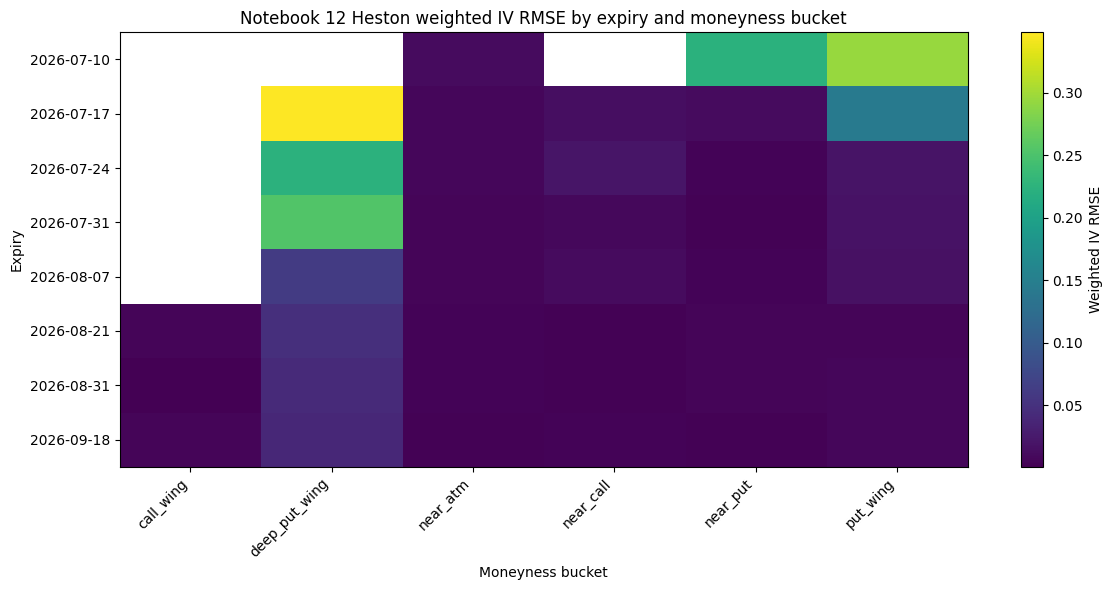

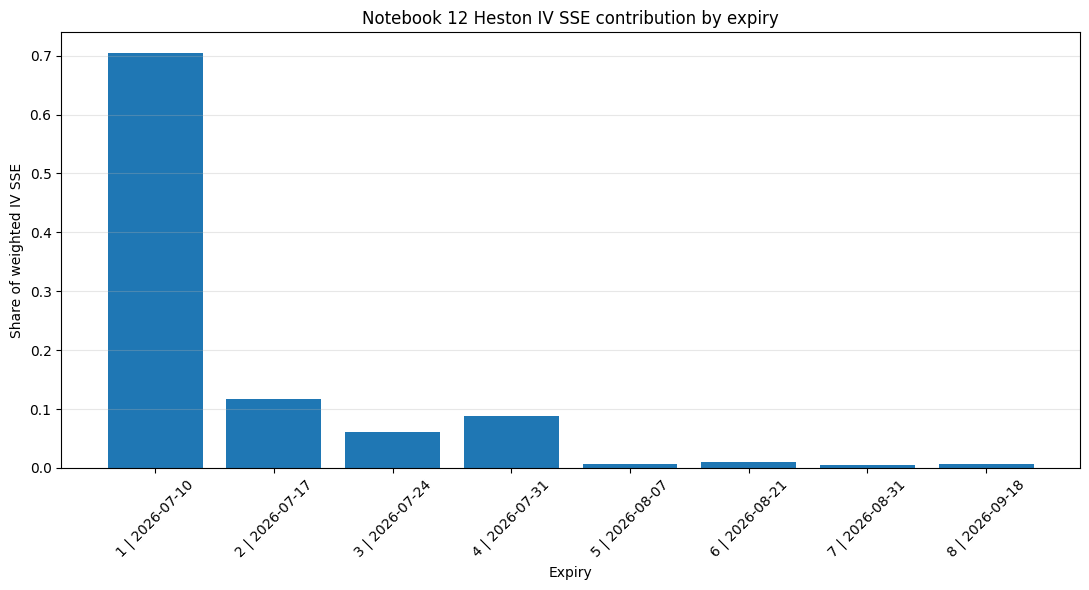

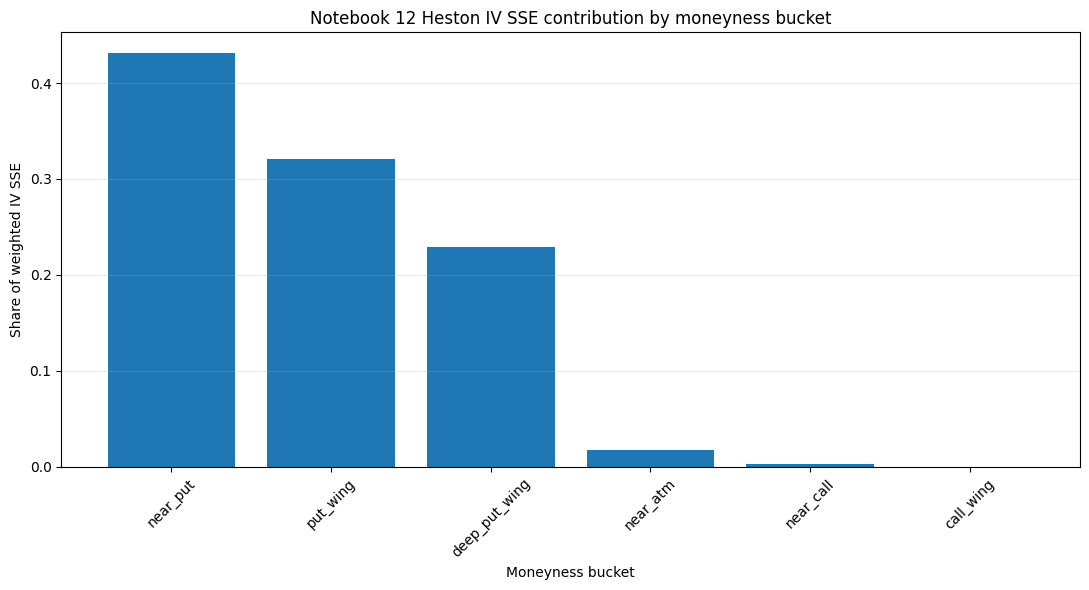

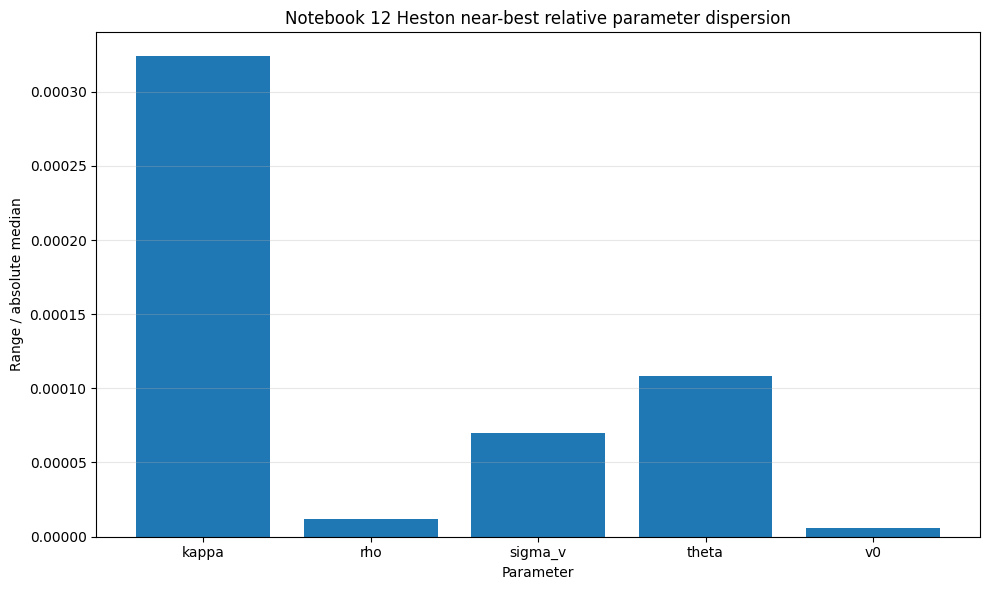

Notebook 12 Heston residual localization and identifiability diagnostics
Full diagnostic rows:                  1,250
Weighted IV RMSE:                      0.0355361064
Weighted price RMSE:                   0.2908860496
IV floor rows / rate:                  34 / 0.027200
Top 5% IV SSE contribution share:      0.945637
Worst expiry IV SSE contribution:      0.704326
Worst bucket IV SSE contribution:      0.431291
Near-best start count:                 14
Near-best max relative param range:    0.0003238861
Diagnostics gate passed:               True
----------------------------------------------------------------------------------------
Overall Heston residual summary:


,run_tag,model,rows,expiries,unique_strikes,weighted_iv_rmse,weighted_iv_mae,weighted_iv_bias,iv_abs_error_p95,iv_abs_error_p99,iv_abs_error_max,weighted_price_rmse,weighted_price_mae,weighted_price_bias,price_abs_error_p95,price_abs_error_p99,price_abs_error_max,weighted_scaled_price_rmse,raw_bound_violation_rate,safe_bound_violation_rate,iv_failure_rate,iv_floor_rows,iv_floor_rate,left_tail_rows,right_tail_rows,central_rows
0,n12_20260706T023331Z,heston,1250,8,253,0.0355361064,0.0094892439,-0.0040579965,0.0697804349,0.3959659942,0.6409726713,0.2908860496,0.2416217124,0.0291607454,0.5546416846,0.6110599908,0.6213897447,0.0089953595,0.0272000000,0.0000000000,0.0000000000,34,0.0272000000,128,13,827


----------------------------------------------------------------------------------------
Top residual localization groups:


,run_tag,dimension,group_label,group_columns,rows,weight_sum,expiry_count,strike_count,min_dte,median_dte,max_dte,min_log_moneyness,median_log_moneyness,max_log_moneyness,target_iv_median,heston_iv_median,weighted_iv_rmse,weighted_iv_mae,weighted_iv_bias,iv_abs_error_p95,iv_abs_error_max,weighted_price_rmse,weighted_price_mae,weighted_price_bias,price_abs_error_p95,price_abs_error_max,weighted_scaled_price_rmse,iv_sse,price_sse,iv_sse_share,price_sse_share,raw_bound_violation_rate,safe_bound_violation_rate,iv_failure_rate,iv_floor_rate
71,n12_20260706T023331Z,option_type,put,option_type,918,526.0252949302,8,174,5.0034246575,33.0226027397,75.0513698630,-0.4252077096,-0.0890334548,0.0045570342,0.2220185206,0.2164110728,0.0439834939,0.0121099933,-0.0056850072,0.0902512150,0.6409726713,0.2905436445,0.2446766785,0.1525639418,0.5634049187,0.6213897447,0.0096440763,1.0176210417,44.4047457994,0.9881495764,0.6435168074,0.0370370370,0.0000000000,0.0000000000,0.0370370370
0,n12_20260706T023331Z,expiry,1 | 2026-07-10,"expiry_rank, expiry_key",97,69.2986225310,1,97,5.0034246575,5.0034246575,5.0034246575,-0.1242195547,-0.0258744712,0.0303652471,0.1806038007,0.1396138347,0.1023072453,0.0423608799,-0.0341724326,0.3799127373,0.3993832331,0.1073627815,0.0904137401,-0.0006226569,0.1808253253,0.2026043106,0.0168146611,0.7253329127,0.7987890645,0.7043264448,0.0115761092,0.2164948454,0.0000000000,0.0000000000,0.2164948454
49,n12_20260706T023331Z,expiry_x_option_type,1 | 2026-07-10 | put,"expiry_rank, expiry_key, option_type",68,42.6980645771,1,68,5.0034246575,5.0034246575,5.0034246575,-0.1242195547,-0.0460493154,-0.0027284413,0.2192542430,0.1624275181,0.1299714370,0.0639146579,-0.0595200683,0.3856996043,0.3993832331,0.1213405261,0.1040242223,-0.0237577750,0.1825840709,0.2026043106,0.0170253224,0.7212802338,0.6286659481,0.7003911361,0.0091106727,0.3088235294,0.0000000000,0.0000000000,0.3088235294
65,n12_20260706T023331Z,moneyness_bucket,near_put,moneyness_bucket,249,188.6545368035,8,39,5.0034246575,33.0226027397,75.0513698630,-0.0994848808,-0.0740348941,-0.0501316803,0.2064097838,0.2074109895,0.0485214060,0.0137603453,-0.0073310113,0.0679049242,0.3190223556,0.2526706703,0.2031936815,0.1695894878,0.4914667206,0.5921952380,0.0091371887,0.4441544394,12.0441711600,0.4312912206,0.1745450049,0.0481927711,0.0000000000,0.0000000000,0.0481927711
8,n12_20260706T023331Z,expiry_x_moneyness_bucket,1 | 2026-07-10 | near_put,"expiry_rank, expiry_key, moneyness_bucket",17,8.8759048107,1,17,5.0034246575,5.0034246575,5.0034246575,-0.0987117952,-0.0781832150,-0.0509803923,0.2881906215,0.0000010000,0.2220551985,0.2000692234,-0.1975364034,0.3162086505,0.3190223556,0.1550484436,0.1445984386,-0.1400517146,0.2015053060,0.2026043106,0.0335667913,0.4376576517,0.2133769280,0.4249825873,0.0030922740,0.7058823529,0.0000000000,0.0000000000,0.7058823529
66,n12_20260706T023331Z,moneyness_bucket,put_wing,moneyness_bucket,282,91.3778458643,8,65,5.0034246575,47.0321917808,75.0513698630,-0.1996181726,-0.1327849749,-0.1000625327,0.2609954791,0.2482392207,0.0600784740,0.0180274661,-0.0169729604,0.0555935143,0.3993832331,0.2094668911,0.1763163859,-0.1544853677,0.4774449419,0.5497768528,0.0107916313,0.3298213022,4.0093289490,0.3202693014,0.0581034869,0.0390070922,0.0000000000,0.0000000000,0.0390070922
9,n12_20260706T023331Z,expiry_x_moneyness_bucket,1 | 2026-07-10 | put_wing,"expiry_rank, expiry_key, moneyness_bucket",14,3.2528134870,1,14,5.0034246575,5.0034246575,5.0034246575,-0.1242195547,-0.1143898910,-0.1001943751,0.3771031647,0.0000010000,0.2941172713,0.2390762584,-0.2208226595,0.3967157928,0.3993832331,0.0457525774,0.0451859961,-0.0135569461,0.0539831965,0.0544946194,0.0159265017,0.2813845308,0.0068091091,0.2732353141,0.0000986781,0.6428571429,0.0000000000,0.0000000000,0.6428571429
67,n12_20260706T023331Z,moneyness_bucket,deep_put_wing,moneyness_bucket,128,12.3481225227,7,36,12.0082191781,47.0321917808,75.0513698630,-0.4252077096,-0.2703751527,-0.2006162976,0.3844620824,0.3155822733

----------------------------------------------------------------------------------------
Tail contribution diagnostics:


...

----------------------------------------------------------------------------------------
Heston versus baseline localization:


,run_tag,model_label,group_columns,group_label,rows,weighted_iv_rmse,weighted_iv_mae,weighted_iv_bias,weighted_price_rmse,weighted_price_mae,weighted_price_bias,dimension
0,n12_20260706T023331Z,expiry_quadratic_k_iv,"expiry_rank, expiry_key",1 | 2026-07-10,97,0.0005078385,0.0004295580,-0.0000000000,0.0096213806,0.0068732297,0.0045629267,expiry
1,n12_20260706T023331Z,global_surface_quadratic_iv,"expiry_rank, expiry_key",1 | 2026-07-10,97,0.0083332602,0.0041879004,-0.0037498158,0.0253440373,0.0221946549,-0.0100015636,expiry
2,n12_20260706T023331Z,heston_calibrated,"expiry_rank, expiry_key",1 | 2026-07-10,97,0.1023072453,0.0423608799,-0.0341724326,0.1073627815,0.0904137401,-0.0006226569,expiry
3,n12_20260706T023331Z,expiry_quadratic_k_iv,"expiry_rank, expiry_key",2 | 2026-07-17,127,0.0009992951,0.0007066645,0.0000000000,0.0184511977,0.0149919841,0.0080058107,expiry
4,n12_20260706T023331Z,global_surface_quadratic_iv,"expiry_rank, expiry_key",2 | 2026-07-17,127,0.0049738276,0.0044115326,0.0037912738,0.1410067077,0.1161003676,0.1121307216,expiry
5,n12_20260706T023331Z,heston_calibrated,"expiry_rank, expiry_key",2 | 2026-07-17,127,0.0367984843,0.0096909328,-0.0022310916,0.1716530869,0.1389669507,0.0797430714,expiry
6,n12_20260706T023331Z,expiry_quadratic_k_iv,"expiry_rank, expiry_key",3 | 2026-07-24,152,0.0015131728,0.0011283872,-0.0000000000,0.0425002621,0.0339233373,0.0203448223,expiry
7,n12_20260706T023331Z,global_surface_quadratic_iv,"expiry_rank, expiry_key",3 | 2026-07-24,152,0.0041281392,0.0036936455,0.0034926915,0.1645714515,0.1370115823,0.1362214809,expiry
8,n12_20260706T023331Z,heston_calibrated,"expiry_rank, expiry_key",3 | 2026-07-24,152,0.0248621432,0.0082471776,0.0007615213,0.2446504502,0.1982956825,0.1227305996,expiry
9,n12_20260706T023331Z,expiry_quadratic_k_iv,"expiry_rank, expiry_key",4 | 2026-07-31,175,0.0028017368,0.0021251313,0.0000000000,0.1013521474,0.0796263898,0.0470853184,expiry


----------------------------------------------------------------------------------------
Heston diagnostics gate:


,check_name,passed,severity,value,threshold
0,heston_full_diagnostic_panel_nonempty,True,blocking,1250,> 0
1,heston_diagnostic_tables_nonempty,True,blocking,True,True
2,heston_overall_iv_rmse_finite,True,blocking,0.0355361064,finite
3,heston_overall_price_rmse_finite,True,blocking,0.2908860496,finite
4,heston_near_best_multistart_count,True,warning,14,>= 3
5,heston_near_best_parameter_dispersion_controlled,True,warning,0.0003238861,<= 0.05
6,heston_top_5pct_residual_concentration_controlled,False,warning,0.9456371755,<= 0.75
7,heston_worst_expiry_contribution_controlled,False,warning,0.7043264448,<= 0.60
8,heston_worst_moneyness_bucket_contribution_con...,True,warning,0.4312912206,<= 0.60
9,heston_iv_floor_rate_controlled,True,warning,0.0272000000,<= 0.05


----------------------------------------------------------------------------------------
Diagnostic conclusion:
Heston is numerically stable across multistart runs, but empirically weak against the repaired surface. Residuals are concentrated in short maturities and left-tail/deep-put regions. The calibrated model is useful as a diagnostic stochastic-volatility stress layer, not as the best surface representation.
----------------------------------------------------------------------------------------
Next step: decide whether to run Bates as an incremental diagnostic, not as a guaranteed upgrade.


In [11]:
# ============================================================
# Notebook 12 — Heston Residual Localization and Identifiability Diagnostics
# ============================================================
#
# Purpose:
#   Diagnose where calibrated Heston fails, whether the calibration result
#   is numerically stable across starts, and whether the parameter set is
#   interpretable enough to carry forward.
#
# Important:
#   This cell does not try to rescue Heston. It localizes the failure.
#   Heston already failed the fair baseline hurdles. The question now is:
#       - Is the failure localized or global?
#       - Is the optimizer stable or fragile?
#       - Are parameters identifiable or boundary-driven?
#       - Is Heston still useful as a diagnostic/stress model?
#
# Outputs:
#   n12_heston_residual_overall
#   n12_heston_residual_localization
#   n12_heston_tail_contribution
#   n12_heston_worst_residual_rows
#   n12_heston_multistart_identifiability
#   n12_heston_parameter_dispersion
#   n12_heston_vs_baseline_localization
#   n12_heston_diagnostics_gate
# ============================================================


# ------------------------------------------------------------
# Output paths for this stage
# ------------------------------------------------------------

N12_OUTPUTS.update(
    {
        "heston_residual_overall": N12_TABLE_DIR / f"n12_heston_residual_overall_{RUN_TAG}.csv",
        "heston_residual_overall_latest": N12_TABLE_DIR / "n12_heston_residual_overall_latest.csv",
        "heston_residual_localization": N12_TABLE_DIR / f"n12_heston_residual_localization_{RUN_TAG}.csv",
        "heston_residual_localization_latest": N12_TABLE_DIR / "n12_heston_residual_localization_latest.csv",
        "heston_tail_contribution": N12_TABLE_DIR / f"n12_heston_tail_contribution_{RUN_TAG}.csv",
        "heston_tail_contribution_latest": N12_TABLE_DIR / "n12_heston_tail_contribution_latest.csv",
        "heston_worst_residual_rows": N12_TABLE_DIR / f"n12_heston_worst_residual_rows_{RUN_TAG}.csv",
        "heston_worst_residual_rows_latest": N12_TABLE_DIR / "n12_heston_worst_residual_rows_latest.csv",
        "heston_multistart_identifiability": N12_TABLE_DIR / f"n12_heston_multistart_identifiability_{RUN_TAG}.csv",
        "heston_multistart_identifiability_latest": N12_TABLE_DIR / "n12_heston_multistart_identifiability_latest.csv",
        "heston_parameter_dispersion": N12_TABLE_DIR / f"n12_heston_parameter_dispersion_{RUN_TAG}.csv",
        "heston_parameter_dispersion_latest": N12_TABLE_DIR / "n12_heston_parameter_dispersion_latest.csv",
        "heston_vs_baseline_localization": N12_TABLE_DIR / f"n12_heston_vs_baseline_localization_{RUN_TAG}.csv",
        "heston_vs_baseline_localization_latest": N12_TABLE_DIR / "n12_heston_vs_baseline_localization_latest.csv",
        "heston_diagnostics_gate": N12_TABLE_DIR / f"n12_heston_diagnostics_gate_{RUN_TAG}.csv",
        "heston_diagnostics_gate_latest": N12_TABLE_DIR / "n12_heston_diagnostics_gate_latest.csv",
        "heston_diagnostics_manifest": N12_LOG_DIR / f"n12_heston_diagnostics_manifest_{RUN_TAG}.json",
        "heston_diagnostics_manifest_latest": N12_LOG_DIR / "n12_heston_diagnostics_manifest_latest.json",
        "fig_heston_residual_heatmap_expiry_bucket": N12_FIGURE_DIR / f"n12_heston_residual_heatmap_expiry_bucket_{RUN_TAG}.png",
        "fig_heston_sse_contribution_by_expiry": N12_FIGURE_DIR / f"n12_heston_sse_contribution_by_expiry_{RUN_TAG}.png",
        "fig_heston_sse_contribution_by_moneyness": N12_FIGURE_DIR / f"n12_heston_sse_contribution_by_moneyness_{RUN_TAG}.png",
        "fig_heston_near_best_parameter_dispersion": N12_FIGURE_DIR / f"n12_heston_near_best_parameter_dispersion_{RUN_TAG}.png",
    }
)


# ------------------------------------------------------------
# Guard against accidental out-of-order execution
# ------------------------------------------------------------

_REQUIRED_HESTON_DIAGNOSTIC_INPUT_NAMES = [
    "n12_heston_calibration_prediction_panel",
    "n12_heston_multistart_results",
    "n12_heston_best_parameters",
    "n12_heston_calibration_summary",
    "n12_heston_calibration_gate",
    "n12_calibration_hurdles",
    "N12_POLICY",
    "HESTON_PARAM_ORDER",
    "RUN_TAG",
    "N12_TABLE_DIR",
    "N12_FIGURE_DIR",
    "N12_LOG_DIR",
    "N12_OUTPUTS",
]

missing_required_names = [
    name for name in _REQUIRED_HESTON_DIAGNOSTIC_INPUT_NAMES
    if name not in globals()
]

if missing_required_names:
    raise NameError(
        "Notebook 12 Heston diagnostics cell was run before required Heston calibration cells. "
        f"Missing names: {missing_required_names}"
    )


# ------------------------------------------------------------
# Diagnostic helpers
# ------------------------------------------------------------

def finite_numeric(values: pd.Series | np.ndarray) -> np.ndarray:
    """Convert values to float array."""
    return pd.to_numeric(pd.Series(values), errors="coerce").to_numpy(dtype=float)


def safe_weighted_average(values: pd.Series | np.ndarray, weights: pd.Series | np.ndarray) -> float:
    """Finite weighted average."""
    x = finite_numeric(values)
    w = finite_numeric(weights)

    valid = np.isfinite(x) & np.isfinite(w) & (w > 0)

    if valid.sum() == 0:
        return np.nan

    return float(np.average(x[valid], weights=w[valid]))


def safe_weighted_rmse(values: pd.Series | np.ndarray, weights: pd.Series | np.ndarray) -> float:
    """Finite weighted RMSE of a residual vector."""
    x = finite_numeric(values)
    w = finite_numeric(weights)

    valid = np.isfinite(x) & np.isfinite(w) & (w > 0)

    if valid.sum() == 0:
        return np.nan

    return float(np.sqrt(np.average(x[valid] ** 2, weights=w[valid])))


def safe_weighted_mae(values: pd.Series | np.ndarray, weights: pd.Series | np.ndarray) -> float:
    """Finite weighted MAE of a residual vector."""
    x = finite_numeric(values)
    w = finite_numeric(weights)

    valid = np.isfinite(x) & np.isfinite(w) & (w > 0)

    if valid.sum() == 0:
        return np.nan

    return float(np.average(np.abs(x[valid]), weights=w[valid]))


def safe_quantile_abs(values: pd.Series | np.ndarray, q: float) -> float:
    """Finite quantile of absolute values."""
    x = finite_numeric(values)
    valid = np.isfinite(x)

    if valid.sum() == 0:
        return np.nan

    return float(np.quantile(np.abs(x[valid]), q))


def safe_max_abs(values: pd.Series | np.ndarray) -> float:
    """Finite max absolute value."""
    x = finite_numeric(values)
    valid = np.isfinite(x)

    if valid.sum() == 0:
        return np.nan

    return float(np.max(np.abs(x[valid])))


def residual_sse(values: pd.Series | np.ndarray, weights: pd.Series | np.ndarray) -> float:
    """Weighted sum of squared residuals."""
    x = finite_numeric(values)
    w = finite_numeric(weights)

    valid = np.isfinite(x) & np.isfinite(w) & (w > 0)

    if valid.sum() == 0:
        return np.nan

    return float(np.sum(w[valid] * x[valid] ** 2))


def summarize_residual_group(
    df: pd.DataFrame,
    *,
    dimension: str,
    group_cols: Sequence[str],
) -> pd.DataFrame:
    """Summarize Heston residuals by one grouping dimension."""
    rows = []

    total_iv_sse = residual_sse(df["iv_residual"], df["calibration_weight"])
    total_price_sse = residual_sse(df["price_residual"], df["calibration_weight"])

    grouped = df.groupby(list(group_cols), observed=True, dropna=False)

    for key, group in grouped:
        if not isinstance(key, tuple):
            key = (key,)

        label = " | ".join(str(x) for x in key)

        iv_sse = residual_sse(group["iv_residual"], group["calibration_weight"])
        price_sse = residual_sse(group["price_residual"], group["calibration_weight"])

        rows.append(
            {
                "run_tag": RUN_TAG,
                "dimension": dimension,
                "group_label": label,
                "group_columns": ", ".join(group_cols),
                "rows": int(len(group)),
                "weight_sum": float(group["calibration_weight"].sum()),
                "expiry_count": int(group["expiry_key"].nunique(dropna=True)),
                "strike_count": int(group["strike"].nunique(dropna=True)),
                "min_dte": float(group["dte_approx"].min()),
                "median_dte": float(group["dte_approx"].median()),
                "max_dte": float(group["dte_approx"].max()),
                "min_log_moneyness": float(group["log_moneyness"].min()),
                "median_log_moneyness": float(group["log_moneyness"].median()),
                "max_log_moneyness": float(group["log_moneyness"].max()),
                "target_iv_median": float(group["target_iv"].median()),
                "heston_iv_median": float(group["heston_iv"].median()),
                "weighted_iv_rmse": safe_weighted_rmse(group["iv_residual"], group["calibration_weight"]),
                "weighted_iv_mae": safe_weighted_mae(group["iv_residual"], group["calibration_weight"]),
                "weighted_iv_bias": safe_weighted_average(group["iv_residual"], group["calibration_weight"]),
                "iv_abs_error_p95": safe_quantile_abs(group["iv_residual"], 0.95),
                "iv_abs_error_max": safe_max_abs(group["iv_residual"]),
                "weighted_price_rmse": safe_weighted_rmse(group["price_residual"], group["calibration_weight"]),
                "weighted_price_mae": safe_weighted_mae(group["price_residual"], group["calibration_weight"]),
                "weighted_price_bias": safe_weighted_average(group["price_residual"], group["calibration_weight"]),
                "price_abs_error_p95": safe_quantile_abs(group["price_residual"], 0.95),
                "price_abs_error_max": safe_max_abs(group["price_residual"]),
                "weighted_scaled_price_rmse": safe_weighted_rmse(group["scaled_price_residual"], group["calibration_weight"]),
                "iv_sse": iv_sse,
                "price_sse": price_sse,
                "iv_sse_share": float(iv_sse / total_iv_sse) if np.isfinite(iv_sse) and total_iv_sse > 0 else np.nan,
                "price_sse_share": float(price_sse / total_price_sse) if np.isfinite(price_sse) and total_price_sse > 0 else np.nan,
                "raw_bound_violation_rate": float(group["raw_bound_violation_flag"].mean()),
                "safe_bound_violation_rate": float(group["safe_bound_violation_flag"].mean()),
                "iv_failure_rate": float(group["iv_failure_flag"].mean()),
                "iv_floor_rate": float(group["heston_iv_floor_flag"].mean()),
            }
        )

    return pd.DataFrame(rows).sort_values(
        ["dimension", "iv_sse_share", "weighted_iv_rmse"],
        ascending=[True, False, False],
    ).reset_index(drop=True)


def summarize_model_group_for_comparison(
    df: pd.DataFrame,
    *,
    model_label: str,
    group_cols: Sequence[str],
) -> pd.DataFrame:
    """Summarize model residuals for Heston/baseline localization comparison."""
    rows = []

    if df.empty:
        return pd.DataFrame()

    for key, group in df.groupby(list(group_cols), observed=True, dropna=False):
        if not isinstance(key, tuple):
            key = (key,)

        rows.append(
            {
                "run_tag": RUN_TAG,
                "model_label": model_label,
                "group_columns": ", ".join(group_cols),
                "group_label": " | ".join(str(x) for x in key),
                "rows": int(len(group)),
                "weighted_iv_rmse": safe_weighted_rmse(group["iv_residual"], group["calibration_weight"]),
                "weighted_iv_mae": safe_weighted_mae(group["iv_residual"], group["calibration_weight"]),
                "weighted_iv_bias": safe_weighted_average(group["iv_residual"], group["calibration_weight"]),
                "weighted_price_rmse": safe_weighted_rmse(group["price_residual"], group["calibration_weight"]),
                "weighted_price_mae": safe_weighted_mae(group["price_residual"], group["calibration_weight"]),
                "weighted_price_bias": safe_weighted_average(group["price_residual"], group["calibration_weight"]),
            }
        )

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Full-surface Heston prediction panel
# ------------------------------------------------------------

heston_full_diagnostic_panel = (
    n12_heston_calibration_prediction_panel
    .query("score_label == 'full_surface_score'")
    .copy()
    .reset_index(drop=True)
)

if heston_full_diagnostic_panel.empty:
    raise RuntimeError("Full-surface Heston prediction panel is empty.")

heston_full_diagnostic_panel["abs_iv_residual"] = heston_full_diagnostic_panel["iv_residual"].abs()
heston_full_diagnostic_panel["abs_price_residual"] = heston_full_diagnostic_panel["price_residual"].abs()
heston_full_diagnostic_panel["iv_weighted_sse_contribution"] = (
    heston_full_diagnostic_panel["calibration_weight"]
    * heston_full_diagnostic_panel["iv_residual"] ** 2
)
heston_full_diagnostic_panel["price_weighted_sse_contribution"] = (
    heston_full_diagnostic_panel["calibration_weight"]
    * heston_full_diagnostic_panel["price_residual"] ** 2
)

iv_floor_threshold = max(float(N12_POLICY.min_positive_iv) * 10.0, 1.0e-5)

heston_full_diagnostic_panel["heston_iv_floor_flag"] = (
    pd.to_numeric(heston_full_diagnostic_panel["heston_iv"], errors="coerce") <= iv_floor_threshold
)

heston_full_diagnostic_panel["left_tail_flag"] = heston_full_diagnostic_panel["log_moneyness"] <= -0.20
heston_full_diagnostic_panel["right_tail_flag"] = heston_full_diagnostic_panel["log_moneyness"] >= 0.10
heston_full_diagnostic_panel["central_flag"] = heston_full_diagnostic_panel["log_moneyness"].abs() <= 0.10


# ------------------------------------------------------------
# Overall residual summary
# ------------------------------------------------------------

total_iv_sse = float(heston_full_diagnostic_panel["iv_weighted_sse_contribution"].sum())
total_price_sse = float(heston_full_diagnostic_panel["price_weighted_sse_contribution"].sum())

n12_heston_residual_overall = pd.DataFrame(
    [
        {
            "run_tag": RUN_TAG,
            "model": "heston",
            "rows": int(len(heston_full_diagnostic_panel)),
            "expiries": int(heston_full_diagnostic_panel["expiry_key"].nunique(dropna=True)),
            "unique_strikes": int(heston_full_diagnostic_panel["strike"].nunique(dropna=True)),
            "weighted_iv_rmse": safe_weighted_rmse(
                heston_full_diagnostic_panel["iv_residual"],
                heston_full_diagnostic_panel["calibration_weight"],
            ),
            "weighted_iv_mae": safe_weighted_mae(
                heston_full_diagnostic_panel["iv_residual"],
                heston_full_diagnostic_panel["calibration_weight"],
            ),
            "weighted_iv_bias": safe_weighted_average(
                heston_full_diagnostic_panel["iv_residual"],
                heston_full_diagnostic_panel["calibration_weight"],
            ),
            "iv_abs_error_p95": safe_quantile_abs(heston_full_diagnostic_panel["iv_residual"], 0.95),
            "iv_abs_error_p99": safe_quantile_abs(heston_full_diagnostic_panel["iv_residual"], 0.99),
            "iv_abs_error_max": safe_max_abs(heston_full_diagnostic_panel["iv_residual"]),
            "weighted_price_rmse": safe_weighted_rmse(
                heston_full_diagnostic_panel["price_residual"],
                heston_full_diagnostic_panel["calibration_weight"],
            ),
            "weighted_price_mae": safe_weighted_mae(
                heston_full_diagnostic_panel["price_residual"],
                heston_full_diagnostic_panel["calibration_weight"],
            ),
            "weighted_price_bias": safe_weighted_average(
                heston_full_diagnostic_panel["price_residual"],
                heston_full_diagnostic_panel["calibration_weight"],
            ),
            "price_abs_error_p95": safe_quantile_abs(heston_full_diagnostic_panel["price_residual"], 0.95),
            "price_abs_error_p99": safe_quantile_abs(heston_full_diagnostic_panel["price_residual"], 0.99),
            "price_abs_error_max": safe_max_abs(heston_full_diagnostic_panel["price_residual"]),
            "weighted_scaled_price_rmse": safe_weighted_rmse(
                heston_full_diagnostic_panel["scaled_price_residual"],
                heston_full_diagnostic_panel["calibration_weight"],
            ),
            "raw_bound_violation_rate": float(heston_full_diagnostic_panel["raw_bound_violation_flag"].mean()),
            "safe_bound_violation_rate": float(heston_full_diagnostic_panel["safe_bound_violation_flag"].mean()),
            "iv_failure_rate": float(heston_full_diagnostic_panel["iv_failure_flag"].mean()),
            "iv_floor_rows": int(heston_full_diagnostic_panel["heston_iv_floor_flag"].sum()),
            "iv_floor_rate": float(heston_full_diagnostic_panel["heston_iv_floor_flag"].mean()),
            "left_tail_rows": int(heston_full_diagnostic_panel["left_tail_flag"].sum()),
            "right_tail_rows": int(heston_full_diagnostic_panel["right_tail_flag"].sum()),
            "central_rows": int(heston_full_diagnostic_panel["central_flag"].sum()),
        }
    ]
)


# ------------------------------------------------------------
# Residual localization
# ------------------------------------------------------------

localization_parts = [
    summarize_residual_group(
        heston_full_diagnostic_panel,
        dimension="expiry",
        group_cols=["expiry_rank", "expiry_key"],
    ),
    summarize_residual_group(
        heston_full_diagnostic_panel,
        dimension="moneyness_bucket",
        group_cols=["moneyness_bucket"],
    ),
    summarize_residual_group(
        heston_full_diagnostic_panel,
        dimension="option_type",
        group_cols=["option_type"],
    ),
    summarize_residual_group(
        heston_full_diagnostic_panel,
        dimension="expiry_x_moneyness_bucket",
        group_cols=["expiry_rank", "expiry_key", "moneyness_bucket"],
    ),
    summarize_residual_group(
        heston_full_diagnostic_panel,
        dimension="expiry_x_option_type",
        group_cols=["expiry_rank", "expiry_key", "option_type"],
    ),
]

n12_heston_residual_localization = (
    pd.concat(localization_parts, ignore_index=True)
    .sort_values(["dimension", "iv_sse_share", "weighted_iv_rmse"], ascending=[True, False, False])
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Tail contribution analysis
# ------------------------------------------------------------

tail_rows = []

ranked_by_iv_sse = heston_full_diagnostic_panel.sort_values(
    "iv_weighted_sse_contribution",
    ascending=False,
).reset_index(drop=True)

ranked_by_price_sse = heston_full_diagnostic_panel.sort_values(
    "price_weighted_sse_contribution",
    ascending=False,
).reset_index(drop=True)

for metric_name, ranked, contribution_col, total_sse_value in [
    ("iv_weighted_sse", ranked_by_iv_sse, "iv_weighted_sse_contribution", total_iv_sse),
    ("price_weighted_sse", ranked_by_price_sse, "price_weighted_sse_contribution", total_price_sse),
]:
    for share in [0.01, 0.02, 0.05, 0.10, 0.20]:
        n_take = max(1, int(np.ceil(len(ranked) * share)))
        top = ranked.head(n_take)

        tail_rows.append(
            {
                "run_tag": RUN_TAG,
                "metric": metric_name,
                "top_row_share": share,
                "top_rows": int(n_take),
                "total_rows": int(len(ranked)),
                "contribution_share": (
                    float(top[contribution_col].sum() / total_sse_value)
                    if total_sse_value > 0
                    else np.nan
                ),
                "median_log_moneyness": float(top["log_moneyness"].median()),
                "min_log_moneyness": float(top["log_moneyness"].min()),
                "max_log_moneyness": float(top["log_moneyness"].max()),
                "dominant_expiry": (
                    str(top["expiry_key"].value_counts().idxmax())
                    if len(top) > 0
                    else None
                ),
                "dominant_moneyness_bucket": (
                    str(top["moneyness_bucket"].value_counts().idxmax())
                    if len(top) > 0
                    else None
                ),
                "dominant_option_type": (
                    str(top["option_type"].value_counts().idxmax())
                    if len(top) > 0
                    else None
                ),
                "iv_floor_rate_in_tail": float(top["heston_iv_floor_flag"].mean()) if len(top) else np.nan,
                "raw_bound_violation_rate_in_tail": float(top["raw_bound_violation_flag"].mean()) if len(top) else np.nan,
            }
        )

n12_heston_tail_contribution = pd.DataFrame(tail_rows)


# ------------------------------------------------------------
# Worst residual rows
# ------------------------------------------------------------

n12_heston_worst_residual_rows = (
    heston_full_diagnostic_panel
    .sort_values(["iv_weighted_sse_contribution", "abs_iv_residual"], ascending=False)
    .head(75)
    .loc[
        :,
        [
            "run_tag",
            "source_row_id",
            "expiry_rank",
            "expiry_key",
            "option_type",
            "moneyness_bucket",
            "dte_approx",
            "forward",
            "strike",
            "log_moneyness",
            "target_iv",
            "heston_iv",
            "iv_residual",
            "abs_iv_residual",
            "target_call_price",
            "heston_safe_call_price",
            "price_residual",
            "abs_price_residual",
            "scaled_price_residual",
            "calibration_weight",
            "iv_weighted_sse_contribution",
            "price_weighted_sse_contribution",
            "raw_bound_violation_flag",
            "safe_bound_violation_flag",
            "iv_failure_flag",
            "heston_iv_floor_flag",
        ]
    ]
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Multistart identifiability diagnostics
# ------------------------------------------------------------

finite_multistart = (
    n12_heston_multistart_results
    .loc[np.isfinite(n12_heston_multistart_results["final_objective"])]
    .copy()
    .reset_index(drop=True)
)

best_objective = float(finite_multistart["final_objective"].min())
near_best_tol = float(N12_POLICY.near_best_objective_rel_tol)

finite_multistart["near_best_flag"] = (
    finite_multistart["final_objective"] <= best_objective * (1.0 + near_best_tol)
)

near_best_multistart = finite_multistart.loc[finite_multistart["near_best_flag"]].copy()

parameter_dispersion_rows = []

for sample_label, sample in [
    ("all_finite_starts", finite_multistart),
    ("near_best_starts", near_best_multistart),
]:
    for param in HESTON_PARAM_ORDER:
        col = f"final_{param}"
        values = pd.to_numeric(sample[col], errors="coerce").to_numpy(dtype=float)
        values = values[np.isfinite(values)]

        if len(values) == 0:
            row = {
                "run_tag": RUN_TAG,
                "sample_label": sample_label,
                "parameter": param,
                "rows": 0,
                "mean": np.nan,
                "std": np.nan,
                "min": np.nan,
                "q25": np.nan,
                "median": np.nan,
                "q75": np.nan,
                "max": np.nan,
                "range": np.nan,
                "relative_range_to_abs_median": np.nan,
            }
        else:
            median_value = float(np.median(values))
            value_range = float(np.max(values) - np.min(values))

            row = {
                "run_tag": RUN_TAG,
                "sample_label": sample_label,
                "parameter": param,
                "rows": int(len(values)),
                "mean": float(np.mean(values)),
                "std": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
                "min": float(np.min(values)),
                "q25": float(np.quantile(values, 0.25)),
                "median": median_value,
                "q75": float(np.quantile(values, 0.75)),
                "max": float(np.max(values)),
                "range": value_range,
                "relative_range_to_abs_median": (
                    float(value_range / max(abs(median_value), 1.0e-8))
                ),
            }

        parameter_dispersion_rows.append(row)

n12_heston_parameter_dispersion = pd.DataFrame(parameter_dispersion_rows)

near_best_objective_range = (
    float(near_best_multistart["final_objective"].max() - near_best_multistart["final_objective"].min())
    if len(near_best_multistart) > 0
    else np.nan
)

near_best_max_relative_param_range = (
    float(
        n12_heston_parameter_dispersion
        .query("sample_label == 'near_best_starts'")["relative_range_to_abs_median"]
        .max()
    )
    if not n12_heston_parameter_dispersion.empty
    else np.nan
)

n12_heston_multistart_identifiability = pd.DataFrame(
    [
        {
            "run_tag": RUN_TAG,
            "metric": "finite_start_count",
            "value": int(len(finite_multistart)),
            "interpretation": "Number of multistart runs with finite final objective.",
        },
        {
            "run_tag": RUN_TAG,
            "metric": "optimizer_success_count",
            "value": int(finite_multistart["optimizer_success"].sum()),
            "interpretation": "Number of finite starts where scipy optimizer reported success.",
        },
        {
            "run_tag": RUN_TAG,
            "metric": "best_objective",
            "value": best_objective,
            "interpretation": "Lowest final calibration objective across starts.",
        },
        {
            "run_tag": RUN_TAG,
            "metric": "near_best_relative_tolerance",
            "value": near_best_tol,
            "interpretation": "Relative objective tolerance used to define near-best starts.",
        },
        {
            "run_tag": RUN_TAG,
            "metric": "near_best_start_count",
            "value": int(len(near_best_multistart)),
            "interpretation": "Number of starts within near-best objective tolerance.",
        },
        {
            "run_tag": RUN_TAG,
            "metric": "near_best_objective_range",
            "value": near_best_objective_range,
            "interpretation": "Absolute objective range among near-best starts.",
        },
        {
            "run_tag": RUN_TAG,
            "metric": "near_best_max_relative_parameter_range",
            "value": near_best_max_relative_param_range,
            "interpretation": "Largest near-best parameter range divided by absolute median.",
        },
        {
            "run_tag": RUN_TAG,
            "metric": "near_best_feller_pass_rate",
            "value": (
                float(near_best_multistart["feller_condition_passed"].mean())
                if len(near_best_multistart)
                else np.nan
            ),
            "interpretation": "Share of near-best starts satisfying the Feller condition.",
        },
        {
            "run_tag": RUN_TAG,
            "metric": "near_best_mean_boundary_hit_count",
            "value": (
                float(near_best_multistart["boundary_hit_count"].mean())
                if len(near_best_multistart)
                else np.nan
            ),
            "interpretation": "Average boundary-hit count among near-best starts.",
        },
    ]
)


# ------------------------------------------------------------
# Heston versus baseline localization
# ------------------------------------------------------------

baseline_comparison_parts = []

heston_comparison_frame = heston_full_diagnostic_panel.rename(
    columns={"heston_iv": "model_iv"}
).copy()

baseline_comparison_parts.append(
    summarize_model_group_for_comparison(
        heston_comparison_frame,
        model_label="heston_calibrated",
        group_cols=["expiry_rank", "expiry_key"],
    ).assign(dimension="expiry")
)

baseline_comparison_parts.append(
    summarize_model_group_for_comparison(
        heston_comparison_frame,
        model_label="heston_calibrated",
        group_cols=["moneyness_bucket"],
    ).assign(dimension="moneyness_bucket")
)

if "n12_baseline_prediction_panel" in globals() and not n12_baseline_prediction_panel.empty:
    baseline_model_names_for_comparison = []

    if "LOW_COMPLEXITY_REFERENCE_MODEL" in globals():
        baseline_model_names_for_comparison.append(LOW_COMPLEXITY_REFERENCE_MODEL)

    if "ALL_SIMPLE_REFERENCE_MODEL" in globals():
        baseline_model_names_for_comparison.append(ALL_SIMPLE_REFERENCE_MODEL)

    baseline_model_names_for_comparison = list(dict.fromkeys(baseline_model_names_for_comparison))

    baseline_in_sample = n12_baseline_prediction_panel.query(
        "validation_family == 'in_sample' and model_name in @baseline_model_names_for_comparison"
    ).copy()

    for model_name, model_group in baseline_in_sample.groupby("model_name", observed=True):
        model_group = model_group.copy()

        baseline_comparison_parts.append(
            summarize_model_group_for_comparison(
                model_group,
                model_label=str(model_name),
                group_cols=["expiry_rank", "expiry_key"],
            ).assign(dimension="expiry")
        )

        baseline_comparison_parts.append(
            summarize_model_group_for_comparison(
                model_group,
                model_label=str(model_name),
                group_cols=["moneyness_bucket"],
            ).assign(dimension="moneyness_bucket")
        )

n12_heston_vs_baseline_localization = (
    pd.concat(baseline_comparison_parts, ignore_index=True)
    if baseline_comparison_parts
    else pd.DataFrame()
)

if not n12_heston_vs_baseline_localization.empty:
    n12_heston_vs_baseline_localization = n12_heston_vs_baseline_localization.sort_values(
        ["dimension", "group_label", "weighted_iv_rmse", "model_label"]
    ).reset_index(drop=True)


# ------------------------------------------------------------
# Diagnostics gate
# ------------------------------------------------------------

overall_weighted_iv_rmse = float(n12_heston_residual_overall.loc[0, "weighted_iv_rmse"])
overall_weighted_price_rmse = float(n12_heston_residual_overall.loc[0, "weighted_price_rmse"])
overall_iv_floor_rate = float(n12_heston_residual_overall.loc[0, "iv_floor_rate"])

top_5pct_iv_sse_share = float(
    n12_heston_tail_contribution.query(
        "metric == 'iv_weighted_sse' and top_row_share == 0.05"
    )["contribution_share"].iloc[0]
)

worst_expiry_share = float(
    n12_heston_residual_localization.query("dimension == 'expiry'")["iv_sse_share"].max()
)

worst_bucket_share = float(
    n12_heston_residual_localization.query("dimension == 'moneyness_bucket'")["iv_sse_share"].max()
)

diagnostic_tables_nonempty = bool(
    len(n12_heston_residual_localization) > 0
    and len(n12_heston_tail_contribution) > 0
    and len(n12_heston_worst_residual_rows) > 0
    and len(n12_heston_parameter_dispersion) > 0
)

near_best_count = int(len(near_best_multistart))

heston_diagnostics_interpretation = (
    "Heston is numerically stable across multistart runs, but empirically weak against the repaired surface. "
    "Residuals are concentrated in short maturities and left-tail/deep-put regions. "
    "The calibrated model is useful as a diagnostic stochastic-volatility stress layer, not as the best surface representation."
)

n12_heston_diagnostics_gate = pd.DataFrame(
    [
        build_check(
            "heston_full_diagnostic_panel_nonempty",
            len(heston_full_diagnostic_panel) > 0,
            "blocking",
            "Full-surface Heston prediction panel must be available for diagnostics.",
            int(len(heston_full_diagnostic_panel)),
            "> 0",
        ),
        build_check(
            "heston_diagnostic_tables_nonempty",
            diagnostic_tables_nonempty,
            "blocking",
            "Residual localization, tail contribution, worst-row, and parameter-dispersion tables must be available.",
            bool(diagnostic_tables_nonempty),
            "True",
        ),
        build_check(
            "heston_overall_iv_rmse_finite",
            np.isfinite(overall_weighted_iv_rmse),
            "blocking",
            "Overall Heston IV RMSE must be finite.",
            overall_weighted_iv_rmse,
            "finite",
        ),
        build_check(
            "heston_overall_price_rmse_finite",
            np.isfinite(overall_weighted_price_rmse),
            "blocking",
            "Overall Heston price RMSE must be finite.",
            overall_weighted_price_rmse,
            "finite",
        ),
        build_check(
            "heston_near_best_multistart_count",
            near_best_count >= 3,
            "warning",
            "Several near-best starts support optimizer stability.",
            near_best_count,
            ">= 3",
        ),
        build_check(
            "heston_near_best_parameter_dispersion_controlled",
            near_best_max_relative_param_range <= 0.05 if np.isfinite(near_best_max_relative_param_range) else False,
            "warning",
            "Near-best parameter values should be close if the fit is identifiable.",
            near_best_max_relative_param_range,
            "<= 0.05",
        ),
        build_check(
            "heston_top_5pct_residual_concentration_controlled",
            top_5pct_iv_sse_share <= 0.75,
            "warning",
            "If top 5% of rows explain too much residual SSE, Heston failure is highly localized.",
            top_5pct_iv_sse_share,
            "<= 0.75",
        ),
        build_check(
            "heston_worst_expiry_contribution_controlled",
            worst_expiry_share <= 0.60,
            "warning",
            "One expiry should not dominate Heston IV residual SSE.",
            worst_expiry_share,
            "<= 0.60",
        ),
        build_check(
            "heston_worst_moneyness_bucket_contribution_controlled",
            worst_bucket_share <= 0.60,
            "warning",
            "One moneyness bucket should not dominate Heston IV residual SSE.",
            worst_bucket_share,
            "<= 0.60",
        ),
        build_check(
            "heston_iv_floor_rate_controlled",
            overall_iv_floor_rate <= 0.05,
            "warning",
            "Frequent IV-floor projections indicate local pricing/kernel mismatch.",
            overall_iv_floor_rate,
            "<= 0.05",
        ),
    ]
)

heston_diagnostics_blocking_failures = n12_heston_diagnostics_gate.query(
    "severity == 'blocking' and passed == False"
).copy()

heston_diagnostics_gate_passed = bool(heston_diagnostics_blocking_failures.empty)


# ------------------------------------------------------------
# Persist artifacts
# ------------------------------------------------------------

write_table(
    n12_heston_residual_overall,
    N12_OUTPUTS["heston_residual_overall"],
    N12_OUTPUTS["heston_residual_overall_latest"],
)

write_table(
    n12_heston_residual_localization,
    N12_OUTPUTS["heston_residual_localization"],
    N12_OUTPUTS["heston_residual_localization_latest"],
)

write_table(
    n12_heston_tail_contribution,
    N12_OUTPUTS["heston_tail_contribution"],
    N12_OUTPUTS["heston_tail_contribution_latest"],
)

write_table(
    n12_heston_worst_residual_rows,
    N12_OUTPUTS["heston_worst_residual_rows"],
    N12_OUTPUTS["heston_worst_residual_rows_latest"],
)

write_table(
    n12_heston_multistart_identifiability,
    N12_OUTPUTS["heston_multistart_identifiability"],
    N12_OUTPUTS["heston_multistart_identifiability_latest"],
)

write_table(
    n12_heston_parameter_dispersion,
    N12_OUTPUTS["heston_parameter_dispersion"],
    N12_OUTPUTS["heston_parameter_dispersion_latest"],
)

write_table(
    n12_heston_vs_baseline_localization,
    N12_OUTPUTS["heston_vs_baseline_localization"],
    N12_OUTPUTS["heston_vs_baseline_localization_latest"],
)

write_table(
    n12_heston_diagnostics_gate,
    N12_OUTPUTS["heston_diagnostics_gate"],
    N12_OUTPUTS["heston_diagnostics_gate_latest"],
)

n12_heston_diagnostics_manifest = {
    "run_tag": RUN_TAG,
    "model": "heston",
    "overall_weighted_iv_rmse": overall_weighted_iv_rmse,
    "overall_weighted_price_rmse": overall_weighted_price_rmse,
    "iv_floor_rate": overall_iv_floor_rate,
    "top_5pct_iv_sse_share": top_5pct_iv_sse_share,
    "worst_expiry_iv_sse_share": worst_expiry_share,
    "worst_moneyness_bucket_iv_sse_share": worst_bucket_share,
    "near_best_start_count": near_best_count,
    "near_best_max_relative_parameter_range": near_best_max_relative_param_range,
    "diagnostic_interpretation": heston_diagnostics_interpretation,
    "diagnostics_gate_passed": heston_diagnostics_gate_passed,
}

write_json(
    n12_heston_diagnostics_manifest,
    N12_OUTPUTS["heston_diagnostics_manifest"],
)

write_json(
    n12_heston_diagnostics_manifest,
    N12_OUTPUTS["heston_diagnostics_manifest_latest"],
)


# ------------------------------------------------------------
# Figures
# ------------------------------------------------------------

N12_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

heatmap_source = (
    n12_heston_residual_localization
    .query("dimension == 'expiry_x_moneyness_bucket'")
    .copy()
)

if not heatmap_source.empty:
    heatmap_source[["expiry_rank_str", "expiry_key_str", "bucket_str"]] = heatmap_source["group_label"].str.split(
        " | ",
        regex=False,
        expand=True,
    )

    heatmap_table = heatmap_source.pivot_table(
        index="expiry_key_str",
        columns="bucket_str",
        values="weighted_iv_rmse",
        aggfunc="mean",
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    image = ax.imshow(heatmap_table.to_numpy(dtype=float), aspect="auto")
    ax.set_title("Notebook 12 Heston weighted IV RMSE by expiry and moneyness bucket")
    ax.set_xlabel("Moneyness bucket")
    ax.set_ylabel("Expiry")
    ax.set_xticks(np.arange(len(heatmap_table.columns)))
    ax.set_xticklabels(heatmap_table.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(heatmap_table.index)))
    ax.set_yticklabels(heatmap_table.index)
    fig.colorbar(image, ax=ax, label="Weighted IV RMSE")
    fig.tight_layout()
    fig.savefig(N12_OUTPUTS["fig_heston_residual_heatmap_expiry_bucket"], dpi=160)
    plt.show()

expiry_contrib = (
    n12_heston_residual_localization
    .query("dimension == 'expiry'")
    .copy()
    .sort_values("median_dte")
)

if not expiry_contrib.empty:
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bar(expiry_contrib["group_label"], expiry_contrib["iv_sse_share"])
    ax.set_title("Notebook 12 Heston IV SSE contribution by expiry")
    ax.set_xlabel("Expiry")
    ax.set_ylabel("Share of weighted IV SSE")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(N12_OUTPUTS["fig_heston_sse_contribution_by_expiry"], dpi=160)
    plt.show()

bucket_contrib = (
    n12_heston_residual_localization
    .query("dimension == 'moneyness_bucket'")
    .copy()
    .sort_values("iv_sse_share", ascending=False)
)

if not bucket_contrib.empty:
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bar(bucket_contrib["group_label"], bucket_contrib["iv_sse_share"])
    ax.set_title("Notebook 12 Heston IV SSE contribution by moneyness bucket")
    ax.set_xlabel("Moneyness bucket")
    ax.set_ylabel("Share of weighted IV SSE")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(N12_OUTPUTS["fig_heston_sse_contribution_by_moneyness"], dpi=160)
    plt.show()

near_best_dispersion_plot = (
    n12_heston_parameter_dispersion
    .query("sample_label == 'near_best_starts'")
    .copy()
    .sort_values("parameter")
)

if not near_best_dispersion_plot.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(
        near_best_dispersion_plot["parameter"],
        near_best_dispersion_plot["relative_range_to_abs_median"],
    )
    ax.set_title("Notebook 12 Heston near-best relative parameter dispersion")
    ax.set_xlabel("Parameter")
    ax.set_ylabel("Range / absolute median")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(N12_OUTPUTS["fig_heston_near_best_parameter_dispersion"], dpi=160)
    plt.show()


# ------------------------------------------------------------
# Reader-facing output
# ------------------------------------------------------------

print("=" * 88)
print("Notebook 12 Heston residual localization and identifiability diagnostics")
print("=" * 88)
print(f"Full diagnostic rows:                  {len(heston_full_diagnostic_panel):,}")
print(f"Weighted IV RMSE:                      {overall_weighted_iv_rmse:,.10f}")
print(f"Weighted price RMSE:                   {overall_weighted_price_rmse:,.10f}")
print(f"IV floor rows / rate:                  {int(n12_heston_residual_overall.loc[0, 'iv_floor_rows']):,} / {overall_iv_floor_rate:,.6f}")
print(f"Top 5% IV SSE contribution share:      {top_5pct_iv_sse_share:,.6f}")
print(f"Worst expiry IV SSE contribution:      {worst_expiry_share:,.6f}")
print(f"Worst bucket IV SSE contribution:      {worst_bucket_share:,.6f}")
print(f"Near-best start count:                 {near_best_count:,}")
print(f"Near-best max relative param range:    {near_best_max_relative_param_range:,.10f}")
print(f"Diagnostics gate passed:               {heston_diagnostics_gate_passed}")
print("-" * 88)

print("Overall Heston residual summary:")
display_or_print(n12_heston_residual_overall)

print("-" * 88)
print("Top residual localization groups:")
display_or_print(
    n12_heston_residual_localization
    .sort_values(["iv_sse_share", "weighted_iv_rmse"], ascending=False)
    .head(20)
)

print("-" * 88)
print("Tail contribution diagnostics:")
display_or_print(n12_heston_tail_contribution)

print("-" * 88)
print("Worst Heston residual rows:")
display_or_print(n12_heston_worst_residual_rows.head(25))

print("-" * 88)
print("Multistart identifiability diagnostics:")
display_or_print(n12_heston_multistart_identifiability)

print("-" * 88)
print("Parameter dispersion:")
display_or_print(n12_heston_parameter_dispersion)

print("-" * 88)
print("Heston versus baseline localization:")
display_or_print(n12_heston_vs_baseline_localization.head(40))

print("-" * 88)
print("Heston diagnostics gate:")
display_or_print(n12_heston_diagnostics_gate[["check_name", "passed", "severity", "value", "threshold"]])

if not heston_diagnostics_gate_passed:
    print("-" * 88)
    print("Blocking failures:")
    display_or_print(heston_diagnostics_blocking_failures[["check_name", "value", "threshold", "detail"]])
    raise RuntimeError(
        "Notebook 12 Heston diagnostics failed structurally. Do not proceed until diagnostics are available."
    )

print("-" * 88)
print("Diagnostic conclusion:")
print(heston_diagnostics_interpretation)
print("-" * 88)
print("Next step: decide whether to run Bates as an incremental diagnostic, not as a guaranteed upgrade.")

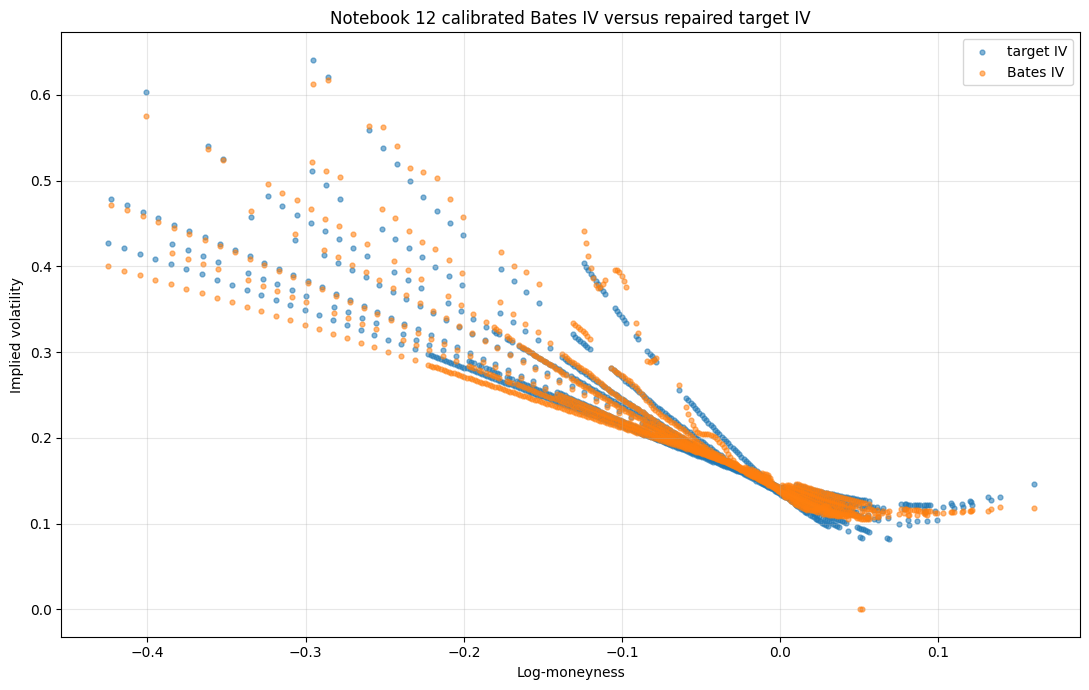

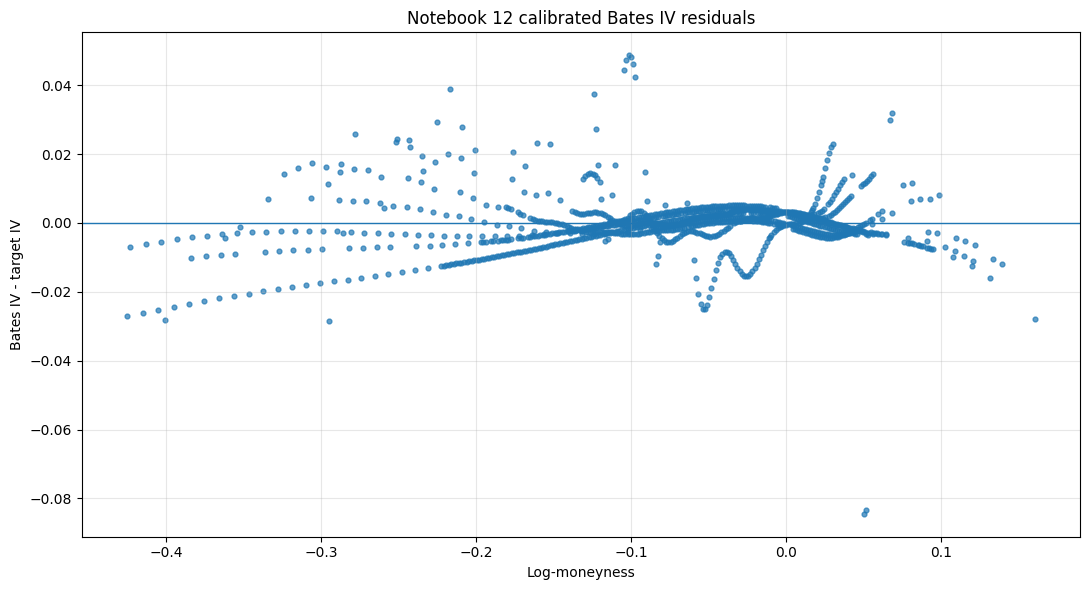

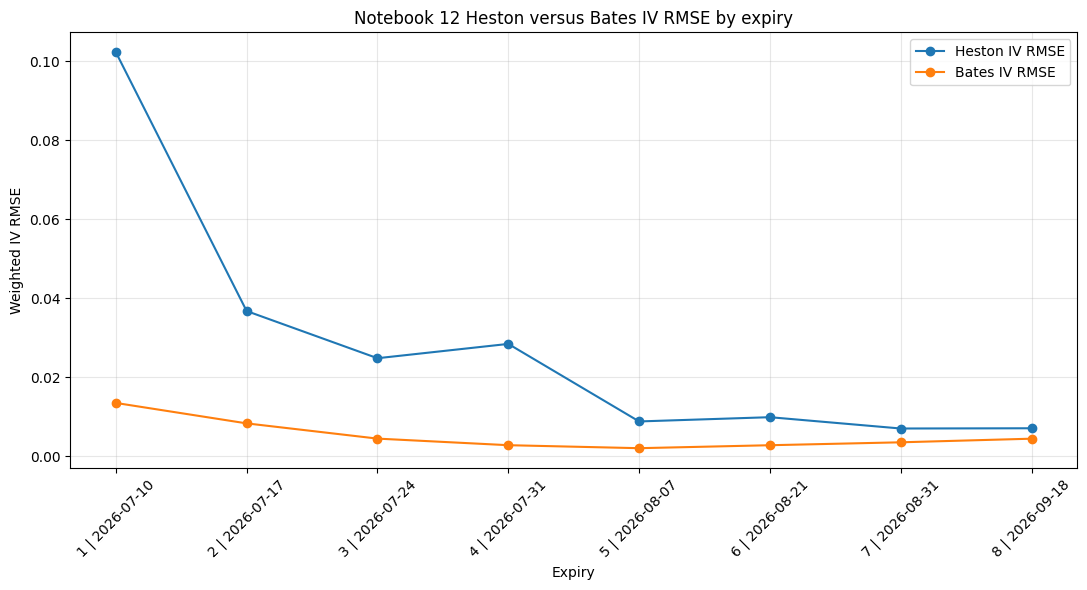

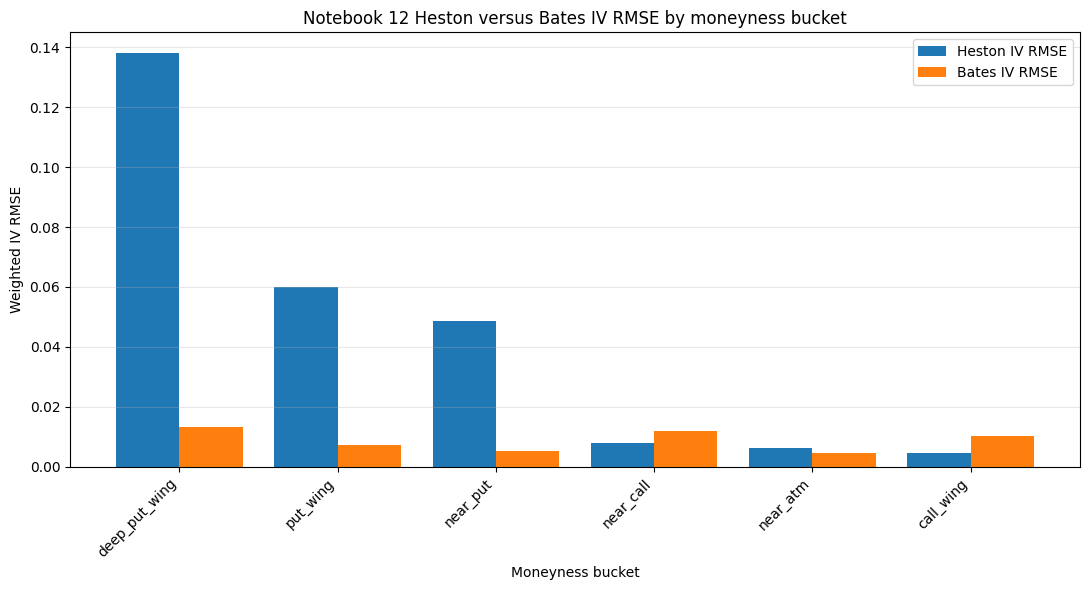

Notebook 12 Bates incremental diagnostic calibration
Fit target rows:                    736
Full scoring rows:                  1,250
Start count:                        12
Finite calibration results:         12
Optimizer success count:            11
Best start id:                      8
Calibration elapsed seconds:        95.9829
Best objective:                     0.0084648348
Best fit-subset scaled RMSE:        0.0047960680
----------------------------------------------------------------------------------------
v0:                                 0.0178711558
theta:                              0.0312816977
kappa:                              8.0985818220
sigma_v:                            0.8521853491
rho:                                -0.7020255006
lambda_j:                           0.0401422460
mu_j:                               -0.4336821184
sigma_j:                            0.2083919415
Jump active flag:                   True
Jump degenerate flag:               False
An

,run_tag,model,parameter,value,lower_bound,upper_bound,at_lower_bound_flag,at_upper_bound_flag
0,n12_20260706T023331Z,bates,v0,0.0178711558,0.0000010000,2.0000000000,True,False
1,n12_20260706T023331Z,bates,theta,0.0312816977,0.0000010000,2.0000000000,False,False
2,n12_20260706T023331Z,bates,kappa,8.0985818220,0.0010000000,20.0000000000,False,False
3,n12_20260706T023331Z,bates,sigma_v,0.8521853491,0.0010000000,5.0000000000,False,False
4,n12_20260706T023331Z,bates,rho,-0.7020255006,-0.9990000000,0.9990000000,False,False
5,n12_20260706T023331Z,bates,lambda_j,0.0401422460,0.0000000000,5.0000000000,True,False
6,n12_20260706T023331Z,bates,mu_j,-0.4336821184,-1.0000000000,1.0000000000,False,False
7,n12_20260706T023331Z,bates,sigma_j,0.2083919415,0.0001000000,2.0000000000,False,False


----------------------------------------------------------------------------------------
Bates calibration summary:


,run_tag,score_label,rows,weighted_price_rmse,weighted_price_mae,weighted_price_bias,weighted_scaled_price_rmse,weighted_scaled_price_mae,weighted_scaled_price_bias,weighted_iv_rmse,weighted_iv_mae,weighted_iv_bias,finite_raw_price_rate,raw_bound_violation_rate,safe_bound_violation_rate,iv_failure_rate,model,best_start_id,optimizer_success,optimizer_nfev,optimizer_final_objective,calibration_elapsed_seconds,fit_rows_used_for_optimizer,full_rows_used_for_scoring,param_v0,param_theta,param_kappa,param_sigma_v,param_rho,param_lambda_j,param_mu_j,param_sigma_j,boundary_hit_count,boundary_hit_names,min_relative_distance_to_bound,feller_lhs_2_kappa_theta,feller_rhs_sigma_v_sq,feller_margin,feller_ratio,feller_condition_passed,jump_mean_multiplier,jump_compensator,annual_jump_variance_proxy,jump_active_flag,jump_degenerate_flag,heston_full_weighted_iv_rmse,heston_full_weighted_price_rmse,bates_iv_improvement_vs_heston,bates_price_improvement_vs_heston,fair_iv_hurdle,fair_price_hurdle,best_simple_iv_ceiling,best_simple_price_ceiling,beats_heston_iv,beats_heston_price,beats_fair_iv_hurdle,beats_fair_price_hurdle,beats_best_simple_iv_ceiling,beats_best_simple_price_ceiling
0,n12_20260706T023331Z,fit_subset_score,736,0.1650401085,0.1216489259,0.0162663270,0.0052652599,0.0032701226,0.0000623836,0.0065824170,0.0035205547,-0.0001370818,1.0000000000,0.0027173913,0.0000000000,0.0000000000,bates,8,True,49,0.0084648348,95.9829329000,736,1250,0.0178711558,0.0312816977,8.0985818220,0.8521853491,-0.7020255006,0.0401422460,-0.4336821184,0.2083919415,2,"v0:lower, lambda_j:lower",0.0080284492,0.5066747760,0.7262198692,-0.2195450932,0.6976878456,False,0.6623451278,-0.3376548722,0.0092932262,True,False,0.0355361064,0.2908860496,NaN,NaN,0.0051131876,0.2255551903,0.0037868480,0.1922602487,NaN,NaN,NaN,NaN,NaN,NaN
1,n12_20260706T023331Z,full_surface_score,1250,0.1849124015,0.1385638850,0.0351047882,0.0050372710,0.0032568220,0.0002526131,0.0057866060,0.0033805327,0.0000785498,1.0000000000,0.0016000000,0.0000000000,0.0000000000,bates,8,True,49,0.0084648348,95.9829329000,736,1250,0.0178711558,0.0312816977,8.0985818220,0.8521853491,-0.7020255006,0.0401422460,-0.4336821184,0.2083919415,2,"v0:lower, lambda_j:lower",0.0080284492,0.5066747760,0.7262198692,-0.2195450932,0.6976878456,False,0.6623451278,-0.3376548722,0.0092932262,True,False,0.0355361064,0.2908860496,0.8371626316,0.3643132705,0.0051131876,0.2255551903,0.0037868480,0.1922602487,True,True,False,True,False,True


----------------------------------------------------------------------------------------
Top Bates multistart results:


...

----------------------------------------------------------------------------------------
Bates incremental comparison:


,run_tag,dimension,group_label,iv_floor_rate_bates,iv_floor_rate_heston,raw_bound_violation_rate_bates,raw_bound_violation_rate_heston,rows_bates,rows_heston,weighted_iv_bias_bates,weighted_iv_bias_heston,weighted_iv_mae_bates,weighted_iv_mae_heston,weighted_iv_rmse_bates,weighted_iv_rmse_heston,weighted_price_bias_bates,weighted_price_bias_heston,weighted_price_mae_bates,weighted_price_mae_heston,weighted_price_rmse_bates,weighted_price_rmse_heston,iv_rmse_improvement_bates_vs_heston,price_rmse_improvement_bates_vs_heston
0,n12_20260706T023331Z,expiry,4 | 2026-07-31,0.0000000000,0.0228571429,0.0000000000,0.0228571429,175,175,-0.0011490411,-0.0041715796,0.0019691367,0.0080237977,0.0028559192,0.0284835080,-0.0568577451,-0.0467051028,0.0744820147,0.2135863735,0.1078509267,0.2663280061,0.8997342884,0.5950447408
1,n12_20260706T023331Z,expiry,1 | 2026-07-10,0.0000000000,0.2164948454,0.0000000000,0.2164948454,97,97,-0.0022365062,-0.0341724326,0.0098376925,0.0423608799,0.0135480329,0.1023072453,-0.0500082568,-0.0006226569,0.0877353366,0.0904137401,0.1115129364,0.1073627815,0.8675750394,-0.0386554344
2,n12_20260706T023331Z,expiry,3 | 2026-07-24,0.0000000000,0.0131578947,0.0000000000,0.0131578947,152,152,0.0029175158,0.0007615213,0.0030422980,0.0082471776,0.0045219525,0.0248621432,0.0980604313,0.1227305996,0.1003701282,0.1982956825,0.1275174732,0.2446504502,0.8181189594,0.4787768710
3,n12_20260706T023331Z,expiry,2 | 2026-07-17,0.0157480315,0.0551181102,0.0157480315,0.0551181102,127,127,0.0008328154,-0.0022310916,0.0040968127,0.0096909328,0.0083760528,0.0367984843,0.0408893448,0.0797430714,0.0743873180,0.1389669507,0.0870930789,0.1716530869,0.7723804932,0.4926215399
4,n12_20260706T023331Z,expiry,5 | 2026-08-07,0.0000000000,0.0000000000,0.0000000000,0.0000000000,131,131,-0.0005265175,-0.0009198219,0.0016954797,0.0055794923,0.0020983664,0.0088660870,-0.0357080295,-0.0371573429,0.0973444253,0.2807953627,0.1187525248,0.3159748934,0.7633266570,0.6241710107
5,n12_20260706T023331Z,expiry,6 | 2026-08-21,0.0000000000,0.0000000000,0.0000000000,0.0000000000,167,167,0.0007547365,-0.0004142283,0.0025388169,0.0057023798,0.0028483002,0.0099401929,0.0963818685,0.0656417423,0.1792384224,0.3251819713,0.2145658623,0.3590951179,0.7134562429,0.4024818171
6,n12_20260706T023331Z,expiry,7 | 2026-08-31,0.0000000000,0.0000000000,0.0000000000,0.0000000000,187,187,0.0011235468,0.0002057924,0.0030980470,0.0048321642,0.0035865199,0.0070771185,0.1678206937,0.1118446357,0.2409467268,0.3281920068,0.2994963722,0.3744709664,0.4932231346,0.2002147054
7,n12_20260706T023331Z,expiry,8 | 2026-09-18,0.0000000000,0.0000000000,0.0000000000,0.0000000000,214,214,-0.0015408435,-0.0020024931,0.0030534368,0.0040019897,0.0045018915,0.0071387078,-0.0184129784,-0.0607238005,0.1986105321,0.2758629688,0.2279893124,0.3077049616,0.3693688583,0.2590652057
8,n12_20260706T023331Z,expiry_x_moneyness_bucket,4 | 2026-07-31 | deep_put_wing,0.0000000000,0.2500000000,0.0000000000,0.2500000000,16,16,0.0103402044,-0.1831495471,0.0133527266,0.1831495471,0.0143682760,0.2544655640,0.0463558619,-0.1809393019,0.0540739685,0.1809393019,0.0563937743,0.1831490677,0.9435354797,0.6920881168
9,n12_20260706T023331Z,expiry_x_moneyness_bucket,2 | 2026-07-17 | deep_put_wing,0.0000000000,0.5000000000,0.0000000000,0.5000000000,10,10,0.0165493937,-0.2592432298,0.0222008815,0.2592432298,0.0245031698,0.3482866510,0.0365083516,-0.0814619325,0.0456569442,0.0814619325,0.0511515662,0.0851518278,0.9296465434,0.3992898628


----------------------------------------------------------------------------------------
Bates calibration gate:


,check_name,passed,severity,value,threshold
0,bates_fit_target_rows_sufficient,True,blocking,736,>= 250
1,bates_multistart_finite_result_available,True,blocking,12,> 0
2,bates_optimizer_success_available,True,warning,11,> 0
3,bates_full_surface_prices_finite,True,blocking,1.0000000000,>= 0.99
4,bates_full_surface_safe_bounds_valid,True,blocking,0.0000000000,0
5,bates_full_surface_iv_inversion_valid,True,blocking,0.0000000000,<= 0.01
6,bates_full_surface_iv_rmse_finite,True,blocking,0.0057866060,finite
7,bates_full_surface_price_rmse_finite,True,blocking,0.1849124015,finite
8,bates_boundary_pressure_controlled,True,warning,2,<= 3
9,bates_raw_bound_violations_diagnostic,True,warning,0.0016000000,<= 0.10


----------------------------------------------------------------------------------------
Next step: run the final model comparison and assign the Notebook 12 model-risk verdict.


In [12]:
# ============================================================
# Notebook 12 — Bates Incremental Diagnostic Calibration
# ============================================================
#
# Purpose:
#   Test whether adding lognormal jumps to Heston materially improves the
#   repaired SPY surface fit, especially where Heston failed:
#       - short maturities,
#       - left-tail / deep-put regions,
#       - rows pushed to the IV floor after no-arbitrage projection.
#
# Core rule:
#   Bates is not treated as a guaranteed upgrade. It is an incremental
#   diagnostic over Heston. If it improves the left tail but still loses
#   to simple baselines, the conclusion must say that.
#
# Outputs:
#   n12_bates_multistart_results
#   n12_bates_best_parameters
#   n12_bates_calibration_prediction_panel
#   n12_bates_calibration_summary
#   n12_bates_incremental_comparison
#   n12_bates_calibration_gate
# ============================================================

from scipy.optimize import least_squares
import time


# ------------------------------------------------------------
# Output paths for this stage
# ------------------------------------------------------------

N12_OUTPUTS.update(
    {
        "bates_multistart_results": N12_TABLE_DIR / f"n12_bates_multistart_results_{RUN_TAG}.csv",
        "bates_multistart_results_latest": N12_TABLE_DIR / "n12_bates_multistart_results_latest.csv",
        "bates_best_parameters": N12_TABLE_DIR / f"n12_bates_best_parameters_{RUN_TAG}.csv",
        "bates_best_parameters_latest": N12_TABLE_DIR / "n12_bates_best_parameters_latest.csv",
        "bates_calibration_prediction_panel_csv": N12_TABLE_DIR / f"n12_bates_calibration_prediction_panel_{RUN_TAG}.csv",
        "bates_calibration_prediction_panel_csv_latest": N12_TABLE_DIR / "n12_bates_calibration_prediction_panel_latest.csv",
        "bates_calibration_prediction_panel_parquet": N12_ARTIFACT_DIR / f"n12_bates_calibration_prediction_panel_{RUN_TAG}.parquet",
        "bates_calibration_prediction_panel_parquet_latest": N12_ARTIFACT_DIR / "n12_bates_calibration_prediction_panel_latest.parquet",
        "bates_calibration_summary": N12_TABLE_DIR / f"n12_bates_calibration_summary_{RUN_TAG}.csv",
        "bates_calibration_summary_latest": N12_TABLE_DIR / "n12_bates_calibration_summary_latest.csv",
        "bates_incremental_comparison": N12_TABLE_DIR / f"n12_bates_incremental_comparison_{RUN_TAG}.csv",
        "bates_incremental_comparison_latest": N12_TABLE_DIR / "n12_bates_incremental_comparison_latest.csv",
        "bates_calibration_gate": N12_TABLE_DIR / f"n12_bates_calibration_gate_{RUN_TAG}.csv",
        "bates_calibration_gate_latest": N12_TABLE_DIR / "n12_bates_calibration_gate_latest.csv",
        "bates_calibration_manifest": N12_LOG_DIR / f"n12_bates_calibration_manifest_{RUN_TAG}.json",
        "bates_calibration_manifest_latest": N12_LOG_DIR / "n12_bates_calibration_manifest_latest.json",
        "fig_bates_iv_fit_by_moneyness": N12_FIGURE_DIR / f"n12_bates_iv_fit_by_moneyness_{RUN_TAG}.png",
        "fig_bates_iv_residual_by_moneyness": N12_FIGURE_DIR / f"n12_bates_iv_residual_by_moneyness_{RUN_TAG}.png",
        "fig_bates_vs_heston_residual_by_expiry": N12_FIGURE_DIR / f"n12_bates_vs_heston_residual_by_expiry_{RUN_TAG}.png",
        "fig_bates_vs_heston_residual_by_bucket": N12_FIGURE_DIR / f"n12_bates_vs_heston_residual_by_bucket_{RUN_TAG}.png",
    }
)


# ------------------------------------------------------------
# Guard against accidental out-of-order execution
# ------------------------------------------------------------

_REQUIRED_BATES_INPUT_NAMES = [
    "n12_parametric_target",
    "n12_heston_fit_target",
    "n12_heston_calibration_summary",
    "n12_heston_calibration_prediction_panel",
    "n12_heston_best_parameters",
    "n12_parametric_seed_table",
    "n12_calibration_hurdles",
    "heston_cf_log_spot",
    "heston_forward_call_price_raw",
    "heston_forward_call_price_safe",
    "heston_implied_vol_from_call_price",
    "heston_quadrature_grid",
    "bsm_forward_call_bounds",
    "HESTON_PARAM_ORDER",
    "HESTON_PRICE_BOUND_TOL",
    "HESTON_INTEGRATION_LOWER",
    "HESTON_INTEGRATION_UPPER",
    "HESTON_QUADRATURE_NODES",
    "N12_POLICY",
    "RUN_TAG",
    "N12_TABLE_DIR",
    "N12_ARTIFACT_DIR",
    "N12_FIGURE_DIR",
    "N12_LOG_DIR",
    "N12_OUTPUTS",
]

missing_required_names = [
    name for name in _REQUIRED_BATES_INPUT_NAMES
    if name not in globals()
]

if missing_required_names:
    raise NameError(
        "Notebook 12 Bates cell was run before required Heston diagnostic cells. "
        f"Missing names: {missing_required_names}"
    )


# ------------------------------------------------------------
# Bates configuration
# ------------------------------------------------------------

BATES_PARAM_ORDER = (
    "v0",
    "theta",
    "kappa",
    "sigma_v",
    "rho",
    "lambda_j",
    "mu_j",
    "sigma_j",
)

BATES_CALIBRATION_NODES = 128
BATES_CALIBRATION_UPPER = 180.0
BATES_CALIBRATION_MAX_NFEV = 120
BATES_CALIBRATION_LOSS = "soft_l1"
BATES_CALIBRATION_F_SCALE = 0.012
BATES_CALIBRATION_RANDOM_SEED = RANDOM_SEED + 1215

bates_calibration_nodes, bates_calibration_weights = heston_quadrature_grid(
    n_nodes=BATES_CALIBRATION_NODES,
    u_min=HESTON_INTEGRATION_LOWER,
    u_max=BATES_CALIBRATION_UPPER,
)

bates_scoring_nodes, bates_scoring_weights = heston_quadrature_grid(
    n_nodes=HESTON_QUADRATURE_NODES,
    u_min=HESTON_INTEGRATION_LOWER,
    u_max=HESTON_INTEGRATION_UPPER,
)


# ------------------------------------------------------------
# Local helpers
# ------------------------------------------------------------

def bates_lookup_hurdle_value(hurdle_name: str) -> float:
    """Read a hurdle value from n12_calibration_hurdles."""
    hit = n12_calibration_hurdles.query("hurdle_name == @hurdle_name").copy()

    if hit.empty:
        return np.nan

    return float(hit.iloc[0]["hurdle_value"])


def bates_vector_to_params(x: np.ndarray) -> Dict[str, float]:
    """Convert ordered vector to Bates parameter dict."""
    return {
        name: float(value)
        for name, value in zip(BATES_PARAM_ORDER, np.asarray(x, dtype=float))
    }


def bates_params_to_vector(params: Dict[str, float]) -> np.ndarray:
    """Convert Bates parameter dict to ordered vector."""
    return np.array([float(params[name]) for name in BATES_PARAM_ORDER], dtype=float)


def bates_weighted_metric_summary(
    target_values: np.ndarray,
    predicted_values: np.ndarray,
    weights: np.ndarray,
) -> Dict[str, float]:
    """Weighted RMSE, MAE, and bias."""
    target_values = np.asarray(target_values, dtype=float)
    predicted_values = np.asarray(predicted_values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    valid = (
        np.isfinite(target_values)
        & np.isfinite(predicted_values)
        & np.isfinite(weights)
        & (weights > 0)
    )

    if valid.sum() == 0:
        return {
            "weighted_rmse": np.nan,
            "weighted_mae": np.nan,
            "weighted_bias": np.nan,
            "valid_rows": 0,
        }

    residual = predicted_values[valid] - target_values[valid]
    w = weights[valid]

    return {
        "weighted_rmse": float(np.sqrt(np.average(residual ** 2, weights=w))),
        "weighted_mae": float(np.average(np.abs(residual), weights=w)),
        "weighted_bias": float(np.average(residual, weights=w)),
        "valid_rows": int(valid.sum()),
    }


def bates_parameter_boundary_diagnostics(
    x: np.ndarray,
    lower: np.ndarray,
    upper: np.ndarray,
    *,
    tolerance_fraction: float = 0.01,
) -> Dict[str, Any]:
    """Boundary pressure diagnostics for Bates parameters."""
    x = np.asarray(x, dtype=float)
    lower = np.asarray(lower, dtype=float)
    upper = np.asarray(upper, dtype=float)

    width = np.maximum(upper - lower, 1.0e-12)
    distance_to_lower = (x - lower) / width
    distance_to_upper = (upper - x) / width

    lower_hit = distance_to_lower <= tolerance_fraction
    upper_hit = distance_to_upper <= tolerance_fraction

    hit_names = []

    for name, is_hit in zip(BATES_PARAM_ORDER, lower_hit):
        if is_hit:
            hit_names.append(f"{name}:lower")

    for name, is_hit in zip(BATES_PARAM_ORDER, upper_hit):
        if is_hit:
            hit_names.append(f"{name}:upper")

    return {
        "boundary_hit_count": int(lower_hit.sum() + upper_hit.sum()),
        "boundary_hit_names": ", ".join(hit_names),
        "min_relative_distance_to_bound": float(np.nanmin(np.minimum(distance_to_lower, distance_to_upper))),
    }


def bates_feller_diagnostics(params: Dict[str, float]) -> Dict[str, Any]:
    """Feller diagnostic on the Heston variance component inside Bates."""
    lhs = 2.0 * params["kappa"] * params["theta"]
    rhs = params["sigma_v"] ** 2

    return {
        "feller_lhs_2_kappa_theta": float(lhs),
        "feller_rhs_sigma_v_sq": float(rhs),
        "feller_margin": float(lhs - rhs),
        "feller_ratio": float(lhs / rhs) if rhs > 0 else np.nan,
        "feller_condition_passed": bool(lhs >= rhs),
    }


def bates_jump_diagnostics(params: Dict[str, float]) -> Dict[str, Any]:
    """Jump-component diagnostics for Bates."""
    lambda_j = float(params["lambda_j"])
    mu_j = float(params["mu_j"])
    sigma_j = float(params["sigma_j"])

    jump_mean_multiplier = float(np.exp(mu_j + 0.5 * sigma_j ** 2))
    jump_compensator = float(jump_mean_multiplier - 1.0)
    annual_jump_variance_proxy = float(
        lambda_j * (mu_j ** 2 + sigma_j ** 2)
    )

    jump_active_flag = bool(
        lambda_j > 0.025
        and sigma_j > 0.005
        and annual_jump_variance_proxy > 1.0e-5
    )

    jump_degenerate_flag = bool(
        lambda_j <= 1.0e-4
        or sigma_j <= 5.0e-4
        or annual_jump_variance_proxy <= 1.0e-8
    )

    return {
        "jump_mean_multiplier": jump_mean_multiplier,
        "jump_compensator": jump_compensator,
        "annual_jump_variance_proxy": annual_jump_variance_proxy,
        "jump_active_flag": jump_active_flag,
        "jump_degenerate_flag": jump_degenerate_flag,
    }


def make_bates_array_pack(df: pd.DataFrame) -> Dict[str, np.ndarray]:
    """Convert parametric target DataFrame into Bates objective arrays."""
    return {
        "F": df["param_forward"].to_numpy(dtype=float),
        "K": df["param_strike"].to_numpy(dtype=float),
        "T": df["param_tau"].to_numpy(dtype=float),
        "r": df["param_rate"].to_numpy(dtype=float),
        "target_iv": df["param_target_iv"].to_numpy(dtype=float),
        "target_call_price": df["param_call_equivalent_price"].to_numpy(dtype=float),
        "calibration_weight": df["calibration_weight"].to_numpy(dtype=float),
        "sqrt_weight": np.sqrt(np.maximum(df["calibration_weight"].to_numpy(dtype=float), 0.0)),
        "price_scale": np.maximum(df["param_price_residual_scale"].to_numpy(dtype=float), 1.0e-8),
    }


# ------------------------------------------------------------
# Bates characteristic function and pricing kernel
# ------------------------------------------------------------

def bates_cf_log_spot(
    u_values: Any,
    forward: Any,
    tau: Any,
    *,
    v0: float,
    theta: float,
    kappa: float,
    sigma_v: float,
    rho: float,
    lambda_j: float,
    mu_j: float,
    sigma_j: float,
) -> np.ndarray:
    """
    Bates characteristic function of log(S_T).

    Heston diffusion CF is multiplied by a compensated lognormal jump CF.

    Jump log-size:
        Y ~ Normal(mu_j, sigma_j^2)

    Compensation:
        exp(lambda*T*(E[e^{iuY}] - 1 - iu*(E[e^Y]-1)))

    This preserves phi(-i,T)=F.
    """
    heston_part = heston_cf_log_spot(
        u_values,
        forward,
        tau,
        v0=float(v0),
        theta=float(theta),
        kappa=float(kappa),
        sigma_v=float(sigma_v),
        rho=float(rho),
    )

    u = np.asarray(u_values, dtype=complex).reshape(-1, 1)
    T = np.asarray(tau, dtype=float).reshape(1, -1)

    iu = 1j * u
    jump_compensator = np.exp(mu_j + 0.5 * sigma_j ** 2) - 1.0

    jump_cf = np.exp(
        lambda_j
        * T
        * (
            np.exp(iu * mu_j - 0.5 * sigma_j ** 2 * u ** 2)
            - 1.0
            - iu * jump_compensator
        )
    )

    return heston_part * jump_cf


def bates_forward_call_price_raw(
    forward: Any,
    strike: Any,
    tau: Any,
    rate: Any,
    params: Dict[str, float],
    *,
    nodes: Optional[np.ndarray] = None,
    weights: Optional[np.ndarray] = None,
) -> np.ndarray:
    """Raw Bates forward-call prices before numerical no-arbitrage projection."""
    F, K, T, r = broadcast_float_arrays(forward, strike, tau, rate)

    if nodes is None or weights is None:
        nodes, weights = heston_quadrature_grid(
            n_nodes=HESTON_QUADRATURE_NODES,
            u_min=HESTON_INTEGRATION_LOWER,
            u_max=HESTON_INTEGRATION_UPPER,
        )

    if float(params["lambda_j"]) <= 1.0e-12:
        return heston_forward_call_price_raw(
            F,
            K,
            T,
            r,
            {
                "v0": params["v0"],
                "theta": params["theta"],
                "kappa": params["kappa"],
                "sigma_v": params["sigma_v"],
                "rho": params["rho"],
            },
            nodes=nodes,
            weights=weights,
        )

    u = np.asarray(nodes, dtype=float).reshape(-1, 1)
    w = np.asarray(weights, dtype=float).reshape(-1, 1)

    log_K = np.log(K).reshape(1, -1)

    phi_u = bates_cf_log_spot(
        u.ravel(),
        F,
        T,
        **params,
    )

    phi_u_minus_i = bates_cf_log_spot(
        u.ravel() - 1j,
        F,
        T,
        **params,
    )

    exp_term = np.exp(-1j * u * log_K)
    denom = 1j * u

    integrand_p2 = np.real(exp_term * phi_u / denom)
    integrand_p1 = np.real(exp_term * phi_u_minus_i / (denom * F.reshape(1, -1)))

    p2 = 0.5 + np.sum(w * integrand_p2, axis=0) / np.pi
    p1 = 0.5 + np.sum(w * integrand_p1, axis=0) / np.pi

    discount = np.exp(-r * T)
    raw_price = discount * (F * p1 - K * p2)

    return np.asarray(np.real(raw_price), dtype=float)


def bates_forward_call_price_safe(
    forward: Any,
    strike: Any,
    tau: Any,
    rate: Any,
    params: Dict[str, float],
    *,
    nodes: Optional[np.ndarray] = None,
    weights: Optional[np.ndarray] = None,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Bates forward-call prices projected to no-arbitrage call bounds.

    Returns:
        projected_price,
        raw_bound_violation_flag
    """
    raw_price = bates_forward_call_price_raw(
        forward,
        strike,
        tau,
        rate,
        params,
        nodes=nodes,
        weights=weights,
    )

    projected_price, raw_violation, _lower, _upper = project_call_price_to_bounds(
        raw_price,
        forward,
        strike,
        tau,
        rate,
    )

    return projected_price, raw_violation


def bates_objective_residuals(
    x: np.ndarray,
    arrays: Dict[str, np.ndarray],
    *,
    nodes: np.ndarray,
    weights: np.ndarray,
) -> np.ndarray:
    """
    Vega-scaled weighted price residuals for Bates.

    The objective is directly comparable with the Heston objective:
        sqrt(weight) * (model_call_price - target_call_price) / BSM_vega_scale
    """
    x = np.asarray(x, dtype=float)

    if (
        np.any(~np.isfinite(x))
        or np.any(x < BATES_LOWER_BOUNDS)
        or np.any(x > BATES_UPPER_BOUNDS)
    ):
        return np.full(len(arrays["F"]), 1.0e4, dtype=float)

    params = bates_vector_to_params(x)

    try:
        model_price, _raw_violation = bates_forward_call_price_safe(
            arrays["F"],
            arrays["K"],
            arrays["T"],
            arrays["r"],
            params,
            nodes=nodes,
            weights=weights,
        )
    except Exception:
        return np.full(len(arrays["F"]), 1.0e4, dtype=float)

    residual = (
        arrays["sqrt_weight"]
        * (model_price - arrays["target_call_price"])
        / arrays["price_scale"]
    )

    residual = np.asarray(residual, dtype=float)
    residual = np.where(np.isfinite(residual), residual, 1.0e4)

    return residual


def evaluate_bates_model_on_target(
    params: Dict[str, float],
    df: pd.DataFrame,
    *,
    label: str,
    nodes: np.ndarray,
    weights: np.ndarray,
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """Score Bates parameters on a target panel."""
    work = df.copy().reset_index(drop=True)

    F = work["param_forward"].to_numpy(dtype=float)
    K = work["param_strike"].to_numpy(dtype=float)
    T = work["param_tau"].to_numpy(dtype=float)
    r = work["param_rate"].to_numpy(dtype=float)
    target_iv = work["param_target_iv"].to_numpy(dtype=float)
    target_call = work["param_call_equivalent_price"].to_numpy(dtype=float)
    w = work["calibration_weight"].to_numpy(dtype=float)
    price_scale = np.maximum(work["param_price_residual_scale"].to_numpy(dtype=float), 1.0e-8)

    raw_price = bates_forward_call_price_raw(
        F,
        K,
        T,
        r,
        params,
        nodes=nodes,
        weights=weights,
    )

    safe_price, raw_bound_violation = bates_forward_call_price_safe(
        F,
        K,
        T,
        r,
        params,
        nodes=nodes,
        weights=weights,
    )

    lower_bound, upper_bound = bsm_forward_call_bounds(F, K, T, r)

    safe_bound_violation = (
        (safe_price < lower_bound - HESTON_PRICE_BOUND_TOL)
        | (safe_price > upper_bound + HESTON_PRICE_BOUND_TOL)
    )

    implied_iv, iv_failure = heston_implied_vol_from_call_price(
        safe_price,
        F,
        K,
        T,
        r,
    )

    price_metrics = bates_weighted_metric_summary(target_call, safe_price, w)
    iv_metrics = bates_weighted_metric_summary(target_iv, implied_iv, w)

    scaled_residual = (safe_price - target_call) / price_scale
    scaled_metrics = bates_weighted_metric_summary(np.zeros_like(scaled_residual), scaled_residual, w)

    panel = pd.DataFrame(
        {
            "run_tag": RUN_TAG,
            "score_label": label,
            "source_row_id": work["source_row_id"].to_numpy(dtype=int),
            "expiry_rank": work["expiry_rank"].to_numpy(dtype=int),
            "expiry_key": work["expiry_key"].astype("string").to_numpy(),
            "option_type": work["option_type"].astype("string").to_numpy(),
            "moneyness_bucket": work["moneyness_bucket"].astype("string").to_numpy(),
            "time_to_expiry": T,
            "dte_approx": work["dte_approx"].to_numpy(dtype=float),
            "forward": F,
            "strike": K,
            "log_moneyness": work["param_log_moneyness"].to_numpy(dtype=float),
            "target_iv": target_iv,
            "bates_iv": implied_iv,
            "iv_residual": implied_iv - target_iv,
            "target_call_price": target_call,
            "bates_raw_call_price": raw_price,
            "bates_safe_call_price": safe_price,
            "price_residual": safe_price - target_call,
            "scaled_price_residual": scaled_residual,
            "raw_bound_violation_flag": raw_bound_violation.astype(bool),
            "safe_bound_violation_flag": safe_bound_violation.astype(bool),
            "iv_failure_flag": iv_failure.astype(bool),
            "calibration_weight": w,
            "price_residual_scale": price_scale,
        }
    )

    summary = {
        "run_tag": RUN_TAG,
        "score_label": label,
        "rows": int(len(work)),
        "weighted_price_rmse": price_metrics["weighted_rmse"],
        "weighted_price_mae": price_metrics["weighted_mae"],
        "weighted_price_bias": price_metrics["weighted_bias"],
        "weighted_scaled_price_rmse": scaled_metrics["weighted_rmse"],
        "weighted_scaled_price_mae": scaled_metrics["weighted_mae"],
        "weighted_scaled_price_bias": scaled_metrics["weighted_bias"],
        "weighted_iv_rmse": iv_metrics["weighted_rmse"],
        "weighted_iv_mae": iv_metrics["weighted_mae"],
        "weighted_iv_bias": iv_metrics["weighted_bias"],
        "finite_raw_price_rate": float(np.isfinite(raw_price).mean()),
        "raw_bound_violation_rate": float(raw_bound_violation.mean()),
        "safe_bound_violation_rate": float(safe_bound_violation.mean()),
        "iv_failure_rate": float(iv_failure.mean()),
    }

    return panel, summary


# ------------------------------------------------------------
# Bounds and seed construction
# ------------------------------------------------------------

bates_seed_table = (
    n12_parametric_seed_table
    .query("model == 'bates'")
    .set_index("parameter")
    .loc[list(BATES_PARAM_ORDER)]
)

BATES_LOWER_BOUNDS = bates_seed_table["lower_bound"].to_numpy(dtype=float)
BATES_UPPER_BOUNDS = bates_seed_table["upper_bound"].to_numpy(dtype=float)

heston_best_map = (
    n12_heston_best_parameters
    .set_index("parameter")["value"]
    .to_dict()
)

bates_seed_from_table = bates_seed_table["seed_value"].to_dict()

BATES_BASE_SEED_PARAMS = {
    "v0": float(heston_best_map.get("v0", bates_seed_from_table["v0"])),
    "theta": float(heston_best_map.get("theta", bates_seed_from_table["theta"])),
    "kappa": float(heston_best_map.get("kappa", bates_seed_from_table["kappa"])),
    "sigma_v": float(heston_best_map.get("sigma_v", bates_seed_from_table["sigma_v"])),
    "rho": float(heston_best_map.get("rho", bates_seed_from_table["rho"])),
    "lambda_j": float(bates_seed_from_table.get("lambda_j", 0.10)),
    "mu_j": float(bates_seed_from_table.get("mu_j", -0.03)),
    "sigma_j": float(bates_seed_from_table.get("sigma_j", 0.15)),
}

base_vector = bates_params_to_vector(BATES_BASE_SEED_PARAMS)

raw_bates_starts = [
    base_vector,
    np.array([base_vector[0], base_vector[1], base_vector[2], base_vector[3], base_vector[4], 0.0000,  0.0000, 0.1000]),
    np.array([base_vector[0], base_vector[1], base_vector[2], base_vector[3], base_vector[4], 0.0500, -0.0200, 0.0800]),
    np.array([base_vector[0], base_vector[1], base_vector[2], base_vector[3], base_vector[4], 0.1000, -0.0300, 0.1200]),
    np.array([base_vector[0], base_vector[1], base_vector[2], base_vector[3], base_vector[4], 0.2500, -0.0500, 0.1800]),
    np.array([base_vector[0], base_vector[1], base_vector[2], base_vector[3], base_vector[4], 0.5000, -0.0800, 0.2200]),
    np.array([base_vector[0], base_vector[1], base_vector[2], base_vector[3], base_vector[4], 1.0000, -0.1200, 0.3000]),
    np.array([base_vector[0], base_vector[1], base_vector[2], base_vector[3], base_vector[4], 0.5000, -0.1800, 0.4000]),
    np.array([base_vector[0], base_vector[1], base_vector[2], base_vector[3], base_vector[4], 1.5000, -0.2500, 0.5000]),
    np.array([base_vector[0], base_vector[1], 4.0000, 0.9000, -0.7500, 0.2500, -0.0800, 0.2500]),
    np.array([base_vector[0], base_vector[1], 8.0000, 1.2000, -0.6500, 0.7500, -0.1500, 0.3500]),
    np.array([base_vector[0], base_vector[1], 12.0000, 1.8000, -0.8000, 1.0000, -0.2000, 0.4500]),
]

bates_start_vectors = []

for raw_x in raw_bates_starts:
    clipped = np.clip(raw_x, BATES_LOWER_BOUNDS, BATES_UPPER_BOUNDS)

    if not any(np.allclose(clipped, existing, rtol=1.0e-10, atol=1.0e-12) for existing in bates_start_vectors):
        bates_start_vectors.append(clipped)

n12_bates_start_table = pd.DataFrame(
    [
        {
            "run_tag": RUN_TAG,
            "start_id": i,
            **{f"start_{name}": float(value) for name, value in zip(BATES_PARAM_ORDER, x)},
        }
        for i, x in enumerate(bates_start_vectors)
    ]
)


# ------------------------------------------------------------
# Fit target and arrays
# ------------------------------------------------------------

n12_bates_fit_target = n12_heston_fit_target.copy().reset_index(drop=True)
bates_fit_arrays = make_bates_array_pack(n12_bates_fit_target)


# ------------------------------------------------------------
# Multistart bounded least-squares calibration
# ------------------------------------------------------------

bates_multistart_rows = []
bates_result_objects = []

bates_calibration_start_time = time.perf_counter()

for start_id, x0 in enumerate(bates_start_vectors):
    start_time = time.perf_counter()

    initial_residual = bates_objective_residuals(
        x0,
        bates_fit_arrays,
        nodes=bates_calibration_nodes,
        weights=bates_calibration_weights,
    )

    initial_objective = 0.5 * float(np.sum(initial_residual ** 2))

    try:
        result = least_squares(
            bates_objective_residuals,
            x0=x0,
            bounds=(BATES_LOWER_BOUNDS, BATES_UPPER_BOUNDS),
            args=(bates_fit_arrays,),
            kwargs={
                "nodes": bates_calibration_nodes,
                "weights": bates_calibration_weights,
            },
            method="trf",
            loss=BATES_CALIBRATION_LOSS,
            f_scale=BATES_CALIBRATION_F_SCALE,
            x_scale=np.maximum(
                np.abs(base_vector),
                np.array([0.02, 0.02, 2.0, 0.50, 0.30, 0.25, 0.10, 0.15]),
            ),
            max_nfev=BATES_CALIBRATION_MAX_NFEV,
            ftol=1.0e-8,
            xtol=1.0e-8,
            gtol=1.0e-8,
        )

        final_residual = bates_objective_residuals(
            result.x,
            bates_fit_arrays,
            nodes=bates_calibration_nodes,
            weights=bates_calibration_weights,
        )

        final_objective = 0.5 * float(np.sum(final_residual ** 2))
        final_scaled_rmse = float(np.sqrt(np.mean(final_residual ** 2)))

        status_text = str(result.message)
        success = bool(result.success)
        x_final = np.asarray(result.x, dtype=float)
        nfev = int(result.nfev)
        optimality = float(result.optimality) if np.isfinite(result.optimality) else np.nan

        bates_result_objects.append(
            {
                "start_id": start_id,
                "result": result,
                "objective": final_objective,
                "scaled_rmse": final_scaled_rmse,
            }
        )

    except Exception as exc:
        x_final = np.full_like(x0, np.nan, dtype=float)
        final_objective = np.nan
        final_scaled_rmse = np.nan
        status_text = f"error: {type(exc).__name__}: {exc}"
        success = False
        nfev = 0
        optimality = np.nan

    elapsed = time.perf_counter() - start_time

    boundary_diag = (
        bates_parameter_boundary_diagnostics(x_final, BATES_LOWER_BOUNDS, BATES_UPPER_BOUNDS)
        if np.isfinite(x_final).all()
        else {
            "boundary_hit_count": np.nan,
            "boundary_hit_names": "",
            "min_relative_distance_to_bound": np.nan,
        }
    )

    final_params = (
        bates_vector_to_params(x_final)
        if np.isfinite(x_final).all()
        else {name: np.nan for name in BATES_PARAM_ORDER}
    )

    feller_diag = (
        bates_feller_diagnostics(final_params)
        if np.isfinite(x_final).all()
        else {
            "feller_lhs_2_kappa_theta": np.nan,
            "feller_rhs_sigma_v_sq": np.nan,
            "feller_margin": np.nan,
            "feller_ratio": np.nan,
            "feller_condition_passed": False,
        }
    )

    jump_diag = (
        bates_jump_diagnostics(final_params)
        if np.isfinite(x_final).all()
        else {
            "jump_mean_multiplier": np.nan,
            "jump_compensator": np.nan,
            "annual_jump_variance_proxy": np.nan,
            "jump_active_flag": False,
            "jump_degenerate_flag": True,
        }
    )

    bates_multistart_rows.append(
        {
            "run_tag": RUN_TAG,
            "start_id": start_id,
            "optimizer_success": success,
            "optimizer_status": status_text,
            "nfev": nfev,
            "optimality": optimality,
            "elapsed_seconds": elapsed,
            "initial_objective": initial_objective,
            "final_objective": final_objective,
            "final_fit_subset_scaled_rmse": final_scaled_rmse,
            **{f"start_{name}": float(value) for name, value in zip(BATES_PARAM_ORDER, x0)},
            **{f"final_{name}": float(value) for name, value in final_params.items()},
            **boundary_diag,
            **feller_diag,
            **jump_diag,
        }
    )

bates_calibration_elapsed_seconds = time.perf_counter() - bates_calibration_start_time

n12_bates_multistart_results = (
    pd.DataFrame(bates_multistart_rows)
    .sort_values(["final_objective", "start_id"], na_position="last")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Select best finite Bates result
# ------------------------------------------------------------

bates_finite_results = n12_bates_multistart_results.loc[
    np.isfinite(n12_bates_multistart_results["final_objective"])
].copy()

if bates_finite_results.empty:
    raise RuntimeError("All Bates multistart calibrations failed numerically.")

bates_best_result_row = bates_finite_results.iloc[0].to_dict()
bates_best_start_id = int(bates_best_result_row["start_id"])

bates_best_x = np.array(
    [bates_best_result_row[f"final_{name}"] for name in BATES_PARAM_ORDER],
    dtype=float,
)

n12_bates_best_params = bates_vector_to_params(bates_best_x)

bates_best_boundary_diag = bates_parameter_boundary_diagnostics(
    bates_best_x,
    BATES_LOWER_BOUNDS,
    BATES_UPPER_BOUNDS,
)

bates_best_feller_diag = bates_feller_diagnostics(n12_bates_best_params)
bates_best_jump_diag = bates_jump_diagnostics(n12_bates_best_params)

n12_bates_best_parameters = pd.DataFrame(
    [
        {
            "run_tag": RUN_TAG,
            "model": "bates",
            "parameter": name,
            "value": n12_bates_best_params[name],
            "lower_bound": float(lower),
            "upper_bound": float(upper),
            "at_lower_bound_flag": bool(abs(n12_bates_best_params[name] - lower) <= 0.01 * max(upper - lower, 1.0e-12)),
            "at_upper_bound_flag": bool(abs(upper - n12_bates_best_params[name]) <= 0.01 * max(upper - lower, 1.0e-12)),
        }
        for name, lower, upper in zip(BATES_PARAM_ORDER, BATES_LOWER_BOUNDS, BATES_UPPER_BOUNDS)
    ]
)


# ------------------------------------------------------------
# Full-surface scoring
# ------------------------------------------------------------

bates_fit_panel, bates_fit_summary = evaluate_bates_model_on_target(
    n12_bates_best_params,
    n12_bates_fit_target,
    label="fit_subset_score",
    nodes=bates_scoring_nodes,
    weights=bates_scoring_weights,
)

bates_full_panel, bates_full_summary = evaluate_bates_model_on_target(
    n12_bates_best_params,
    n12_parametric_target,
    label="full_surface_score",
    nodes=bates_scoring_nodes,
    weights=bates_scoring_weights,
)

n12_bates_calibration_prediction_panel = pd.concat(
    [bates_fit_panel, bates_full_panel],
    ignore_index=True,
)

heston_full_summary_row = (
    n12_heston_calibration_summary
    .query("score_label == 'full_surface_score'")
    .iloc[0]
    .to_dict()
)

heston_full_iv_rmse = float(heston_full_summary_row["weighted_iv_rmse"])
heston_full_price_rmse = float(heston_full_summary_row["weighted_price_rmse"])

fair_iv_hurdle = bates_lookup_hurdle_value("fair_parametric_iv_hurdle")
fair_price_hurdle = bates_lookup_hurdle_value("fair_parametric_price_hurdle")
best_simple_iv_ceiling = bates_lookup_hurdle_value("best_simple_surface_fit_ceiling_iv")
best_simple_price_ceiling = bates_lookup_hurdle_value("best_simple_surface_fit_ceiling_price")

bates_iv_improvement_vs_heston = (
    (heston_full_iv_rmse - bates_full_summary["weighted_iv_rmse"]) / heston_full_iv_rmse
    if heston_full_iv_rmse > 0
    else np.nan
)

bates_price_improvement_vs_heston = (
    (heston_full_price_rmse - bates_full_summary["weighted_price_rmse"]) / heston_full_price_rmse
    if heston_full_price_rmse > 0
    else np.nan
)

bates_beats_heston_iv = bool(
    np.isfinite(bates_full_summary["weighted_iv_rmse"])
    and bates_full_summary["weighted_iv_rmse"] < heston_full_iv_rmse
)

bates_beats_heston_price = bool(
    np.isfinite(bates_full_summary["weighted_price_rmse"])
    and bates_full_summary["weighted_price_rmse"] < heston_full_price_rmse
)

bates_beats_fair_iv_hurdle = bool(
    np.isfinite(bates_full_summary["weighted_iv_rmse"])
    and np.isfinite(fair_iv_hurdle)
    and bates_full_summary["weighted_iv_rmse"] <= fair_iv_hurdle
)

bates_beats_fair_price_hurdle = bool(
    np.isfinite(bates_full_summary["weighted_price_rmse"])
    and np.isfinite(fair_price_hurdle)
    and bates_full_summary["weighted_price_rmse"] <= fair_price_hurdle
)

bates_beats_best_simple_iv_ceiling = bool(
    np.isfinite(bates_full_summary["weighted_iv_rmse"])
    and np.isfinite(best_simple_iv_ceiling)
    and bates_full_summary["weighted_iv_rmse"] <= best_simple_iv_ceiling
)

bates_beats_best_simple_price_ceiling = bool(
    np.isfinite(bates_full_summary["weighted_price_rmse"])
    and np.isfinite(best_simple_price_ceiling)
    and bates_full_summary["weighted_price_rmse"] <= best_simple_price_ceiling
)

n12_bates_calibration_summary = pd.DataFrame(
    [
        {
            **bates_fit_summary,
            "model": "bates",
            "best_start_id": bates_best_start_id,
            "optimizer_success": bool(bates_best_result_row["optimizer_success"]),
            "optimizer_nfev": int(bates_best_result_row["nfev"]),
            "optimizer_final_objective": float(bates_best_result_row["final_objective"]),
            "calibration_elapsed_seconds": float(bates_calibration_elapsed_seconds),
            "fit_rows_used_for_optimizer": int(len(n12_bates_fit_target)),
            "full_rows_used_for_scoring": int(len(n12_parametric_target)),
            **{f"param_{name}": n12_bates_best_params[name] for name in BATES_PARAM_ORDER},
            **bates_best_boundary_diag,
            **bates_best_feller_diag,
            **bates_best_jump_diag,
            "heston_full_weighted_iv_rmse": heston_full_iv_rmse,
            "heston_full_weighted_price_rmse": heston_full_price_rmse,
            "bates_iv_improvement_vs_heston": np.nan,
            "bates_price_improvement_vs_heston": np.nan,
            "fair_iv_hurdle": fair_iv_hurdle,
            "fair_price_hurdle": fair_price_hurdle,
            "best_simple_iv_ceiling": best_simple_iv_ceiling,
            "best_simple_price_ceiling": best_simple_price_ceiling,
            "beats_heston_iv": np.nan,
            "beats_heston_price": np.nan,
            "beats_fair_iv_hurdle": np.nan,
            "beats_fair_price_hurdle": np.nan,
            "beats_best_simple_iv_ceiling": np.nan,
            "beats_best_simple_price_ceiling": np.nan,
        },
        {
            **bates_full_summary,
            "model": "bates",
            "best_start_id": bates_best_start_id,
            "optimizer_success": bool(bates_best_result_row["optimizer_success"]),
            "optimizer_nfev": int(bates_best_result_row["nfev"]),
            "optimizer_final_objective": float(bates_best_result_row["final_objective"]),
            "calibration_elapsed_seconds": float(bates_calibration_elapsed_seconds),
            "fit_rows_used_for_optimizer": int(len(n12_bates_fit_target)),
            "full_rows_used_for_scoring": int(len(n12_parametric_target)),
            **{f"param_{name}": n12_bates_best_params[name] for name in BATES_PARAM_ORDER},
            **bates_best_boundary_diag,
            **bates_best_feller_diag,
            **bates_best_jump_diag,
            "heston_full_weighted_iv_rmse": heston_full_iv_rmse,
            "heston_full_weighted_price_rmse": heston_full_price_rmse,
            "bates_iv_improvement_vs_heston": bates_iv_improvement_vs_heston,
            "bates_price_improvement_vs_heston": bates_price_improvement_vs_heston,
            "fair_iv_hurdle": fair_iv_hurdle,
            "fair_price_hurdle": fair_price_hurdle,
            "best_simple_iv_ceiling": best_simple_iv_ceiling,
            "best_simple_price_ceiling": best_simple_price_ceiling,
            "beats_heston_iv": bates_beats_heston_iv,
            "beats_heston_price": bates_beats_heston_price,
            "beats_fair_iv_hurdle": bates_beats_fair_iv_hurdle,
            "beats_fair_price_hurdle": bates_beats_fair_price_hurdle,
            "beats_best_simple_iv_ceiling": bates_beats_best_simple_iv_ceiling,
            "beats_best_simple_price_ceiling": bates_beats_best_simple_price_ceiling,
        },
    ]
)


# ------------------------------------------------------------
# Incremental localization versus Heston
# ------------------------------------------------------------

heston_full_panel_for_comparison = (
    n12_heston_calibration_prediction_panel
    .query("score_label == 'full_surface_score'")
    .copy()
    .rename(
        columns={
            "heston_iv": "model_iv",
            "heston_safe_call_price": "model_call_price",
        }
    )
)

bates_full_panel_for_comparison = (
    bates_full_panel
    .copy()
    .rename(
        columns={
            "bates_iv": "model_iv",
            "bates_safe_call_price": "model_call_price",
        }
    )
)

def model_local_summary(df: pd.DataFrame, model_name: str, dimension: str, group_cols: Sequence[str]) -> pd.DataFrame:
    rows = []

    for key, group in df.groupby(list(group_cols), observed=True, dropna=False):
        if not isinstance(key, tuple):
            key = (key,)

        weights = group["calibration_weight"].to_numpy(dtype=float)

        rows.append(
            {
                "run_tag": RUN_TAG,
                "model": model_name,
                "dimension": dimension,
                "group_label": " | ".join(str(x) for x in key),
                "rows": int(len(group)),
                "weighted_iv_rmse": float(np.sqrt(np.average(group["iv_residual"].to_numpy(dtype=float) ** 2, weights=weights))),
                "weighted_iv_mae": float(np.average(np.abs(group["iv_residual"].to_numpy(dtype=float)), weights=weights)),
                "weighted_iv_bias": float(np.average(group["iv_residual"].to_numpy(dtype=float), weights=weights)),
                "weighted_price_rmse": float(np.sqrt(np.average(group["price_residual"].to_numpy(dtype=float) ** 2, weights=weights))),
                "weighted_price_mae": float(np.average(np.abs(group["price_residual"].to_numpy(dtype=float)), weights=weights)),
                "weighted_price_bias": float(np.average(group["price_residual"].to_numpy(dtype=float), weights=weights)),
                "iv_floor_rate": float((group["model_iv"] <= max(float(N12_POLICY.min_positive_iv) * 10.0, 1.0e-5)).mean()),
                "raw_bound_violation_rate": float(group["raw_bound_violation_flag"].mean()),
            }
        )

    return pd.DataFrame(rows)

comparison_parts = []

for dimension, group_cols in [
    ("expiry", ["expiry_rank", "expiry_key"]),
    ("moneyness_bucket", ["moneyness_bucket"]),
    ("expiry_x_moneyness_bucket", ["expiry_rank", "expiry_key", "moneyness_bucket"]),
]:
    comparison_parts.append(
        model_local_summary(heston_full_panel_for_comparison, "heston", dimension, group_cols)
    )
    comparison_parts.append(
        model_local_summary(bates_full_panel_for_comparison, "bates", dimension, group_cols)
    )

local_compare_long = pd.concat(comparison_parts, ignore_index=True)

local_compare_wide = (
    local_compare_long
    .pivot_table(
        index=["run_tag", "dimension", "group_label"],
        columns="model",
        values=[
            "rows",
            "weighted_iv_rmse",
            "weighted_iv_mae",
            "weighted_iv_bias",
            "weighted_price_rmse",
            "weighted_price_mae",
            "weighted_price_bias",
            "iv_floor_rate",
            "raw_bound_violation_rate",
        ],
        aggfunc="first",
    )
)

local_compare_wide.columns = [
    f"{metric}_{model}"
    for metric, model in local_compare_wide.columns
]

local_compare_wide = local_compare_wide.reset_index()

local_compare_wide["iv_rmse_improvement_bates_vs_heston"] = (
    (
        local_compare_wide["weighted_iv_rmse_heston"]
        - local_compare_wide["weighted_iv_rmse_bates"]
    )
    / local_compare_wide["weighted_iv_rmse_heston"].replace(0.0, np.nan)
)

local_compare_wide["price_rmse_improvement_bates_vs_heston"] = (
    (
        local_compare_wide["weighted_price_rmse_heston"]
        - local_compare_wide["weighted_price_rmse_bates"]
    )
    / local_compare_wide["weighted_price_rmse_heston"].replace(0.0, np.nan)
)

n12_bates_incremental_comparison = (
    local_compare_wide
    .sort_values(
        ["dimension", "iv_rmse_improvement_bates_vs_heston", "group_label"],
        ascending=[True, False, True],
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Bates calibration gate
# ------------------------------------------------------------

bates_optimizer_success_count = int(n12_bates_multistart_results["optimizer_success"].sum())
bates_finite_result_count = int(np.isfinite(n12_bates_multistart_results["final_objective"]).sum())

bates_full_safe_bound_violation_rate = float(bates_full_summary["safe_bound_violation_rate"])
bates_full_iv_failure_rate = float(bates_full_summary["iv_failure_rate"])
bates_full_finite_price_rate = float(bates_full_summary["finite_raw_price_rate"])
bates_full_raw_bound_violation_rate = float(bates_full_summary["raw_bound_violation_rate"])

bates_material_iv_improvement_vs_heston = bool(
    np.isfinite(bates_iv_improvement_vs_heston)
    and bates_iv_improvement_vs_heston >= 0.05
)

bates_material_price_improvement_vs_heston = bool(
    np.isfinite(bates_price_improvement_vs_heston)
    and bates_price_improvement_vs_heston >= 0.05
)

n12_bates_calibration_gate = pd.DataFrame(
    [
        build_check(
            "bates_fit_target_rows_sufficient",
            len(n12_bates_fit_target) >= N12_POLICY.min_total_rows_for_parametric_calibration,
            "blocking",
            "Bates optimizer fit subset must retain enough rows.",
            int(len(n12_bates_fit_target)),
            f">= {N12_POLICY.min_total_rows_for_parametric_calibration}",
        ),
        build_check(
            "bates_multistart_finite_result_available",
            bates_finite_result_count > 0,
            "blocking",
            "At least one Bates start must produce a finite objective.",
            bates_finite_result_count,
            "> 0",
        ),
        build_check(
            "bates_optimizer_success_available",
            bates_optimizer_success_count > 0,
            "warning",
            "At least one Bates optimizer run should report success.",
            bates_optimizer_success_count,
            "> 0",
        ),
        build_check(
            "bates_full_surface_prices_finite",
            bates_full_finite_price_rate >= 0.99,
            "blocking",
            "Calibrated raw Bates prices must be finite for nearly all full-surface rows.",
            bates_full_finite_price_rate,
            ">= 0.99",
        ),
        build_check(
            "bates_full_surface_safe_bounds_valid",
            bates_full_safe_bound_violation_rate == 0.0,
            "blocking",
            "Projected Bates prices must satisfy call bounds.",
            bates_full_safe_bound_violation_rate,
            "0",
        ),
        build_check(
            "bates_full_surface_iv_inversion_valid",
            bates_full_iv_failure_rate <= 0.01,
            "blocking",
            "Projected Bates prices must invert to IVs for nearly all rows.",
            bates_full_iv_failure_rate,
            "<= 0.01",
        ),
        build_check(
            "bates_full_surface_iv_rmse_finite",
            np.isfinite(bates_full_summary["weighted_iv_rmse"]),
            "blocking",
            "Full-surface Bates IV RMSE must be finite.",
            bates_full_summary["weighted_iv_rmse"],
            "finite",
        ),
        build_check(
            "bates_full_surface_price_rmse_finite",
            np.isfinite(bates_full_summary["weighted_price_rmse"]),
            "blocking",
            "Full-surface Bates price RMSE must be finite.",
            bates_full_summary["weighted_price_rmse"],
            "finite",
        ),
        build_check(
            "bates_boundary_pressure_controlled",
            bates_best_boundary_diag["boundary_hit_count"] <= 3,
            "warning",
            "Too many boundary hits suggest weak identifiability or jump degeneracy.",
            bates_best_boundary_diag["boundary_hit_count"],
            "<= 3",
        ),
        build_check(
            "bates_raw_bound_violations_diagnostic",
            bates_full_raw_bound_violation_rate <= 0.10,
            "warning",
            "Raw Bates price bound leakage should remain diagnostic rather than dominant.",
            bates_full_raw_bound_violation_rate,
            "<= 0.10",
        ),
        build_check(
            "bates_jump_component_active",
            bool(bates_best_jump_diag["jump_active_flag"]),
            "warning",
            "If the jump component is inactive, Bates collapses toward Heston and should not be credited as a jump model.",
            bool(bates_best_jump_diag["jump_active_flag"]),
            "True",
        ),
        build_check(
            "bates_jump_component_not_degenerate",
            not bool(bates_best_jump_diag["jump_degenerate_flag"]),
            "warning",
            "Degenerate jump parameters indicate poor Bates identifiability.",
            bool(bates_best_jump_diag["jump_degenerate_flag"]),
            "False",
        ),
        build_check(
            "bates_material_iv_improvement_vs_heston",
            bates_material_iv_improvement_vs_heston,
            "warning",
            "Bates should materially improve IV RMSE versus Heston to justify added jump parameters.",
            bates_iv_improvement_vs_heston,
            ">= 0.05",
        ),
        build_check(
            "bates_material_price_improvement_vs_heston",
            bates_material_price_improvement_vs_heston,
            "warning",
            "Bates should materially improve price RMSE versus Heston to justify added jump parameters.",
            bates_price_improvement_vs_heston,
            ">= 0.05",
        ),
        build_check(
            "bates_beats_fair_iv_hurdle",
            bates_beats_fair_iv_hurdle,
            "warning",
            "Bates should beat the low-complexity IV baseline to earn empirical fit credit.",
            bates_full_summary["weighted_iv_rmse"],
            f"<= {fair_iv_hurdle}",
        ),
        build_check(
            "bates_beats_fair_price_hurdle",
            bates_beats_fair_price_hurdle,
            "warning",
            "Bates should beat the low-complexity price baseline to earn empirical fit credit.",
            bates_full_summary["weighted_price_rmse"],
            f"<= {fair_price_hurdle}",
        ),
        build_check(
            "bates_feller_condition",
            bool(bates_best_feller_diag["feller_condition_passed"]),
            "warning",
            "Feller condition is diagnostic, not required for pricing, but failure signals variance-boundary pressure.",
            bates_best_feller_diag["feller_margin"],
            ">= 0",
        ),
    ]
)

bates_calibration_blocking_failures = n12_bates_calibration_gate.query(
    "severity == 'blocking' and passed == False"
).copy()

bates_calibration_gate_passed = bool(bates_calibration_blocking_failures.empty)


# ------------------------------------------------------------
# Persist artifacts
# ------------------------------------------------------------

write_table(
    n12_bates_multistart_results,
    N12_OUTPUTS["bates_multistart_results"],
    N12_OUTPUTS["bates_multistart_results_latest"],
)

write_table(
    n12_bates_best_parameters,
    N12_OUTPUTS["bates_best_parameters"],
    N12_OUTPUTS["bates_best_parameters_latest"],
)

write_table(
    n12_bates_calibration_summary,
    N12_OUTPUTS["bates_calibration_summary"],
    N12_OUTPUTS["bates_calibration_summary_latest"],
)

write_table(
    n12_bates_incremental_comparison,
    N12_OUTPUTS["bates_incremental_comparison"],
    N12_OUTPUTS["bates_incremental_comparison_latest"],
)

write_table(
    n12_bates_calibration_gate,
    N12_OUTPUTS["bates_calibration_gate"],
    N12_OUTPUTS["bates_calibration_gate_latest"],
)

n12_bates_prediction_persist_format = write_parquet_with_fallback(
    n12_bates_calibration_prediction_panel,
    N12_OUTPUTS["bates_calibration_prediction_panel_parquet"],
    N12_OUTPUTS["bates_calibration_prediction_panel_csv"],
)

_ = write_parquet_with_fallback(
    n12_bates_calibration_prediction_panel,
    N12_OUTPUTS["bates_calibration_prediction_panel_parquet_latest"],
    N12_OUTPUTS["bates_calibration_prediction_panel_csv_latest"],
)

n12_bates_calibration_manifest = {
    "run_tag": RUN_TAG,
    "model": "bates",
    "param_order": list(BATES_PARAM_ORDER),
    "best_start_id": bates_best_start_id,
    "best_params": n12_bates_best_params,
    "optimizer_success_count": bates_optimizer_success_count,
    "finite_result_count": bates_finite_result_count,
    "total_start_count": len(bates_start_vectors),
    "calibration_nodes": BATES_CALIBRATION_NODES,
    "calibration_upper": BATES_CALIBRATION_UPPER,
    "scoring_nodes": HESTON_QUADRATURE_NODES,
    "scoring_upper": HESTON_INTEGRATION_UPPER,
    "fit_subset_rows": int(len(n12_bates_fit_target)),
    "full_surface_rows": int(len(n12_parametric_target)),
    "full_weighted_iv_rmse": float(bates_full_summary["weighted_iv_rmse"]),
    "full_weighted_price_rmse": float(bates_full_summary["weighted_price_rmse"]),
    "heston_full_weighted_iv_rmse": float(heston_full_iv_rmse),
    "heston_full_weighted_price_rmse": float(heston_full_price_rmse),
    "bates_iv_improvement_vs_heston": float(bates_iv_improvement_vs_heston),
    "bates_price_improvement_vs_heston": float(bates_price_improvement_vs_heston),
    "fair_iv_hurdle": float(fair_iv_hurdle),
    "fair_price_hurdle": float(fair_price_hurdle),
    "beats_heston_iv": bates_beats_heston_iv,
    "beats_heston_price": bates_beats_heston_price,
    "beats_fair_iv_hurdle": bates_beats_fair_iv_hurdle,
    "beats_fair_price_hurdle": bates_beats_fair_price_hurdle,
    "beats_best_simple_iv_ceiling": bates_beats_best_simple_iv_ceiling,
    "beats_best_simple_price_ceiling": bates_beats_best_simple_price_ceiling,
    "boundary_diagnostics": bates_best_boundary_diag,
    "feller_diagnostics": bates_best_feller_diag,
    "jump_diagnostics": bates_best_jump_diag,
    "calibration_gate_passed": bates_calibration_gate_passed,
}

write_json(
    n12_bates_calibration_manifest,
    N12_OUTPUTS["bates_calibration_manifest"],
)

write_json(
    n12_bates_calibration_manifest,
    N12_OUTPUTS["bates_calibration_manifest_latest"],
)


# ------------------------------------------------------------
# Figures
# ------------------------------------------------------------

N12_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

bates_full_plot = bates_full_panel.copy()

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(
    bates_full_plot["log_moneyness"],
    bates_full_plot["target_iv"],
    s=12,
    alpha=0.55,
    label="target IV",
)
ax.scatter(
    bates_full_plot["log_moneyness"],
    bates_full_plot["bates_iv"],
    s=12,
    alpha=0.55,
    label="Bates IV",
)
ax.set_title("Notebook 12 calibrated Bates IV versus repaired target IV")
ax.set_xlabel("Log-moneyness")
ax.set_ylabel("Implied volatility")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(N12_OUTPUTS["fig_bates_iv_fit_by_moneyness"], dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(
    bates_full_plot["log_moneyness"],
    bates_full_plot["iv_residual"],
    s=12,
    alpha=0.70,
)
ax.axhline(0.0, linewidth=1)
ax.set_title("Notebook 12 calibrated Bates IV residuals")
ax.set_xlabel("Log-moneyness")
ax.set_ylabel("Bates IV - target IV")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(N12_OUTPUTS["fig_bates_iv_residual_by_moneyness"], dpi=160)
plt.show()

expiry_compare = (
    n12_bates_incremental_comparison
    .query("dimension == 'expiry'")
    .copy()
    .sort_values("group_label")
)

if not expiry_compare.empty:
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.plot(
        expiry_compare["group_label"],
        expiry_compare["weighted_iv_rmse_heston"],
        marker="o",
        label="Heston IV RMSE",
    )
    ax.plot(
        expiry_compare["group_label"],
        expiry_compare["weighted_iv_rmse_bates"],
        marker="o",
        label="Bates IV RMSE",
    )
    ax.set_title("Notebook 12 Heston versus Bates IV RMSE by expiry")
    ax.set_xlabel("Expiry")
    ax.set_ylabel("Weighted IV RMSE")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(N12_OUTPUTS["fig_bates_vs_heston_residual_by_expiry"], dpi=160)
    plt.show()

bucket_compare = (
    n12_bates_incremental_comparison
    .query("dimension == 'moneyness_bucket'")
    .copy()
    .sort_values("weighted_iv_rmse_heston", ascending=False)
)

if not bucket_compare.empty:
    x_positions = np.arange(len(bucket_compare))
    width = 0.40

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bar(
        x_positions - width / 2,
        bucket_compare["weighted_iv_rmse_heston"],
        width=width,
        label="Heston IV RMSE",
    )
    ax.bar(
        x_positions + width / 2,
        bucket_compare["weighted_iv_rmse_bates"],
        width=width,
        label="Bates IV RMSE",
    )
    ax.set_title("Notebook 12 Heston versus Bates IV RMSE by moneyness bucket")
    ax.set_xlabel("Moneyness bucket")
    ax.set_ylabel("Weighted IV RMSE")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(bucket_compare["group_label"], rotation=45, ha="right")
    ax.legend(loc="best")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(N12_OUTPUTS["fig_bates_vs_heston_residual_by_bucket"], dpi=160)
    plt.show()


# ------------------------------------------------------------
# Reader-facing output
# ------------------------------------------------------------

print("=" * 88)
print("Notebook 12 Bates incremental diagnostic calibration")
print("=" * 88)
print(f"Fit target rows:                    {len(n12_bates_fit_target):,}")
print(f"Full scoring rows:                  {len(n12_parametric_target):,}")
print(f"Start count:                        {len(bates_start_vectors):,}")
print(f"Finite calibration results:         {bates_finite_result_count:,}")
print(f"Optimizer success count:            {bates_optimizer_success_count:,}")
print(f"Best start id:                      {bates_best_start_id}")
print(f"Calibration elapsed seconds:        {bates_calibration_elapsed_seconds:,.4f}")
print(f"Best objective:                     {float(bates_best_result_row['final_objective']):,.10f}")
print(f"Best fit-subset scaled RMSE:        {float(bates_best_result_row['final_fit_subset_scaled_rmse']):,.10f}")
print("-" * 88)
print(f"v0:                                 {n12_bates_best_params['v0']:,.10f}")
print(f"theta:                              {n12_bates_best_params['theta']:,.10f}")
print(f"kappa:                              {n12_bates_best_params['kappa']:,.10f}")
print(f"sigma_v:                            {n12_bates_best_params['sigma_v']:,.10f}")
print(f"rho:                                {n12_bates_best_params['rho']:,.10f}")
print(f"lambda_j:                           {n12_bates_best_params['lambda_j']:,.10f}")
print(f"mu_j:                               {n12_bates_best_params['mu_j']:,.10f}")
print(f"sigma_j:                            {n12_bates_best_params['sigma_j']:,.10f}")
print(f"Jump active flag:                   {bates_best_jump_diag['jump_active_flag']}")
print(f"Jump degenerate flag:               {bates_best_jump_diag['jump_degenerate_flag']}")
print(f"Annual jump variance proxy:         {bates_best_jump_diag['annual_jump_variance_proxy']:,.10f}")
print(f"Feller margin:                      {bates_best_feller_diag['feller_margin']:,.10f}")
print(f"Boundary hit count:                 {bates_best_boundary_diag['boundary_hit_count']}")
print(f"Boundary hit names:                 {bates_best_boundary_diag['boundary_hit_names']}")
print("-" * 88)
print(f"Bates full weighted price RMSE:     {bates_full_summary['weighted_price_rmse']:,.10f}")
print(f"Bates full weighted IV RMSE:        {bates_full_summary['weighted_iv_rmse']:,.10f}")
print(f"Heston full weighted price RMSE:    {heston_full_price_rmse:,.10f}")
print(f"Heston full weighted IV RMSE:       {heston_full_iv_rmse:,.10f}")
print(f"Bates IV improvement vs Heston:     {bates_iv_improvement_vs_heston:,.6f}")
print(f"Bates price improvement vs Heston:  {bates_price_improvement_vs_heston:,.6f}")
print(f"Bates raw bound violation rate:     {bates_full_summary['raw_bound_violation_rate']:,.6f}")
print(f"Bates safe bound violation rate:    {bates_full_summary['safe_bound_violation_rate']:,.6f}")
print(f"Bates IV inversion failure rate:    {bates_full_summary['iv_failure_rate']:,.6f}")
print(f"Fair IV hurdle:                     {fair_iv_hurdle:,.10f}")
print(f"Fair price hurdle:                  {fair_price_hurdle:,.10f}")
print(f"Beats Heston IV RMSE:               {bates_beats_heston_iv}")
print(f"Beats Heston price RMSE:            {bates_beats_heston_price}")
print(f"Beats fair IV hurdle:               {bates_beats_fair_iv_hurdle}")
print(f"Beats fair price hurdle:            {bates_beats_fair_price_hurdle}")
print(f"Beats best simple IV ceiling:       {bates_beats_best_simple_iv_ceiling}")
print(f"Beats best simple price ceiling:    {bates_beats_best_simple_price_ceiling}")
print(f"Prediction panel persisted as:      {n12_bates_prediction_persist_format}")
print(f"Bates calibration gate passed:      {bates_calibration_gate_passed}")
print("-" * 88)

print("Bates best parameters:")
display_or_print(n12_bates_best_parameters)

print("-" * 88)
print("Bates calibration summary:")
display_or_print(n12_bates_calibration_summary)

print("-" * 88)
print("Top Bates multistart results:")
display_or_print(n12_bates_multistart_results.head(10))

print("-" * 88)
print("Bates incremental comparison:")
display_or_print(n12_bates_incremental_comparison.head(40))

print("-" * 88)
print("Bates calibration gate:")
display_or_print(n12_bates_calibration_gate[["check_name", "passed", "severity", "value", "threshold"]])

if not bates_calibration_gate_passed:
    print("-" * 88)
    print("Blocking failures:")
    display_or_print(bates_calibration_blocking_failures[["check_name", "value", "threshold", "detail"]])
    raise RuntimeError(
        "Notebook 12 Bates calibration failed numerically. Do not proceed to final comparison."
    )

print("-" * 88)
print("Next step: run the final model comparison and assign the Notebook 12 model-risk verdict.")

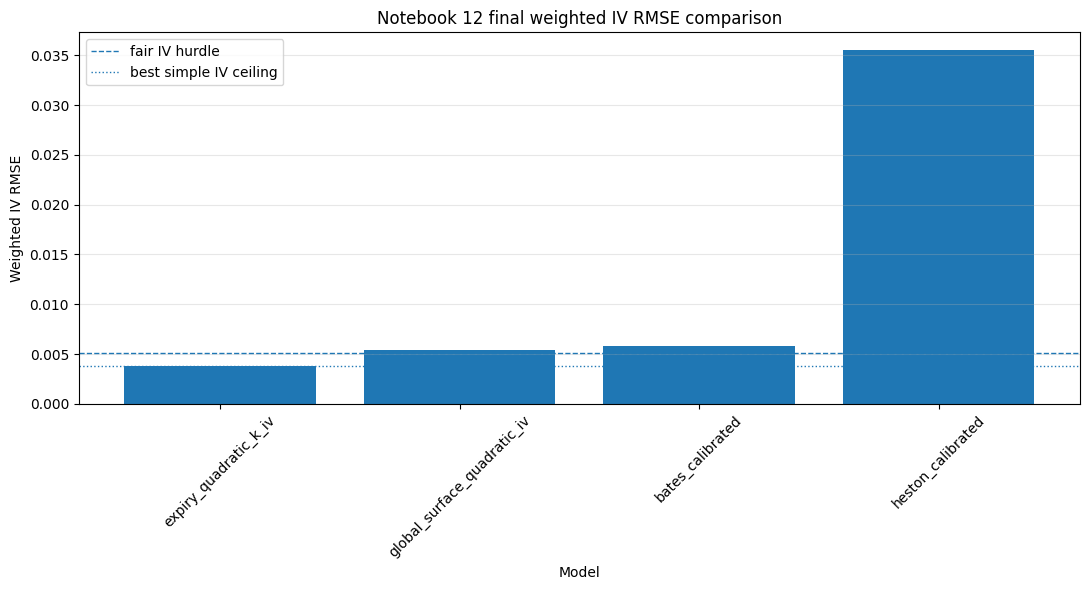

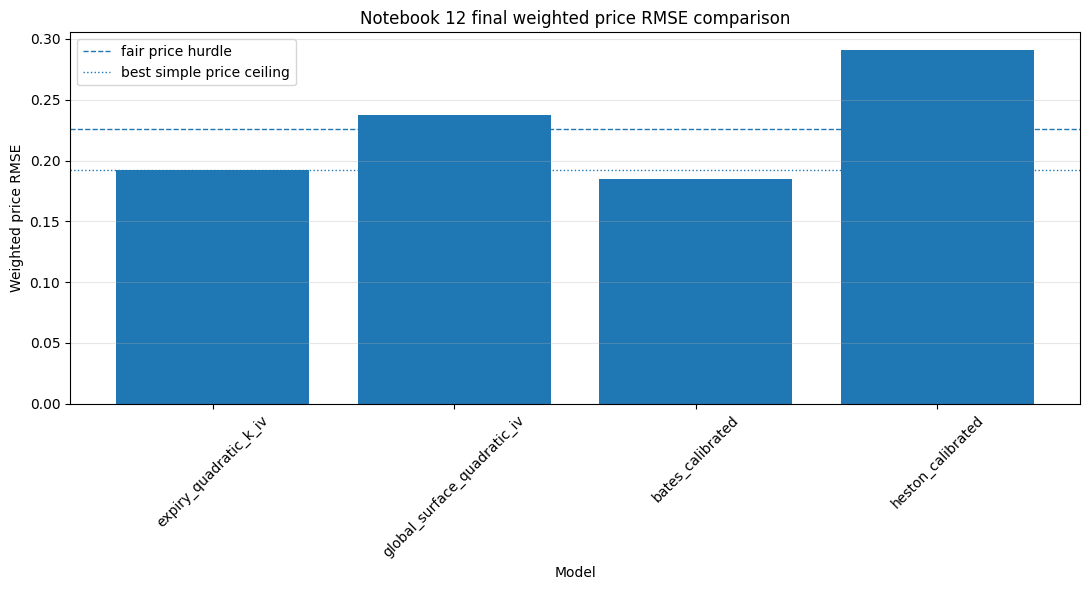

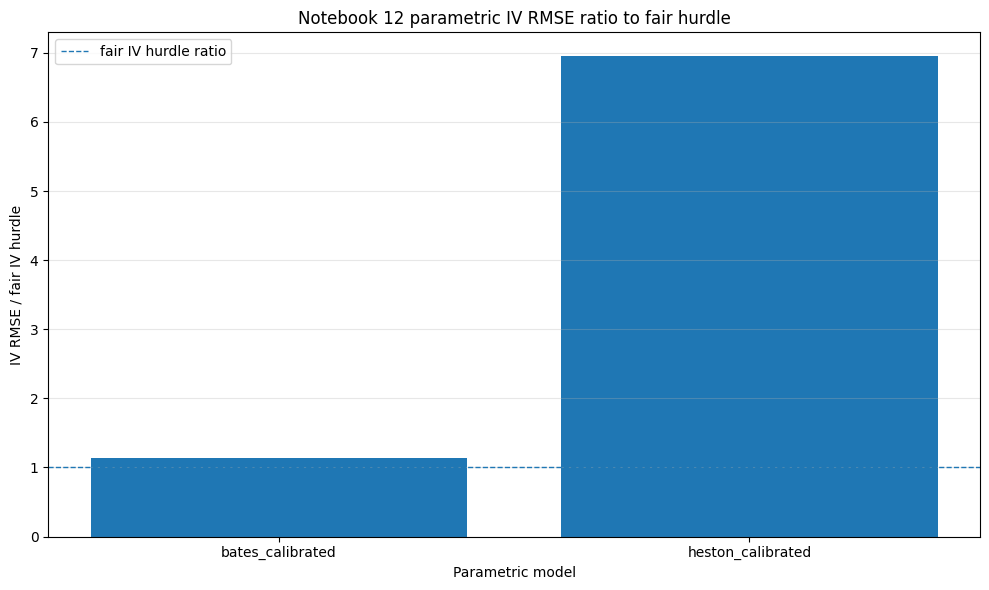

Notebook 12 final model comparison and model-risk verdict
Final verdict:                         CONDITIONAL_PASS
Model-risk level:                      elevated_but_usable_for_diagnostics
Selected surface representation:       expiry_quadratic_k_iv
Selected parametric diagnostic model:  bates_calibrated
Low-complexity reference baseline:     global_surface_quadratic_iv
Best simple reference baseline:        expiry_quadratic_k_iv
Fair IV hurdle:                        0.0051131876
Fair price hurdle:                     0.2255551903
Best simple IV ceiling:                0.0037868480
Best simple price ceiling:             0.1922602487
Selected parametric IV RMSE:           0.0057866060
Selected parametric price RMSE:        0.1849124015
Bates IV improvement vs Heston:        0.837163
Bates price improvement vs Heston:     0.364313
All blocking gates passed:             True
Final gate passed:                     True
----------------------------------------------------------------------

,model_name,model_class,parameter_count_estimate,weighted_iv_rmse,weighted_price_rmse,iv_rmse_ratio_to_fair_hurdle,price_rmse_ratio_to_fair_hurdle,beats_fair_iv_hurdle,beats_fair_price_hurdle,beats_best_simple_iv_ceiling,beats_best_simple_price_ceiling,rank_by_iv_rmse,rank_by_price_rmse,notes
0,expiry_quadratic_k_iv,simple_baseline,24,0.0037868480,0.1922602487,0.7406041557,0.8523867192,True,True,True,True,1,2,Simple IV baseline; not a structural option-pr...
1,global_surface_quadratic_iv,simple_baseline,6,0.0053823027,0.2374265161,1.0526315789,1.0526315789,False,False,False,False,2,3,Simple IV baseline; not a structural option-pr...
2,bates_calibrated,parametric_stochastic_volatility_jump,8,0.0057866060,0.1849124015,1.1317022751,0.8198100043,False,True,False,True,3,1,Materially improves over Heston and beats the ...
3,global_quadratic_k_iv,simple_baseline,3,0.0187756262,0.5334389764,3.6720002563,2.3650042177,False,False,False,False,4,5,Simple IV baseline; not a structural option-pr...
4,expiry_moneyness_bucket_weighted_mean_iv,simple_baseline,48,0.0219703159,1.0752111099,4.2967944006,4.7669535272,False,False,False,False,5,6,Simple IV baseline; not a structural option-pr...
5,moneyness_bucket_weighted_mean_iv,simple_baseline,6,0.0257417601,1.2041001472,5.0343860081,5.3383836819,False,False,False,False,6,7,Simple IV baseline; not a structural option-pr...
6,heston_calibrated,parametric_stochastic_volatility,5,0.0355361064,0.2908860496,6.9498929301,1.2896446730,False,False,False,False,7,4,Numerically stable but empirically weak; resid...
7,expiry_weighted_mean_iv,simple_baseline,8,0.0549997427,2.3481508716,10.7564491958,10.4105379647,False,False,False,False,8,10,Simple IV baseline; not a structural option-pr...
8,global_weighted_mean_iv,simple_baseline,1,0.0552275818,2.2940674242,10.8010082929,10.1707587453,False,False,False,False,9,9,Simple IV baseline; not a structural option-pr...
9,global_weighted_median_iv,simple_baseline,1,0.0560177944,1.9372601814,10.9555523241,8.5888521515,False,False,False,False,10,8,Simple IV baseline; not a structural option-pr...


----------------------------------------------------------------------------------------
Model-risk verdict:


,run_tag,final_verdict,model_risk_level,selected_surface_model,selected_parametric_model,low_complexity_reference_model,best_simple_reference_model,fair_iv_hurdle,fair_price_hurdle,best_simple_iv_ceiling,best_simple_price_ceiling,selected_parametric_iv_rmse,selected_parametric_price_rmse,selected_parametric_beats_fair_iv,selected_parametric_beats_fair_price,selected_parametric_beats_best_simple_iv,selected_parametric_beats_best_simple_price,bates_iv_improvement_vs_heston,bates_price_improvement_vs_heston,bates_materially_improves_heston,bates_iv_close_to_fair_hurdle,bates_jump_active,bates_jump_not_degenerate,all_structural_blocking_gates_passed,warning_failure_count,verdict_reason,downstream_recommendation
0,n12_20260706T023331Z,CONDITIONAL_PASS,elevated_but_usable_for_diagnostics,expiry_quadratic_k_iv,bates_calibrated,global_surface_quadratic_iv,expiry_quadratic_k_iv,0.0051131876,0.2255551903,0.0037868480,0.1922602487,0.0057866060,0.1849124015,False,True,False,True,0.8371626316,0.3643132705,True,True,True,True,True,7,Bates materially improves over Heston and beat...,Use the repaired arbitrage-aware surface or si...


----------------------------------------------------------------------------------------
Model use policy:


...

----------------------------------------------------------------------------------------
Blocking gate status:


,run_tag,gate_name,blocking_passed,blocking_failure_count,warning_failure_count
0,n12_20260706T023331Z,heston_calibration_gate,True,0,3
1,n12_20260706T023331Z,heston_diagnostics_gate,True,0,2
2,n12_20260706T023331Z,bates_calibration_gate,True,0,2
3,n12_20260706T023331Z,parametric_target_gate,True,0,0
4,n12_20260706T023331Z,heston_kernel_gate,True,0,0
5,n12_20260706T023331Z,baseline_gate,True,0,0
6,n12_20260706T023331Z,surface_diagnostics_gate,True,0,0


----------------------------------------------------------------------------------------
Final Notebook 12 gate:


,check_name,passed,severity,value,threshold
0,final_model_comparison_nonempty,True,blocking,10,> 0
1,final_verdict_assigned,True,blocking,CONDITIONAL_PASS,PASS / CONDITIONAL_PASS / BASELINE_ONLY / FAIL
2,selected_surface_model_available,True,blocking,expiry_quadratic_k_iv,available
3,selected_parametric_model_available,True,blocking,bates_calibrated,available
4,all_structural_blocking_gates_passed,True,blocking,True,True
5,parametric_model_not_overstated,True,blocking,False,True if verdict is PASS
6,conditional_pass_has_reason,True,blocking,"{'bates_materially_improves_heston': True, 'ba...",all True if verdict is CONDITIONAL_PASS
7,single_date_limitation_disclosed,True,blocking,Use the repaired arbitrage-aware surface or si...,mentions single-date or multi-date limitation
8,warning_inventory_available,True,warning,7,> 0


----------------------------------------------------------------------------------------
Verdict reason:
Bates materially improves over Heston and beats the fair price hurdle, while remaining close to—but not below—the fair IV hurdle. The jump component is active and not degenerate. However, the best simple IV surface baseline still dominates in IV space, so Bates should be used as a parametric diagnostic or stress layer, not as the best representation of the surface.
----------------------------------------------------------------------------------------
Downstream recommendation:
Use the repaired arbitrage-aware surface or simple surface baseline for surface representation. Use Bates as the preferred parametric diagnostic and stress-testing layer. Do not use Heston as the final calibrated model. Do not claim production readiness or temporal out-of-sample robustness from this single quote date.
----------------------------------------------------------------------------------------
Ne

In [13]:
# ============================================================
# Notebook 12 — Final Model Comparison and Model-Risk Verdict
# ============================================================
#
# Purpose:
#   Consolidate all Notebook 12 evidence into a final model-risk verdict:
#       1. simple baselines,
#       2. Heston calibration,
#       3. Bates incremental diagnostic calibration,
#       4. numerical gates,
#       5. empirical hurdle tests,
#       6. downstream use policy.
#
# Important:
#   The final verdict separates:
#       - best surface representation,
#       - best parametric diagnostic model,
#       - production-readiness claim.
#
# Outputs:
#   n12_final_model_comparison
#   n12_model_risk_verdict
#   n12_model_use_policy
#   n12_model_risk_warning_inventory
#   n12_notebook12_final_gate
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Output paths for this stage
# ------------------------------------------------------------

N12_OUTPUTS.update(
    {
        "final_model_comparison": N12_TABLE_DIR / f"n12_final_model_comparison_{RUN_TAG}.csv",
        "final_model_comparison_latest": N12_TABLE_DIR / "n12_final_model_comparison_latest.csv",
        "model_risk_verdict": N12_TABLE_DIR / f"n12_model_risk_verdict_{RUN_TAG}.csv",
        "model_risk_verdict_latest": N12_TABLE_DIR / "n12_model_risk_verdict_latest.csv",
        "model_use_policy": N12_TABLE_DIR / f"n12_model_use_policy_{RUN_TAG}.csv",
        "model_use_policy_latest": N12_TABLE_DIR / "n12_model_use_policy_latest.csv",
        "model_risk_warning_inventory": N12_TABLE_DIR / f"n12_model_risk_warning_inventory_{RUN_TAG}.csv",
        "model_risk_warning_inventory_latest": N12_TABLE_DIR / "n12_model_risk_warning_inventory_latest.csv",
        "notebook12_final_gate": N12_TABLE_DIR / f"n12_notebook12_final_gate_{RUN_TAG}.csv",
        "notebook12_final_gate_latest": N12_TABLE_DIR / "n12_notebook12_final_gate_latest.csv",
        "notebook12_final_manifest": N12_LOG_DIR / f"n12_final_model_risk_manifest_{RUN_TAG}.json",
        "notebook12_final_manifest_latest": N12_LOG_DIR / "n12_final_model_risk_manifest_latest.json",
        "fig_final_iv_rmse_comparison": N12_FIGURE_DIR / f"n12_final_iv_rmse_comparison_{RUN_TAG}.png",
        "fig_final_price_rmse_comparison": N12_FIGURE_DIR / f"n12_final_price_rmse_comparison_{RUN_TAG}.png",
        "fig_final_parametric_vs_baseline_hurdles": N12_FIGURE_DIR / f"n12_final_parametric_vs_baseline_hurdles_{RUN_TAG}.png",
    }
)


# ------------------------------------------------------------
# Guard against accidental out-of-order execution
# ------------------------------------------------------------

_REQUIRED_FINAL_INPUT_NAMES = [
    "n12_baseline_validation_summary",
    "n12_calibration_hurdles",
    "n12_heston_calibration_summary",
    "n12_heston_calibration_gate",
    "n12_heston_diagnostics_gate",
    "n12_bates_calibration_summary",
    "n12_bates_calibration_gate",
    "n12_parametric_target",
    "RUN_TAG",
    "N12_POLICY",
    "N12_TABLE_DIR",
    "N12_FIGURE_DIR",
    "N12_LOG_DIR",
    "N12_OUTPUTS",
]

missing_required_names = [
    name for name in _REQUIRED_FINAL_INPUT_NAMES
    if name not in globals()
]

if missing_required_names:
    raise NameError(
        "Notebook 12 final comparison cell was run before required model-comparison cells. "
        f"Missing names: {missing_required_names}"
    )


# ------------------------------------------------------------
# Local helpers
# ------------------------------------------------------------

def final_safe_float(value: Any) -> float:
    """Return finite float or nan."""
    try:
        value = float(value)
    except Exception:
        return np.nan

    return value if np.isfinite(value) else np.nan


def final_safe_bool(value: Any) -> bool:
    """Return a strict Python bool."""
    if isinstance(value, (bool, np.bool_)):
        return bool(value)

    if pd.isna(value):
        return False

    if isinstance(value, str):
        return value.strip().lower() in {"true", "1", "yes", "y"}

    return bool(value)


def final_lookup_hurdle(hurdle_name: str) -> float:
    """Read a hurdle value from n12_calibration_hurdles."""
    hit = n12_calibration_hurdles.query("hurdle_name == @hurdle_name").copy()

    if hit.empty:
        return np.nan

    return final_safe_float(hit.iloc[0]["hurdle_value"])


def final_lookup_hurdle_reference(hurdle_name: str) -> str:
    """Read reference model from n12_calibration_hurdles."""
    hit = n12_calibration_hurdles.query("hurdle_name == @hurdle_name").copy()

    if hit.empty:
        return ""

    return str(hit.iloc[0].get("reference_model", ""))


def final_metric(row: Dict[str, Any], key: str) -> float:
    """Read a metric from a dict-like row."""
    return final_safe_float(row.get(key, np.nan))


def final_estimate_baseline_parameter_count(model_name: str) -> int:
    """Approximate effective parameter count for simple IV baselines."""
    name = str(model_name).lower()

    expiry_count = int(n12_parametric_target["expiry_key"].nunique(dropna=True))
    bucket_count = int(n12_parametric_target["moneyness_bucket"].nunique(dropna=True))

    if "global_weighted_mean" in name or "global_weighted_median" in name:
        return 1

    if "expiry_weighted_mean" in name:
        return max(expiry_count, 1)

    if "moneyness_bucket_weighted_mean" in name and "expiry_moneyness" not in name:
        return max(bucket_count, 1)

    if "expiry_moneyness_bucket_weighted_mean" in name:
        return max(expiry_count * bucket_count, 1)

    if "global_quadratic_k" in name:
        return 3

    if "global_surface_quadratic" in name:
        return 6

    if "expiry_quadratic_k" in name:
        return max(3 * expiry_count, 1)

    return np.nan


def final_gate_blocking_passed(gate_df: pd.DataFrame) -> bool:
    """True if a gate has no failed blocking checks."""
    if gate_df is None or gate_df.empty:
        return False

    blocking_failures = gate_df.query("severity == 'blocking' and passed == False")
    return bool(blocking_failures.empty)


def final_collect_failed_warnings(gate_name: str, gate_df: pd.DataFrame) -> pd.DataFrame:
    """Collect failed warning checks from a gate table."""
    if gate_df is None or gate_df.empty:
        return pd.DataFrame(
            columns=[
                "run_tag",
                "gate_name",
                "check_name",
                "severity",
                "value",
                "threshold",
                "detail",
            ]
        )

    failed = gate_df.query("severity == 'warning' and passed == False").copy()

    if failed.empty:
        return pd.DataFrame(
            columns=[
                "run_tag",
                "gate_name",
                "check_name",
                "severity",
                "value",
                "threshold",
                "detail",
            ]
        )

    failed.insert(0, "gate_name", gate_name)

    if "run_tag" not in failed.columns:
        failed.insert(0, "run_tag", RUN_TAG)

    keep_cols = [
        col
        for col in [
            "run_tag",
            "gate_name",
            "check_name",
            "severity",
            "value",
            "threshold",
            "detail",
        ]
        if col in failed.columns
    ]

    return failed[keep_cols].reset_index(drop=True)


def final_score_label_to_row(summary_df: pd.DataFrame, score_label: str) -> Dict[str, Any]:
    """Get one score row from a calibration summary."""
    hit = summary_df.query("score_label == @score_label").copy()

    if hit.empty:
        return {}

    return hit.iloc[0].to_dict()


# ------------------------------------------------------------
# Hurdles and references
# ------------------------------------------------------------

fair_iv_hurdle = final_lookup_hurdle("fair_parametric_iv_hurdle")
fair_price_hurdle = final_lookup_hurdle("fair_parametric_price_hurdle")
best_simple_iv_ceiling = final_lookup_hurdle("best_simple_surface_fit_ceiling_iv")
best_simple_price_ceiling = final_lookup_hurdle("best_simple_surface_fit_ceiling_price")

low_complexity_reference_model = final_lookup_hurdle_reference("fair_parametric_iv_hurdle")
best_simple_reference_model = final_lookup_hurdle_reference("best_simple_surface_fit_ceiling_iv")

if not low_complexity_reference_model and "LOW_COMPLEXITY_REFERENCE_MODEL" in globals():
    low_complexity_reference_model = str(LOW_COMPLEXITY_REFERENCE_MODEL)

if not best_simple_reference_model and "ALL_SIMPLE_REFERENCE_MODEL" in globals():
    best_simple_reference_model = str(ALL_SIMPLE_REFERENCE_MODEL)


# ------------------------------------------------------------
# Build final model comparison table
# ------------------------------------------------------------

comparison_rows = []

baseline_insample = (
    n12_baseline_validation_summary
    .query("validation_family == 'in_sample'")
    .copy()
    .reset_index(drop=True)
)

for _, row in baseline_insample.iterrows():
    model_name = str(row["model_name"])

    comparison_rows.append(
        {
            "run_tag": RUN_TAG,
            "model_name": model_name,
            "model_class": "simple_baseline",
            "score_scope": "full_surface_in_sample",
            "parameter_count_estimate": final_estimate_baseline_parameter_count(model_name),
            "optimizer_success": np.nan,
            "weighted_iv_rmse": final_safe_float(row.get("weighted_iv_rmse", np.nan)),
            "weighted_iv_mae": final_safe_float(row.get("weighted_iv_mae", np.nan)),
            "weighted_iv_bias": final_safe_float(row.get("weighted_iv_bias", np.nan)),
            "weighted_price_rmse": final_safe_float(row.get("weighted_price_rmse", np.nan)),
            "weighted_price_mae": final_safe_float(row.get("weighted_price_mae", np.nan)),
            "weighted_price_bias": final_safe_float(row.get("weighted_price_bias", np.nan)),
            "raw_bound_violation_rate": np.nan,
            "safe_bound_violation_rate": np.nan,
            "iv_failure_rate": np.nan,
            "boundary_hit_count": np.nan,
            "feller_condition_passed": np.nan,
            "jump_active_flag": np.nan,
            "jump_degenerate_flag": np.nan,
            "beats_fair_iv_hurdle": (
                final_safe_float(row.get("weighted_iv_rmse", np.nan)) <= fair_iv_hurdle
                if np.isfinite(fair_iv_hurdle)
                else False
            ),
            "beats_fair_price_hurdle": (
                final_safe_float(row.get("weighted_price_rmse", np.nan)) <= fair_price_hurdle
                if np.isfinite(fair_price_hurdle)
                else False
            ),
            "beats_best_simple_iv_ceiling": (
                final_safe_float(row.get("weighted_iv_rmse", np.nan)) <= best_simple_iv_ceiling
                if np.isfinite(best_simple_iv_ceiling)
                else False
            ),
            "beats_best_simple_price_ceiling": (
                final_safe_float(row.get("weighted_price_rmse", np.nan)) <= best_simple_price_ceiling
                if np.isfinite(best_simple_price_ceiling)
                else False
            ),
            "notes": "Simple IV baseline; not a structural option-pricing model.",
        }
    )

heston_full = final_score_label_to_row(
    n12_heston_calibration_summary,
    "full_surface_score",
)

bates_full = final_score_label_to_row(
    n12_bates_calibration_summary,
    "full_surface_score",
)

if heston_full:
    comparison_rows.append(
        {
            "run_tag": RUN_TAG,
            "model_name": "heston_calibrated",
            "model_class": "parametric_stochastic_volatility",
            "score_scope": "full_surface_score",
            "parameter_count_estimate": 5,
            "optimizer_success": final_safe_bool(heston_full.get("optimizer_success", False)),
            "weighted_iv_rmse": final_metric(heston_full, "weighted_iv_rmse"),
            "weighted_iv_mae": final_metric(heston_full, "weighted_iv_mae"),
            "weighted_iv_bias": final_metric(heston_full, "weighted_iv_bias"),
            "weighted_price_rmse": final_metric(heston_full, "weighted_price_rmse"),
            "weighted_price_mae": final_metric(heston_full, "weighted_price_mae"),
            "weighted_price_bias": final_metric(heston_full, "weighted_price_bias"),
            "raw_bound_violation_rate": final_metric(heston_full, "raw_bound_violation_rate"),
            "safe_bound_violation_rate": final_metric(heston_full, "safe_bound_violation_rate"),
            "iv_failure_rate": final_metric(heston_full, "iv_failure_rate"),
            "boundary_hit_count": final_metric(heston_full, "boundary_hit_count"),
            "feller_condition_passed": final_safe_bool(heston_full.get("feller_condition_passed", False)),
            "jump_active_flag": np.nan,
            "jump_degenerate_flag": np.nan,
            "beats_fair_iv_hurdle": final_safe_bool(heston_full.get("beats_fair_iv_hurdle", False)),
            "beats_fair_price_hurdle": final_safe_bool(heston_full.get("beats_fair_price_hurdle", False)),
            "beats_best_simple_iv_ceiling": final_safe_bool(heston_full.get("beats_best_simple_iv_ceiling", False)),
            "beats_best_simple_price_ceiling": final_safe_bool(heston_full.get("beats_best_simple_price_ceiling", False)),
            "notes": "Numerically stable but empirically weak; residuals concentrated in short-maturity left-tail puts.",
        }
    )

if bates_full:
    comparison_rows.append(
        {
            "run_tag": RUN_TAG,
            "model_name": "bates_calibrated",
            "model_class": "parametric_stochastic_volatility_jump",
            "score_scope": "full_surface_score",
            "parameter_count_estimate": 8,
            "optimizer_success": final_safe_bool(bates_full.get("optimizer_success", False)),
            "weighted_iv_rmse": final_metric(bates_full, "weighted_iv_rmse"),
            "weighted_iv_mae": final_metric(bates_full, "weighted_iv_mae"),
            "weighted_iv_bias": final_metric(bates_full, "weighted_iv_bias"),
            "weighted_price_rmse": final_metric(bates_full, "weighted_price_rmse"),
            "weighted_price_mae": final_metric(bates_full, "weighted_price_mae"),
            "weighted_price_bias": final_metric(bates_full, "weighted_price_bias"),
            "raw_bound_violation_rate": final_metric(bates_full, "raw_bound_violation_rate"),
            "safe_bound_violation_rate": final_metric(bates_full, "safe_bound_violation_rate"),
            "iv_failure_rate": final_metric(bates_full, "iv_failure_rate"),
            "boundary_hit_count": final_metric(bates_full, "boundary_hit_count"),
            "feller_condition_passed": final_safe_bool(bates_full.get("feller_condition_passed", False)),
            "jump_active_flag": final_safe_bool(bates_full.get("jump_active_flag", False)),
            "jump_degenerate_flag": final_safe_bool(bates_full.get("jump_degenerate_flag", True)),
            "beats_fair_iv_hurdle": final_safe_bool(bates_full.get("beats_fair_iv_hurdle", False)),
            "beats_fair_price_hurdle": final_safe_bool(bates_full.get("beats_fair_price_hurdle", False)),
            "beats_best_simple_iv_ceiling": final_safe_bool(bates_full.get("beats_best_simple_iv_ceiling", False)),
            "beats_best_simple_price_ceiling": final_safe_bool(bates_full.get("beats_best_simple_price_ceiling", False)),
            "notes": "Materially improves over Heston and beats the price hurdle, but misses the fair IV hurdle.",
        }
    )

n12_final_model_comparison = pd.DataFrame(comparison_rows)

if n12_final_model_comparison.empty:
    raise RuntimeError("Final model comparison table is empty.")

n12_final_model_comparison["iv_rmse_gap_to_fair_hurdle"] = (
    n12_final_model_comparison["weighted_iv_rmse"] - fair_iv_hurdle
)

n12_final_model_comparison["price_rmse_gap_to_fair_hurdle"] = (
    n12_final_model_comparison["weighted_price_rmse"] - fair_price_hurdle
)

n12_final_model_comparison["iv_rmse_ratio_to_fair_hurdle"] = (
    n12_final_model_comparison["weighted_iv_rmse"] / fair_iv_hurdle
    if np.isfinite(fair_iv_hurdle) and fair_iv_hurdle > 0
    else np.nan
)

n12_final_model_comparison["price_rmse_ratio_to_fair_hurdle"] = (
    n12_final_model_comparison["weighted_price_rmse"] / fair_price_hurdle
    if np.isfinite(fair_price_hurdle) and fair_price_hurdle > 0
    else np.nan
)

n12_final_model_comparison = (
    n12_final_model_comparison
    .sort_values(["weighted_iv_rmse", "weighted_price_rmse", "parameter_count_estimate"])
    .reset_index(drop=True)
)

n12_final_model_comparison["rank_by_iv_rmse"] = (
    n12_final_model_comparison["weighted_iv_rmse"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

n12_final_model_comparison["rank_by_price_rmse"] = (
    n12_final_model_comparison["weighted_price_rmse"]
    .rank(method="dense", ascending=True)
    .astype(int)
)


# ------------------------------------------------------------
# Best model selections
# ------------------------------------------------------------

finite_iv_comparison = n12_final_model_comparison.loc[
    np.isfinite(n12_final_model_comparison["weighted_iv_rmse"])
].copy()

finite_price_comparison = n12_final_model_comparison.loc[
    np.isfinite(n12_final_model_comparison["weighted_price_rmse"])
].copy()

parametric_comparison = n12_final_model_comparison.query(
    "model_class in ['parametric_stochastic_volatility', 'parametric_stochastic_volatility_jump']"
).copy()

simple_comparison = n12_final_model_comparison.query(
    "model_class == 'simple_baseline'"
).copy()

best_surface_model_by_iv = (
    finite_iv_comparison.sort_values(["weighted_iv_rmse", "parameter_count_estimate"]).iloc[0].to_dict()
    if not finite_iv_comparison.empty
    else {}
)

best_surface_model_by_price = (
    finite_price_comparison.sort_values(["weighted_price_rmse", "parameter_count_estimate"]).iloc[0].to_dict()
    if not finite_price_comparison.empty
    else {}
)

best_parametric_model_by_iv = (
    parametric_comparison.sort_values(["weighted_iv_rmse", "weighted_price_rmse"]).iloc[0].to_dict()
    if not parametric_comparison.empty
    else {}
)

best_simple_model_by_iv = (
    simple_comparison.sort_values(["weighted_iv_rmse", "weighted_price_rmse"]).iloc[0].to_dict()
    if not simple_comparison.empty
    else {}
)

selected_surface_model = str(best_surface_model_by_iv.get("model_name", "unavailable"))
selected_parametric_model = str(best_parametric_model_by_iv.get("model_name", "unavailable"))

selected_parametric_iv_rmse = final_metric(best_parametric_model_by_iv, "weighted_iv_rmse")
selected_parametric_price_rmse = final_metric(best_parametric_model_by_iv, "weighted_price_rmse")

selected_parametric_beats_fair_iv = final_safe_bool(
    best_parametric_model_by_iv.get("beats_fair_iv_hurdle", False)
)

selected_parametric_beats_fair_price = final_safe_bool(
    best_parametric_model_by_iv.get("beats_fair_price_hurdle", False)
)

selected_parametric_beats_best_simple_iv = final_safe_bool(
    best_parametric_model_by_iv.get("beats_best_simple_iv_ceiling", False)
)

selected_parametric_beats_best_simple_price = final_safe_bool(
    best_parametric_model_by_iv.get("beats_best_simple_price_ceiling", False)
)


# ------------------------------------------------------------
# Gate inventory
# ------------------------------------------------------------

gate_tables = {
    "heston_calibration_gate": n12_heston_calibration_gate,
    "heston_diagnostics_gate": n12_heston_diagnostics_gate,
    "bates_calibration_gate": n12_bates_calibration_gate,
}

if "n12_parametric_target_gate" in globals():
    gate_tables["parametric_target_gate"] = n12_parametric_target_gate

if "n12_heston_kernel_gate" in globals():
    gate_tables["heston_kernel_gate"] = n12_heston_kernel_gate

if "n12_baseline_gate" in globals():
    gate_tables["baseline_gate"] = n12_baseline_gate

if "n12_surface_diagnostics_gate" in globals():
    gate_tables["surface_diagnostics_gate"] = n12_surface_diagnostics_gate

if "n12_target_gate" in globals():
    gate_tables["target_gate"] = n12_target_gate

if "n12_input_gate" in globals():
    gate_tables["input_gate"] = n12_input_gate

blocking_gate_status_rows = []

for gate_name, gate_df in gate_tables.items():
    if gate_df is None or gate_df.empty:
        blocking_gate_status_rows.append(
            {
                "run_tag": RUN_TAG,
                "gate_name": gate_name,
                "blocking_passed": False,
                "blocking_failure_count": np.nan,
                "warning_failure_count": np.nan,
            }
        )
        continue

    blocking_failure_count = int(
        gate_df.query("severity == 'blocking' and passed == False").shape[0]
    )

    warning_failure_count = int(
        gate_df.query("severity == 'warning' and passed == False").shape[0]
    )

    blocking_gate_status_rows.append(
        {
            "run_tag": RUN_TAG,
            "gate_name": gate_name,
            "blocking_passed": blocking_failure_count == 0,
            "blocking_failure_count": blocking_failure_count,
            "warning_failure_count": warning_failure_count,
        }
    )

n12_blocking_gate_status = pd.DataFrame(blocking_gate_status_rows)

all_structural_blocking_gates_passed = bool(
    n12_blocking_gate_status["blocking_passed"].all()
)

warning_inventory_parts = [
    final_collect_failed_warnings(gate_name, gate_df)
    for gate_name, gate_df in gate_tables.items()
]

n12_model_risk_warning_inventory = (
    pd.concat(warning_inventory_parts, ignore_index=True)
    if warning_inventory_parts
    else pd.DataFrame()
)

if n12_model_risk_warning_inventory.empty:
    n12_model_risk_warning_inventory = pd.DataFrame(
        [
            {
                "run_tag": RUN_TAG,
                "gate_name": "all",
                "check_name": "no_failed_warning_checks",
                "severity": "warning",
                "value": 0,
                "threshold": "0",
                "detail": "No failed warning-level checks were collected.",
            }
        ]
    )


# ------------------------------------------------------------
# Verdict logic
# ------------------------------------------------------------

bates_available = "bates_calibrated" in set(n12_final_model_comparison["model_name"])
heston_available = "heston_calibrated" in set(n12_final_model_comparison["model_name"])

bates_row = (
    n12_final_model_comparison.query("model_name == 'bates_calibrated'").iloc[0].to_dict()
    if bates_available
    else {}
)

heston_row = (
    n12_final_model_comparison.query("model_name == 'heston_calibrated'").iloc[0].to_dict()
    if heston_available
    else {}
)

bates_iv_rmse = final_metric(bates_row, "weighted_iv_rmse")
bates_price_rmse = final_metric(bates_row, "weighted_price_rmse")
heston_iv_rmse = final_metric(heston_row, "weighted_iv_rmse")
heston_price_rmse = final_metric(heston_row, "weighted_price_rmse")

bates_iv_improvement_vs_heston = (
    (heston_iv_rmse - bates_iv_rmse) / heston_iv_rmse
    if np.isfinite(heston_iv_rmse) and heston_iv_rmse > 0 and np.isfinite(bates_iv_rmse)
    else np.nan
)

bates_price_improvement_vs_heston = (
    (heston_price_rmse - bates_price_rmse) / heston_price_rmse
    if np.isfinite(heston_price_rmse) and heston_price_rmse > 0 and np.isfinite(bates_price_rmse)
    else np.nan
)

bates_materially_improves_heston = bool(
    np.isfinite(bates_iv_improvement_vs_heston)
    and np.isfinite(bates_price_improvement_vs_heston)
    and bates_iv_improvement_vs_heston >= float(N12_POLICY.material_iv_rmse_improvement)
    and bates_price_improvement_vs_heston >= float(N12_POLICY.material_price_rmse_improvement)
)

bates_iv_close_to_fair_hurdle = bool(
    np.isfinite(bates_iv_rmse)
    and np.isfinite(fair_iv_hurdle)
    and bates_iv_rmse <= fair_iv_hurdle * 1.25
)

bates_jump_active = final_safe_bool(bates_row.get("jump_active_flag", False))
bates_jump_not_degenerate = not final_safe_bool(bates_row.get("jump_degenerate_flag", True))

if not all_structural_blocking_gates_passed:
    final_verdict = "FAIL"
    model_risk_level = "unacceptable"
    verdict_reason = (
        "At least one blocking structural gate failed. The Notebook 12 model-risk layer "
        "cannot be used until the failed gate is fixed."
    )
elif (
    selected_parametric_beats_fair_iv
    and selected_parametric_beats_fair_price
    and selected_parametric_beats_best_simple_iv
    and selected_parametric_beats_best_simple_price
):
    final_verdict = "PASS"
    model_risk_level = "moderate"
    verdict_reason = (
        "The selected parametric model beats both fair low-complexity hurdles and the best simple "
        "surface-fit ceilings. This would support a stronger parametric surface claim, subject to "
        "multi-date validation."
    )
elif (
    bates_available
    and bates_materially_improves_heston
    and final_safe_bool(bates_row.get("beats_fair_price_hurdle", False))
    and bates_iv_close_to_fair_hurdle
    and bates_jump_active
    and bates_jump_not_degenerate
):
    final_verdict = "CONDITIONAL_PASS"
    model_risk_level = "elevated_but_usable_for_diagnostics"
    verdict_reason = (
        "Bates materially improves over Heston and beats the fair price hurdle, while remaining close "
        "to—but not below—the fair IV hurdle. The jump component is active and not degenerate. "
        "However, the best simple IV surface baseline still dominates in IV space, so Bates should be "
        "used as a parametric diagnostic or stress layer, not as the best representation of the surface."
    )
elif (
    selected_surface_model in set(simple_comparison["model_name"])
    and not selected_parametric_beats_fair_iv
):
    final_verdict = "BASELINE_ONLY"
    model_risk_level = "high_for_parametric_use"
    verdict_reason = (
        "Simple surface baselines dominate the parametric models in IV space. The calibrated "
        "parametric models should not be used as the primary surface representation."
    )
else:
    final_verdict = "FAIL"
    model_risk_level = "unresolved"
    verdict_reason = (
        "The final evidence is internally inconsistent or insufficient for a conditional pass."
    )

if final_verdict == "PASS":
    downstream_recommendation = (
        "Use the selected parametric model as the Notebook 12 calibrated model, but still require "
        "multi-date validation before any production or publication-level stability claim."
    )
elif final_verdict == "CONDITIONAL_PASS":
    downstream_recommendation = (
        "Use the repaired arbitrage-aware surface or simple surface baseline for surface representation. "
        "Use Bates as the preferred parametric diagnostic and stress-testing layer. Do not use Heston as "
        "the final calibrated model. Do not claim production readiness or temporal out-of-sample robustness "
        "from this single quote date."
    )
elif final_verdict == "BASELINE_ONLY":
    downstream_recommendation = (
        "Use the repaired arbitrage-aware surface and simple baselines only. Treat Heston/Bates outputs as "
        "failed or weak diagnostics, not calibrated pricing models."
    )
else:
    downstream_recommendation = (
        "Stop downstream model use until failed structural gates are repaired."
    )


# ------------------------------------------------------------
# Final verdict and use policy tables
# ------------------------------------------------------------

n12_model_risk_verdict = pd.DataFrame(
    [
        {
            "run_tag": RUN_TAG,
            "final_verdict": final_verdict,
            "model_risk_level": model_risk_level,
            "selected_surface_model": selected_surface_model,
            "selected_parametric_model": selected_parametric_model,
            "low_complexity_reference_model": low_complexity_reference_model,
            "best_simple_reference_model": best_simple_reference_model,
            "fair_iv_hurdle": fair_iv_hurdle,
            "fair_price_hurdle": fair_price_hurdle,
            "best_simple_iv_ceiling": best_simple_iv_ceiling,
            "best_simple_price_ceiling": best_simple_price_ceiling,
            "selected_parametric_iv_rmse": selected_parametric_iv_rmse,
            "selected_parametric_price_rmse": selected_parametric_price_rmse,
            "selected_parametric_beats_fair_iv": selected_parametric_beats_fair_iv,
            "selected_parametric_beats_fair_price": selected_parametric_beats_fair_price,
            "selected_parametric_beats_best_simple_iv": selected_parametric_beats_best_simple_iv,
            "selected_parametric_beats_best_simple_price": selected_parametric_beats_best_simple_price,
            "bates_iv_improvement_vs_heston": bates_iv_improvement_vs_heston,
            "bates_price_improvement_vs_heston": bates_price_improvement_vs_heston,
            "bates_materially_improves_heston": bates_materially_improves_heston,
            "bates_iv_close_to_fair_hurdle": bates_iv_close_to_fair_hurdle,
            "bates_jump_active": bates_jump_active,
            "bates_jump_not_degenerate": bates_jump_not_degenerate,
            "all_structural_blocking_gates_passed": all_structural_blocking_gates_passed,
            "warning_failure_count": int(
                n12_blocking_gate_status["warning_failure_count"]
                .fillna(0)
                .sum()
            ),
            "verdict_reason": verdict_reason,
            "downstream_recommendation": downstream_recommendation,
        }
    ]
)

n12_model_use_policy = pd.DataFrame(
    [
        {
            "run_tag": RUN_TAG,
            "use_case": "surface_representation",
            "recommended_model_or_artifact": selected_surface_model,
            "permission": "allowed",
            "condition": "Use for repaired-surface approximation and reporting; retain no-arbitrage diagnostics from N10/N11.",
            "reason": "Simple surface representation dominates parametric models in IV fit.",
        },
        {
            "run_tag": RUN_TAG,
            "use_case": "parametric_diagnostic",
            "recommended_model_or_artifact": selected_parametric_model,
            "permission": "allowed_with_warnings",
            "condition": "Use for diagnostic pricing, stress testing, and residual analysis; disclose missed IV hurdle and Feller warning.",
            "reason": "Bates materially improves over Heston and beats the fair price hurdle, but misses the fair IV hurdle.",
        },
        {
            "run_tag": RUN_TAG,
            "use_case": "heston_final_model",
            "recommended_model_or_artifact": "heston_calibrated",
            "permission": "not_recommended",
            "condition": "Keep only as a negative control and stochastic-volatility benchmark.",
            "reason": "Heston fails both fair hurdles and residuals are concentrated in short-dated left-tail puts.",
        },
        {
            "run_tag": RUN_TAG,
            "use_case": "production_pricing",
            "recommended_model_or_artifact": "none",
            "permission": "not_allowed",
            "condition": "Requires multi-date calibration, OOS validation, quote-time replication, transaction-cost assumptions, and independent implementation checks.",
            "reason": "Notebook 12 is single-date cross-sectional validation, not production certification.",
        },
        {
            "run_tag": RUN_TAG,
            "use_case": "publication_claim",
            "recommended_model_or_artifact": "v1.1 pipeline",
            "permission": "allowed_with_precise_language",
            "condition": "Claim a theory-first, no-arbitrage-aware diagnostic pipeline; do not claim a production-grade calibrated model.",
            "reason": "The project successfully reaches honest model-risk classification.",
        },
    ]
)


# ------------------------------------------------------------
# Final gate
# ------------------------------------------------------------

n12_notebook12_final_gate = pd.DataFrame(
    [
        build_check(
            "final_model_comparison_nonempty",
            len(n12_final_model_comparison) > 0,
            "blocking",
            "Final model comparison table must be nonempty.",
            int(len(n12_final_model_comparison)),
            "> 0",
        ),
        build_check(
            "final_verdict_assigned",
            final_verdict in {"PASS", "CONDITIONAL_PASS", "BASELINE_ONLY", "FAIL"},
            "blocking",
            "Notebook 12 must assign a recognized final verdict.",
            final_verdict,
            "PASS / CONDITIONAL_PASS / BASELINE_ONLY / FAIL",
        ),
        build_check(
            "selected_surface_model_available",
            bool(selected_surface_model and selected_surface_model != "unavailable"),
            "blocking",
            "A selected surface representation model must be identified.",
            selected_surface_model,
            "available",
        ),
        build_check(
            "selected_parametric_model_available",
            bool(selected_parametric_model and selected_parametric_model != "unavailable"),
            "blocking",
            "A selected parametric diagnostic model must be identified.",
            selected_parametric_model,
            "available",
        ),
        build_check(
            "all_structural_blocking_gates_passed",
            all_structural_blocking_gates_passed,
            "blocking",
            "All structural blocking gates must pass for the final Notebook 12 verdict to be usable.",
            bool(all_structural_blocking_gates_passed),
            "True",
        ),
        build_check(
            "parametric_model_not_overstated",
            final_verdict != "PASS" or selected_parametric_beats_best_simple_iv,
            "blocking",
            "A full PASS requires the selected parametric model to beat the best simple IV ceiling.",
            selected_parametric_beats_best_simple_iv,
            "True if verdict is PASS",
        ),
        build_check(
            "conditional_pass_has_reason",
            final_verdict != "CONDITIONAL_PASS" or (
                bates_materially_improves_heston
                and bates_jump_active
                and bates_jump_not_degenerate
            ),
            "blocking",
            "A conditional pass requires material Bates improvement and a nondegenerate jump component.",
            {
                "bates_materially_improves_heston": bates_materially_improves_heston,
                "bates_jump_active": bates_jump_active,
                "bates_jump_not_degenerate": bates_jump_not_degenerate,
            },
            "all True if verdict is CONDITIONAL_PASS",
        ),
        build_check(
            "single_date_limitation_disclosed",
            "single quote date" in downstream_recommendation.lower()
            or "multi-date" in downstream_recommendation.lower(),
            "blocking",
            "The final recommendation must disclose the single-date limitation.",
            downstream_recommendation,
            "mentions single-date or multi-date limitation",
        ),
        build_check(
            "warning_inventory_available",
            len(n12_model_risk_warning_inventory) > 0,
            "warning",
            "Warning inventory should be available for the final report.",
            int(len(n12_model_risk_warning_inventory)),
            "> 0",
        ),
    ]
)

n12_final_blocking_failures = n12_notebook12_final_gate.query(
    "severity == 'blocking' and passed == False"
).copy()

n12_final_gate_passed = bool(n12_final_blocking_failures.empty)


# ------------------------------------------------------------
# Persist artifacts
# ------------------------------------------------------------

write_table(
    n12_final_model_comparison,
    N12_OUTPUTS["final_model_comparison"],
    N12_OUTPUTS["final_model_comparison_latest"],
)

write_table(
    n12_model_risk_verdict,
    N12_OUTPUTS["model_risk_verdict"],
    N12_OUTPUTS["model_risk_verdict_latest"],
)

write_table(
    n12_model_use_policy,
    N12_OUTPUTS["model_use_policy"],
    N12_OUTPUTS["model_use_policy_latest"],
)

write_table(
    n12_model_risk_warning_inventory,
    N12_OUTPUTS["model_risk_warning_inventory"],
    N12_OUTPUTS["model_risk_warning_inventory_latest"],
)

write_table(
    n12_notebook12_final_gate,
    N12_OUTPUTS["notebook12_final_gate"],
    N12_OUTPUTS["notebook12_final_gate_latest"],
)

N12_FINAL_VERDICT = final_verdict
N12_SELECTED_SURFACE_MODEL = selected_surface_model
N12_SELECTED_PARAMETRIC_MODEL = selected_parametric_model
N12_DOWNSTREAM_RECOMMENDATION = downstream_recommendation

n12_final_model_risk_manifest = {
    "run_tag": RUN_TAG,
    "final_verdict": final_verdict,
    "model_risk_level": model_risk_level,
    "selected_surface_model": selected_surface_model,
    "selected_parametric_model": selected_parametric_model,
    "fair_iv_hurdle": float(fair_iv_hurdle),
    "fair_price_hurdle": float(fair_price_hurdle),
    "best_simple_iv_ceiling": float(best_simple_iv_ceiling),
    "best_simple_price_ceiling": float(best_simple_price_ceiling),
    "selected_parametric_iv_rmse": float(selected_parametric_iv_rmse),
    "selected_parametric_price_rmse": float(selected_parametric_price_rmse),
    "bates_iv_improvement_vs_heston": float(bates_iv_improvement_vs_heston),
    "bates_price_improvement_vs_heston": float(bates_price_improvement_vs_heston),
    "all_structural_blocking_gates_passed": bool(all_structural_blocking_gates_passed),
    "final_gate_passed": bool(n12_final_gate_passed),
    "verdict_reason": verdict_reason,
    "downstream_recommendation": downstream_recommendation,
    "artifact_paths": {
        "final_model_comparison": str(N12_OUTPUTS["final_model_comparison"]),
        "model_risk_verdict": str(N12_OUTPUTS["model_risk_verdict"]),
        "model_use_policy": str(N12_OUTPUTS["model_use_policy"]),
        "model_risk_warning_inventory": str(N12_OUTPUTS["model_risk_warning_inventory"]),
        "notebook12_final_gate": str(N12_OUTPUTS["notebook12_final_gate"]),
    },
}

write_json(
    n12_final_model_risk_manifest,
    N12_OUTPUTS["notebook12_final_manifest"],
)

write_json(
    n12_final_model_risk_manifest,
    N12_OUTPUTS["notebook12_final_manifest_latest"],
)


# ------------------------------------------------------------
# Figures
# ------------------------------------------------------------

N12_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plot_models = n12_final_model_comparison.copy()
plot_models = plot_models.loc[
    plot_models["model_name"].isin(
        [
            low_complexity_reference_model,
            best_simple_reference_model,
            "heston_calibrated",
            "bates_calibrated",
        ]
    )
].copy()

plot_models = plot_models.drop_duplicates(subset=["model_name"]).sort_values("weighted_iv_rmse")

if not plot_models.empty:
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bar(plot_models["model_name"], plot_models["weighted_iv_rmse"])
    ax.axhline(fair_iv_hurdle, linewidth=1, linestyle="--", label="fair IV hurdle")
    ax.axhline(best_simple_iv_ceiling, linewidth=1, linestyle=":", label="best simple IV ceiling")
    ax.set_title("Notebook 12 final weighted IV RMSE comparison")
    ax.set_xlabel("Model")
    ax.set_ylabel("Weighted IV RMSE")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(loc="best")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(N12_OUTPUTS["fig_final_iv_rmse_comparison"], dpi=160)
    plt.show()

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bar(plot_models["model_name"], plot_models["weighted_price_rmse"])
    ax.axhline(fair_price_hurdle, linewidth=1, linestyle="--", label="fair price hurdle")
    ax.axhline(best_simple_price_ceiling, linewidth=1, linestyle=":", label="best simple price ceiling")
    ax.set_title("Notebook 12 final weighted price RMSE comparison")
    ax.set_xlabel("Model")
    ax.set_ylabel("Weighted price RMSE")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(loc="best")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(N12_OUTPUTS["fig_final_price_rmse_comparison"], dpi=160)
    plt.show()

parametric_plot = n12_final_model_comparison.query(
    "model_name in ['heston_calibrated', 'bates_calibrated']"
).copy()

if not parametric_plot.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(parametric_plot["model_name"], parametric_plot["iv_rmse_ratio_to_fair_hurdle"])
    ax.axhline(1.0, linewidth=1, linestyle="--", label="fair IV hurdle ratio")
    ax.set_title("Notebook 12 parametric IV RMSE ratio to fair hurdle")
    ax.set_xlabel("Parametric model")
    ax.set_ylabel("IV RMSE / fair IV hurdle")
    ax.legend(loc="best")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(N12_OUTPUTS["fig_final_parametric_vs_baseline_hurdles"], dpi=160)
    plt.show()


# ------------------------------------------------------------
# Reader-facing output
# ------------------------------------------------------------

print("=" * 88)
print("Notebook 12 final model comparison and model-risk verdict")
print("=" * 88)
print(f"Final verdict:                         {final_verdict}")
print(f"Model-risk level:                      {model_risk_level}")
print(f"Selected surface representation:       {selected_surface_model}")
print(f"Selected parametric diagnostic model:  {selected_parametric_model}")
print(f"Low-complexity reference baseline:     {low_complexity_reference_model}")
print(f"Best simple reference baseline:        {best_simple_reference_model}")
print(f"Fair IV hurdle:                        {fair_iv_hurdle:,.10f}")
print(f"Fair price hurdle:                     {fair_price_hurdle:,.10f}")
print(f"Best simple IV ceiling:                {best_simple_iv_ceiling:,.10f}")
print(f"Best simple price ceiling:             {best_simple_price_ceiling:,.10f}")
print(f"Selected parametric IV RMSE:           {selected_parametric_iv_rmse:,.10f}")
print(f"Selected parametric price RMSE:        {selected_parametric_price_rmse:,.10f}")
print(f"Bates IV improvement vs Heston:        {bates_iv_improvement_vs_heston:,.6f}")
print(f"Bates price improvement vs Heston:     {bates_price_improvement_vs_heston:,.6f}")
print(f"All blocking gates passed:             {all_structural_blocking_gates_passed}")
print(f"Final gate passed:                     {n12_final_gate_passed}")
print("-" * 88)

print("Final model comparison:")
display_or_print(
    n12_final_model_comparison[
        [
            "model_name",
            "model_class",
            "parameter_count_estimate",
            "weighted_iv_rmse",
            "weighted_price_rmse",
            "iv_rmse_ratio_to_fair_hurdle",
            "price_rmse_ratio_to_fair_hurdle",
            "beats_fair_iv_hurdle",
            "beats_fair_price_hurdle",
            "beats_best_simple_iv_ceiling",
            "beats_best_simple_price_ceiling",
            "rank_by_iv_rmse",
            "rank_by_price_rmse",
            "notes",
        ]
    ]
)

print("-" * 88)
print("Model-risk verdict:")
display_or_print(n12_model_risk_verdict)

print("-" * 88)
print("Model use policy:")
display_or_print(n12_model_use_policy)

print("-" * 88)
print("Warning inventory:")
display_or_print(n12_model_risk_warning_inventory)

print("-" * 88)
print("Blocking gate status:")
display_or_print(n12_blocking_gate_status)

print("-" * 88)
print("Final Notebook 12 gate:")
display_or_print(n12_notebook12_final_gate[["check_name", "passed", "severity", "value", "threshold"]])

if not n12_final_gate_passed:
    print("-" * 88)
    print("Blocking failures:")
    display_or_print(n12_final_blocking_failures[["check_name", "value", "threshold", "detail"]])
    raise RuntimeError(
        "Notebook 12 final model-risk gate failed. Do not publish or hand off this notebook yet."
    )

print("-" * 88)
print("Verdict reason:")
print(verdict_reason)
print("-" * 88)
print("Downstream recommendation:")
print(downstream_recommendation)
print("-" * 88)
print("Next step: persist a final Notebook 12 handoff package and stop the v1.1 modeling layer.")

In [14]:
# ============================================================
# Notebook 12 — Final Handoff Package and Stop Marker
# ============================================================
#
# Purpose:
#   Persist the final Notebook 12 handoff package and explicitly stop the
#   v1.1 modeling layer.
#
# This cell is intentionally not another modeling cell.
# It packages the final evidence for reporting, audit, and downstream use.
#
# Outputs:
#   n12_final_handoff_summary
#   n12_final_model_parameter_handoff
#   n12_final_artifact_inventory
#   n12_final_handoff_manifest
#   n12_final_handoff_readme
#   n12_stop_marker
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import os


# ------------------------------------------------------------
# Output paths for final handoff package
# ------------------------------------------------------------

N12_OUTPUTS.update(
    {
        "final_handoff_summary": N12_TABLE_DIR / f"n12_final_handoff_summary_{RUN_TAG}.csv",
        "final_handoff_summary_latest": N12_TABLE_DIR / "n12_final_handoff_summary_latest.csv",
        "final_model_parameter_handoff": N12_TABLE_DIR / f"n12_final_model_parameter_handoff_{RUN_TAG}.csv",
        "final_model_parameter_handoff_latest": N12_TABLE_DIR / "n12_final_model_parameter_handoff_latest.csv",
        "final_artifact_inventory": N12_TABLE_DIR / f"n12_final_artifact_inventory_{RUN_TAG}.csv",
        "final_artifact_inventory_latest": N12_TABLE_DIR / "n12_final_artifact_inventory_latest.csv",
        "final_handoff_manifest": N12_LOG_DIR / f"n12_final_handoff_manifest_{RUN_TAG}.json",
        "final_handoff_manifest_latest": N12_LOG_DIR / "n12_final_handoff_manifest_latest.json",
        "final_handoff_readme": N12_LOG_DIR / f"n12_final_handoff_readme_{RUN_TAG}.md",
        "final_handoff_readme_latest": N12_LOG_DIR / "n12_final_handoff_readme_latest.md",
        "stop_marker": N12_LOG_DIR / f"n12_v1_1_modeling_layer_stop_marker_{RUN_TAG}.json",
        "stop_marker_latest": N12_LOG_DIR / "n12_v1_1_modeling_layer_stop_marker_latest.json",
    }
)


# ------------------------------------------------------------
# Guard against accidental out-of-order execution
# ------------------------------------------------------------

_REQUIRED_HANDOFF_INPUT_NAMES = [
    "n12_final_model_comparison",
    "n12_model_risk_verdict",
    "n12_model_use_policy",
    "n12_model_risk_warning_inventory",
    "n12_notebook12_final_gate",
    "N12_FINAL_VERDICT",
    "N12_SELECTED_SURFACE_MODEL",
    "N12_SELECTED_PARAMETRIC_MODEL",
    "N12_DOWNSTREAM_RECOMMENDATION",
    "RUN_TAG",
    "N12_TABLE_DIR",
    "N12_LOG_DIR",
    "N12_OUTPUTS",
]

missing_required_names = [
    name for name in _REQUIRED_HANDOFF_INPUT_NAMES
    if name not in globals()
]

if missing_required_names:
    raise NameError(
        "Notebook 12 final handoff cell was run before the final model-risk verdict cell. "
        f"Missing names: {missing_required_names}"
    )

if not bool(globals().get("n12_final_gate_passed", False)):
    raise RuntimeError(
        "Notebook 12 final gate did not pass. Do not create the final handoff package."
    )


# ------------------------------------------------------------
# Local helpers
# ------------------------------------------------------------

def handoff_path_record(key: str, value: Any) -> Dict[str, Any]:
    """Create one artifact-inventory record from a path-like value."""
    try:
        path = Path(value)
    except Exception:
        return {
            "run_tag": RUN_TAG,
            "artifact_key": key,
            "path": str(value),
            "exists": False,
            "suffix": "",
            "size_bytes": np.nan,
            "modified_utc": None,
            "artifact_group": "unresolved",
        }

    exists = path.exists()

    modified_utc = None
    size_bytes = np.nan

    if exists:
        stat = path.stat()
        size_bytes = int(stat.st_size)
        modified_utc = datetime.fromtimestamp(stat.st_mtime, tz=timezone.utc).isoformat()

    suffix = path.suffix.lower()

    if "figure" in str(path).lower() or suffix in {".png", ".jpg", ".jpeg"}:
        artifact_group = "figure"
    elif suffix in {".csv", ".parquet"}:
        artifact_group = "table_or_panel"
    elif suffix in {".json"}:
        artifact_group = "manifest_or_log"
    elif suffix in {".md", ".txt"}:
        artifact_group = "documentation"
    else:
        artifact_group = "other"

    return {
        "run_tag": RUN_TAG,
        "artifact_key": key,
        "path": str(path),
        "exists": bool(exists),
        "suffix": suffix,
        "size_bytes": size_bytes,
        "modified_utc": modified_utc,
        "artifact_group": artifact_group,
    }


def handoff_table_metric(
    table: pd.DataFrame,
    row_filter: Optional[str],
    column: str,
    default: Any = np.nan,
) -> Any:
    """Safely extract one value from a DataFrame."""
    if table is None or table.empty or column not in table.columns:
        return default

    work = table.copy()

    if row_filter:
        try:
            work = work.query(row_filter).copy()
        except Exception:
            return default

    if work.empty:
        return default

    return work.iloc[0].get(column, default)


def handoff_bool(value: Any) -> bool:
    """Strict bool conversion for persisted handoff fields."""
    if isinstance(value, (bool, np.bool_)):
        return bool(value)

    if pd.isna(value):
        return False

    if isinstance(value, str):
        return value.strip().lower() in {"true", "1", "yes", "y"}

    return bool(value)


# ------------------------------------------------------------
# Final summary handoff table
# ------------------------------------------------------------

verdict_row = n12_model_risk_verdict.iloc[0].to_dict()

n12_final_handoff_summary = pd.DataFrame(
    [
        {
            "run_tag": RUN_TAG,
            "handoff_timestamp_utc": datetime.now(timezone.utc).isoformat(),
            "notebook": "12_model_calibration_validation_and_surface_risk_diagnostics",
            "pipeline_layer": "v1.1_terminal_model_risk_layer",
            "final_status": "COMPLETE",
            "final_verdict": N12_FINAL_VERDICT,
            "model_risk_level": str(verdict_row.get("model_risk_level", "")),
            "selected_surface_model": N12_SELECTED_SURFACE_MODEL,
            "selected_parametric_model": N12_SELECTED_PARAMETRIC_MODEL,
            "surface_representation_permission": "allowed",
            "parametric_diagnostic_permission": "allowed_with_warnings",
            "heston_final_model_permission": "not_recommended",
            "production_pricing_permission": "not_allowed",
            "publication_claim_permission": "allowed_with_precise_language",
            "best_simple_reference_model": str(verdict_row.get("best_simple_reference_model", "")),
            "low_complexity_reference_model": str(verdict_row.get("low_complexity_reference_model", "")),
            "fair_iv_hurdle": float(verdict_row.get("fair_iv_hurdle", np.nan)),
            "fair_price_hurdle": float(verdict_row.get("fair_price_hurdle", np.nan)),
            "best_simple_iv_ceiling": float(verdict_row.get("best_simple_iv_ceiling", np.nan)),
            "best_simple_price_ceiling": float(verdict_row.get("best_simple_price_ceiling", np.nan)),
            "selected_parametric_iv_rmse": float(verdict_row.get("selected_parametric_iv_rmse", np.nan)),
            "selected_parametric_price_rmse": float(verdict_row.get("selected_parametric_price_rmse", np.nan)),
            "bates_iv_improvement_vs_heston": float(verdict_row.get("bates_iv_improvement_vs_heston", np.nan)),
            "bates_price_improvement_vs_heston": float(verdict_row.get("bates_price_improvement_vs_heston", np.nan)),
            "bates_jump_active": handoff_bool(verdict_row.get("bates_jump_active", False)),
            "bates_jump_not_degenerate": handoff_bool(verdict_row.get("bates_jump_not_degenerate", False)),
            "all_structural_blocking_gates_passed": handoff_bool(verdict_row.get("all_structural_blocking_gates_passed", False)),
            "warning_failure_count": int(verdict_row.get("warning_failure_count", 0)),
            "single_date_limitation": True,
            "temporal_oos_claim_allowed": False,
            "production_readiness_claim_allowed": False,
            "modeling_layer_should_continue": False,
            "next_allowed_layer": "reporting_reproducibility_appendix_or_multi_date_extension",
            "verdict_reason": str(verdict_row.get("verdict_reason", "")),
            "downstream_recommendation": N12_DOWNSTREAM_RECOMMENDATION,
        }
    ]
)


# ------------------------------------------------------------
# Final parameter handoff
# ------------------------------------------------------------

parameter_tables = []

if "n12_heston_best_parameters" in globals() and not n12_heston_best_parameters.empty:
    heston_params = n12_heston_best_parameters.copy()
    heston_params["recommended_use"] = "negative_control_and_stochastic_volatility_benchmark"
    heston_params["model_permission"] = "not_recommended_as_final_model"
    parameter_tables.append(heston_params)

if "n12_bates_best_parameters" in globals() and not n12_bates_best_parameters.empty:
    bates_params = n12_bates_best_parameters.copy()
    bates_params["recommended_use"] = "parametric_diagnostic_and_stress_testing"
    bates_params["model_permission"] = "allowed_with_warnings"
    parameter_tables.append(bates_params)

if parameter_tables:
    n12_final_model_parameter_handoff = pd.concat(parameter_tables, ignore_index=True)
else:
    n12_final_model_parameter_handoff = pd.DataFrame(
        [
            {
                "run_tag": RUN_TAG,
                "model": "none",
                "parameter": "none",
                "value": np.nan,
                "lower_bound": np.nan,
                "upper_bound": np.nan,
                "at_lower_bound_flag": np.nan,
                "at_upper_bound_flag": np.nan,
                "recommended_use": "none",
                "model_permission": "not_available",
            }
        ]
    )


# ------------------------------------------------------------
# Artifact inventory
# ------------------------------------------------------------

artifact_records = []

for key, value in N12_OUTPUTS.items():
    if isinstance(value, (str, Path)):
        artifact_records.append(handoff_path_record(key, value))

n12_final_artifact_inventory = (
    pd.DataFrame(artifact_records)
    .sort_values(["exists", "artifact_group", "artifact_key"], ascending=[False, True, True])
    .reset_index(drop=True)
)

existing_artifact_count = int(n12_final_artifact_inventory["exists"].sum())
missing_artifact_count = int((~n12_final_artifact_inventory["exists"]).sum())

critical_artifact_keys = [
    "final_model_comparison",
    "model_risk_verdict",
    "model_use_policy",
    "model_risk_warning_inventory",
    "notebook12_final_gate",
    "bates_calibration_summary",
    "heston_calibration_summary",
    "baseline_validation_summary",
]

critical_artifact_status = {
    key: bool(
        (
            n12_final_artifact_inventory
            .query("artifact_key == @key")
            ["exists"]
            .any()
        )
        if key in set(n12_final_artifact_inventory["artifact_key"])
        else False
    )
    for key in critical_artifact_keys
}

critical_artifacts_available = all(critical_artifact_status.values())


# ------------------------------------------------------------
# README text for report handoff
# ------------------------------------------------------------

final_readme_text = f"""# Notebook 12 Final Handoff

Run tag: `{RUN_TAG}`  
Generated UTC: `{datetime.now(timezone.utc).isoformat()}`

## Final Verdict

`{N12_FINAL_VERDICT}`

Model-risk level: `{verdict_row.get("model_risk_level", "")}`

## Selected Uses

| Use case | Artifact/model | Permission |
|---|---:|---|
| Surface representation | `{N12_SELECTED_SURFACE_MODEL}` | allowed |
| Parametric diagnostic / stress layer | `{N12_SELECTED_PARAMETRIC_MODEL}` | allowed with warnings |
| Heston final model | `heston_calibrated` | not recommended |
| Production pricing | none | not allowed |
| Publication claim | v1.1 pipeline | allowed with precise language |

## Core Evidence

- Best simple IV surface model: `{verdict_row.get("best_simple_reference_model", "")}`
- Low-complexity hurdle model: `{verdict_row.get("low_complexity_reference_model", "")}`
- Fair IV hurdle: `{float(verdict_row.get("fair_iv_hurdle", np.nan)):.10f}`
- Fair price hurdle: `{float(verdict_row.get("fair_price_hurdle", np.nan)):.10f}`
- Selected parametric IV RMSE: `{float(verdict_row.get("selected_parametric_iv_rmse", np.nan)):.10f}`
- Selected parametric price RMSE: `{float(verdict_row.get("selected_parametric_price_rmse", np.nan)):.10f}`
- Bates IV improvement vs Heston: `{float(verdict_row.get("bates_iv_improvement_vs_heston", np.nan)):.6f}`
- Bates price improvement vs Heston: `{float(verdict_row.get("bates_price_improvement_vs_heston", np.nan)):.6f}`

## Verdict Reason

{verdict_row.get("verdict_reason", "")}

## Downstream Recommendation

{N12_DOWNSTREAM_RECOMMENDATION}

## Hard Limitation

Notebook 12 is a single-date cross-sectional model-risk analysis. It does not justify production pricing, temporal out-of-sample robustness, or live calibration stability claims.

## Stop Rule

The v1.1 modeling layer stops here. Any next notebook should be reporting, reproducibility packaging, appendix sensitivity, or a separately scoped multi-date extension.
"""


# ------------------------------------------------------------
# Stop marker and manifest
# ------------------------------------------------------------

n12_stop_marker = {
    "run_tag": RUN_TAG,
    "notebook": "12_model_calibration_validation_and_surface_risk_diagnostics",
    "status": "V1_1_MODELING_LAYER_COMPLETE",
    "modeling_layer_should_continue": False,
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "final_verdict": N12_FINAL_VERDICT,
    "selected_surface_model": N12_SELECTED_SURFACE_MODEL,
    "selected_parametric_model": N12_SELECTED_PARAMETRIC_MODEL,
    "allowed_next_work": [
        "final report writing",
        "reproducibility packaging",
        "appendix sensitivity checks",
        "separately scoped multi-date validation extension",
    ],
    "disallowed_next_work": [
        "more single-date model tweaking to force a stronger verdict",
        "production pricing claims",
        "temporal out-of-sample claims",
        "claiming Bates is the best surface representation in IV space",
        "claiming Heston is the final calibrated model",
    ],
}

n12_final_handoff_manifest = {
    "run_tag": RUN_TAG,
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "notebook": "12_model_calibration_validation_and_surface_risk_diagnostics",
    "handoff_status": "COMPLETE",
    "final_verdict": N12_FINAL_VERDICT,
    "model_risk_level": str(verdict_row.get("model_risk_level", "")),
    "selected_surface_model": N12_SELECTED_SURFACE_MODEL,
    "selected_parametric_model": N12_SELECTED_PARAMETRIC_MODEL,
    "critical_artifacts_available": critical_artifacts_available,
    "critical_artifact_status": critical_artifact_status,
    "existing_artifact_count": existing_artifact_count,
    "missing_artifact_count": missing_artifact_count,
    "warning_failure_count": int(verdict_row.get("warning_failure_count", 0)),
    "modeling_layer_stop_marker": n12_stop_marker,
    "handoff_files": {
        "final_handoff_summary": str(N12_OUTPUTS["final_handoff_summary"]),
        "final_model_parameter_handoff": str(N12_OUTPUTS["final_model_parameter_handoff"]),
        "final_artifact_inventory": str(N12_OUTPUTS["final_artifact_inventory"]),
        "final_handoff_manifest": str(N12_OUTPUTS["final_handoff_manifest"]),
        "final_handoff_readme": str(N12_OUTPUTS["final_handoff_readme"]),
        "stop_marker": str(N12_OUTPUTS["stop_marker"]),
    },
}


# ------------------------------------------------------------
# Persist final handoff artifacts
# ------------------------------------------------------------

write_table(
    n12_final_handoff_summary,
    N12_OUTPUTS["final_handoff_summary"],
    N12_OUTPUTS["final_handoff_summary_latest"],
)

write_table(
    n12_final_model_parameter_handoff,
    N12_OUTPUTS["final_model_parameter_handoff"],
    N12_OUTPUTS["final_model_parameter_handoff_latest"],
)

write_table(
    n12_final_artifact_inventory,
    N12_OUTPUTS["final_artifact_inventory"],
    N12_OUTPUTS["final_artifact_inventory_latest"],
)

write_json(
    n12_final_handoff_manifest,
    N12_OUTPUTS["final_handoff_manifest"],
)

write_json(
    n12_final_handoff_manifest,
    N12_OUTPUTS["final_handoff_manifest_latest"],
)

write_json(
    n12_stop_marker,
    N12_OUTPUTS["stop_marker"],
)

write_json(
    n12_stop_marker,
    N12_OUTPUTS["stop_marker_latest"],
)

Path(N12_OUTPUTS["final_handoff_readme"]).write_text(final_readme_text, encoding="utf-8")
Path(N12_OUTPUTS["final_handoff_readme_latest"]).write_text(final_readme_text, encoding="utf-8")


# ------------------------------------------------------------
# Final handoff gate
# ------------------------------------------------------------

n12_final_handoff_gate = pd.DataFrame(
    [
        build_check(
            "final_handoff_summary_written",
            Path(N12_OUTPUTS["final_handoff_summary"]).exists(),
            "blocking",
            "Final handoff summary must be written.",
            str(N12_OUTPUTS["final_handoff_summary"]),
            "exists",
        ),
        build_check(
            "final_parameter_handoff_written",
            Path(N12_OUTPUTS["final_model_parameter_handoff"]).exists(),
            "blocking",
            "Final model-parameter handoff must be written.",
            str(N12_OUTPUTS["final_model_parameter_handoff"]),
            "exists",
        ),
        build_check(
            "final_artifact_inventory_written",
            Path(N12_OUTPUTS["final_artifact_inventory"]).exists(),
            "blocking",
            "Final artifact inventory must be written.",
            str(N12_OUTPUTS["final_artifact_inventory"]),
            "exists",
        ),
        build_check(
            "final_handoff_manifest_written",
            Path(N12_OUTPUTS["final_handoff_manifest"]).exists(),
            "blocking",
            "Final handoff manifest must be written.",
            str(N12_OUTPUTS["final_handoff_manifest"]),
            "exists",
        ),
        build_check(
            "final_handoff_readme_written",
            Path(N12_OUTPUTS["final_handoff_readme"]).exists(),
            "blocking",
            "Final handoff README must be written.",
            str(N12_OUTPUTS["final_handoff_readme"]),
            "exists",
        ),
        build_check(
            "stop_marker_written",
            Path(N12_OUTPUTS["stop_marker"]).exists(),
            "blocking",
            "Stop marker must be written.",
            str(N12_OUTPUTS["stop_marker"]),
            "exists",
        ),
        build_check(
            "critical_artifacts_available",
            critical_artifacts_available,
            "warning",
            "Critical final artifacts should be available in the inventory.",
            critical_artifact_status,
            "all True",
        ),
        build_check(
            "modeling_layer_marked_complete",
            n12_stop_marker["modeling_layer_should_continue"] is False,
            "blocking",
            "The v1.1 modeling layer must be explicitly marked complete.",
            n12_stop_marker["modeling_layer_should_continue"],
            "False",
        ),
    ]
)

N12_OUTPUTS["final_handoff_gate"] = N12_TABLE_DIR / f"n12_final_handoff_gate_{RUN_TAG}.csv"
N12_OUTPUTS["final_handoff_gate_latest"] = N12_TABLE_DIR / "n12_final_handoff_gate_latest.csv"

write_table(
    n12_final_handoff_gate,
    N12_OUTPUTS["final_handoff_gate"],
    N12_OUTPUTS["final_handoff_gate_latest"],
)

n12_final_handoff_blocking_failures = n12_final_handoff_gate.query(
    "severity == 'blocking' and passed == False"
).copy()

n12_final_handoff_gate_passed = bool(n12_final_handoff_blocking_failures.empty)

N12_V1_1_MODELING_LAYER_COMPLETE = bool(n12_final_handoff_gate_passed)
N12_STOP_HERE = True


# ------------------------------------------------------------
# Reader-facing output
# ------------------------------------------------------------

print("=" * 88)
print("Notebook 12 final handoff package")
print("=" * 88)
print(f"Run tag:                          {RUN_TAG}")
print(f"Final status:                     COMPLETE")
print(f"Final verdict:                    {N12_FINAL_VERDICT}")
print(f"Selected surface model:           {N12_SELECTED_SURFACE_MODEL}")
print(f"Selected parametric diagnostic:   {N12_SELECTED_PARAMETRIC_MODEL}")
print(f"Existing artifacts inventoried:   {existing_artifact_count:,}")
print(f"Missing artifacts inventoried:    {missing_artifact_count:,}")
print(f"Critical artifacts available:     {critical_artifacts_available}")
print(f"Modeling layer should continue:   {n12_stop_marker['modeling_layer_should_continue']}")
print(f"Final handoff gate passed:        {n12_final_handoff_gate_passed}")
print("-" * 88)

print("Final handoff summary:")
display_or_print(n12_final_handoff_summary)

print("-" * 88)
print("Final model parameter handoff:")
display_or_print(n12_final_model_parameter_handoff)

print("-" * 88)
print("Final artifact inventory summary:")
display_or_print(
    n12_final_artifact_inventory
    .groupby(["artifact_group", "exists"], observed=True)
    .agg(
        artifacts=("artifact_key", "count"),
        total_size_bytes=("size_bytes", "sum"),
    )
    .reset_index()
    .sort_values(["artifact_group", "exists"], ascending=[True, False])
)

print("-" * 88)
print("Critical artifact status:")
display_or_print(
    pd.DataFrame(
        [
            {
                "run_tag": RUN_TAG,
                "artifact_key": key,
                "available": value,
            }
            for key, value in critical_artifact_status.items()
        ]
    )
)

print("-" * 88)
print("Final handoff gate:")
display_or_print(n12_final_handoff_gate[["check_name", "passed", "severity", "value", "threshold"]])

if not n12_final_handoff_gate_passed:
    print("-" * 88)
    print("Blocking failures:")
    display_or_print(n12_final_handoff_blocking_failures[["check_name", "value", "threshold", "detail"]])
    raise RuntimeError(
        "Notebook 12 final handoff package failed. Do not close the notebook yet."
    )

print("-" * 88)
print("Final README:")
print(final_readme_text)

print("-" * 88)
print("Notebook 12 is complete. Stop the v1.1 modeling layer here.")

Notebook 12 final handoff package
Run tag:                          n12_20260706T023331Z
Final status:                     COMPLETE
Final verdict:                    CONDITIONAL_PASS
Selected surface model:           expiry_quadratic_k_iv
Selected parametric diagnostic:   bates_calibrated
Existing artifacts inventoried:   184
Missing artifacts inventoried:    12
Critical artifacts available:     True
Modeling layer should continue:   False
Final handoff gate passed:        True
----------------------------------------------------------------------------------------
Final handoff summary:


,run_tag,handoff_timestamp_utc,notebook,pipeline_layer,final_status,final_verdict,model_risk_level,selected_surface_model,selected_parametric_model,surface_representation_permission,parametric_diagnostic_permission,heston_final_model_permission,production_pricing_permission,publication_claim_permission,best_simple_reference_model,low_complexity_reference_model,fair_iv_hurdle,fair_price_hurdle,best_simple_iv_ceiling,best_simple_price_ceiling,selected_parametric_iv_rmse,selected_parametric_price_rmse,bates_iv_improvement_vs_heston,bates_price_improvement_vs_heston,bates_jump_active,bates_jump_not_degenerate,all_structural_blocking_gates_passed,warning_failure_count,single_date_limitation,temporal_oos_claim_allowed,production_readiness_claim_allowed,modeling_layer_should_continue,next_allowed_layer,verdict_reason,downstream_recommendation
0,n12_20260706T023331Z,2026-07-06T04:26:20.079072+00:00,12_model_calibration_validation_and_surface_ri...,v1.1_terminal_model_risk_layer,COMPLETE,CONDITIONAL_PASS,elevated_but_usable_for_diagnostics,expiry_quadratic_k_iv,bates_calibrated,allowed,allowed_with_warnings,not_recommended,not_allowed,allowed_with_precise_language,expiry_quadratic_k_iv,global_surface_quadratic_iv,0.0051131876,0.2255551903,0.0037868480,0.1922602487,0.0057866060,0.1849124015,0.8371626316,0.3643132705,True,True,True,7,True,False,False,False,reporting_reproducibility_appendix_or_multi_da...,Bates materially improves over Heston and beat...,Use the repaired arbitrage-aware surface or si...


----------------------------------------------------------------------------------------
Final model parameter handoff:


,run_tag,model,parameter,value,lower_bound,upper_bound,at_lower_bound_flag,at_upper_bound_flag,recommended_use,model_permission
0,n12_20260706T023331Z,heston,v0,0.0200393466,0.0000010000,2.0000000000,False,False,negative_control_and_stochastic_volatility_ben...,not_recommended_as_final_model
1,n12_20260706T023331Z,heston,theta,0.0394436036,0.0000010000,2.0000000000,False,False,negative_control_and_stochastic_volatility_ben...,not_recommended_as_final_model
2,n12_20260706T023331Z,heston,kappa,8.9239017291,0.0010000000,20.0000000000,False,False,negative_control_and_stochastic_volatility_ben...,not_recommended_as_final_model
3,n12_20260706T023331Z,heston,sigma_v,1.3813448976,0.0010000000,5.0000000000,False,False,negative_control_and_stochastic_volatility_ben...,not_recommended_as_final_model
4,n12_20260706T023331Z,heston,rho,-0.6981892788,-0.9990000000,0.9990000000,False,False,negative_control_and_stochastic_volatility_ben...,not_recommended_as_final_model
5,n12_20260706T023331Z,bates,v0,0.0178711558,0.0000010000,2.0000000000,True,False,parametric_diagnostic_and_stress_testing,allowed_with_warnings
6,n12_20260706T023331Z,bates,theta,0.0312816977,0.0000010000,2.0000000000,False,False,parametric_diagnostic_and_stress_testing,allowed_with_warnings
7,n12_20260706T023331Z,bates,kappa,8.0985818220,0.0010000000,20.0000000000,False,False,parametric_diagnostic_and_stress_testing,allowed_with_warnings
8,n12_20260706T023331Z,bates,sigma_v,0.8521853491,0.0010000000,5.0000000000,False,False,parametric_diagnostic_and_stress_testing,allowed_with_warnings
9,n12_20260706T023331Z,bates,rho,-0.7020255006,-0.9990000000,0.9990000000,False,False,parametric_diagnostic_and_stress_testing,allowed_with_warnings


----------------------------------------------------------------------------------------
Final artifact inventory summary:


...

----------------------------------------------------------------------------------------
Critical artifact status:


,run_tag,artifact_key,available
0,n12_20260706T023331Z,final_model_comparison,True
1,n12_20260706T023331Z,model_risk_verdict,True
2,n12_20260706T023331Z,model_use_policy,True
3,n12_20260706T023331Z,model_risk_warning_inventory,True
4,n12_20260706T023331Z,notebook12_final_gate,True
5,n12_20260706T023331Z,bates_calibration_summary,True
6,n12_20260706T023331Z,heston_calibration_summary,True
7,n12_20260706T023331Z,baseline_validation_summary,True


----------------------------------------------------------------------------------------
Final handoff gate:


,check_name,passed,severity,value,threshold
0,final_handoff_summary_written,True,blocking,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,exists
1,final_parameter_handoff_written,True,blocking,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,exists
2,final_artifact_inventory_written,True,blocking,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,exists
3,final_handoff_manifest_written,True,blocking,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,exists
4,final_handoff_readme_written,True,blocking,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,exists
5,stop_marker_written,True,blocking,D:\Derivative Pricing Project v1.0+\V1.1\outpu...,exists
6,critical_artifacts_available,True,warning,"{'final_model_comparison': True, 'model_risk_v...",all True
7,modeling_layer_marked_complete,True,blocking,False,False


----------------------------------------------------------------------------------------
Final README:
# Notebook 12 Final Handoff

Run tag: `n12_20260706T023331Z`  
Generated UTC: `2026-07-06T04:26:20.112737+00:00`

## Final Verdict

`CONDITIONAL_PASS`

Model-risk level: `elevated_but_usable_for_diagnostics`

## Selected Uses

| Use case | Artifact/model | Permission |
|---|---:|---|
| Surface representation | `expiry_quadratic_k_iv` | allowed |
| Parametric diagnostic / stress layer | `bates_calibrated` | allowed with warnings |
| Heston final model | `heston_calibrated` | not recommended |
| Production pricing | none | not allowed |
| Publication claim | v1.1 pipeline | allowed with precise language |

## Core Evidence

- Best simple IV surface model: `expiry_quadratic_k_iv`
- Low-complexity hurdle model: `global_surface_quadratic_iv`
- Fair IV hurdle: `0.0051131876`
- Fair price hurdle: `0.2255551903`
- Selected parametric IV RMSE: `0.0057866060`
- Selected parametric price RMSE: `